# Compare AI vs Human Research Proposals — Style-Controlled (Rephrased)

This notebook mirrors `compare_proposals_baseline.ipynb` but uses proposals rephrased by `gemini-2.0-flash` into a standardized neutral academic style, removing stylistic fingerprints before analysis.

**Data sources:**
- `data/ai-proposals/rephrased/ai_proposals_rephrased_*.csv`
- `data/human-proposals/rephrased/human_proposals_rephrased_y*.json`

All analyses (diversity, novelty, thematic, style baseline) are identical to the baseline notebook.

# Setup and Imports

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

# Visualization: 2D Embedding Space with UMAP
# Install umap-learn if not already installed
try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap

condition = 'rephrased/minimal'
# Ensure output directory exists
AI_PROPOSALS_PATH = Path(f'../data/ai-proposals/{condition}')
HUMAN_PROPOSALS_PATH = Path(f'../data/human-proposals/{condition}') 
RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures' / condition
TABLES_DIR = RESULTS_DIR / 'tables' / condition
PROPOSAL_EMBEDDINGS_FILE = Path(f'../data/embeddings/{condition}/proposal_embeddings_human_ai_rephrased.pkl')
ABSTRACT_EMBEDDINGS_FILE = Path(f'../data/embeddings/{condition}/proposal_embeddings_section1_only.pkl')
MAIN_IDEA_EMBEDDINGS_FILE = Path(f'../data/embeddings/{condition}/proposal_embeddings_main_idea_only.pkl')
LITERATURE_EMBEDDINGS_FILE = Path('../data/embeddings/literature/relevant_literature_embeddings.pkl')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PROPOSAL_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
ABSTRACT_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
LITERATURE_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
MAIN_IDEA_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)


✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal/baseline(minimal)-rephrased
✓ PyTorch version: 2.9.1
✓ CUDA available: False


## Helper Functions

In [2]:
# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

In [3]:
def retrieve_embeddings(path_to_embeddings):
    with open(path_to_embeddings, 'rb') as f:
        embeddings_data = pickle.load(f)
    return embeddings_data

In [4]:
def cliffs_delta(group1, group2):
    """
    Calculate Cliff's Delta effect size.

    Interpretation:
    - |δ| < 0.147: negligible
    - |δ| < 0.33: small
    - |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    x = np.asarray(group1)
    y = np.asarray(group2)
    n1, n2 = len(x), len(y)

    dominance = 0
    for xi in x:
        dominance += np.sum(xi > y)
        dominance -= np.sum(xi < y)

    return dominance / (n1 * n2)


def interpret_cliffs_delta(delta):
    """Interpret Cliff's Delta magnitude."""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    if abs_delta < 0.33:
        return "small"
    if abs_delta < 0.474:
        return "medium"
    return "large"


def permutation_test(group1, group2, n_permutations=10000, random_state=42):
    """
    Permutation test for difference in means (group1 - group2).
    Returns p-value, observed difference, and null distribution.
    """
    rng = np.random.default_rng(random_state)

    group1 = np.asarray(group1)
    group2 = np.asarray(group2)
    obs_diff = np.mean(group1) - np.mean(group2)

    combined = np.concatenate([group1, group2])
    n1 = len(group1)

    perm_diffs = np.empty(n_permutations, dtype=float)
    for i in range(n_permutations):
        perm = rng.permutation(combined)
        perm_diffs[i] = np.mean(perm[:n1]) - np.mean(perm[n1:])

    p_value = (np.sum(np.abs(perm_diffs) >= abs(obs_diff)) + 1) / (n_permutations + 1)
    return p_value, obs_diff, perm_diffs


def bootstrap_mean_diff_ci(group1, group2, n_boot=5000, random_state=42, alpha=0.05):
    """Bootstrap CI for mean(group1) - mean(group2)."""
    rng = np.random.default_rng(random_state)
    g1 = np.asarray(group1)
    g2 = np.asarray(group2)

    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        b1 = rng.choice(g1, size=len(g1), replace=True)
        b2 = rng.choice(g2, size=len(g2), replace=True)
        boots[i] = np.mean(b1) - np.mean(b2)

    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi, boots


def run_group_comparison(group1, group2, n_permutations=10000, n_boot=5000, random_state=42):
    """Unified comparison with MW, Cliff's delta, permutation p, and bootstrap CI."""
    u_stat, p_value_mw = mannwhitneyu(group1, group2, alternative='two-sided')
    delta = cliffs_delta(group1, group2)
    delta_interp = interpret_cliffs_delta(delta)
    p_value_perm, obs_diff, _ = permutation_test(
        group1, group2, n_permutations=n_permutations, random_state=random_state
    )
    ci_low, ci_high, _ = bootstrap_mean_diff_ci(
        group1, group2, n_boot=n_boot, random_state=random_state
    )

    return {
        'u_stat': u_stat,
        'p_value_mw': p_value_mw,
        'delta': delta,
        'delta_interp': delta_interp,
        'p_value_perm': p_value_perm,
        'obs_diff_mean': obs_diff,
        'obs_diff_median': np.median(group1) - np.median(group2),
        'ci_low': ci_low,
        'ci_high': ci_high,
    }


def apply_multiple_testing(results_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm'):
    """Apply multiple-testing correction to selected p-value columns."""
    from statsmodels.stats.multitest import multipletests

    out = results_df.copy()
    for col in p_cols:
        if col in out.columns:
            _, p_adj, _, _ = multipletests(out[col].values, method=method)
            out[f'{col}_adj_{method}'] = p_adj
    return out


def proposal_mean_pairwise_distances(embeddings):
    """Per-proposal diversity proxy: mean cosine distance to all other proposals in same group."""
    dist_matrix = cosine_distances(embeddings)
    np.fill_diagonal(dist_matrix, np.nan)
    return np.nanmean(dist_matrix, axis=1)


print("✓ Helper functions defined")
print("  - Added proposal-level pairwise diversity metric (mean distance-to-others)")
print("  - Added bootstrap 95% CI for mean differences")
print("  - Added Holm multiple-testing adjustment helper")


✓ Helper functions defined
  - Added proposal-level pairwise diversity metric (mean distance-to-others)
  - Added bootstrap 95% CI for mean differences
  - Added Holm multiple-testing adjustment helper


## Load Data

In [5]:
# Load AI proposals

ai_files = sorted(AI_PROPOSALS_PATH.glob('ai_proposals_minimal_rephrased_*.csv'))

if not ai_files:
    raise FileNotFoundError("No AI proposal files found. Run gen_proposals.ipynb first.")

# Use the most recent file
ai_df = pd.read_csv(ai_files[-1])
print(f"✓ Loaded AI proposals from: {ai_files[-1].name}")
print(f"  Shape: {ai_df.shape}")
print(f"  Models: {ai_df['model'].value_counts().to_dict()}")

# Load human proposals

human_files = list(HUMAN_PROPOSALS_PATH.glob('*.json'))

human_proposals = []
for file in human_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        # Handle different JSON structures
        if isinstance(data, list):
            # Case 1: JSON is a flat list of proposals
            for proposal in data:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        elif 'proposals' in data:
            # Case 2: JSON has a 'proposals' key (most common structure)
            for proposal in data['proposals']:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        else:
            # Case 3: JSON is a single proposal object
            data['source_file'] = file.name
            human_proposals.append(data)

human_df = pd.DataFrame(human_proposals)
print(f"\n✓ Loaded human proposals from {len(human_files)} files")
print(f"  Total proposals: {len(human_df)}")
print(f"  Source files: {human_df['source_file'].unique().tolist()}")

✓ Loaded AI proposals from: ai_proposals_minimal_rephrased_20260415_150558.csv
  Shape: (69, 12)
  Models: {'gpt-5.2': 23, 'gemini-3-pro-preview': 23, 'claude-opus-4-5': 23}

✓ Loaded human proposals from 2 files
  Total proposals: 23
  Source files: ['human_proposals_rephrased_y2_20260415_150558.json', 'human_proposals_rephrased_y1_20260415_150558.json']


## Prepare Proposal Texts

Combine all sections of proposals into full text for embedding.

In [6]:
import re

# Section headers produced by rephrase_proposals.py template
_SECTION_HEADERS = [
    "SCIENTIFIC BACKGROUND AND RESEARCH QUESTION",
    "METHODOLOGY AND ANALYTICAL APPROACH",
    "DATA SOURCES AND SYNTHESIS PLAN",
    "FEASIBILITY AND TIMELINE",
    "OPEN SCIENCE AND TEAM COMPOSITION",
]

def strip_section_headers(text: str) -> str:
    """Remove section heading lines, keeping only prose content."""
    for header in _SECTION_HEADERS:
        text = re.sub(rf'^\s*{re.escape(header)}\s*$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    return re.sub(r'\n{3,}', '\n\n', text).strip()

# Both AI and human proposals now share a unified "standardized_text" field
# produced by rephrase_proposals.py — strip section headers to keep only prose.
ai_df["full_text"] = ai_df["standardized_text"].fillna("").astype(str).apply(strip_section_headers)
human_df["full_text"] = human_df["standardized_text"].fillna("").astype(str).apply(strip_section_headers)

# Add group labels
ai_df["group"] = "AI"
human_df["group"] = "Human"

print(f"✓ Using standardized_text (headers stripped) as full_text for all proposals")
print(f"  AI avg length: {ai_df['full_text'].str.len().mean():.0f} characters")
print(f"  Human avg length: {human_df['full_text'].str.len().mean():.0f} characters")

✓ Using standardized_text (headers stripped) as full_text for all proposals
  AI avg length: 1807 characters
  Human avg length: 1803 characters


## Generate Embeddings with BioLinkBERT (ONLY RUN ONCE; retrieve saved embedding for repeated analysis)

Using **BioLinkBERT-large** (state-of-the-art biomedical model) with full-text embedding (truncated to 512 tokens).

**Why BioLinkBERT?**
- Pretrained on PubMed with citation links
- State-of-the-art on biomedical NLP benchmarks
- Outperforms PubMedBERT on all tasks

**Embedding approach:** Each text is tokenized and truncated to the model's 512-token maximum. The [CLS] token embedding is used as the document representation.

In [7]:
# Load BioLinkBERT model (state-of-the-art for biomedical tasks)
# BioLinkBERT was pretrained on PubMed with citation links
# Paper: https://arxiv.org/abs/2203.15827
# GitHub: https://github.com/michiyasunaga/LinkBERT
model_name = "michiyasunaga/BioLinkBERT-large"  # 340M params, best performance

print(f"Loading BioLinkBERT model: {model_name}")
print("Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks")
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Use 'embedding_model' so loops like "for model in ai_models" don't overwrite it
embedding_model = AutoModel.from_pretrained(model_name)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embedding_model = embedding_model.to(device)
embedding_model.eval()

print(f"✓ Model loaded on: {device}")
print(f"✓ Model parameters: {sum(p.numel() for p in embedding_model.parameters()):,}")

Loading BioLinkBERT model: michiyasunaga/BioLinkBERT-large
Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks
✓ Model loaded on: cpu
✓ Model parameters: 333,475,840


In [8]:
def get_embeddings(texts, batch_size=8):
    """
    Generate embeddings for texts using BioLinkBERT [CLS] token.
    
    Each text is tokenized with truncation to 512 tokens (the model maximum).
    The [CLS] embedding from the last hidden state is used as the
    document-level representation.
    
    Args:
        texts: List of text strings
        batch_size: Batch size for processing
    
    Returns:
        numpy array of embeddings (shape: [n_texts, embedding_dim])
    """
    from tqdm import tqdm
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Embedding texts"):
            batch = texts[i:i + batch_size]
            
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            ).to(device)
            
            outputs = embedding_model(**encoded)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

print("✓ Embedding function defined (full-text, truncated to 512 tokens)")
print("  Uses [CLS] token from BioLinkBERT as document representation")

✓ Embedding function defined (full-text, truncated to 512 tokens)
  Uses [CLS] token from BioLinkBERT as document representation


In [9]:
# Generate embeddings (or load an existing cache if already saved)
embeddings_file = PROPOSAL_EMBEDDINGS_FILE
legacy_embedding_files = sorted(embeddings_file.parent.glob('proposal_embeddings_[0-9]*.pkl'))
rephrased_embeddings_were_generated = False

if embeddings_file.exists():
    embeddings_to_load = embeddings_file
elif legacy_embedding_files:
    embeddings_to_load = legacy_embedding_files[-1]
else:
    embeddings_to_load = None

if embeddings_to_load is not None:
    print(f"✓ Loading cached embeddings from: {embeddings_to_load}")
    embeddings_data = retrieve_embeddings(str(embeddings_to_load))
    ai_embeddings = embeddings_data['ai_embeddings']
    human_embeddings = embeddings_data['human_embeddings']
    ai_metadata = embeddings_data.get('ai_metadata', ai_df[['model', 'title', 'group']].to_dict('records'))
    human_metadata = embeddings_data.get('human_metadata', human_df[['proposal_title', 'group', 'source_file']].to_dict('records'))
    print(f"  AI:    {ai_embeddings.shape}")
    print(f"  Human: {human_embeddings.shape}")

    if embeddings_to_load != embeddings_file:
        canonical_payload = {
            'ai_embeddings': ai_embeddings,
            'human_embeddings': human_embeddings,
            'ai_metadata': ai_metadata,
            'human_metadata': human_metadata,
            'model_name': embeddings_data.get('model_name', model_name),
            'timestamp': embeddings_data.get('timestamp', datetime.now().isoformat()),
        }
        with open(embeddings_file, 'wb') as f:
            pickle.dump(canonical_payload, f)
        print(f"✓ Canonicalized embeddings cache to: {embeddings_file}")
else:
    print("No cached embeddings found — generating now (this takes a few minutes)...")

    print("Embedding AI proposals...")
    ai_embeddings = get_embeddings(ai_df['full_text'].tolist())
    print(f"✓ AI embeddings shape: {ai_embeddings.shape}")

    print("\nEmbedding human proposals...")
    human_embeddings = get_embeddings(human_df['full_text'].tolist())
    print(f"✓ Human embeddings shape: {human_embeddings.shape}")

    ai_metadata = ai_df[['model', 'title', 'group']].to_dict('records')
    human_metadata = human_df[['proposal_title', 'group', 'source_file']].to_dict('records')
    rephrased_embeddings_were_generated = True

    embeddings_data = {
        'ai_embeddings': ai_embeddings,
        'human_embeddings': human_embeddings,
        'ai_metadata': ai_metadata,
        'human_metadata': human_metadata,
        'model_name': model_name,
        'timestamp': datetime.now().isoformat(),
    }

    with open(embeddings_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    print(f"\n✓ Saved embeddings to: {embeddings_file}")
    print(f"  File size: {embeddings_file.stat().st_size / 1024 / 1024:.2f} MB")

✓ Loading cached embeddings from: ../data/embeddings/rephrased/minimal/proposal_embeddings_human_ai_rephrased.pkl
  AI:    (69, 1024)
  Human: (23, 1024)


In [10]:
# Save: proposal metadata (title + group)
import pandas as pd; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
rows = ([{'title': r.get('proposal_title', r.get('title','')), 'group': 'Human'} for r in human_metadata]
      + [{'title': r.get('title', r.get('proposal_title','')), 'group': r.get('model','AI')} for r in ai_metadata])
pd.DataFrame(rows).to_csv(out_dir/'proposal_metadata.csv', index=False)
print(f"Saved proposal_metadata.csv  ({len(rows)} rows)")


Saved proposal_metadata.csv  (92 rows)


# PART I: DIVERSITY

## Analysis 1.1: Within-Group Pairwise Diversity

Compare pairwise cosine distances within each group:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**

This analysis reveals which AI models produce more diverse proposals and how each compares to human diversity.

In [11]:
def compute_pairwise_distances(embeddings):
    """Compute pairwise cosine distances within a group (upper triangle only)."""
    dist_matrix = cosine_distances(embeddings)
    n = len(embeddings)
    indices = np.triu_indices(n, k=1)
    return dist_matrix[indices]

print("="*85)
print("COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS")
print("="*85)

ai_pairwise = compute_pairwise_distances(ai_embeddings)
human_pairwise = compute_pairwise_distances(human_embeddings)

ai_models = sorted(ai_df['model'].unique())
model_pairwise = {}
model_embeddings_dict = {}

for model in ai_models:
    model_mask = ai_df['model'] == model
    model_embeds = ai_embeddings[model_mask]
    model_embeddings_dict[model] = model_embeds
    model_pairwise[model] = compute_pairwise_distances(model_embeds) if len(model_embeds) > 1 else np.array([])

print()
print(f"{'GROUP':<35} {'N':<8} {'Pairs':<10} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)
print(f"{'Human':<35} {len(human_embeddings):<8} {len(human_pairwise):<10} {human_pairwise.mean():<10.4f} {np.median(human_pairwise):<10.4f} {human_pairwise.std():<10.4f}")

print()
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        n_proposals = len(model_embeddings_dict[model])
        n_pairs = len(model_pairwise[model])
        mean_dist = model_pairwise[model].mean()
        median_dist = np.median(model_pairwise[model])
        std_dist = model_pairwise[model].std()
        print(f"{model:<35} {n_proposals:<8} {n_pairs:<10} {mean_dist:<10.4f} {median_dist:<10.4f} {std_dist:<10.4f}")

print()
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {len(ai_pairwise):<10} {ai_pairwise.mean():<10.4f} {np.median(ai_pairwise):<10.4f} {ai_pairwise.std():<10.4f}")

human_pairwise_proposal_means = proposal_mean_pairwise_distances(human_embeddings)
ai_pairwise_proposal_means = proposal_mean_pairwise_distances(ai_embeddings)
model_pairwise_proposal_means = {
    model: proposal_mean_pairwise_distances(model_embeddings_dict[model])
    for model in ai_models
    if len(model_embeddings_dict[model]) > 1
}

print()
print("="*85)
print("PROPOSAL-LEVEL PAIRWISE DIVERSITY (USED FOR INFERENCE)")
print("="*85)
print(f"{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)
print(f"{'Human':<35} {len(human_pairwise_proposal_means):<8} {human_pairwise_proposal_means.mean():<10.4f} {np.median(human_pairwise_proposal_means):<10.4f} {human_pairwise_proposal_means.std():<10.4f}")
for model in ai_models:
    if model in model_pairwise_proposal_means:
        vals = model_pairwise_proposal_means[model]
        print(f"{model:<35} {len(vals):<8} {vals.mean():<10.4f} {np.median(vals):<10.4f} {vals.std():<10.4f}")
print(f"{'All AI (combined)':<35} {len(ai_pairwise_proposal_means):<8} {ai_pairwise_proposal_means.mean():<10.4f} {np.median(ai_pairwise_proposal_means):<10.4f} {ai_pairwise_proposal_means.std():<10.4f}")

print("="*85)
print("💡 Pairwise upper-triangle values are descriptive only (dependence across pairs).")
print("💡 Inference below uses proposal-level mean distance-to-others (one value per proposal).")
print("💡 Higher values = higher within-group diversity.")


COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS

GROUP                               N        Pairs      Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       253        0.4429     0.6984     0.3176    

claude-opus-4-5                     23       253        0.0337     0.0337     0.0069    
gemini-3-pro-preview                23       253        0.1505     0.0348     0.2608    
gpt-5.2                             23       253        0.3148     0.0447     0.3295    

All AI (combined)                   69       2346       0.1826     0.0406     0.2796    

PROPOSAL-LEVEL PAIRWISE DIVERSITY (USED FOR INFERENCE)
GROUP                               N        Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       0.4429     0.4129     0.0481    
claude-opus-4-5                    

In [12]:
print("="*85)
print("STATISTICAL TESTS: Pairwise Diversity (Proposal-level inference)")
print("="*85)
print("Primary estimand: mean difference in proposal-level pairwise diversity (AI - Human).")

comparison_specs = [('All AI', ai_pairwise_proposal_means)] + [
    (model, model_pairwise_proposal_means[model])
    for model in ai_models
    if model in model_pairwise_proposal_means
]

comparison_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_pairwise_proposal_means, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    comparison_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE diverse than human proposals")
    else:
        print(f"  → Human proposals are MORE diverse than {group_name} proposals")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

comparison_df = pd.DataFrame(comparison_results)
comparison_df = apply_multiple_testing(comparison_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
comparison_results = comparison_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Pairwise Diversity (Proposal-level) with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in comparison_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )

print("="*85)
print("💡 Positive mean-diff/δ = AI more diverse; Negative = Human more diverse")


STATISTICAL TESTS: Pairwise Diversity (Proposal-level inference)
Primary estimand: mean difference in proposal-level pairwise diversity (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 184, p-value: 3.9891e-08
Cliff's Delta:
  δ = -0.7681 (large effect)
  → Human proposals are MORE diverse than All AI proposals
Primary mean difference (AI - Human):
  Observed difference: -0.2603
  Bootstrap 95% CI: [-0.3028, -0.2115]
  Permutation p-value: 0.0001

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 0, p-value: 6.6369e-09
Cliff's Delta:
  δ = -1.0000 (large effect)
  → Human proposals are MORE diver

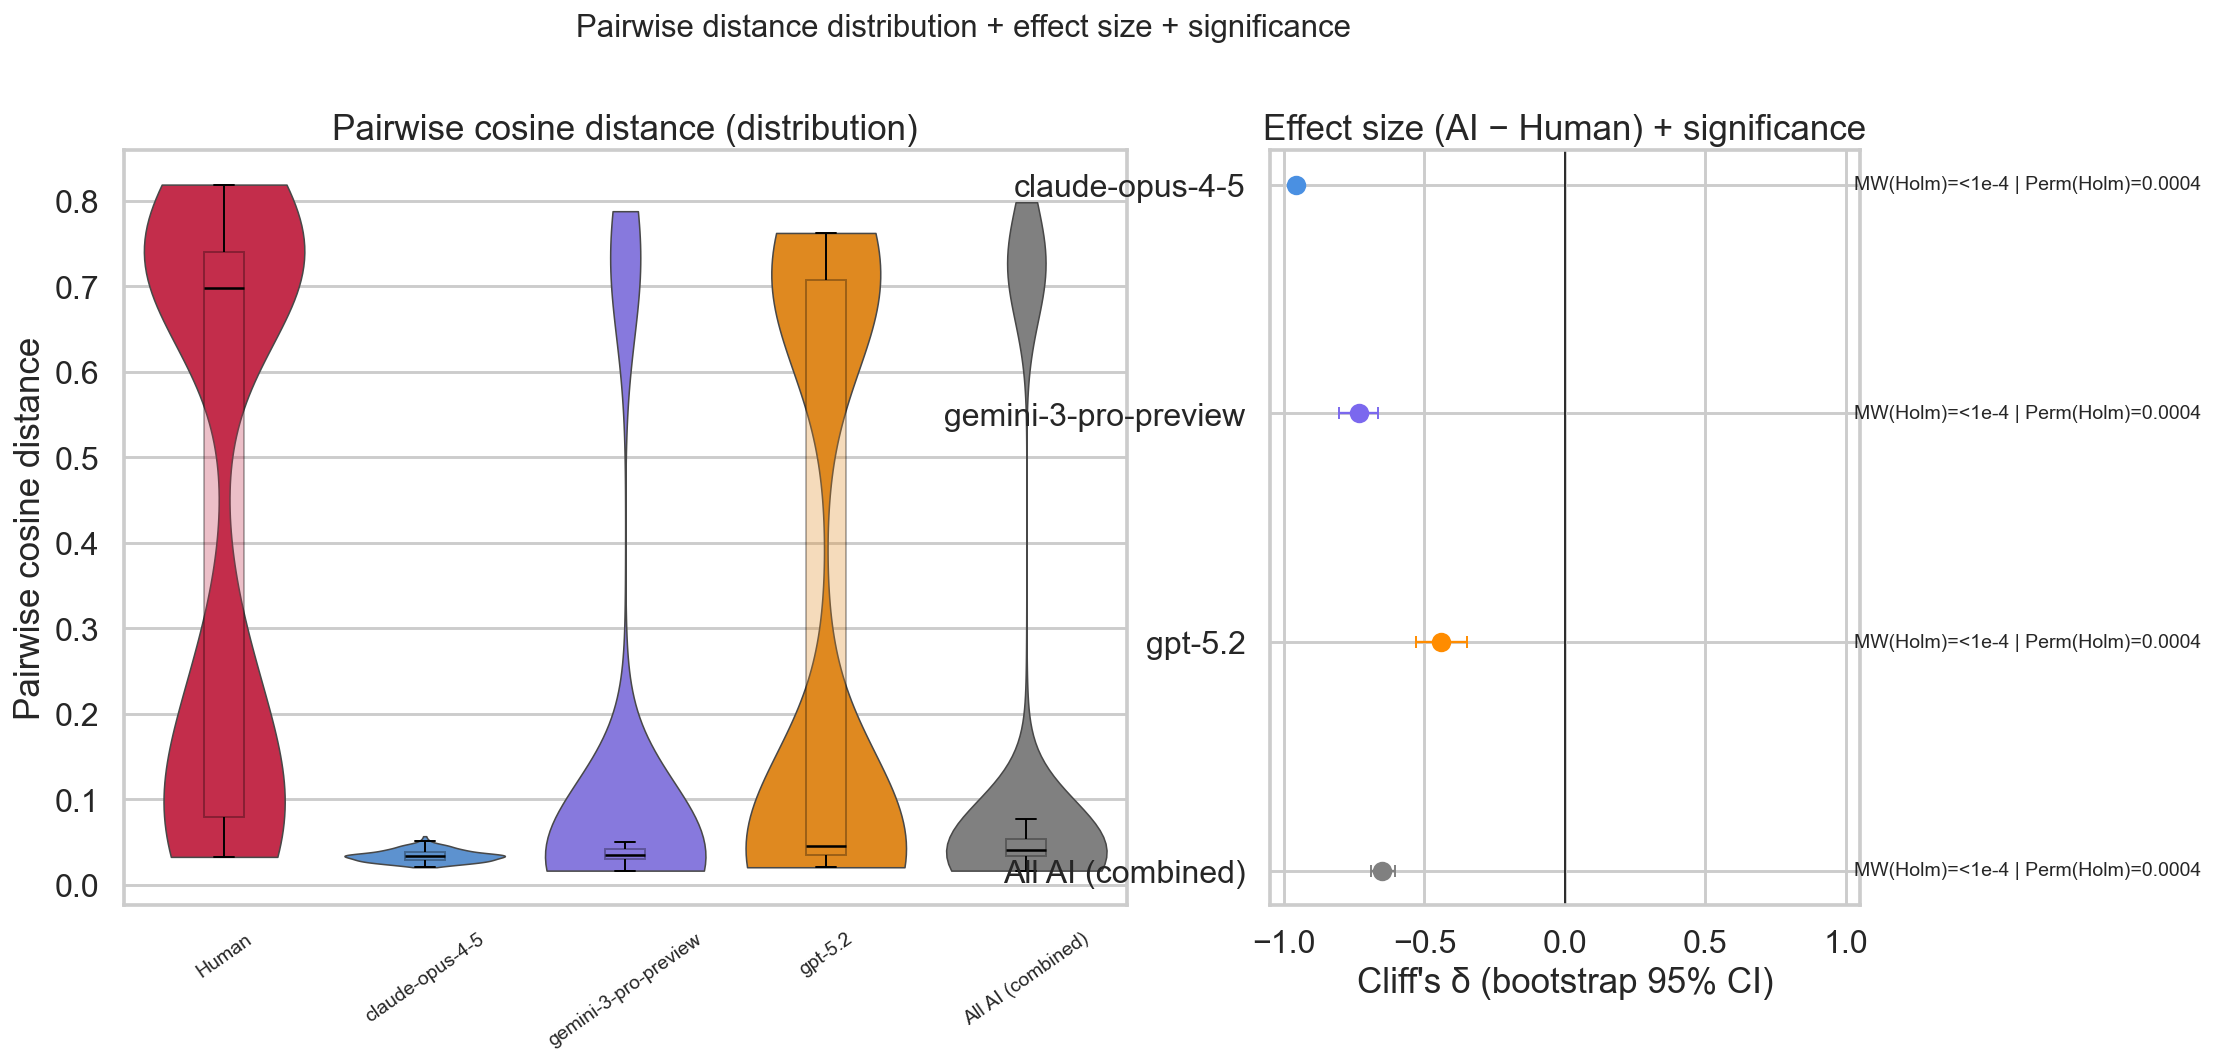

In [13]:
# visualization (PAIRWISE distances + effect size/significance), using your predefined `colors`
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def bootstrap_cliffs_delta_ci(group1, group2, n_boot=2000, random_state=42, alpha=0.05):
    rng = np.random.default_rng(random_state)
    g1 = np.asarray(group1, dtype=float)
    g2 = np.asarray(group2, dtype=float)

    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        b1 = rng.choice(g1, size=len(g1), replace=True)
        b2 = rng.choice(g2, size=len(g2), replace=True)
        boots[i] = cliffs_delta(b1, b2)  # reuse your existing function

    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi


# ---- Build long df for PAIRWISE distances (matches your summary table) ----
plot_specs = [("Human", human_pairwise)]

for m in ai_models:
    if len(model_pairwise.get(m, [])) > 0:
        plot_specs.append((m, model_pairwise[m]))

plot_specs.append(("All AI (combined)", ai_pairwise))

dist_df = pd.concat(
    [pd.DataFrame({"group": g, "pairwise_distance": np.asarray(v, dtype=float)}) for g, v in plot_specs],
    ignore_index=True,
)

group_order = [g for g, _ in plot_specs]

palette = {g: colors.get(g, "#808080") for g in group_order}
palette["All AI (combined)"] = palette.get("All AI (combined)", "#808080")


# ---- Recompute stats on PAIRWISE distances (so right panel matches left panel’s metric) ----
comparison_specs = [("All AI (combined)", ai_pairwise)] + [
    (m, model_pairwise[m]) for m in ai_models if len(model_pairwise.get(m, [])) > 0
]

comparison_results = []
for group_name, vals in comparison_specs:
    res = run_group_comparison(vals, human_pairwise, n_permutations=10000, n_boot=5000, random_state=42)
    res["group"] = group_name
    comparison_results.append(res)

eff_df = pd.DataFrame(comparison_results)
eff_df = apply_multiple_testing(eff_df, p_cols=("p_value_mw", "p_value_perm"), method="holm")

# bootstrap CI for δ (PAIRWISE; group vs Human)
delta_ci_low, delta_ci_high = [], []
for g in eff_df["group"].tolist():
    gvals = ai_pairwise if g == "All AI (combined)" else model_pairwise[g]
    lo, hi = bootstrap_cliffs_delta_ci(gvals, human_pairwise, n_boot=2000, random_state=42)
    delta_ci_low.append(lo)
    delta_ci_high.append(hi)

eff_df["delta_ci_low"] = delta_ci_low
eff_df["delta_ci_high"] = delta_ci_high

eff_order = [g for g in group_order if g not in ("Human",)]
eff_df["group"] = pd.Categorical(eff_df["group"], categories=eff_order, ordered=True)
eff_df = eff_df.sort_values("group")


def fmt_p(p):
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return "<1e-4"
    return f"{p:.4f}"


# ---- Plot: left = pairwise distribution, right = δ + CI + Holm p-values ----
sns.set_theme(style="whitegrid", context="talk")

fig = plt.figure(figsize=(16, 7), dpi=140)
gs = fig.add_gridspec(1, 2, width_ratios=[1.7, 1.0], wspace=0.18)
axL = fig.add_subplot(gs[0, 0])
axR = fig.add_subplot(gs[0, 1])

# Left panel: PAIRWISE distance distributions
sns.violinplot(
    data=dist_df,
    x="group",
    y="pairwise_distance",
    order=group_order,
    hue="group",
    hue_order=group_order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=0.8,
    dodge=False,
    ax=axL,
)
sns.boxplot(
    data=dist_df,
    x="group",
    y="pairwise_distance",
    order=group_order,
    hue="group",
    hue_order=group_order,
    palette=palette,
    width=0.20,
    showfliers=False,
    dodge=False,
    boxprops=dict(alpha=0.30, edgecolor="black", linewidth=1.0),
    medianprops=dict(color="black", linewidth=1.3),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0),
    ax=axL,
)

if axL.get_legend() is not None:
    axL.get_legend().remove()

axL.set_title("Pairwise cosine distance (distribution)")
axL.set_xlabel("")
axL.set_ylabel("Pairwise cosine distance")
axL.tick_params(axis="x", rotation=35, labelsize=10)

# Right panel: Cliff’s δ with bootstrap CI + Holm-adjusted p-values (PAIRWISE)
axR.axvline(0, color="black", linewidth=1.0, alpha=0.8)

ypos = np.arange(len(eff_df))
axR.set_yticks(ypos)
axR.set_yticklabels(eff_df["group"].astype(str))
axR.invert_yaxis()

for i, row in enumerate(eff_df.itertuples(index=False)):
    g = str(row.group)
    c = palette.get(g, "#808080")

    axR.errorbar(
        row.delta,
        i,
        xerr=np.array([[row.delta - row.delta_ci_low], [row.delta_ci_high - row.delta]]),
        fmt="o",
        color=c,
        ecolor=c,
        elinewidth=1.2,
        capsize=3,
    )

    txt = (
        f"MW(Holm)={fmt_p(getattr(row, 'p_value_mw_adj_holm', np.nan))} | "
        f"Perm(Holm)={fmt_p(getattr(row, 'p_value_perm_adj_holm', np.nan))}"
    )
    axR.text(1.03, i, txt, va="center", ha="left", fontsize=10, clip_on=False)

axR.set_title("Effect size (AI − Human) + significance")
axR.set_xlabel("Cliff's δ (bootstrap 95% CI)")
axR.set_ylabel("")
axR.set_xlim(-1.05, 1.05)

plt.suptitle("Pairwise distance distribution + effect size + significance", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

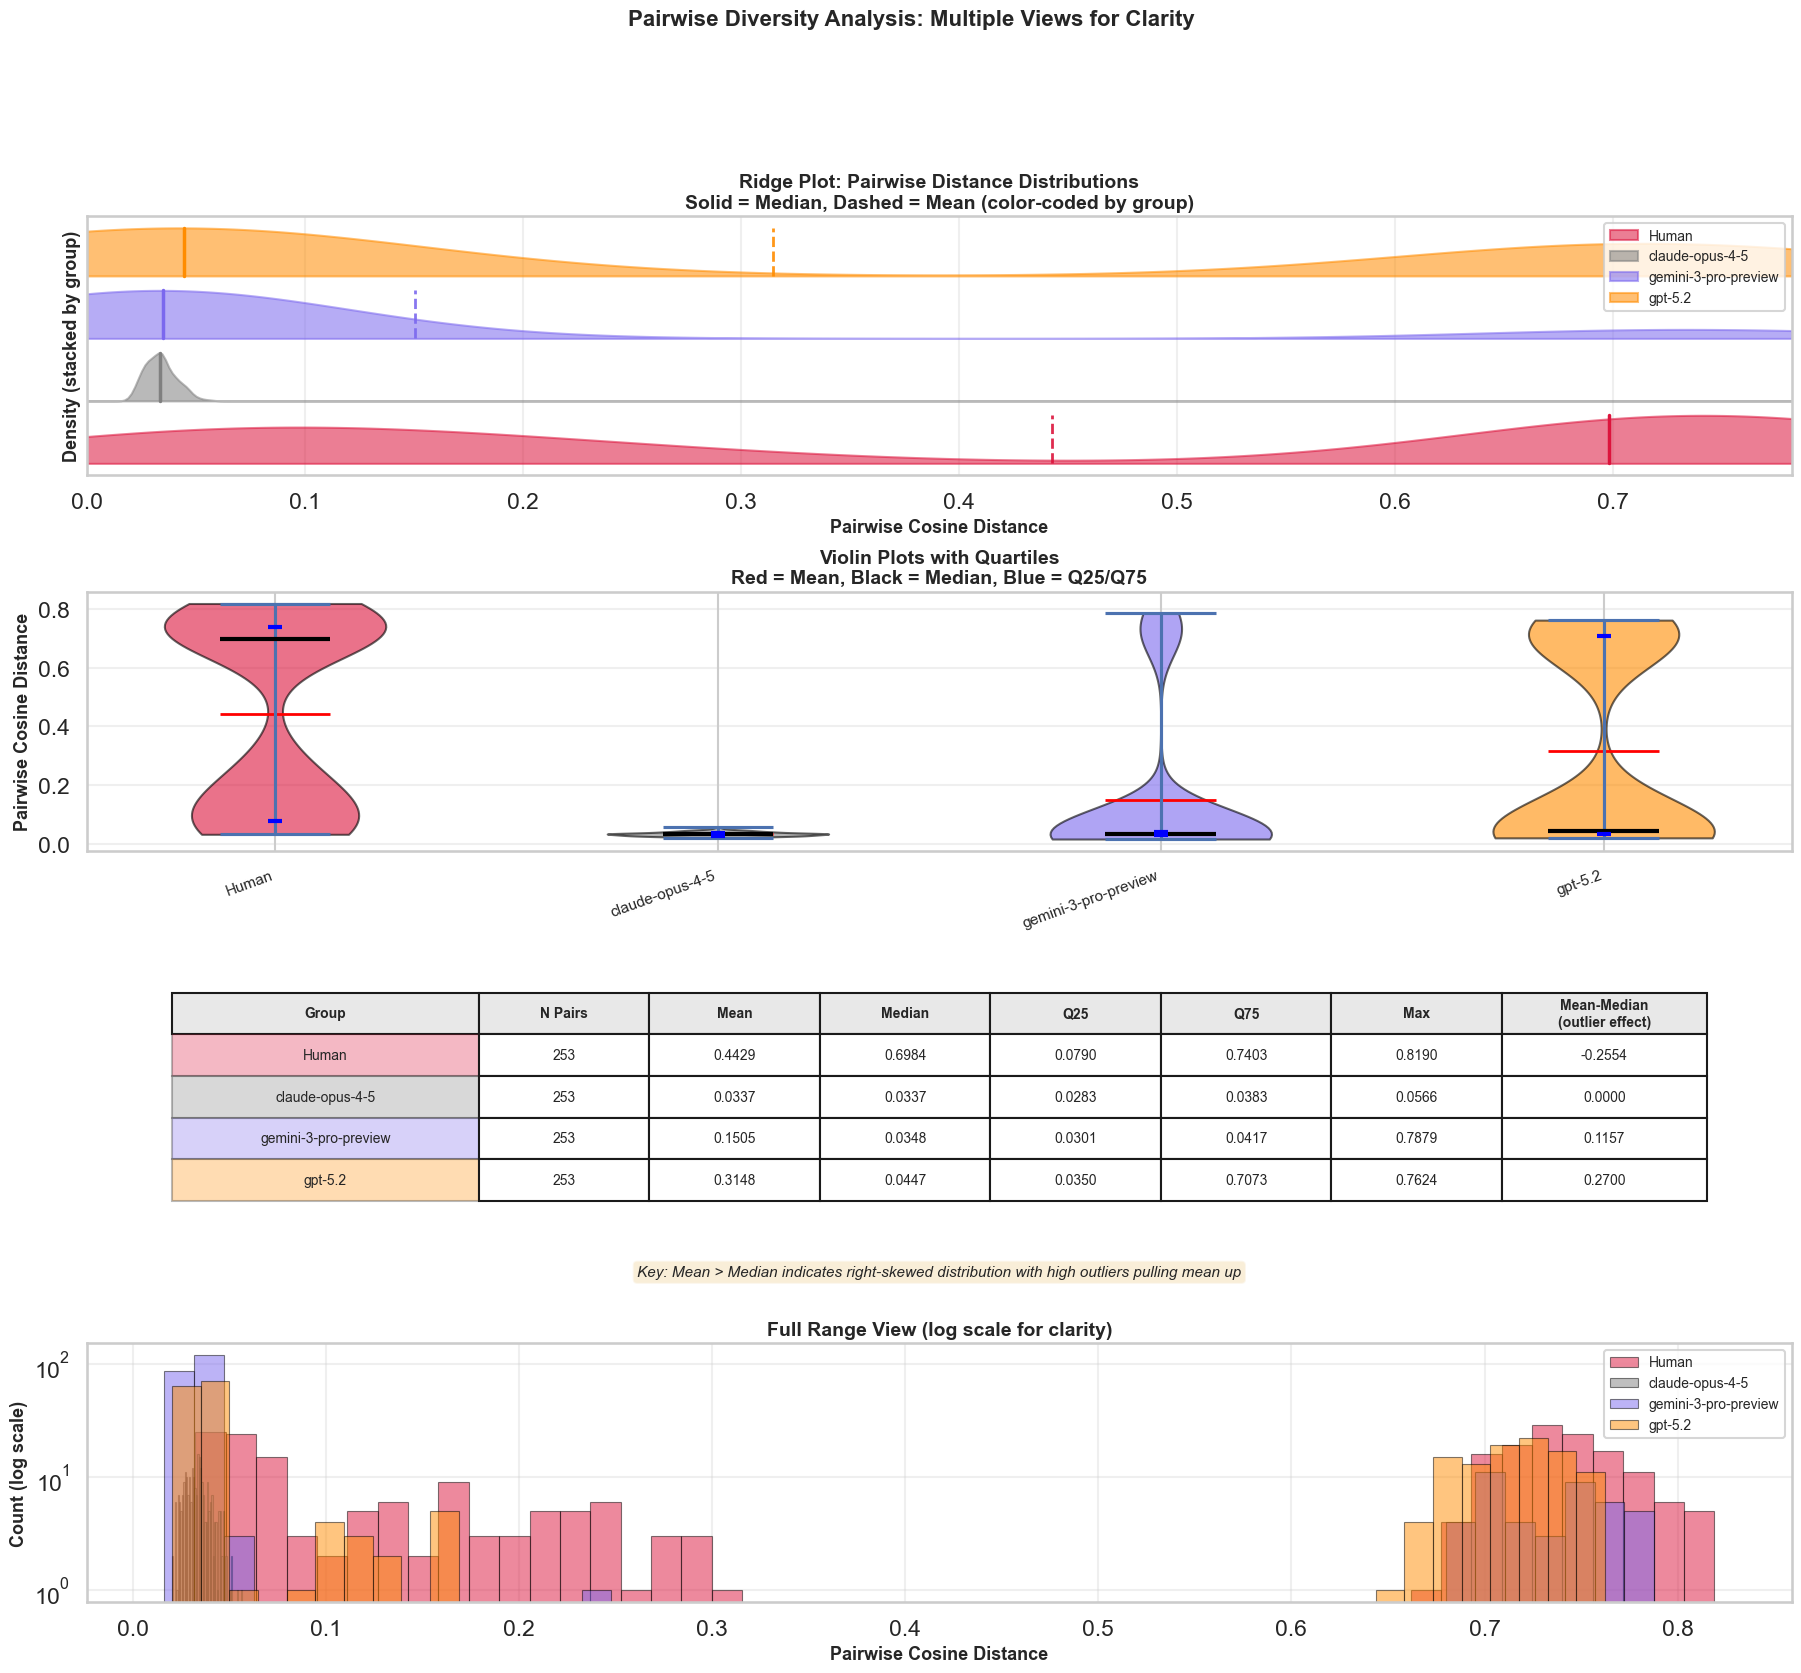

✓ Figure saved to: results/figures/rephrased/pairwise_diversity_by_model.png


In [14]:
# Visualization: Improved distribution comparison for all groups
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# Layout: 4 rows — ridge plot (full width), violin (full width),
#         summary table (full width), log-scale histogram (full width, new row)
fig = plt.figure(figsize=(22, 18))
gs = fig.add_gridspec(4, 1, hspace=0.45)

# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-6': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

group_order = ['Human'] + [m for m in ai_models if len(model_pairwise[m]) > 0]

# ── PANEL 1 (Row 0, full width): Ridge plot — x-range covers ALL group medians/means
# Determine x-limit: at least 0.2, but extend to fit the furthest median or mean + margin
all_stats = []
for group in group_order:
    d = human_pairwise if group == 'Human' else model_pairwise[group]
    all_stats += [float(np.median(d)), float(np.mean(d))]
x_limit = max(0.2, max(all_stats) * 1.12)   # 12% margin past the furthest stat line

ax1 = fig.add_subplot(gs[0])
RIDGE_HEIGHT = 1.0   # normalized peak height for every group (equal visual weight)
RIDGE_GAP    = 0.3   # gap between ridges
offset = 0

for idx, group in enumerate(group_order):
    data = human_pairwise if group == 'Human' else model_pairwise[group]
    grp_color = colors.get(group, 'gray')

    if len(data) > 1:
        kde = gaussian_kde(data)
        x_range = np.linspace(0, x_limit, 500)
        density = kde(x_range)
        # Normalize so every ridge peaks at RIDGE_HEIGHT (equal visual weight)
        density_norm = density / density.max() * RIDGE_HEIGHT

        ax1.fill_between(x_range, offset + density_norm, offset,
                         color=grp_color, alpha=0.55,
                         edgecolor=grp_color, linewidth=1.5, label=group)

        ridge_top = offset + RIDGE_HEIGHT

        # Median — solid line spanning full ridge height
        median_val = float(np.median(data))
        ax1.plot([median_val, median_val], [offset, ridge_top],
                 color=grp_color, linestyle='-', linewidth=2.5, alpha=1.0, zorder=5)

        # Mean — dashed line spanning full ridge height
        mean_val = float(np.mean(data))
        ax1.plot([mean_val, mean_val], [offset, ridge_top],
                 color=grp_color, linestyle='--', linewidth=2.0, alpha=0.9, zorder=5)

        offset += RIDGE_HEIGHT + RIDGE_GAP

ax1.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax1.set_ylabel('Density (stacked by group)', fontsize=13, fontweight='bold')
ax1.set_title('Ridge Plot: Pairwise Distance Distributions\nSolid = Median, Dashed = Mean (color-coded by group)',
              fontsize=14, fontweight='bold')
ax1.set_xlim(0, x_limit)
ax1.set_yticks([])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3, axis='x')

# ── PANEL 2 (Row 1, full width): Violin plots with quartile annotations
ax3 = fig.add_subplot(gs[1])

box_data = []
for dist, label in [(human_pairwise, 'Human')] + [(model_pairwise[m], m) for m in ai_models if len(model_pairwise[m]) > 0]:
    for val in dist:
        box_data.append({'Distance': val, 'Group': label})

box_df = pd.DataFrame(box_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

# Create violin plot
parts = ax3.violinplot([box_df[box_df['Group']==g]['Distance'].values for g in group_order],
                       positions=range(len(group_order)),
                       showmeans=True, showmedians=True, showextrema=True)

# Color the violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Enhance median and mean lines
parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

# Add quartile markers
for idx, group in enumerate(group_order):
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    q25, q75 = np.percentile(data, [25, 75])
    ax3.scatter([idx, idx], [q25, q75], color='blue', s=100, zorder=3, marker='_', linewidths=3)

ax3.set_xticks(range(len(group_order)))
ax3.set_xticklabels(group_order, fontsize=11, rotation=20, ha='right')
ax3.set_ylabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax3.set_title('Violin Plots with Quartiles\nRed = Mean, Black = Median, Blue = Q25/Q75', 
              fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

# ── PANEL 3 (Row 2, full width): Statistical summary table
ax4 = fig.add_subplot(gs[2])
ax4.axis('off')

# Create summary statistics
summary_data = []
for group in group_order:
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    summary_data.append([
        group,
        f"{len(data)}",
        f"{data.mean():.4f}",
        f"{np.median(data):.4f}",
        f"{np.percentile(data, 25):.4f}",
        f"{np.percentile(data, 75):.4f}",
        f"{data.max():.4f}",
        f"{data.mean() - np.median(data):.4f}"
    ])

# Create table
table = ax4.table(cellText=summary_data,
                 colLabels=['Group', 'N Pairs', 'Mean', 'Median', 'Q25', 'Q75', 'Max', 'Mean-Median\n(outlier effect)'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.18, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color code the header
for i in range(8):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

# Color code the groups
for i, group in enumerate(group_order):
    table[(i+1, 0)].set_facecolor(colors.get(group, 'gray'))
    table[(i+1, 0)].set_alpha(0.3)

ax4.text(0.5, -0.15, 
         'Key: Mean > Median indicates right-skewed distribution with high outliers pulling mean up',
         ha='center', va='top', transform=ax4.transAxes, fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── PANEL 4 (Row 3, full width): Full-range histogram with log-scale y-axis
ax2 = fig.add_subplot(gs[3])
for group in group_order:
    data = human_pairwise if group == 'Human' else model_pairwise[group]
    ax2.hist(data, bins=50, alpha=0.5, label=group,
             color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)

ax2.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Full Range View (log scale for clarity)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('Pairwise Diversity Analysis: Multiple Views for Clarity', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(FIGURES_DIR / 'pairwise_diversity_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/pairwise_diversity_by_model.png")


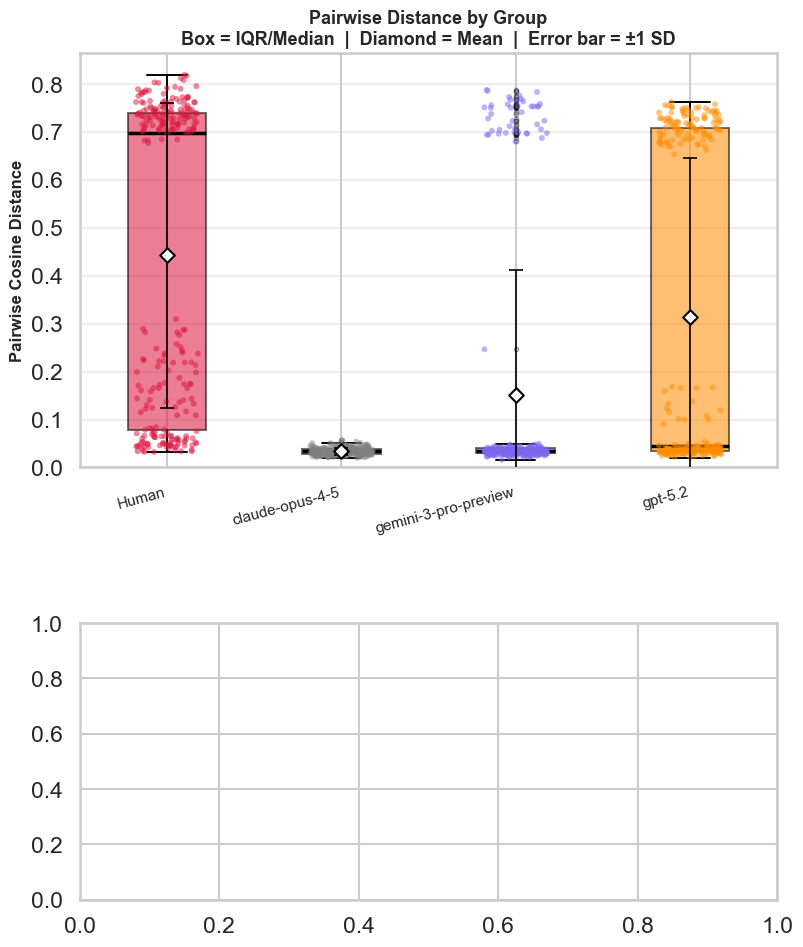

Group                            N     Mean   Median       SD      Min      Max
------------------------------------------------------------------------
Human                          253   0.4429   0.6984   0.3182   0.0324   0.8190
claude-opus-4-5                253   0.0337   0.0337   0.0069   0.0203   0.0566
gemini-3-pro-preview           253   0.1505   0.0348   0.2613   0.0164   0.7879
gpt-5.2                        253   0.3148   0.0447   0.3301   0.0203   0.7624


In [15]:
# Box plot summary + Cliff's delta panel for pairwise distances
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax, ax_delta) = plt.subplots(2, 1, figsize=(9, 11),
                                    gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.45})

box_arrays = []
for group in group_order:
    d = human_pairwise if group == 'Human' else model_pairwise[group]
    box_arrays.append(d)

# Box plot (shows median, IQR, whiskers)
bp = ax.boxplot(box_arrays, positions=range(len(group_order)),
                patch_artist=True, widths=0.45,
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(linewidth=1.4),
                capprops=dict(linewidth=1.4),
                flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'))

for patch, group in zip(bp['boxes'], group_order):
    patch.set_facecolor(colors.get(group, 'gray'))
    patch.set_alpha(0.55)
    patch.set_linewidth(1.5)

# Overlay individual points (jittered)
rng = np.random.default_rng(42)
for i, (group, d) in enumerate(zip(group_order, box_arrays)):
    jitter = rng.uniform(-0.18, 0.18, size=len(d))
    ax.scatter(i + jitter, d,
               color=colors.get(group, 'gray'), s=18, alpha=0.5,
               edgecolors='none', zorder=3)

# Mean markers (diamond)
for i, d in enumerate(box_arrays):
    ax.scatter(i, np.mean(d), marker='D', s=55,
               color='white', edgecolors='black', linewidths=1.5, zorder=5)

# SD error bars around the mean
for i, d in enumerate(box_arrays):
    m, s = np.mean(d), np.std(d, ddof=1)
    ax.errorbar(i, m, yerr=s, fmt='none',
                ecolor='black', elinewidth=1.2, capsize=5, capthick=1.2, zorder=4)

ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order, fontsize=11, rotation=15, ha='right')
ax.set_ylabel('Pairwise Cosine Distance', fontsize=12, fontweight='bold')
ax.set_title('Pairwise Distance by Group\nBox = IQR/Median  |  Diamond = Mean  |  Error bar = ±1 SD',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35)
ax.set_ylim(bottom=0)


plt.savefig(FIGURES_DIR / 'pairwise_diversity_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"{'Group':<28} {'N':>5}  {'Mean':>7}  {'Median':>7}  {'SD':>7}  {'Min':>7}  {'Max':>7}")
print('-' * 72)
for group, d in zip(group_order, box_arrays):
    print(f"{group:<28} {len(d):>5}  {np.mean(d):>7.4f}  {np.median(d):>7.4f}"
          f"  {np.std(d, ddof=1):>7.4f}  {d.min():>7.4f}  {d.max():>7.4f}")

## Analysis 1.2: Centroid Dispersion Metric

Measure how scattered proposals are from their group center.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [16]:
def compute_centroid_distances(embeddings):
    """
    Compute distances from each proposal to its group centroid.
    """
    # Compute centroid (mean embedding)
    centroid = embeddings.mean(axis=0, keepdims=True)
    
    # Compute cosine distances to centroid
    distances = cosine_distances(embeddings, centroid).flatten()
    
    return distances, centroid

# Compute centroid distances for all groups
print("="*85)
print("COMPUTING CENTROID DISPERSION FOR ALL GROUPS")
print("="*85)

# Overall groups
ai_centroid_dists, ai_centroid = compute_centroid_distances(ai_embeddings)
human_centroid_dists, human_centroid = compute_centroid_distances(human_embeddings)

# Individual AI models
model_centroid_dists = {}
model_centroids = {}

for model in ai_models:
    if len(model_embeddings_dict[model]) > 0:
        dists, centroid = compute_centroid_distances(model_embeddings_dict[model])
        model_centroid_dists[model] = dists
        model_centroids[model] = centroid

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10} {'Variance':<10}")
print("-"*90)

# Human baseline
print(f"{'Human':<35} {len(human_embeddings):<8} {human_centroid_dists.mean():<10.4f} {np.median(human_centroid_dists):<10.4f} {human_centroid_dists.std():<10.4f} {human_centroid_dists.var():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if model in model_centroid_dists:
        dists = model_centroid_dists[model]
        n_proposals = len(model_embeddings_dict[model])
        print(f"{model:<35} {n_proposals:<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.std():<10.4f} {dists.var():<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {ai_centroid_dists.mean():<10.4f} {np.median(ai_centroid_dists):<10.4f} {ai_centroid_dists.std():<10.4f} {ai_centroid_dists.var():<10.4f}")

print("="*90)
print("\n💡 INTERPRETATION:")
print("   - Higher variance = more dispersed proposals (higher diversity)")
print("   - Lower variance = proposals cluster tightly around center")
print("="*90)


COMPUTING CENTROID DISPERSION FOR ALL GROUPS

GROUP                               N        Mean       Median     Std        Variance  
------------------------------------------------------------------------------------------
Human                               23       0.2413     0.2236     0.0411     0.0017    

claude-opus-4-5                     23       0.0163     0.0151     0.0036     0.0000    
gemini-3-pro-preview                23       0.0748     0.0209     0.1770     0.0313    
gpt-5.2                             23       0.1643     0.0664     0.1685     0.0284    

All AI (combined)                   69       0.0945     0.0274     0.1876     0.0352    

💡 INTERPRETATION:
   - Higher variance = more dispersed proposals (higher diversity)
   - Lower variance = proposals cluster tightly around center


In [17]:
# Save: centroid distances
import pandas as pd, numpy as np; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
rows = [{'title': r.get('proposal_title', r.get('title','')), 'group': 'Human', 'centroid_dist': human_centroid_dists[i]}
        for i, r in enumerate(human_metadata)]
# Use model_centroid_dists.keys() — ai_models_local not yet defined at this point in the notebook
models_local = list(dict.fromkeys(r.get('model','AI') for r in ai_metadata))
mc = {m: 0 for m in models_local}
for r in ai_metadata:
    m = r.get('model','AI'); k = mc.get(m,0)
    rows.append({'title': r.get('title', r.get('proposal_title','')), 'group': m,
                 'centroid_dist': model_centroid_dists[m][k] if m in model_centroid_dists and k < len(model_centroid_dists[m]) else np.nan})
    mc[m] = k+1
pd.DataFrame(rows).to_csv(out_dir/'centroid_distances.csv', index=False)
print(f"Saved centroid_distances.csv  ({len(rows)} rows)")


Saved centroid_distances.csv  (92 rows)


In [18]:
print("="*85)
print("STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in centroid distance (AI - Human).")

comparison_specs = [('All AI', ai_centroid_dists)] + [
    (model, model_centroid_dists[model])
    for model in ai_models
    if model in model_centroid_dists
]

centroid_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_centroid_dists, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    centroid_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE dispersed from center")
    else:
        print(f"  → Human proposals are MORE dispersed from center")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

centroid_df = pd.DataFrame(centroid_results)
centroid_df = apply_multiple_testing(centroid_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
centroid_comparison_results = centroid_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Centroid Dispersion with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in centroid_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more dispersed; Negative = Human more dispersed")


STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)
Primary estimand: mean difference in centroid distance (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 184, p-value: 3.9891e-08
Cliff's Delta:
  δ = -0.7681 (large effect)
  → Human proposals are MORE dispersed from center
Primary mean difference (AI - Human):
  Observed difference: -0.1468
  Bootstrap 95% CI: [-0.1905, -0.0965]
  Permutation p-value: 0.0005

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 0, p-value: 6.6369e-09
Cliff's Delta:
  δ = -1.0000 (large effect)
  → Human proposals are MORE dispersed from center
Primary mea

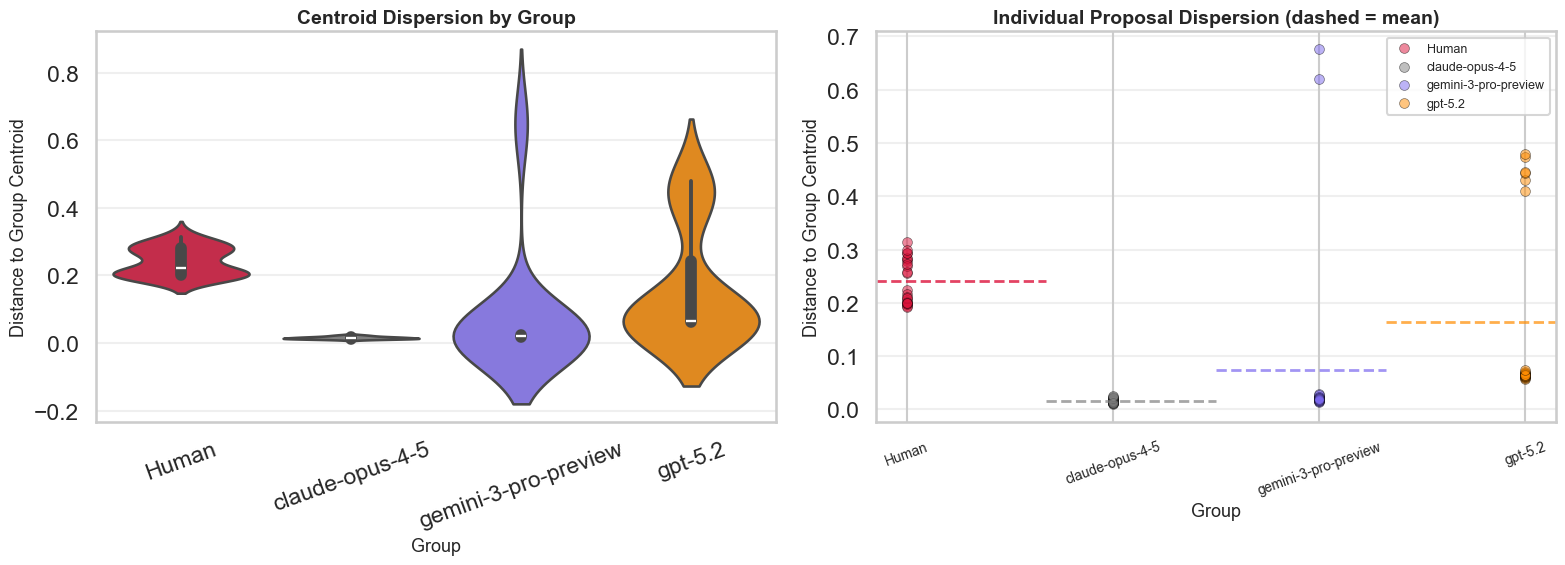

✓ Figure saved to: results/figures/rephrased/centroid_dispersion_by_model.png


In [19]:
# Visualization: Centroid dispersion for all groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



# LEFT PANEL: Violin plots
violin_data = []
for dist, label in [(human_centroid_dists, 'Human')] + [(model_centroid_dists[m], m) for m in ai_models if m in model_centroid_dists]:
    for val in dist:
        violin_data.append({'Distance to Centroid': val, 'Group': label})

violin_df = pd.DataFrame(violin_data)
group_order = ['Human'] + [m for m in ai_models if m in model_centroid_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=violin_df, x='Group', y='Distance to Centroid', ax=axes[0], palette=palette_list, order=group_order)
axes[0].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[0].set_xlabel('Group', fontsize=13)
axes[0].set_title('Centroid Dispersion by Group', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

# RIGHT PANEL: Scatter plot showing individual proposals
offset = 0
x_positions = {}

# Human
x_positions['Human'] = 0
axes[1].scatter([0]*len(human_centroid_dists), human_centroid_dists, 
               alpha=0.5, label='Human', color=colors['Human'], s=50, edgecolors='black', linewidth=0.5)
axes[1].axhline(human_centroid_dists.mean(), xmin=0/len(group_order), xmax=1/len(group_order), 
               color=colors['Human'], linestyle='--', linewidth=2, alpha=0.8)

offset = 1
# Individual AI models
for i, model in enumerate([m for m in ai_models if m in model_centroid_dists]):
    x_positions[model] = offset
    axes[1].scatter([offset]*len(model_centroid_dists[model]), model_centroid_dists[model], 
                   alpha=0.5, label=model, color=colors.get(model, 'gray'), s=50, edgecolors='black', linewidth=0.5)
    axes[1].axhline(model_centroid_dists[model].mean(), 
                   xmin=offset/len(group_order), xmax=(offset+1)/len(group_order),
                   color=colors.get(model, 'gray'), linestyle='--', linewidth=2, alpha=0.7)
    offset += 1

axes[1].set_xticks(range(len(group_order)))
axes[1].set_xticklabels(group_order, rotation=20, fontsize=10)
axes[1].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[1].set_xlabel('Group', fontsize=13)
axes[1].set_title('Individual Proposal Dispersion (dashed = mean)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'centroid_dispersion_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/centroid_dispersion_by_model.png")


## Analysis 1.3: Nearest-Neighbor Outlier Detection (Between Group)

Identify "lone wolf" ideas far from everything else.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [20]:
# Combine all embeddings for global nearest-neighbor analysis
all_embeddings = np.vstack([human_embeddings, ai_embeddings])
n_human = len(human_embeddings)
n_ai = len(ai_embeddings)

# Build per-row labels aligned to embedding order (avoid assuming contiguous blocks by model)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = [m for m in sorted(list(dict.fromkeys(ai_model_labels))) if m is not None]

# Compute full distance matrix
print("="*85)
print("COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
print("="*85)

all_distances = cosine_distances(all_embeddings)
np.fill_diagonal(all_distances, np.inf)
nn_distances = all_distances.min(axis=1)

# Split by group
human_nn_dists = nn_distances[labels == 'Human']
ai_nn_dists = nn_distances[labels != 'Human']

# Extract per-model NN distances using label masks
model_nn_dists = {m: nn_distances[labels == m] for m in ai_models_local}

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

print(f"{'Human':<35} {len(human_nn_dists):<8} {human_nn_dists.mean():<10.4f} {np.median(human_nn_dists):<10.4f} {human_nn_dists.min():<10.4f} {human_nn_dists.max():<10.4f}")
print()

for model in ai_models_local:
    dists = model_nn_dists[model]
    print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")

print()
print(f"{'All AI (combined)':<35} {len(ai_nn_dists):<8} {ai_nn_dists.mean():<10.4f} {np.median(ai_nn_dists):<10.4f} {ai_nn_dists.min():<10.4f} {ai_nn_dists.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher mean NN distance = more isolated proposals (outliers)")
print("   - Lower mean NN distance = proposals cluster together")
print("="*85)


COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.0739     0.0369     0.0189     0.2135    

claude-opus-4-5                     23       0.0234     0.0233     0.0189     0.0310    
gemini-3-pro-preview                23       0.0326     0.0234     0.0164     0.1854    
gpt-5.2                             23       0.0408     0.0266     0.0187     0.1129    

All AI (combined)                   69       0.0323     0.0238     0.0164     0.1854    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together


In [21]:
# Identify outliers (top 10% of NN distances)
# Use a distinct variable name so later cells (topic analysis) don't overwrite it
nn_outlier_threshold = np.percentile(nn_distances, 90)
threshold = nn_outlier_threshold  # keep backward compat for downstream cells
outliers = nn_distances > nn_outlier_threshold

human_outliers = int(outliers[labels == 'Human'].sum())
ai_outliers = int(outliers[labels != 'Human'].sum())

# Per-model outlier detection (do NOT slice by contiguous blocks)
model_outliers = {m: int(outliers[labels == m].sum()) for m in ai_models_local}

print("\n" + "="*85)
print("OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)")
print("="*85)
print(f"Threshold distance: {nn_outlier_threshold:.4f}")
print()

print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
print("-"*85)

print(f"{'Human':<35} {human_outliers:<15} {n_human:<10} {human_outliers/n_human*100:<15.1f}%")
print()

for model in ai_models_local:
    n_model = int((labels == model).sum())
    print(f"{model:<35} {model_outliers[model]:<15} {n_model:<10} {model_outliers[model]/n_model*100:<15.1f}%")

print()
print(f"{'All AI (combined)':<35} {ai_outliers:<15} {n_ai:<10} {ai_outliers/n_ai*100:<15.1f}%")

print("="*85)


OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)
Threshold distance: 0.0984

GROUP                               Outliers        Total      Percentage     
-------------------------------------------------------------------------------------
Human                               7               23         30.4           %

claude-opus-4-5                     0               23         0.0            %
gemini-3-pro-preview                1               23         4.3            %
gpt-5.2                             2               23         8.7            %

All AI (combined)                   3               69         4.3            %


In [22]:
# Save: NN distances + outlier flags
import pandas as pd, numpy as np; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
rows = [{'title': r.get('proposal_title', r.get('title','')), 'group': 'Human',
         'nn_dist': human_nn_dists[i], 'is_outlier': bool(outliers[i])}
        for i, r in enumerate(human_metadata)]
mc = {m: 0 for m in ai_models_local}
for j, r in enumerate(ai_metadata):
    m = r.get('model','AI'); k = mc.get(m,0)
    rows.append({'title': r.get('title', r.get('proposal_title','')), 'group': m,
                 'nn_dist': model_nn_dists[m][k] if m in model_nn_dists and k < len(model_nn_dists[m]) else np.nan,
                 'is_outlier': bool(outliers[len(human_metadata)+j])})
    mc[m] = k+1
df = pd.DataFrame(rows); df['threshold'] = threshold
df.to_csv(out_dir/'nn_distances.csv', index=False)
print(f"Saved nn_distances.csv  ({len(df)} rows, threshold={threshold:.4f})")
print(df.groupby('group')[['nn_dist','is_outlier']].agg({'nn_dist':'mean','is_outlier':'sum'}))


Saved nn_distances.csv  (92 rows, threshold=0.0984)
                       nn_dist  is_outlier
group                                     
Human                 0.073920           7
claude-opus-4-5       0.023374           0
gemini-3-pro-preview  0.032618           1
gpt-5.2               0.040828           2


In [23]:
# Find nearest neighbor's group for each proposal
nn_indices = all_distances.argmin(axis=1)
nn_labels = labels[nn_indices]

# Determine if NN is from same or different group
human_nn_same_group = int((nn_labels[labels == 'Human'] == 'Human').sum())
human_nn_diff_group = int(n_human - human_nn_same_group)

ai_nn_same_group = int((nn_labels[labels != 'Human'] != 'Human').sum())
ai_nn_diff_group = int(n_ai - ai_nn_same_group)

# Per-model nearest neighbor group analysis (mask-based)
model_nn_analysis = {}
for model in ai_models_local:
    mask = labels == model
    total = int(mask.sum())
    nn_from_human = int((nn_labels[mask] == 'Human').sum())
    nn_from_same_model = int((nn_labels[mask] == model).sum())
    nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)

    model_nn_analysis[model] = {
        'from_human': nn_from_human,
        'from_same_model': nn_from_same_model,
        'from_other_ai': nn_from_other_ai,
        'total': total
    }

print("\n" + "="*85)
print("NEAREST NEIGHBOR GROUP ANALYSIS")
print("="*85)

print(f"\n{'Human proposals:':<50}")
print(f"  NN from same group (human): {human_nn_same_group} ({human_nn_same_group/n_human*100:.1f}%)")
print(f"  NN from different group (AI): {human_nn_diff_group} ({human_nn_diff_group/n_human*100:.1f}%)")

print(f"\n{'All AI proposals (combined):':<50}")
print(f"  NN from same group (AI): {ai_nn_same_group} ({ai_nn_same_group/n_ai*100:.1f}%)")
print(f"  NN from different group (human): {ai_nn_diff_group} ({ai_nn_diff_group/n_ai*100:.1f}%)")

print("\n" + "-"*85)
print("Per-Model NN Group Breakdown:")
print("-"*85)

for model in ai_models_local:
    data = model_nn_analysis[model]
    print(f"\n{model}:")
    print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
    print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
    print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

print("\n" + "="*85)
print("\n💡 INTERPRETATION:")
print("   - High 'NN from same model' = model produces similar proposals")
print("   - High 'NN from Human' = model proposals resemble human work")
print("="*85)



NEAREST NEIGHBOR GROUP ANALYSIS

Human proposals:                                  
  NN from same group (human): 7 (30.4%)
  NN from different group (AI): 16 (69.6%)

All AI proposals (combined):                      
  NN from same group (AI): 60 (87.0%)
  NN from different group (human): 9 (13.0%)

-------------------------------------------------------------------------------------
Per-Model NN Group Breakdown:
-------------------------------------------------------------------------------------

claude-opus-4-5:
  NN from Human: 1 (4.3%)
  NN from same model: 19 (82.6%)
  NN from other AI models: 3 (13.0%)

gemini-3-pro-preview:
  NN from Human: 1 (4.3%)
  NN from same model: 13 (56.5%)
  NN from other AI models: 9 (39.1%)

gpt-5.2:
  NN from Human: 7 (30.4%)
  NN from same model: 11 (47.8%)
  NN from other AI models: 5 (21.7%)


💡 INTERPRETATION:
   - High 'NN from same model' = model produces similar proposals
   - High 'NN from Human' = model proposals resemble human work


In [24]:
print("="*85)
print("STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in NN distance (AI - Human).")

comparison_specs = [('All AI', ai_nn_dists)] + [
    (model, model_nn_dists[model])
    for model in ai_models
    if model in model_nn_dists
]

nn_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_nn_dists, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    nn_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals have MORE unique/outlier ideas")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

nn_df = pd.DataFrame(nn_results)
nn_df = apply_multiple_testing(nn_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
nn_comparison_results = nn_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Nearest-Neighbor Distances with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in nn_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more outlier-prone; Negative = Human more outlier-prone")


STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)
Primary estimand: mean difference in NN distance (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 256, p-value: 1.2828e-06
Cliff's Delta:
  δ = -0.6774 (large effect)
  → Human proposals have MORE unique/outlier ideas
Primary mean difference (AI - Human):
  Observed difference: -0.0416
  Bootstrap 95% CI: [-0.0668, -0.0188]
  Permutation p-value: 0.0001

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 50, p-value: 2.4378e-06
Cliff's Delta:
  δ = -0.8129 (large effect)
  → Human proposals have MORE unique/outlier ideas
Primary m

In [25]:
import numpy as np
import pandas as pd

print("\n" + "="*85)
print("UNADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers', 'threshold', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the unadjusted NN + outlier detection cells first.")
else:
    outlier_indices = np.where(outliers)[0]
    n_total = int(len(outliers))
    n_ai = int(n_total - n_human)

    # NN distances (unadjusted)
    nn_d = np.asarray(nn_distances) if 'nn_distances' in globals() else None

    # Prefer metadata saved alongside embeddings (aligned with embedding order)
    use_meta = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_meta:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df lookup.")
            use_meta = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_meta:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = int(idx - n_human)
            who = 'AI'
            if use_meta:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', 'AI')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



UNADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.0984
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
Human                   7
gpt-5.2                 2
gemini-3-pro-preview    1


,global_index,who,model,nn_distance,title
0,21,Human,Human,0.213483,Searching the crosslinking mass spectrometry universe for new protein-protein interactions
1,13,Human,Human,0.208653,MaiTool - LLM-powered bioinformatics tools for microbiome analysis
2,62,AI,gemini-3-pro-preview,0.185393,Synthesizing the Emergent Assembly of Bacterial Microcompartments
3,10,Human,Human,0.143340,Discovery and functional analysis of bacterial organelles through mining and refinement of omics data
4,22,Human,Human,0.129598,Intelligent metadata compilation to enhance the reusability and discoverability of mass spectrometry-based proteomics data
5,0,Human,Human,0.126132,Emergent Order Parameters of Allostery: An AI Framework for Predicting and Engineering Protein Regulation
6,4,Human,Human,0.122488,Integrative Multi-Omics Synthesis to Identify Shared Molecular Mechanisms of Mammalian Hibernation
7,27,AI,gpt-5.2,0.112855,"A Unified Synthesis of Protein Complex Stoichiometry and Assembly Pathways from Structural, Proteomic, and Ribosome Profiling Data"
8,7,Human,Human,0.101988,A Unified Framework for Analyses of Proteome Turnover Dynamics
9,35,AI,gpt-5.2,0.099729,"Emergent Properties of Membrane Microdomains: Integrating Lipidomics, Proteomics, and Super-Resolution Imaging of Raft-Like Assemblies"


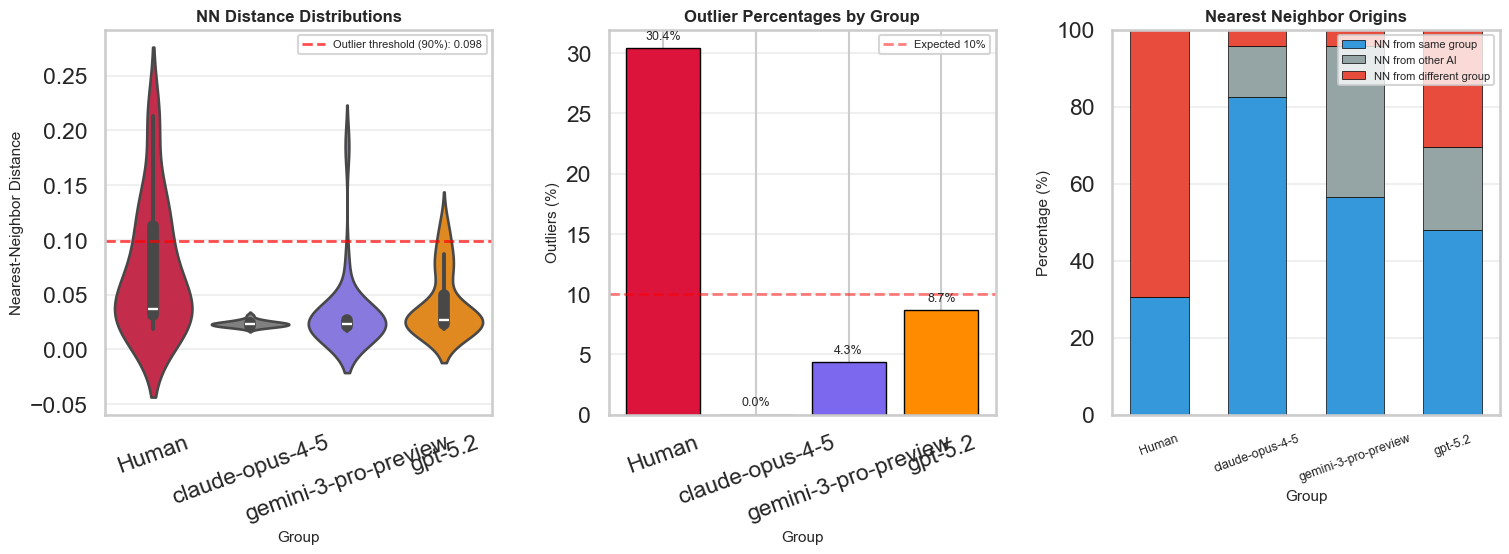

✓ Figure saved to: results/figures/rephrased/nearest_neighbor_by_model.png


In [26]:
# Visualization: Nearest-neighbor analysis by group
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# # Color scheme
# colors = {
#     'Human': 'steelblue',
#     'claude-opus-4-6': '#E74C3C',
#     'gemini-3-pro-preview': '#9B59B6',
#     'gpt-5.2': '#F39C12',
#     'All AI': 'coral'
# }

# 1. NN distance distributions by group
ax1 = fig.add_subplot(gs[0, 0])
nn_data = []
for dist, label in [(human_nn_dists, 'Human')] + [(model_nn_dists[m], m) for m in ai_models if m in model_nn_dists]:
    for val in dist:
        nn_data.append({'NN Distance': val, 'Group': label})

nn_df = pd.DataFrame(nn_data)
group_order = ['Human'] + [m for m in ai_models if m in model_nn_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order)
ax1.axhline(threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold:.3f}')
ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
ax1.set_xlabel('Group', fontsize=11)
ax1.set_title('NN Distance Distributions', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# 2. Outlier counts by group
ax2 = fig.add_subplot(gs[0, 1])
outlier_data = []
outlier_data.append({'Group': 'Human', 'Outliers': human_outliers, 'Total': n_human, 'Percentage': human_outliers/n_human*100})

for model in ai_models:
    if model in model_outliers:
        n_model = len(model_embeddings_dict[model])
        outlier_data.append({
            'Group': model,
            'Outliers': model_outliers[model],
            'Total': n_model,
            'Percentage': model_outliers[model]/n_model*100
        })

outlier_df = pd.DataFrame(outlier_data)
bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors.get(g, 'gray') for g in outlier_df['Group']], 
               edgecolor='black', linewidth=1)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
ax2.set_ylabel('Outliers (%)', fontsize=11)
ax2.set_xlabel('Group', fontsize=11)
ax2.set_title('Outlier Percentages by Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, outlier_df['Percentage'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. NN Group Analysis - Stacked bar chart
ax3 = fig.add_subplot(gs[0, 2])

# Prepare data for stacked bars
groups = ['Human'] + [m for m in ai_models if m in model_nn_analysis]
nn_from_human_pcts = [human_nn_diff_group/n_human*100]  # For human, this is NN from AI
nn_from_same_pcts = [human_nn_same_group/n_human*100]  # For human, this is NN from human
nn_from_other_ai_pcts = [0]  # Human doesn't have this category

for model in [m for m in ai_models if m in model_nn_analysis]:
    data = model_nn_analysis[model]
    nn_from_human_pcts.append(data['from_human']/data['total']*100)
    nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
    nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

x_pos = np.arange(len(groups))
width = 0.6

# Adjust labels for Human
p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_xlabel('Group', fontsize=11)
ax3.set_title('Nearest Neighbor Origins', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(groups, rotation=20, fontsize=9)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim([0, 100])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nearest_neighbor_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/nearest_neighbor_by_model.png")


### Visualize proposals in Embedding Space V

Visualize all proposals in 2D space using UMAP dimensionality reduction to see:
- **Clustering patterns**: How proposals group together
- **Outliers**: Unique proposals far from others (highlighted in magenta)
- **Group separation**: How Human vs AI proposals distribute in semantic space
- **Model characteristics**: Whether different AI models produce distinctly clustered proposals

**Color coding**: Human proposals in bright red for easy identification, AI models in muted colors. A complementary t-SNE view follows in the next cell.



VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE

Reducing embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


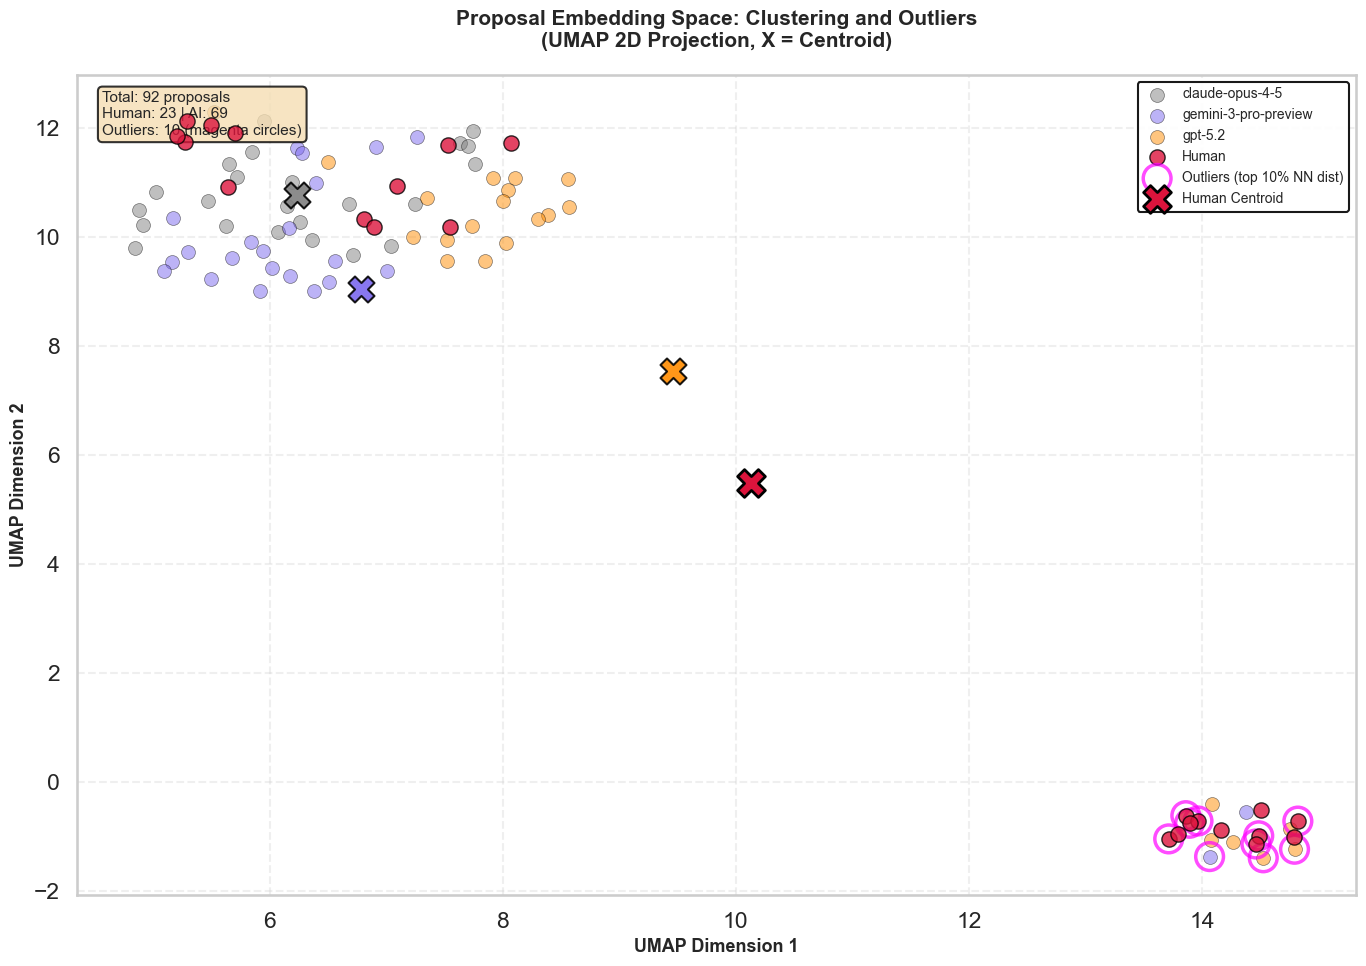


✓ Figure saved to: ../results/figures/rephrased/minimal/embedding_space_umap_2d.png

💡 INTERPRETATION:
   - Clusters = similar proposals
   - Outliers (magenta circles) = unique/distant proposals
   - X markers = group centroids
   - Distance between groups shows overall similarity


In [27]:


print("\n" + "="*85)
print("VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE")
print("="*85)

# Apply UMAP dimensionality reduction
print("\nReducing embeddings to 2D using UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# Combine all embeddings for UMAP
all_embeddings_umap = np.vstack([human_embeddings, ai_embeddings])
embeddings_2d = reducer.fit_transform(all_embeddings_umap)

# Split back into groups
human_2d = embeddings_2d[:n_human]
ai_2d = embeddings_2d[n_human:]

# Build labels aligned to embedding order (avoid assuming contiguous model blocks)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_umap = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

print(f"✓ UMAP completed: {len(embeddings_2d)} proposals reduced to 2D")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot AI models first (so human is on top) — mask-based by label
for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        pts = embeddings_2d[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Plot human proposals on top (bright red)
ax.scatter(human_2d[:, 0], human_2d[:, 1],
          c=colors['Human'],
          label='Human',
          s=120,
          alpha=0.8,
          edgecolors='black',
          linewidth=1.0,
          marker='o',
          zorder=10)  # Ensure human points are on top

# Highlight outliers with a circle
outlier_indices = np.where(outliers)[0]
outlier_coords = embeddings_2d[outlier_indices]

ax.scatter(outlier_coords[:, 0], outlier_coords[:, 1],
          s=400,
          facecolors='none',
          edgecolors='magenta',
          linewidth=2.5,
          alpha=0.7,
          label=f'Outliers (top 10% NN dist)',
          zorder=5)

# Calculate and plot centroids for each group
human_centroid_2d = human_2d.mean(axis=0)
ax.scatter(human_centroid_2d[0], human_centroid_2d[1],
          c=colors['Human'],
          s=400,
          marker='X',
          edgecolors='black',
          linewidth=2,
          alpha=1.0,
          zorder=15,
          label='Human Centroid')

for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        model_centroid_2d = embeddings_2d[mask].mean(axis=0)
        ax.scatter(model_centroid_2d[0], model_centroid_2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=12)

# Labels and formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Proposal Embedding Space: Clustering and Outliers\n(UMAP 2D Projection, X = Centroid)',
            fontsize=15, fontweight='bold', pad=20)

# Legend
ax.legend(loc='best', fontsize=10, framealpha=0.9, edgecolor='black')

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text annotation with key insights
textstr = f'Total: {len(embeddings_2d)} proposals\n'
textstr += f'Human: {n_human} | AI: {n_ai}\n'
textstr += f'Outliers: {len(outlier_indices)} (magenta circles)'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'embedding_space_umap_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to: {FIGURES_DIR / 'embedding_space_umap_2d.png'}")
print("\n💡 INTERPRETATION:")
print("   - Clusters = similar proposals")
print("   - Outliers (magenta circles) = unique/distant proposals")
print("   - X markers = group centroids")
print("   - Distance between groups shows overall similarity")
print("="*85)


In [28]:
# ── DIAGNOSTIC: Why are clustered red dots still flagged as outliers? ──
print("="*85)
print("DIAGNOSTIC: Outlier detection vs. UMAP cluster appearance")
print("="*85)

# Recover the actual NN outlier threshold (may have been clobbered by topic cells)
if 'nn_outlier_threshold' in globals():
    _thresh = nn_outlier_threshold
else:
    # Recompute from the stored outliers array
    _thresh = nn_distances[outliers].min()
    print(f"⚠️  nn_outlier_threshold not found; inferred from outlier array min: {_thresh:.4f}")

print(f"\nActual NN outlier threshold (90th pctl): {_thresh:.4f}")
print(f"(⚠️  The variable `threshold` is currently {threshold:.4f} — "
      f"{'MATCHES' if abs(threshold - _thresh) < 1e-6 else 'OVERWRITTEN by a later cell (e.g. topic analysis)'})")

# 1. Show all outliers with their models, NN distances, and who their nearest neighbor is
print("\n── All flagged outliers ──")
print(f"{'Idx':<6} {'Model':<25} {'NN Dist':<12} {'> thresh?':<12} {'NN Model':<25} {'Title (truncated)'}")
print("-"*110)

nn_idx_global = all_distances.argmin(axis=1)
for idx in np.where(outliers)[0]:
    model = labels[idx]
    nn_model = labels[nn_idx_global[idx]]
    above = "✓" if nn_distances[idx] > _thresh else "✗"
    if idx < n_human:
        title = human_metadata[idx].get('proposal_title', human_metadata[idx].get('title', ''))[:50]
    else:
        title = ai_metadata[idx - n_human].get('title', '')[:50]
    print(f"{idx:<6} {model:<25} {nn_distances[idx]:<12.4f} {above:<12} {nn_model:<25} {title}")

# 2. Identify the "remote cluster" in UMAP space
umap_centroid = embeddings_2d.mean(axis=0)
umap_dists_from_center = np.linalg.norm(embeddings_2d - umap_centroid, axis=1)
remote_threshold = np.percentile(umap_dists_from_center, 80)

remote_mask = umap_dists_from_center > remote_threshold
print(f"\n── Proposals in the remote UMAP region (top 20% from center) ──")
print(f"Remote UMAP threshold: {remote_threshold:.4f}")
print(f"{'Idx':<6} {'Model':<25} {'NN Dist':<12} {'Outlier?':<10} {'UMAP Dist':<12} {'NN Model':<25}")
print("-"*110)
for idx in np.where(remote_mask)[0]:
    model = labels[idx]
    nn_model = labels[nn_idx_global[idx]]
    is_out = "YES" if outliers[idx] else "no"
    print(f"{idx:<6} {model:<25} {nn_distances[idx]:<12.4f} {is_out:<10} {umap_dists_from_center[idx]:<12.4f} {nn_model:<25}")

# 3. Summary: outlier rate by model IN the remote region
print(f"\n── Outlier rate by model in remote region ──")
for m in ['Human'] + ai_models_local:
    in_remote = remote_mask & (labels == m)
    n_remote = in_remote.sum()
    if n_remote > 0:
        n_outlier_remote = (outliers & in_remote).sum()
        print(f"  {m:<25}: {n_outlier_remote}/{n_remote} flagged ({n_outlier_remote/n_remote*100:.1f}%)")

# 4. KEY: Compare actual cosine NN distances between groups in the remote cluster
print(f"\n── Within-remote-cluster distances: WHY red dots are outliers ──")
remote_indices = np.where(remote_mask)[0]
remote_human = remote_indices[np.isin(remote_indices, np.where(labels == 'Human')[0])]
remote_gpt = remote_indices[np.isin(remote_indices, np.where(labels == 'gpt-5.2')[0])]

if len(remote_gpt) > 1:
    gpt_mutual = all_distances[np.ix_(remote_gpt, remote_gpt)]
    np.fill_diagonal(gpt_mutual, np.inf)
    gpt_nn_within = gpt_mutual.min(axis=1)
    print(f"\n  gpt-5.2 mutual NN distances (within remote cluster):")
    print(f"    mean={gpt_nn_within.mean():.4f}  median={np.median(gpt_nn_within):.4f}  "
          f"min={gpt_nn_within.min():.4f}  max={gpt_nn_within.max():.4f}")

if len(remote_human) > 1:
    human_mutual = all_distances[np.ix_(remote_human, remote_human)]
    np.fill_diagonal(human_mutual, np.inf)
    human_nn_within = human_mutual.min(axis=1)
    print(f"\n  Human mutual NN distances (within remote cluster):")
    print(f"    mean={human_nn_within.mean():.4f}  median={np.median(human_nn_within):.4f}  "
          f"min={human_nn_within.min():.4f}  max={human_nn_within.max():.4f}")

if len(remote_human) > 0 and len(remote_gpt) > 0:
    cross = all_distances[np.ix_(remote_human, remote_gpt)]
    print(f"\n  Human↔gpt-5.2 cross-group distances (in remote cluster):")
    print(f"    mean={cross.mean():.4f}  min={cross.min():.4f}  max={cross.max():.4f}")

print(f"\n  NN outlier threshold: {_thresh:.4f}")

print("\n" + "="*85)
print("💡 ROOT CAUSE:")
print(f"   The gpt-5.2 proposals in this region are very close to EACH OTHER")
print(f"   (cosine NN dist ~0.08–0.10), well below the threshold of {_thresh:.4f}.")
print(f"   The Human proposals are genuinely more spread out (NN dist ~0.15–0.17),")
print(f"   above the threshold → flagged as outliers.")
print(f"   UMAP distorts distances non-linearly, so visual proximity ≠ actual cosine proximity.")
print(f"   Two points 0.08 apart vs 0.15 apart look the same in UMAP but differ 2× in reality.")
print("="*85)

DIAGNOSTIC: Outlier detection vs. UMAP cluster appearance

Actual NN outlier threshold (90th pctl): 0.0984
(⚠️  The variable `threshold` is currently 0.0984 — MATCHES)

── All flagged outliers ──
Idx    Model                     NN Dist      > thresh?    NN Model                  Title (truncated)
--------------------------------------------------------------------------------------------------------------
0      Human                     0.1261       ✓            gpt-5.2                   Emergent Order Parameters of Allostery: An AI Fram
4      Human                     0.1225       ✓            Human                     Integrative Multi-Omics Synthesis to Identify Shar
7      Human                     0.1020       ✓            gpt-5.2                   A Unified Framework for Analyses of Proteome Turno
10     Human                     0.1433       ✓            Human                     Discovery and functional analysis of bacterial org
13     Human                     0.2087       


ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)

Reducing embeddings to 2D using t-SNE...
(This may take a minute...)


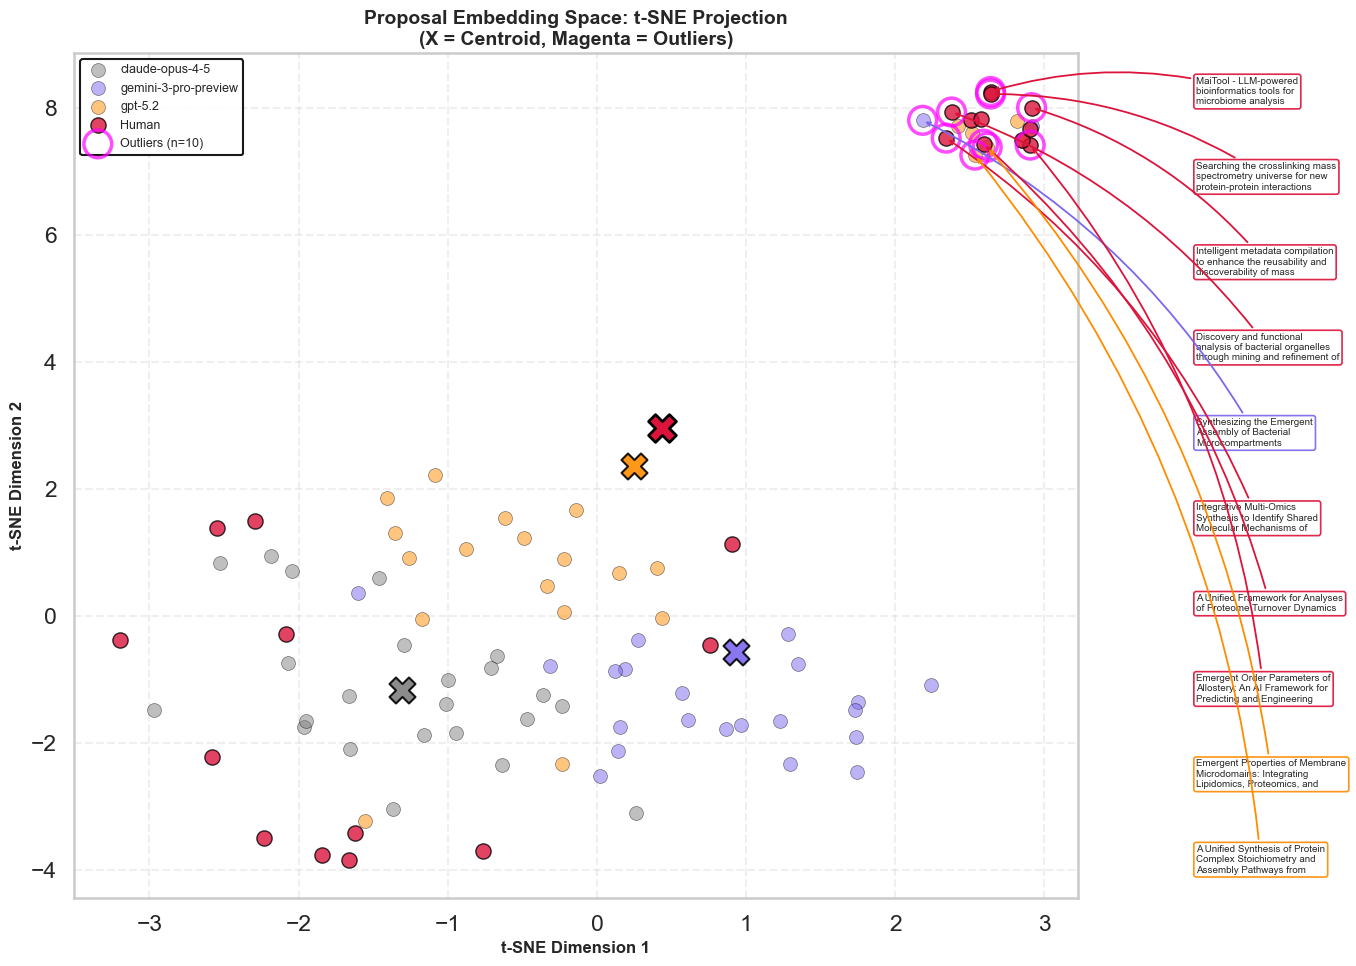


✓ Figure saved to: ../results/figures/rephrased/minimal/embedding_space_tsne.png


In [29]:
# Alternative visualization: t-SNE (complementary to UMAP)
from sklearn.manifold import TSNE

print("\n" + "="*85)
print("ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)")
print("="*85)

# Build labels aligned to embedding order (same approach as UMAP cell)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_tsne = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

# Apply t-SNE dimensionality reduction
print("\nReducing embeddings to 2D using t-SNE...")
print("(This may take a minute...)")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0
)

embeddings_2d_tsne = tsne.fit_transform(all_embeddings_umap)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        pts = embeddings_2d_tsne[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Human
mask_h = labels_tsne == 'Human'
pts_h = embeddings_2d_tsne[mask_h]
ax.scatter(pts_h[:, 0], pts_h[:, 1],
           c=colors['Human'],
           label='Human',
           s=120,
           alpha=0.8,
           edgecolors='black',
           linewidth=1.0,
           marker='o',
           zorder=10)

# Highlight the same outliers (computed from NN distances)
outlier_indices = np.where(outliers)[0]
outlier_coords_plot = embeddings_2d_tsne[outlier_indices]
ax.scatter(outlier_coords_plot[:, 0], outlier_coords_plot[:, 1],
           s=400,
           facecolors='none',
           edgecolors='magenta',
           linewidth=2.5,
           alpha=0.7,
           label=f'Outliers (n={len(outlier_indices)})',
           zorder=12)

# Build a title lookup aligned to the embedding order (human first, then AI)
all_titles_tsne = []
for r in (human_metadata if 'human_metadata' in globals() else []):
    all_titles_tsne.append(r.get('proposal_title', r.get('title', '')))
for r in (ai_metadata if 'ai_metadata' in globals() else []):
    all_titles_tsne.append(r.get('title', r.get('proposal_title', '')))

# ── Stacked, non-overlapping labels with arrows ───────────────────────────────
# Collect (point_x, point_y, title, group) for each outlier, sorted by point y (top→bottom)
outlier_info = sorted(
    [(embeddings_2d_tsne[idx][0],
      embeddings_2d_tsne[idx][1],
      all_titles_tsne[idx] if idx < len(all_titles_tsne) else '',
      labels_tsne[idx])
     for idx in outlier_indices],
    key=lambda p: -p[1]   # descending y so top outlier gets top label
)

# Place label column just past the LEFT edge of all data
x_data_max = embeddings_2d_tsne[:, 0].max()
x_data_min = embeddings_2d_tsne[:, 0].min()
x_label_col = x_data_max + (x_data_max - x_data_min) * 0.18

# Spread labels evenly across the full vertical range of the plot
y_data_max = embeddings_2d_tsne[:, 1].max()
y_data_min = embeddings_2d_tsne[:, 1].min()
n_out = len(outlier_info)
y_label_positions = [
    y_data_max - i * (y_data_max - y_data_min) / max(n_out - 1, 1)
    for i in range(n_out)
]

def wrap_title(title, max_chars=32):
    words = title.split()
    lines, line = [], []
    for w in words:
        line.append(w)
        if len(' '.join(line)) > max_chars:
            lines.append(' '.join(line[:-1]))
            line = [w]
    if line:
        lines.append(' '.join(line))
    return '\n'.join(lines[:3])

for (px, py, title, grp), y_lab in zip(outlier_info, y_label_positions):
    grp_color = colors.get(grp, '#808080')
    ax.annotate(
        wrap_title(title),
        xy=(px, py),                      # tip of arrow → actual point
        xytext=(x_label_col, y_lab),      # label position in stacked column
        fontsize=7,
        verticalalignment='center',
        zorder=20,
        arrowprops=dict(
            arrowstyle='->',
            color=grp_color,
            lw=1.3,
            connectionstyle='arc3,rad=0.15',   # slight curve to reduce crossing
        ),
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor=grp_color,
            linewidth=1.2,
            alpha=0.92,
        ),
    )

# Centroids
centroid_h = pts_h.mean(axis=0)
ax.scatter(centroid_h[0], centroid_h[1],
           c=colors['Human'],
           s=400,
           marker='X',
           edgecolors='black',
           linewidth=2,
           alpha=1.0,
           zorder=15)

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        c2d = embeddings_2d_tsne[mask].mean(axis=0)
        ax.scatter(c2d[0], c2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=14)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposal Embedding Space: t-SNE Projection\n(X = Centroid, Magenta = Outliers)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path = FIGURES_DIR / 'embedding_space_tsne.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to: {out_path}")
print("="*85)


## Analysis 1.3-B: Mean k-NN Outlier Detection (k=5)

This extension complements 1-NN outlier detection by using each proposal's **mean distance to its k nearest neighbors**.

- Metric: cosine distance in original embedding space
- Default: `k=5`
- Outlier rule: top 10% (`> 90th percentile`) of mean k-NN distance

Rationale: this reduces sensitivity to single-neighbor effects and better captures proposals that are broadly isolated from a local neighborhood.

In [30]:
# Mean k-NN outlier detection (default k=5) in original embedding space
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import pandas as pd

print("\n" + "="*85)
print("MEAN k-NN OUTLIER DETECTION (k=5)")
print("="*85)

k_mean_nn = 5

# Build combined embeddings
all_embeddings_mknn = np.vstack([human_embeddings, ai_embeddings])
n_human_mknn = len(human_embeddings)
n_ai_mknn = len(ai_embeddings)

# Build per-row labels aligned to embedding order
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai_mknn:
    ai_model_labels_mknn = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == n_ai_mknn and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels_mknn = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_mknn = np.array((['Human'] * n_human_mknn) + ai_model_labels_mknn)
ai_models_mknn = sorted(list(dict.fromkeys(ai_model_labels_mknn)))

# Pairwise cosine distances
dmat_mknn = cosine_distances(all_embeddings_mknn)
np.fill_diagonal(dmat_mknn, np.inf)

# Mean distance to k nearest neighbors for each proposal
nearest_k = np.partition(dmat_mknn, kth=k_mean_nn-1, axis=1)[:, :k_mean_nn]
mean_knn_dist = nearest_k.mean(axis=1)

# Outlier threshold: top 10%
mean_knn_threshold = float(np.percentile(mean_knn_dist, 90))
outliers_mean_knn = mean_knn_dist > mean_knn_threshold

# Summaries
human_mknn = mean_knn_dist[labels_mknn == 'Human']
ai_mknn = mean_knn_dist[labels_mknn != 'Human']
model_mknn = {m: mean_knn_dist[labels_mknn == m] for m in ai_models_mknn}

print(f"k (neighbors averaged): {k_mean_nn}")
print(f"Outlier threshold (90th percentile of mean k-NN distance): {mean_knn_threshold:.4f}\n")

print(f"{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10} {'Outliers':<10}")
print("-"*110)

h_out = int(outliers_mean_knn[labels_mknn == 'Human'].sum())
print(f"{'Human':<35} {len(human_mknn):<8} {human_mknn.mean():<10.4f} {np.median(human_mknn):<10.4f} {human_mknn.min():<10.4f} {human_mknn.max():<10.4f} {h_out}/{len(human_mknn):<10}")
print()

for m in ai_models_mknn:
    arr = model_mknn[m]
    n_out = int(outliers_mean_knn[labels_mknn == m].sum())
    print(f"{m:<35} {len(arr):<8} {arr.mean():<10.4f} {np.median(arr):<10.4f} {arr.min():<10.4f} {arr.max():<10.4f} {n_out}/{len(arr):<10}")

print()
ai_out = int(outliers_mean_knn[labels_mknn != 'Human'].sum())
print(f"{'All AI (combined)':<35} {len(ai_mknn):<8} {ai_mknn.mean():<10.4f} {np.median(ai_mknn):<10.4f} {ai_mknn.min():<10.4f} {ai_mknn.max():<10.4f} {ai_out}/{len(ai_mknn):<10}")

# Optional comparison with 1-NN outliers if available
if 'outliers' in globals() and 'threshold' in globals() and 'nn_distances' in globals():
    overlap = int((outliers_mean_knn & outliers).sum())
    print("\n" + "-"*110)
    print("Comparison to 1-NN outliers:")
    print(f"  1-NN threshold: {float(threshold):.4f}")
    print(f"  1-NN outliers: {int(outliers.sum())}/{len(outliers)}")
    print(f"  mean-{k_mean_nn}NN outliers: {int(outliers_mean_knn.sum())}/{len(outliers_mean_knn)}")
    print(f"  overlap: {overlap}")

# Save table
all_titles_mknn = []
if 'human_metadata' in globals() and isinstance(human_metadata, list):
    all_titles_mknn.extend([r.get('proposal_title', r.get('title', '')) for r in human_metadata])
if 'ai_metadata' in globals() and isinstance(ai_metadata, list):
    all_titles_mknn.extend([r.get('title', r.get('proposal_title', '')) for r in ai_metadata])

base_cols = {
    'group': labels_mknn,
    f'mean_{k_mean_nn}nn_dist': mean_knn_dist,
    'is_outlier_mean_knn': outliers_mean_knn,
    f'threshold_mean_{k_mean_nn}nn': mean_knn_threshold
}

if len(all_titles_mknn) == len(labels_mknn):
    mknn_df = pd.DataFrame({'title': all_titles_mknn, **base_cols})
else:
    mknn_df = pd.DataFrame(base_cols)

out_csv = TABLES_DIR / f'mean_knn_distances_k{k_mean_nn}.csv'
mknn_df.to_csv(out_csv, index=False)
print(f"\n✓ Saved: {out_csv}")
print("="*85)



MEAN k-NN OUTLIER DETECTION (k=5)
k (neighbors averaged): 5
Outlier threshold (90th percentile of mean k-NN distance): 0.1117

GROUP                               N        Mean       Median     Min        Max        Outliers  
--------------------------------------------------------------------------------------------------------------
Human                               23       0.0849     0.0444     0.0243     0.2272     7/23        

claude-opus-4-5                     23       0.0257     0.0255     0.0223     0.0325     0/23        
gemini-3-pro-preview                23       0.0367     0.0261     0.0212     0.1993     1/23        
gpt-5.2                             23       0.0482     0.0297     0.0223     0.1460     2/23        

All AI (combined)                   69       0.0368     0.0264     0.0212     0.1993     3/69        

--------------------------------------------------------------------------------------------------------------
Comparison to 1-NN outliers:
  1-NN t


VISUALIZATION: mean k-NN outliers (UMAP + t-SNE)


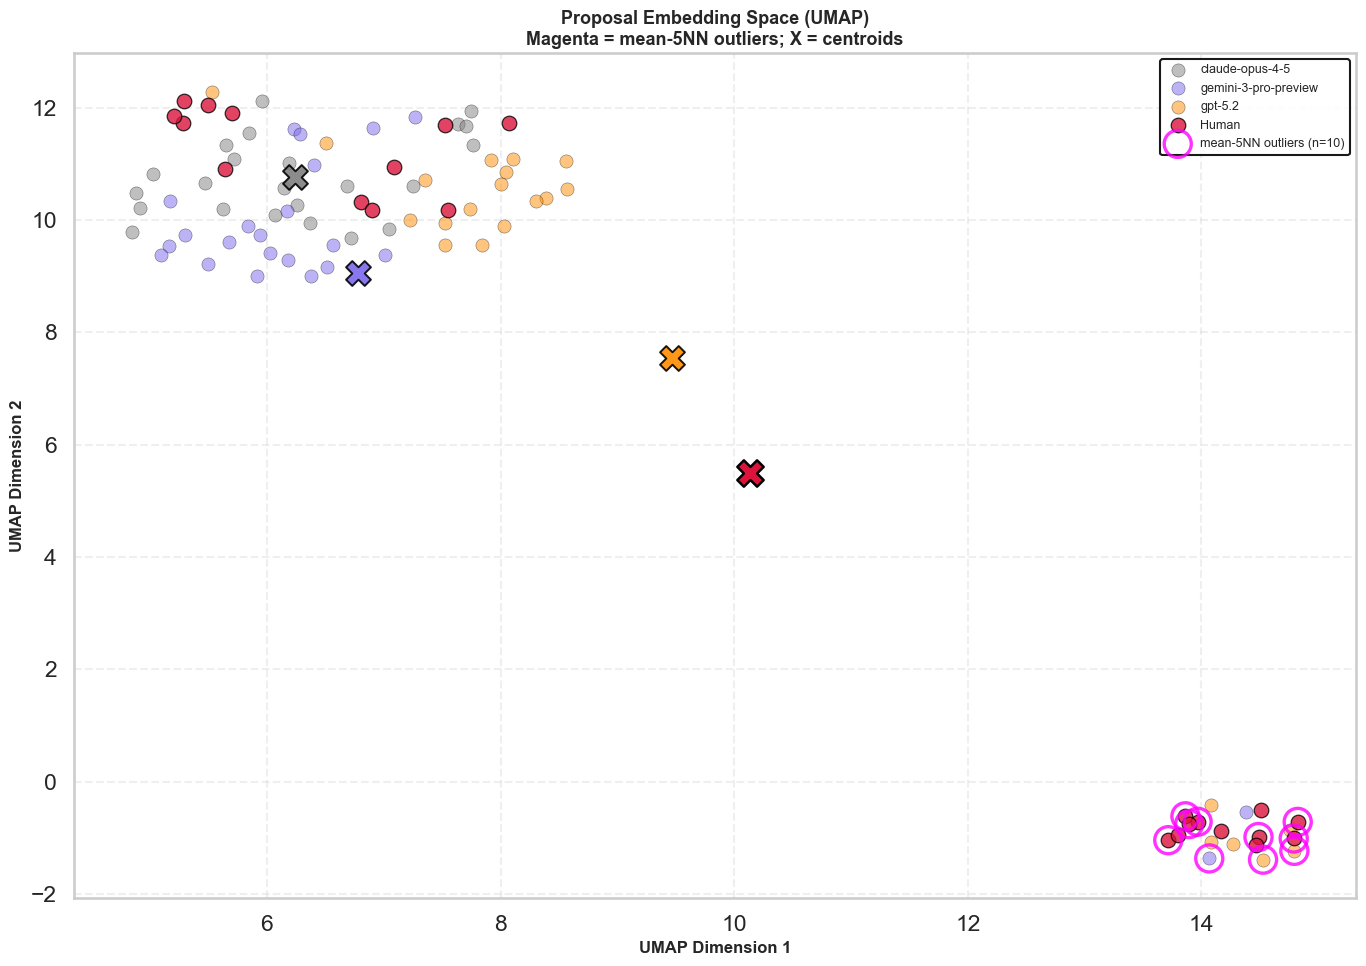

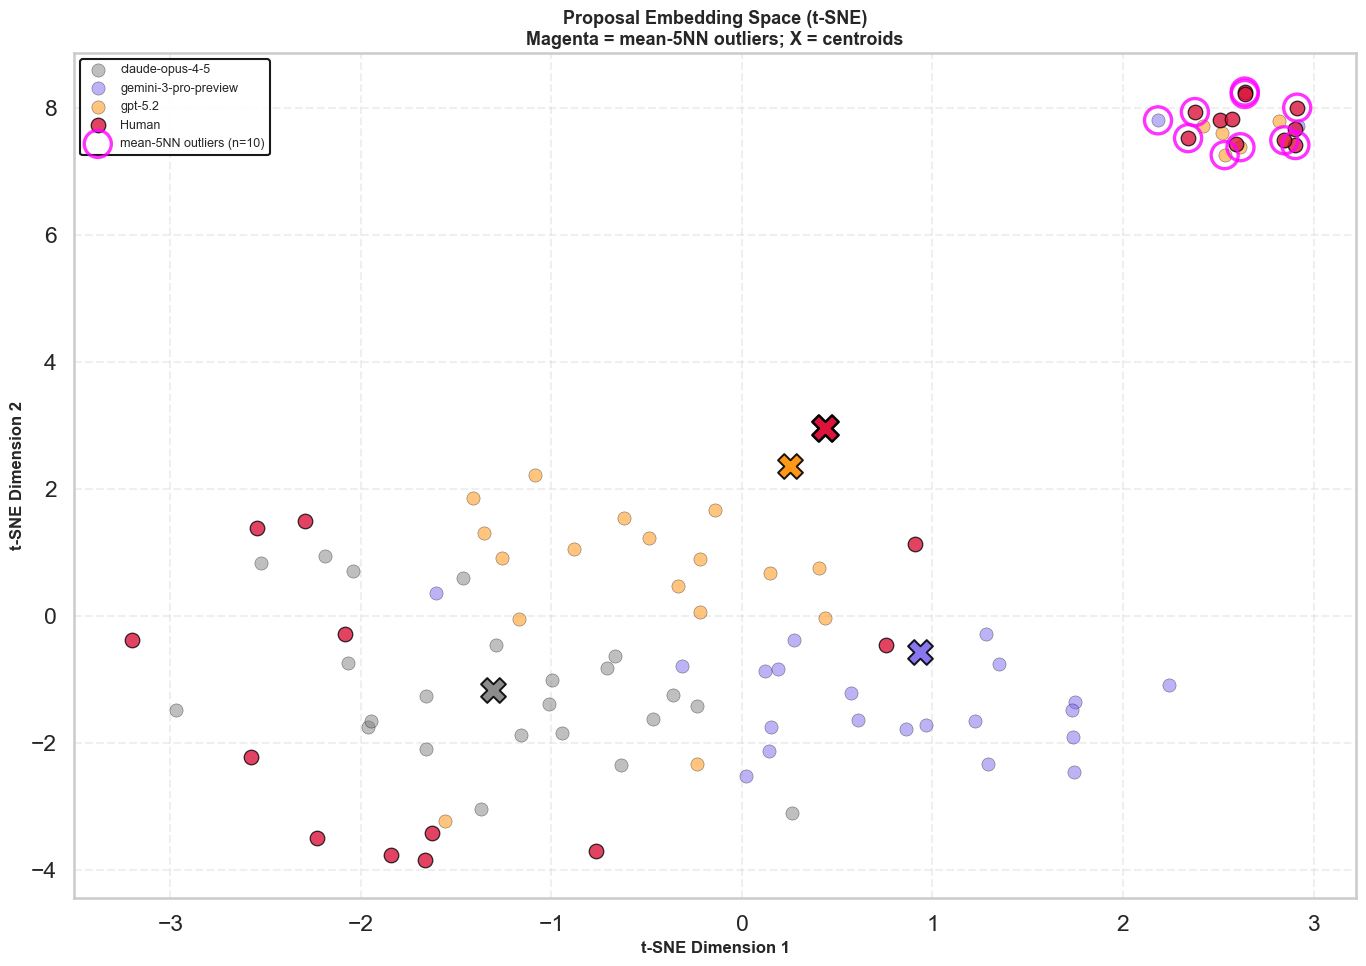

✓ Saved UMAP figure: ../results/figures/rephrased/minimal/embedding_space_umap_mean_knn_outliers_k5.png
✓ Saved t-SNE figure: ../results/figures/rephrased/minimal/embedding_space_tsne_mean_knn_outliers_k5.png


In [31]:
# Visualization: mean k-NN outliers on UMAP + t-SNE
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

if 'mean_knn_dist' not in globals() or 'outliers_mean_knn' not in globals() or 'labels_mknn' not in globals():
    raise RuntimeError("Run the mean k-NN outlier cell first.")

print("\n" + "="*85)
print("VISUALIZATION: mean k-NN outliers (UMAP + t-SNE)")
print("="*85)

# Reuse UMAP coordinates if available and aligned; otherwise recompute
need_recompute_umap = True
if 'embeddings_2d' in globals() and isinstance(embeddings_2d, np.ndarray):
    if embeddings_2d.shape[0] == all_embeddings_mknn.shape[0]:
        emb2d_umap_mknn = embeddings_2d
        need_recompute_umap = False

if need_recompute_umap:
    reducer_mknn = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        random_state=42
    )
    emb2d_umap_mknn = reducer_mknn.fit_transform(all_embeddings_mknn)

# t-SNE
tsne_mknn = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0
)
emb2d_tsne_mknn = tsne_mknn.fit_transform(all_embeddings_mknn)

# Common plotting helper
def plot_proj(ax, emb2d, title):
    # AI models first
    for m in ai_models_mknn:
        mask = labels_mknn == m
        if mask.any():
            pts = emb2d[mask]
            ax.scatter(pts[:, 0], pts[:, 1],
                       c=colors.get(m, '#808080'),
                       label=m,
                       s=90,
                       alpha=0.5,
                       edgecolors='black',
                       linewidth=0.4)

    # Human on top
    mh = labels_mknn == 'Human'
    ph = emb2d[mh]
    ax.scatter(ph[:, 0], ph[:, 1],
               c=colors.get('Human', '#e74c3c'),
               label='Human',
               s=110,
               alpha=0.8,
               edgecolors='black',
               linewidth=0.9,
               marker='o',
               zorder=10)

    # mean-kNN outliers
    oi = np.where(outliers_mean_knn)[0]
    po = emb2d[oi]
    ax.scatter(po[:, 0], po[:, 1],
               s=380,
               facecolors='none',
               edgecolors='magenta',
               linewidth=2.4,
               alpha=0.8,
               label=f'mean-{k_mean_nn}NN outliers (n={len(oi)})',
               zorder=12)

    # Centroids
    ch = ph.mean(axis=0)
    ax.scatter(ch[0], ch[1], c=colors.get('Human', '#e74c3c'), s=360, marker='X',
               edgecolors='black', linewidth=1.8, zorder=15)

    for m in ai_models_mknn:
        mask = labels_mknn == m
        if mask.any():
            c2d = emb2d[mask].mean(axis=0)
            ax.scatter(c2d[0], c2d[1], c=colors.get(m, '#808080'), s=320, marker='X',
                       edgecolors='black', linewidth=1.4, alpha=0.9, zorder=14)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

fig1, ax1 = plt.subplots(1, 1, figsize=(14, 10))
plot_proj(ax1, emb2d_umap_mknn, f'Proposal Embedding Space (UMAP)\nMagenta = mean-{k_mean_nn}NN outliers; X = centroids')
ax1.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
plt.tight_layout()
out_umap = FIGURES_DIR / f'embedding_space_umap_mean_knn_outliers_k{k_mean_nn}.png'
plt.savefig(out_umap, dpi=300, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(14, 10))
plot_proj(ax2, emb2d_tsne_mknn, f'Proposal Embedding Space (t-SNE)\nMagenta = mean-{k_mean_nn}NN outliers; X = centroids')
ax2.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax2.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
plt.tight_layout()
out_tsne = FIGURES_DIR / f'embedding_space_tsne_mean_knn_outliers_k{k_mean_nn}.png'
plt.savefig(out_tsne, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved UMAP figure: {out_umap}")
print(f"✓ Saved t-SNE figure: {out_tsne}")
print("="*85)


---
# PART I-B: Diversity of Main Ideas

Replicate analyses 1.1–1.4 on the **`main_idea` field** — the 3-sentence core-concept
summary generated in Step 3 of the rephrasing pipeline. Each summary captures only the
central scientific contribution (phenomenon studied, methodological idea, unique contribution),
so embedding distances here reflect **conceptual diversity** with minimal stylistic noise.

**Analysis 1-B.5** adds a unique-idea count: how many non-redundant idea concepts does
each group contribute? Two ideas are defined as *overlapping* when their cosine similarity
exceeds **0.8** (i.e., cosine distance < 0.2).

In [32]:
# ── Load main_idea texts and define embedding cache path ────────────────────
MI_EMBEDDINGS_FILE = Path('../data/embeddings/rephrased/proposal_embeddings_main_idea_minimal.pkl')
MI_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)

for _df_name, _df in [('ai_df', ai_df), ('human_df', human_df)]:
    if 'main_idea' not in _df.columns:
        raise RuntimeError(
            f"'main_idea' column missing from {_df_name}. "
            "Re-run rephrase_proposals.py to regenerate the rephrased files."
        )

mi_ai_texts    = ai_df['main_idea'].fillna('').astype(str).tolist()
mi_human_texts = human_df['main_idea'].fillna('').astype(str).tolist()

print(f'AI main ideas:    {len(mi_ai_texts)}')
print(f'Human main ideas: {len(mi_human_texts)}')
print()
print('── Sample AI main idea ──')
print(mi_ai_texts[0][:500])
print()
print('── Sample Human main idea ──')
print(mi_human_texts[0][:500])

AI main ideas:    69
Human main ideas: 23

── Sample AI main idea ──
This research addresses the lack of systematic links between biomolecular condensate sequence features and their emergent material properties across species. The study employs a multimodal machine learning framework to integrate fragmented biophysical measurements, imaging data, and functional genomics into a unified model. This project establishes a predictive quantitative map that defines universal design principles for condensate behavior and provides a comprehensive benchmark.

── Sample Human main idea ──
This research addresses the absence of a predictive framework for quantifying allosteric regulation across diverse protein systems by integrating dynamics. The study employs a physics informed data science approach that maps molecular simulations and evolutionary patterns into unified coordinate systems. This project establishes a universal theory of allostery to enable the rational design of synthetic regulator

In [33]:
# ── Embed main ideas (or load cached embeddings) ────────────────────────────
if MI_EMBEDDINGS_FILE.exists():
    print(f'Loading cached main-idea embeddings: {MI_EMBEDDINGS_FILE.name}')
    _mi_cache    = retrieve_embeddings(str(MI_EMBEDDINGS_FILE))
    mi_ai_emb    = _mi_cache['ai_embeddings']
    mi_human_emb = _mi_cache['human_embeddings']
    print(f'  AI:    {mi_ai_emb.shape}')
    print(f'  Human: {mi_human_emb.shape}')
else:
    print('No cache found — embedding main ideas now (BioLinkBERT must be in memory)...')
    if 'get_embeddings' not in globals():
        raise RuntimeError('get_embeddings() not defined. Run the BioLinkBERT loading cells first.')
    print('Embedding AI main ideas...')
    mi_ai_emb = get_embeddings(mi_ai_texts)
    print(f'✓ AI shape: {mi_ai_emb.shape}')
    print('Embedding human main ideas...')
    mi_human_emb = get_embeddings(mi_human_texts)
    print(f'✓ Human shape: {mi_human_emb.shape}')
    with open(MI_EMBEDDINGS_FILE, 'wb') as _f:
        pickle.dump({
            'ai_embeddings':    mi_ai_emb,
            'human_embeddings': mi_human_emb,
            'model_name':       model_name if 'model_name' in globals() else 'BioLinkBERT-large',
            'timestamp':        datetime.now().isoformat(),
        }, _f)
    print(f'✓ Saved to {MI_EMBEDDINGS_FILE}  ({MI_EMBEDDINGS_FILE.stat().st_size/1024/1024:.2f} MB)')

# Per-model embedding slices (aligned to ai_df row order)
mi_model_emb_dict = {}
for _m in ai_models:
    _mask = (ai_df['model'] == _m).values
    mi_model_emb_dict[_m] = mi_ai_emb[_mask]

print()
print('Per-model main-idea embedding shapes:')
for _m, _e in mi_model_emb_dict.items():
    print(f'  {_m}: {_e.shape}')

Loading cached main-idea embeddings: proposal_embeddings_main_idea_minimal.pkl
  AI:    (69, 1024)
  Human: (23, 1024)

Per-model main-idea embedding shapes:
  claude-opus-4-5: (23, 1024)
  gemini-3-pro-preview: (23, 1024)
  gpt-5.2: (23, 1024)


## Analysis 1-B.1: Within-Group Pairwise Diversity of Main Ideas

Compare pairwise cosine distances within each group computed on **main_idea** embeddings.
Higher distance = more conceptually diverse ideas within the group.

In [34]:
print('='*85)
print('ANALYSIS 1-B.1: PAIRWISE DIVERSITY — MAIN IDEAS')
print('='*85)

mi_ai_pairwise    = compute_pairwise_distances(mi_ai_emb)
mi_human_pairwise = compute_pairwise_distances(mi_human_emb)

mi_model_pairwise = {
    _m: compute_pairwise_distances(mi_model_emb_dict[_m])
    for _m in ai_models if len(mi_model_emb_dict[_m]) > 1
}

mi_human_pm  = proposal_mean_pairwise_distances(mi_human_emb)
mi_ai_pm     = proposal_mean_pairwise_distances(mi_ai_emb)
mi_model_pm  = {
    _m: proposal_mean_pairwise_distances(mi_model_emb_dict[_m])
    for _m in ai_models if len(mi_model_emb_dict[_m]) > 1
}

print(f"{'GROUP':<35} {'N':>5}  {'Pairs':>7}  {'Mean':>8}  {'Median':>8}  {'SD':>8}")
print('-'*80)
print(f"{'Human':<35} {len(mi_human_emb):>5}  {len(mi_human_pairwise):>7}  {mi_human_pairwise.mean():>8.4f}  {np.median(mi_human_pairwise):>8.4f}  {mi_human_pairwise.std():>8.4f}")
for _m in ai_models:
    if _m in mi_model_pairwise and len(mi_model_pairwise[_m]) > 0:
        _d = mi_model_pairwise[_m]
        _n = len(mi_model_emb_dict[_m])
        print(f"{_m:<35} {_n:>5}  {len(_d):>7}  {_d.mean():>8.4f}  {np.median(_d):>8.4f}  {_d.std():>8.4f}")
print(f"{'All AI (combined)':<35} {len(mi_ai_emb):>5}  {len(mi_ai_pairwise):>7}  {mi_ai_pairwise.mean():>8.4f}  {np.median(mi_ai_pairwise):>8.4f}  {mi_ai_pairwise.std():>8.4f}")

print()
print('STATISTICAL TESTS (proposal-level mean pairwise distance):')
print('='*85)
_mi_comparison_specs = [('All AI', mi_ai_pm)] + [(_m, mi_model_pm[_m]) for _m in ai_models if _m in mi_model_pm]
_mi_pair_results = []
for _gname, _vals in _mi_comparison_specs:
    _res = run_group_comparison(_vals, mi_human_pm, n_permutations=10000, n_boot=5000, random_state=42)
    _res['group'] = _gname
    _mi_pair_results.append(_res)
    _dir = 'MORE diverse' if _res['delta'] > 0 else 'LESS diverse'
    print(f"{_gname} vs Human:  δ={_res['delta']:+.4f} ({_res['delta_interp']}),  MW p={_res['p_value_mw']:.4e},  perm p={_res['p_value_perm']:.4f}  → {_gname} {_dir}")

_mi_pair_df = pd.DataFrame(_mi_pair_results)
_mi_pair_df = apply_multiple_testing(_mi_pair_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
print()
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p(Holm)':<14} {'Perm p(Holm)'}")
print('-'*90)
for _, _row in _mi_pair_df.iterrows():
    _ci = f"[{_row['ci_low']:.4f}, {_row['ci_high']:.4f}]"
    print(f"{_row['group']:<30} {_row['delta']:<10.4f} {_row['obs_diff_mean']:<12.4f} {_ci:<25} {_row['p_value_mw_adj_holm']:<14.4e} {_row['p_value_perm_adj_holm']:.4f}")

ANALYSIS 1-B.1: PAIRWISE DIVERSITY — MAIN IDEAS
GROUP                                   N    Pairs      Mean    Median        SD
--------------------------------------------------------------------------------
Human                                  23      253    0.1534    0.1051    0.1632
claude-opus-4-5                        23      253    0.1155    0.0602    0.1825
gemini-3-pro-preview                   23      253    0.0664    0.0659    0.0143
gpt-5.2                                23      253    0.1650    0.0641    0.2305
All AI (combined)                      69     2346    0.1198    0.0680    0.1736

STATISTICAL TESTS (proposal-level mean pairwise distance):
All AI vs Human:  δ=-0.9030 (large),  MW p=1.0740e-10,  perm p=0.2834  → All AI LESS diverse
claude-opus-4-5 vs Human:  δ=-0.9130 (large),  MW p=1.1930e-07,  perm p=0.4746  → claude-opus-4-5 LESS diverse
gemini-3-pro-preview vs Human:  δ=-1.0000 (large),  MW p=6.6369e-09,  perm p=0.0001  → gemini-3-pro-preview LESS diverse


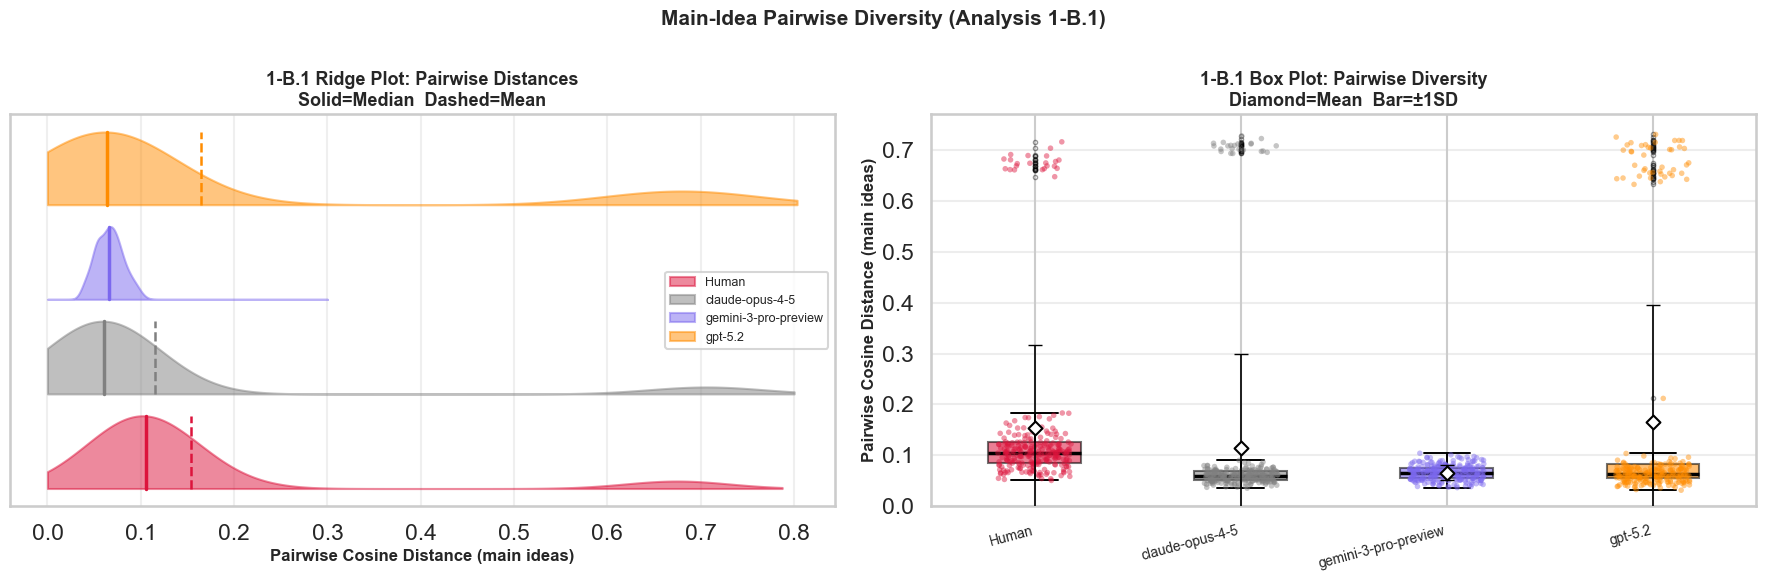

✓ Saved: ../results/figures/rephrased/minimal/mi_pairwise_diversity.png


In [35]:
# Visualization: ridge plot + box plot for main-idea pairwise diversity
from scipy.stats import gaussian_kde

_mi_group_order = ['Human'] + [_m for _m in ai_models if _m in mi_model_pairwise and len(mi_model_pairwise[_m]) > 0]
_mi_pairwise_by_group = {
    'Human': mi_human_pairwise,
    **{_m: mi_model_pairwise[_m] for _m in ai_models if _m in mi_model_pairwise},
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# LEFT: Ridge plot
ax = axes[0]
RIDGE_H, RIDGE_G = 1.0, 0.3
offset = 0
for _grp in _mi_group_order:
    _d = _mi_pairwise_by_group[_grp]
    _c = colors.get(_grp, 'gray')
    if len(_d) > 1:
        _kde = gaussian_kde(_d)
        _xr  = np.linspace(0, max(0.3, _d.max() * 1.1), 400)
        _dn  = _kde(_xr); _dn = _dn / _dn.max() * RIDGE_H
        ax.fill_between(_xr, offset + _dn, offset, color=_c, alpha=0.5, edgecolor=_c, lw=1.5, label=_grp)
        ax.plot([np.median(_d)]*2, [offset, offset+RIDGE_H], color=_c, lw=2.5)
        ax.plot([np.mean(_d)]*2,   [offset, offset+RIDGE_H], color=_c, lw=1.8, ls='--')
        offset += RIDGE_H + RIDGE_G
ax.set_xlabel('Pairwise Cosine Distance (main ideas)', fontsize=12, fontweight='bold')
ax.set_yticks([])
ax.set_title('1-B.1 Ridge Plot: Pairwise Distances\nSolid=Median  Dashed=Mean', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')

# RIGHT: Box plot with jitter
ax2 = axes[1]
_box_arrays = [_mi_pairwise_by_group[_g] for _g in _mi_group_order]
_bp = ax2.boxplot(_box_arrays, positions=range(len(_mi_group_order)),
                  patch_artist=True, widths=0.45,
                  medianprops=dict(color='black', lw=2.5),
                  whiskerprops=dict(lw=1.4), capprops=dict(lw=1.4),
                  flierprops=dict(marker='o', ms=3, alpha=0.4, ls='none'))
for _patch, _grp in zip(_bp['boxes'], _mi_group_order):
    _patch.set_facecolor(colors.get(_grp, 'gray')); _patch.set_alpha(0.55); _patch.set_lw(1.5)
_rng2 = np.random.default_rng(42)
for _i, (_grp, _d) in enumerate(zip(_mi_group_order, _box_arrays)):
    _jit = _rng2.uniform(-0.18, 0.18, size=len(_d))
    ax2.scatter(_i + _jit, _d, color=colors.get(_grp, 'gray'), s=16, alpha=0.45, edgecolors='none', zorder=3)
for _i, _d in enumerate(_box_arrays):
    ax2.scatter(_i, np.mean(_d), marker='D', s=50, color='white', edgecolors='black', lw=1.5, zorder=5)
    ax2.errorbar(_i, np.mean(_d), yerr=np.std(_d, ddof=1), fmt='none', ecolor='black', elinewidth=1.2, capsize=5, zorder=4)
ax2.set_xticks(range(len(_mi_group_order)))
ax2.set_xticklabels(_mi_group_order, rotation=15, ha='right', fontsize=10)
ax2.set_ylabel('Pairwise Cosine Distance (main ideas)', fontsize=12, fontweight='bold')
ax2.set_title('1-B.1 Box Plot: Pairwise Diversity\nDiamond=Mean  Bar=±1SD', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.35); ax2.set_ylim(bottom=0)

plt.suptitle('Main-Idea Pairwise Diversity (Analysis 1-B.1)', fontsize=15, fontweight='bold')
plt.tight_layout()
_fig_path = FIGURES_DIR / 'mi_pairwise_diversity.png'
plt.savefig(_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {_fig_path}')

## Analysis 1-B.2: Centroid Dispersion of Main Ideas

Distance from each proposal's main-idea embedding to its group centroid.
Higher dispersion = main ideas spread more widely within the group.

ANALYSIS 1-B.2: CENTROID DISPERSION — MAIN IDEAS
GROUP                                   N      Mean    Median        SD
-----------------------------------------------------------------
Human                                  23    0.0763    0.0475    0.1151
claude-opus-4-5                        23    0.0569    0.0293    0.1266
gemini-3-pro-preview                   23    0.0323    0.0326    0.0082
gpt-5.2                                23    0.0824    0.0349    0.1560
All AI (combined)                      69    0.0609    0.0351    0.1231

STATISTICAL TESTS:
All AI vs Human:  δ=-0.6522 (large),  MW p=3.1350e-06,  perm p=0.5584  → All AI LESS dispersed
claude-opus-4-5 vs Human:  δ=-0.8034 (large),  MW p=3.2012e-06,  perm p=0.4877  → claude-opus-4-5 LESS dispersed
gemini-3-pro-preview vs Human:  δ=-0.7732 (large),  MW p=7.4046e-06,  perm p=0.0001  → gemini-3-pro-preview LESS dispersed
gpt-5.2 vs Human:  δ=-0.6181 (large),  MW p=3.4231e-04,  perm p=1.0000  → gpt-5.2 LESS dispersed


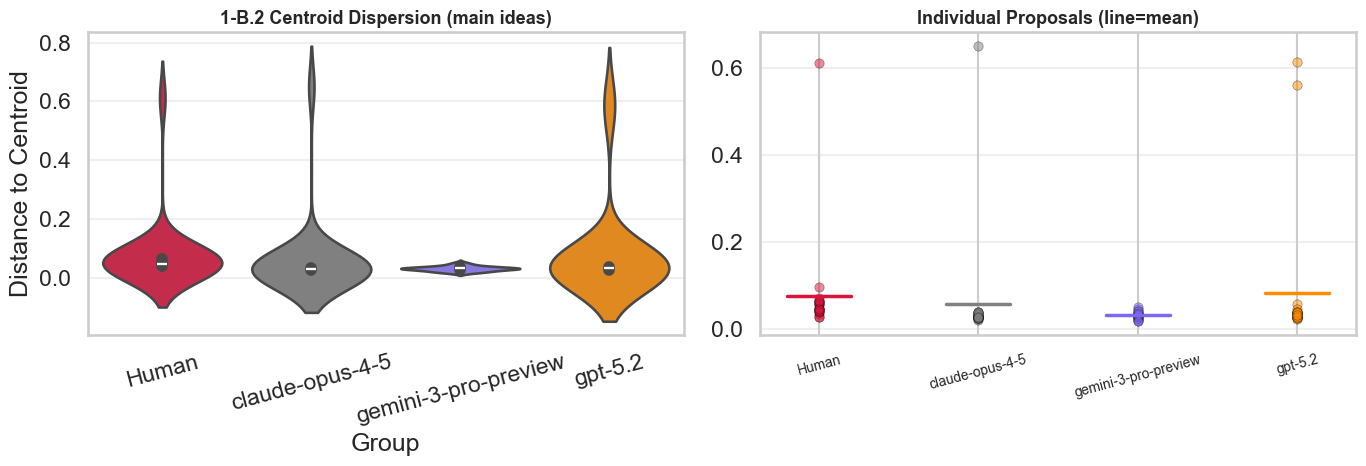

✓ Saved: ../results/figures/rephrased/minimal/mi_centroid_dispersion.png


In [36]:
print('='*85)
print('ANALYSIS 1-B.2: CENTROID DISPERSION — MAIN IDEAS')
print('='*85)

mi_human_cd, _ = compute_centroid_distances(mi_human_emb)
mi_ai_cd,    _ = compute_centroid_distances(mi_ai_emb)
mi_model_cd  = {_m: compute_centroid_distances(mi_model_emb_dict[_m])[0]
                for _m in ai_models if len(mi_model_emb_dict[_m]) > 0}

print(f"{'GROUP':<35} {'N':>5}  {'Mean':>8}  {'Median':>8}  {'SD':>8}")
print('-'*65)
print(f"{'Human':<35} {len(mi_human_cd):>5}  {mi_human_cd.mean():>8.4f}  {np.median(mi_human_cd):>8.4f}  {mi_human_cd.std():>8.4f}")
for _m in ai_models:
    if _m in mi_model_cd:
        _d = mi_model_cd[_m]
        print(f"{_m:<35} {len(_d):>5}  {_d.mean():>8.4f}  {np.median(_d):>8.4f}  {_d.std():>8.4f}")
print(f"{'All AI (combined)':<35} {len(mi_ai_cd):>5}  {mi_ai_cd.mean():>8.4f}  {np.median(mi_ai_cd):>8.4f}  {mi_ai_cd.std():>8.4f}")

print()
print('STATISTICAL TESTS:')
_mi_cd_specs = [('All AI', mi_ai_cd)] + [(_m, mi_model_cd[_m]) for _m in ai_models if _m in mi_model_cd]
_mi_cd_results = []
for _gname, _vals in _mi_cd_specs:
    _res = run_group_comparison(_vals, mi_human_cd, n_permutations=10000, n_boot=5000, random_state=42)
    _res['group'] = _gname
    _mi_cd_results.append(_res)
    _dir = 'MORE dispersed' if _res['delta'] > 0 else 'LESS dispersed'
    print(f"{_gname} vs Human:  δ={_res['delta']:+.4f} ({_res['delta_interp']}),  MW p={_res['p_value_mw']:.4e},  perm p={_res['p_value_perm']:.4f}  → {_gname} {_dir}")

_mi_cd_df = pd.DataFrame(_mi_cd_results)
_mi_cd_df = apply_multiple_testing(_mi_cd_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')

# Visualization: violin + scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_mi_cd_by_grp = {'Human': mi_human_cd, **mi_model_cd}
_mi_cd_order  = ['Human'] + [_m for _m in ai_models if _m in mi_model_cd]

_vdata = []
for _grp in _mi_cd_order:
    for _v in _mi_cd_by_grp[_grp]:
        _vdata.append({'Distance to Centroid': _v, 'Group': _grp})
sns.violinplot(data=pd.DataFrame(_vdata), x='Group', y='Distance to Centroid',
               ax=axes[0], palette=[colors.get(_g,'gray') for _g in _mi_cd_order],
               order=_mi_cd_order)
axes[0].set_title('1-B.2 Centroid Dispersion (main ideas)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15); axes[0].grid(alpha=0.3, axis='y')

for _i, _grp in enumerate(_mi_cd_order):
    _d = _mi_cd_by_grp[_grp]
    axes[1].scatter([_i]*len(_d), _d, color=colors.get(_grp,'gray'), alpha=0.5, s=45, edgecolors='black', lw=0.4)
    axes[1].plot([_i-0.2, _i+0.2], [_d.mean(), _d.mean()], color=colors.get(_grp,'gray'), lw=2.5)
axes[1].set_xticks(range(len(_mi_cd_order)))
axes[1].set_xticklabels(_mi_cd_order, rotation=15, fontsize=10)
axes[1].set_title('Individual Proposals (line=mean)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
_fig_path = FIGURES_DIR / 'mi_centroid_dispersion.png'
plt.savefig(_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {_fig_path}')

## Analysis 1-B.3: Nearest-Neighbor Distances for Main Ideas

Global nearest-neighbor distances across all proposals (main-idea embeddings).
Ideas far from all others are conceptually isolated; the top-10% are flagged as outliers.

ANALYSIS 1-B.3: NEAREST-NEIGHBOR DISTANCES — MAIN IDEAS
GROUP                                   N   Mean NN   Median NN    Outliers
---------------------------------------------------------------------------
Human                                  23    0.0622      0.0627           9
claude-opus-4-5                        23    0.0400      0.0377           0
gemini-3-pro-preview                   23    0.0433      0.0405           0
gpt-5.2                                23    0.0460      0.0396           1
All AI (combined)                      69    0.0431      0.0396           1
NN outlier threshold (90th pctile): 0.0693

STATISTICAL TESTS:
All AI vs Human:  δ=-0.7360 (large),  MW p=1.4274e-07,  perm p=0.0001  → All AI less isolated
claude-opus-4-5 vs Human:  δ=-0.8166 (large),  MW p=2.1928e-06,  perm p=0.0001  → claude-opus-4-5 less isolated
gemini-3-pro-preview vs Human:  δ=-0.7089 (large),  MW p=3.9804e-05,  perm p=0.0002  → gemini-3-pro-preview less isolated
gpt-5.2 vs Human:  δ=

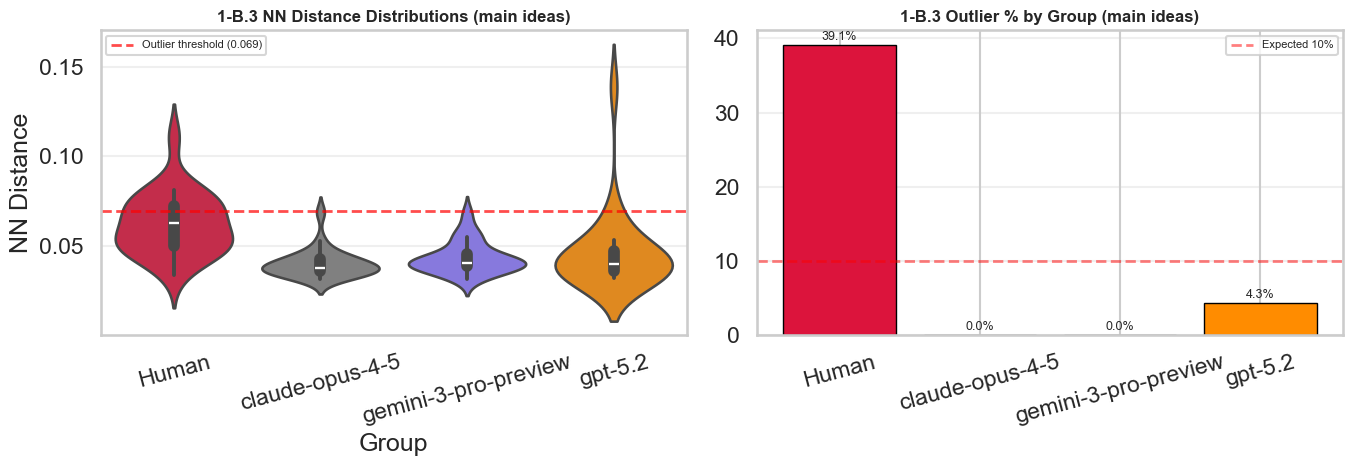

✓ Saved: ../results/figures/rephrased/minimal/mi_nearest_neighbor.png


In [37]:
print('='*85)
print('ANALYSIS 1-B.3: NEAREST-NEIGHBOR DISTANCES — MAIN IDEAS')
print('='*85)

mi_all_emb = np.vstack([mi_human_emb, mi_ai_emb])
mi_n_human = len(mi_human_emb)
mi_n_ai    = len(mi_ai_emb)

# Build aligned label array (same order as PART I)
_mi_ai_labels = [str(_r.get('model','AI')) for _r in ai_metadata] if 'ai_metadata' in globals() else [str(_x) for _x in ai_df['model'].tolist()]
mi_labels = np.array((['Human'] * mi_n_human) + _mi_ai_labels)
mi_models_local = sorted(list(dict.fromkeys(_mi_ai_labels)))

_mi_dist_mat = cosine_distances(mi_all_emb)
np.fill_diagonal(_mi_dist_mat, np.inf)
mi_nn_dists = _mi_dist_mat.min(axis=1)

mi_human_nn  = mi_nn_dists[mi_labels == 'Human']
mi_ai_nn     = mi_nn_dists[mi_labels != 'Human']
mi_model_nn  = {_m: mi_nn_dists[mi_labels == _m] for _m in mi_models_local}

mi_nn_threshold = np.percentile(mi_nn_dists, 90)
mi_outliers     = mi_nn_dists > mi_nn_threshold

print(f"{'GROUP':<35} {'N':>5}  {'Mean NN':>8}  {'Median NN':>10}  {'Outliers':>10}")
print('-'*75)
print(f"{'Human':<35} {len(mi_human_nn):>5}  {mi_human_nn.mean():>8.4f}  {np.median(mi_human_nn):>10.4f}  {mi_outliers[mi_labels=='Human'].sum():>10}")
for _m in mi_models_local:
    _d = mi_model_nn[_m]; _n_out = mi_outliers[mi_labels==_m].sum()
    print(f"{_m:<35} {len(_d):>5}  {_d.mean():>8.4f}  {np.median(_d):>10.4f}  {_n_out:>10}")
print(f"{'All AI (combined)':<35} {len(mi_ai_nn):>5}  {mi_ai_nn.mean():>8.4f}  {np.median(mi_ai_nn):>10.4f}  {mi_outliers[mi_labels!='Human'].sum():>10}")
print(f'NN outlier threshold (90th pctile): {mi_nn_threshold:.4f}')

print()
print('STATISTICAL TESTS:')
_mi_nn_specs = [('All AI', mi_ai_nn)] + [(_m, mi_model_nn[_m]) for _m in mi_models_local]
_mi_nn_results = []
for _gname, _vals in _mi_nn_specs:
    _res = run_group_comparison(_vals, mi_human_nn, n_permutations=10000, n_boot=5000, random_state=42)
    _res['group'] = _gname
    _mi_nn_results.append(_res)
    _dir = 'more isolated' if _res['delta'] > 0 else 'less isolated'
    print(f"{_gname} vs Human:  δ={_res['delta']:+.4f} ({_res['delta_interp']}),  MW p={_res['p_value_mw']:.4e},  perm p={_res['p_value_perm']:.4f}  → {_gname} {_dir}")

_mi_nn_df = pd.DataFrame(_mi_nn_results)
_mi_nn_df = apply_multiple_testing(_mi_nn_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_mi_nn_order = ['Human'] + [_m for _m in mi_models_local if _m in mi_model_nn]
_mi_nn_data  = []
for _grp in _mi_nn_order:
    _d = mi_human_nn if _grp == 'Human' else mi_model_nn[_grp]
    for _v in _d:
        _mi_nn_data.append({'NN Distance': _v, 'Group': _grp})
sns.violinplot(data=pd.DataFrame(_mi_nn_data), x='Group', y='NN Distance',
               ax=axes[0], palette=[colors.get(_g,'gray') for _g in _mi_nn_order], order=_mi_nn_order)
axes[0].axhline(mi_nn_threshold, color='red', ls='--', lw=2, alpha=0.7, label=f'Outlier threshold ({mi_nn_threshold:.3f})')
axes[0].set_title('1-B.3 NN Distance Distributions (main ideas)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis='y')

# Outlier % bar chart
_out_data = [{'Group': 'Human', 'Outlier %': mi_outliers[mi_labels=='Human'].mean()*100}]
for _m in mi_models_local:
    _out_data.append({'Group': _m, 'Outlier %': mi_outliers[mi_labels==_m].mean()*100})
_out_df = pd.DataFrame(_out_data)
_bars = axes[1].bar(_out_df['Group'], _out_df['Outlier %'],
                    color=[colors.get(_g,'gray') for _g in _out_df['Group']], edgecolor='black', lw=1)
axes[1].axhline(10, color='red', ls='--', lw=2, alpha=0.5, label='Expected 10%')
axes[1].set_title('1-B.3 Outlier % by Group (main ideas)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='y')
for _b, _pct in zip(_bars, _out_df['Outlier %']):
    axes[1].text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.3, f'{_pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
_fig_path = FIGURES_DIR / 'mi_nearest_neighbor.png'
plt.savefig(_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {_fig_path}')

## Analysis 1-B.4: Main-Idea Embedding Space (UMAP)

UMAP projection of main-idea embeddings. Magenta rings mark the top-10% NN-distance outliers.
X markers indicate group centroids.

ANALYSIS 1-B.4: UMAP PROJECTION — MAIN IDEAS
✓ UMAP done: 92 points


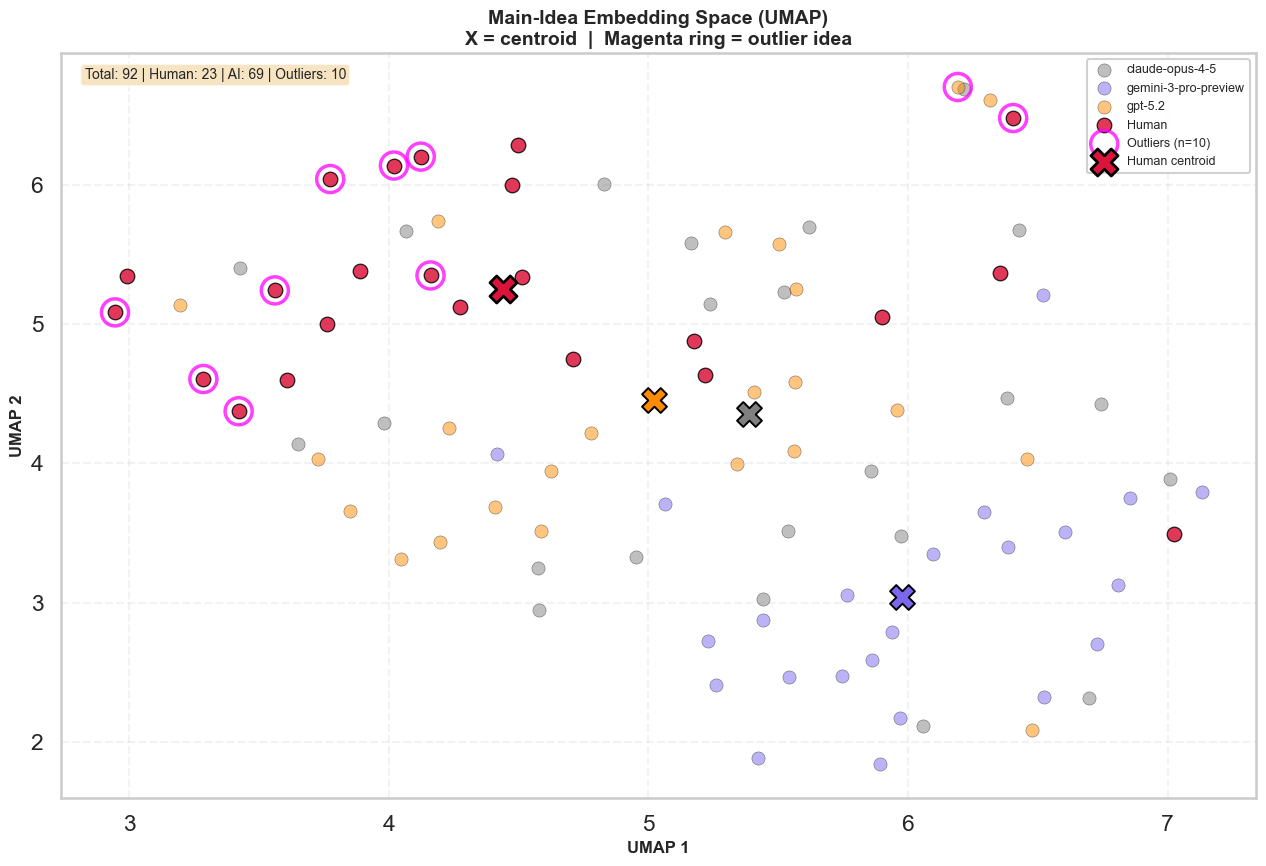

✓ Saved: ../results/figures/rephrased/minimal/mi_umap.png


In [38]:
print('='*85)
print('ANALYSIS 1-B.4: UMAP PROJECTION — MAIN IDEAS')
print('='*85)

import umap as _umap_mod
_mi_reducer = _umap_mod.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
mi_2d = _mi_reducer.fit_transform(mi_all_emb)
mi_human_2d = mi_2d[:mi_n_human]
mi_ai_2d    = mi_2d[mi_n_human:]
print(f'✓ UMAP done: {len(mi_2d)} points')

fig, ax = plt.subplots(figsize=(13, 9))
for _m in mi_models_local:
    _mask = mi_labels == _m
    _pts  = mi_2d[_mask]
    ax.scatter(_pts[:,0], _pts[:,1], c=colors.get(_m,'#808080'), label=_m, s=90, alpha=0.5, edgecolors='black', lw=0.4)
ax.scatter(mi_human_2d[:,0], mi_human_2d[:,1], c=colors['Human'], label='Human', s=110, alpha=0.85, edgecolors='black', lw=0.9, zorder=10)

# Outlier rings
_mi_out_idx = np.where(mi_outliers)[0]
ax.scatter(mi_2d[_mi_out_idx,0], mi_2d[_mi_out_idx,1], s=380, facecolors='none',
           edgecolors='magenta', lw=2.5, alpha=0.75, label=f'Outliers (n={len(_mi_out_idx)})', zorder=5)

# Centroids
ax.scatter(*mi_human_2d.mean(axis=0), c=colors['Human'], s=380, marker='X', edgecolors='black', lw=2, zorder=15, label='Human centroid')
for _m in mi_models_local:
    _mask = mi_labels == _m
    if _mask.any():
        ax.scatter(*mi_2d[_mask].mean(axis=0), c=colors.get(_m,'#808080'), s=320, marker='X', edgecolors='black', lw=1.4, zorder=12)

ax.set_xlabel('UMAP 1', fontsize=12, fontweight='bold')
ax.set_ylabel('UMAP 2', fontsize=12, fontweight='bold')
ax.set_title('Main-Idea Embedding Space (UMAP)\nX = centroid  |  Magenta ring = outlier idea', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25, ls='--')
_info = f'Total: {len(mi_2d)} | Human: {mi_n_human} | AI: {mi_n_ai} | Outliers: {len(_mi_out_idx)}'
ax.text(0.02, 0.98, _info, transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
_fig_path = FIGURES_DIR / 'mi_umap.png'
plt.savefig(_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {_fig_path}')

## Analysis 1-B.5: Unique, Non-Overlapping Idea Concepts

**Definition:** Two ideas are *overlapping* when their cosine similarity exceeds **0.8**
(equivalently, cosine distance < 0.2). Overlapping ideas are treated as expressing the
same concept.

**Method:** Build a similarity graph within each group where an edge connects proposals
with similarity > 0.8. Each **connected component** is one distinct idea concept.
Report:
- **% unique concepts** = connected components / proposals × 100  
  (100% = every idea is distinct; lower = more redundancy within the group)
- **% isolated** = proposals in a size-1 component (no near-duplicate at all)
- **% overlapping pairs** = pairs with similarity > 0.8 out of all within-group pairs

Cross-group overlap reports how many Human ideas have at least one AI counterpart
with similarity > 0.8 (and vice versa).

In [39]:
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim
from collections import deque as _deque

OVERLAP_THRESHOLD = 0.8  # cosine similarity threshold

def _connected_components(embeddings, threshold=OVERLAP_THRESHOLD):
    """Return (n_components, component_labels, component_sizes) for a similarity graph."""
    _sim = _cos_sim(embeddings)
    np.fill_diagonal(_sim, 0)  # exclude self
    _adj = _sim > threshold
    _n   = len(embeddings)
    _visited  = np.zeros(_n, dtype=bool)
    _comp_lbl = np.full(_n, -1, dtype=int)
    _n_comp   = 0
    for _i in range(_n):
        if not _visited[_i]:
            _q = _deque([_i]); _visited[_i] = True
            while _q:
                _nd = _q.popleft(); _comp_lbl[_nd] = _n_comp
                for _j in np.where(_adj[_nd])[0]:
                    if not _visited[_j]:
                        _visited[_j] = True; _q.append(_j)
            _n_comp += 1
    _sizes = np.bincount(_comp_lbl, minlength=_n_comp)
    return _n_comp, _comp_lbl, _sizes

def _overlap_stats(embeddings, name, threshold=OVERLAP_THRESHOLD):
    _n = len(embeddings)
    _nc, _lbl, _sz = _connected_components(embeddings, threshold)
    _isolated = int((_sz == 1).sum())
    _sim = _cos_sim(embeddings); np.fill_diagonal(_sim, 0)
    _n_pairs  = _n * (_n - 1) // 2
    _n_overlap = int(np.triu(_sim > threshold, k=1).sum())
    return {
        'Group':              name,
        'N proposals':        _n,
        'N distinct concepts': _nc,
        '% unique concepts':  round(_nc / _n * 100, 1),
        'N isolated':         _isolated,
        '% isolated':         round(_isolated / _n * 100, 1),
        'N overlap pairs':    _n_overlap,
        'N total pairs':      _n_pairs,
        '% overlap pairs':    round(_n_overlap / _n_pairs * 100, 1) if _n_pairs else 0.0,
    }

print('='*85)
print(f'ANALYSIS 1-B.5: UNIQUE NON-OVERLAPPING IDEAS  (threshold = {OVERLAP_THRESHOLD})')
print('='*85)

# Within-group stats
_within_rows = [_overlap_stats(mi_human_emb, 'Human')]
for _m in ai_models:
    if _m in mi_model_emb_dict:
        _within_rows.append(_overlap_stats(mi_model_emb_dict[_m], _m))
_within_rows.append(_overlap_stats(mi_ai_emb, 'All AI (combined)'))

mi_overlap_df = pd.DataFrame(_within_rows)
print()
print('── Within-group overlap ──')
print(mi_overlap_df.to_string(index=False))

# Cross-group overlap: how many Human ideas overlap with ≥1 AI idea (and vice versa)?
print()
print('── Cross-group overlap (Human ↔ All AI) ──')
_cross_sim = _cos_sim(mi_human_emb, mi_ai_emb)
_human_has_ai_twin  = (_cross_sim > OVERLAP_THRESHOLD).any(axis=1)   # per human idea
_ai_has_human_twin  = (_cross_sim > OVERLAP_THRESHOLD).any(axis=0)   # per AI idea
print(f'Human ideas with ≥1 AI counterpart (sim>{OVERLAP_THRESHOLD}): {_human_has_ai_twin.sum()}/{mi_n_human} ({_human_has_ai_twin.mean()*100:.1f}%)')
print(f'AI ideas with ≥1 Human counterpart (sim>{OVERLAP_THRESHOLD}): {_ai_has_human_twin.sum()}/{mi_n_ai} ({_ai_has_human_twin.mean()*100:.1f}%)')

# Per-model cross-group overlap
print()
print('── Per-model cross-group overlap with Human ──')
for _m in ai_models:
    if _m in mi_model_emb_dict:
        _cs = _cos_sim(mi_human_emb, mi_model_emb_dict[_m])
        _h_twin = (_cs > OVERLAP_THRESHOLD).any(axis=1).mean() * 100
        _a_twin = (_cs > OVERLAP_THRESHOLD).any(axis=0).mean() * 100
        print(f'  {_m:<35}  Human→AI twin: {_h_twin:.1f}%   AI→Human twin: {_a_twin:.1f}%')

# Save table
mi_overlap_df.to_csv(TABLES_DIR / 'mi_unique_ideas.csv', index=False)
print()
print(f'✓ Saved: {TABLES_DIR}/mi_unique_ideas.csv')

ANALYSIS 1-B.5: UNIQUE NON-OVERLAPPING IDEAS  (threshold = 0.8)

── Within-group overlap ──
               Group  N proposals  N distinct concepts  % unique concepts  N isolated  % isolated  N overlap pairs  N total pairs  % overlap pairs
               Human           23                    2                8.7           1         4.3              231            253             91.3
     claude-opus-4-5           23                    2                8.7           1         4.3              231            253             91.3
gemini-3-pro-preview           23                    1                4.3           0         0.0              253            253            100.0
             gpt-5.2           23                    3               13.0           2         8.7              210            253             83.0
   All AI (combined)           69                    2                2.9           0         0.0             2147           2346             91.5

── Cross-group overlap (H

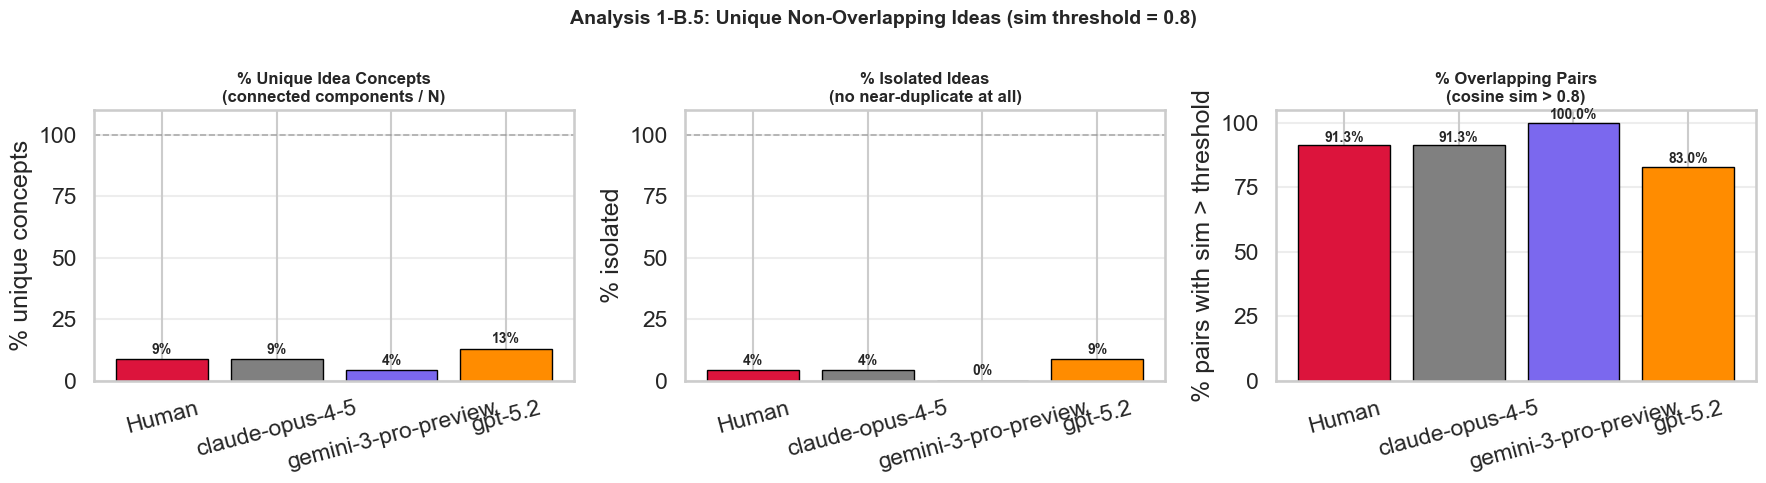

✓ Saved: ../results/figures/rephrased/minimal/mi_unique_ideas.png


In [40]:
# Visualization: unique concepts % and overlap pairs % side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_grp_order_w = ['Human'] + [_m for _m in ai_models if any(r['Group']==_m for _,r in mi_overlap_df.iterrows())]
_plot_df = mi_overlap_df[mi_overlap_df['Group'].isin(_grp_order_w)].set_index('Group').loc[_grp_order_w]
_bar_colors = [colors.get(_g,'gray') for _g in _grp_order_w]

# Panel 1: % unique concepts
axes[0].bar(_plot_df.index, _plot_df['% unique concepts'], color=_bar_colors, edgecolor='black', lw=1)
axes[0].axhline(100, color='gray', ls='--', lw=1.2, alpha=0.6, label='100% (all unique)')
axes[0].set_ylim(0, 110)
axes[0].set_title('% Unique Idea Concepts\n(connected components / N)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% unique concepts')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.35)
for _bar, _val in zip(axes[0].patches, _plot_df['% unique concepts']):
    axes[0].text(_bar.get_x()+_bar.get_width()/2, _bar.get_height()+1, f'{_val:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 2: % isolated (no near-duplicate)
axes[1].bar(_plot_df.index, _plot_df['% isolated'], color=_bar_colors, edgecolor='black', lw=1)
axes[1].axhline(100, color='gray', ls='--', lw=1.2, alpha=0.6)
axes[1].set_ylim(0, 110)
axes[1].set_title('% Isolated Ideas\n(no near-duplicate at all)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% isolated')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.35)
for _bar, _val in zip(axes[1].patches, _plot_df['% isolated']):
    axes[1].text(_bar.get_x()+_bar.get_width()/2, _bar.get_height()+1, f'{_val:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 3: % overlapping pairs
axes[2].bar(_plot_df.index, _plot_df['% overlap pairs'], color=_bar_colors, edgecolor='black', lw=1)
axes[2].set_title(f'% Overlapping Pairs\n(cosine sim > {OVERLAP_THRESHOLD})', fontsize=12, fontweight='bold')
axes[2].set_ylabel('% pairs with sim > threshold')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', alpha=0.35)
for _bar, _val in zip(axes[2].patches, _plot_df['% overlap pairs']):
    axes[2].text(_bar.get_x()+_bar.get_width()/2, _bar.get_height()+0.2, f'{_val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle(f'Analysis 1-B.5: Unique Non-Overlapping Ideas (sim threshold = {OVERLAP_THRESHOLD})', fontsize=14, fontweight='bold')
plt.tight_layout()
_fig_path = FIGURES_DIR / 'mi_unique_ideas.png'
plt.savefig(_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {_fig_path}')

# PART II: NOVELTY

Can AI create more novel proposals than teams of human scientists?

We'll compare how far proposals are from existing literature (PubMed corpus).

## Step 1: Load Literature Corpus

Load the 350 PubMed abstracts from `data/literature/call-relevant-corpus.json`.

In [41]:
import json

# Load literature corpus
print("="*85)
print("LOADING LITERATURE CORPUS")
print("="*85)

with open('../data/literature/relevant-corpus-from-pubmed.json', 'r') as f:
    corpus_data = json.load(f)

articles = corpus_data['articles']
print(f"\n✓ Loaded {len(articles)} PubMed articles")
print(f"  Search queries: {len(corpus_data['search_queries'])}")

# Extract title and abstract for each article
corpus_texts = []
for article in articles:
    title = article.get('title', '')
    abstract = article.get('abstract', '')
    # Combine title and abstract (same format as we'll use for proposals)
    text = f"Title: {title}\n\nAbstract: {abstract}"
    corpus_texts.append(text)

print(f"\n✓ Prepared {len(corpus_texts)} literature texts")
print(f"  Average length: {np.mean([len(t) for t in corpus_texts]):.0f} characters")
print("="*85)

LOADING LITERATURE CORPUS

✓ Loaded 973 PubMed articles
  Search queries: 33

✓ Prepared 973 literature texts
  Average length: 1331 characters


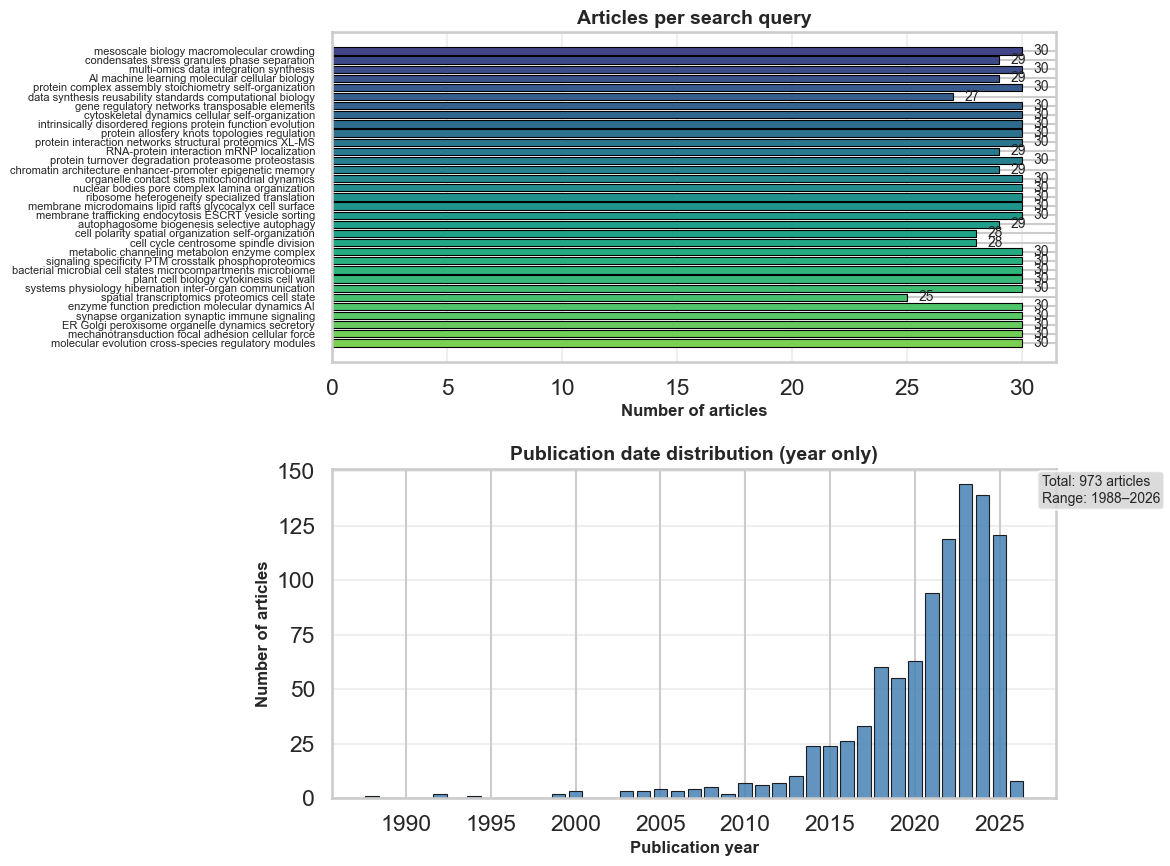

✓ Figure saved to: results/figures/rephrased/literature_corpus_overview.png

SEARCH TERMS (QUERIES) USED PER CATEGORY

• mesoscale biology macromolecular crowding (n=30 articles):
  ("mesoscale" OR "mesoscopic" OR "macromolecular crowding" OR "cellular crowding") AND ("protein" OR "biomolecular" OR "cellular" OR "organelle" OR "diffusion")

• condensates stress granules phase separation (n=29 articles):
  ("biomolecular condensates" OR "phase separation" OR "stress granule" OR "viral inclusion body" OR "viral factory") AND ("cell biology" OR "molecular biology" OR "assembly" OR "RNA")

• multi-omics data integration synthesis (n=30 articles):
  ("multi-omics" OR "multiomics" OR "integrative omics") AND ("data integration" OR "data synthesis") AND ("molecular" OR "cellular")

• AI machine learning molecular cellular biology (n=29 articles):
  ("machine learning" OR "artificial intelligence" OR "deep learning") AND ("molecular biology" OR "cell biology" OR "proteomics" OR "genomics")

• 

In [42]:
# Visualize literature corpus: articles per query + publication year distribution
import re

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- Panel 1: Articles per search query ---
ax1 = axes[0]
queries = corpus_data['search_queries']
labels = [q['label'] for q in queries]
counts = [q['new_unique_added'] for q in queries]
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(labels)))
bars = ax1.barh(range(len(labels)), counts, color=colors_bar, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=8, ha='right')
ax1.set_xlabel('Number of articles', fontsize=12, fontweight='bold')
ax1.set_title('Articles per search query', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for bar, c in zip(bars, counts):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(c), va='center', fontsize='10')

# --- Panel 2: Publication year distribution ---
ax2 = axes[1]
def parse_year(pub_date):
    if not pub_date or not isinstance(pub_date, str):
        return None
    m = re.match(r'(\d{4})', pub_date.strip())
    return int(m.group(1)) if m else None

years = [parse_year(a.get('publication_date')) for a in articles]
years = [y for y in years if y is not None]
year_counts = pd.Series(years).value_counts().sort_index()

ax2.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_xlabel('Publication year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of articles', fontsize=12, fontweight='bold')
ax2.set_title('Publication date distribution (year only)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
if years:
    ax2.text(0.98, 0.98, f'Total: {len(years)} articles\nRange: {min(years)}–{max(years)}', transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'literature_corpus_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figure saved to: results/figures/rephrased/literature_corpus_overview.png')

# Print search terms (queries) used for each category
print('\n' + '='*85)
print('SEARCH TERMS (QUERIES) USED PER CATEGORY')
print('='*85)
for q in queries:
    print(f"\n• {q['label']} (n={q['new_unique_added']} articles):")
    print(f"  {q['query']}")
print('='*85)

## Step 2: Embed Literature Corpus 

Embed all 350 abstracts using BioLinkBERT-Large (same model used for proposals).

In [43]:
# Embed literature corpus using the same approach (truncated to 512 tokens)
print("="*85)
print("EMBEDDING LITERATURE CORPUS")
print("="*85)
print("Using BioLinkBERT-Large (same as proposals, truncated to 512 tokens)")
print()

# Check if embeddings already exist
literature_embeddings_file = LITERATURE_EMBEDDINGS_FILE

if literature_embeddings_file.exists():
    print(f"✓ Loading cached literature embeddings from {literature_embeddings_file}")
    with open(literature_embeddings_file, 'rb') as f:
        literature_data = pickle.load(f)
        literature_embeddings = literature_data['embeddings']
    print(f"✓ Loaded {len(literature_embeddings)} embeddings")
else:
    print("Embedding literature corpus (this will take a few minutes)...")
    literature_embeddings = get_embeddings(corpus_texts)
    print(f"✓ Literature embeddings shape: {literature_embeddings.shape}")
    
    # Cache for future use
    literature_embeddings_file.parent.mkdir(parents=True, exist_ok=True)
    with open(literature_embeddings_file, 'wb') as f:
        pickle.dump({
            'embeddings': literature_embeddings,
            'model_name': model_name,
            'timestamp': datetime.now().isoformat()
        }, f)
    print(f"✓ Cached embeddings to: {literature_embeddings_file}")

print("="*85)

EMBEDDING LITERATURE CORPUS
Using BioLinkBERT-Large (same as proposals, truncated to 512 tokens)

Embedding literature corpus (this will take a few minutes)...


Embedding texts: 100%|██████████| 122/122 [01:52<00:00,  1.08it/s]

✓ Literature embeddings shape: (973, 1024)
✓ Cached embeddings to: ../data/embeddings/literature/relevant_literature_embeddings.pkl


In [44]:
from sklearn.metrics.pairwise import cosine_distances

# Compute novelty scores
print("="*85)
print("COMPUTING NOVELTY SCORES")
print("="*85)
print("Novelty = Mean distance to 10 nearest neighbors in literature corpus")
print("Higher score = farther from existing work = more novel")
print()

k = 10  # Number of nearest neighbors

def compute_novelty_scores(proposal_embeddings, literature_embeddings, k=10):
    """
    Compute novelty score for each proposal as mean distance to k-NN in literature.
    
    Args:
        proposal_embeddings: Embeddings of proposals (n_proposals, embedding_dim)
        literature_embeddings: Embeddings of literature corpus (n_articles, embedding_dim)
        k: Number of nearest neighbors
        
    Returns:
        novelty_scores: Array of novelty scores (n_proposals,)
        nearest_neighbor_indices: Array of k-NN indices for each proposal (n_proposals, k)
    """
    # Compute distances from each proposal to all literature articles
    distances = cosine_distances(proposal_embeddings, literature_embeddings)
    
    # For each proposal, find k nearest neighbors
    nearest_neighbor_indices = np.argsort(distances, axis=1)[:, :k]
    
    # Novelty score = mean distance to k-NN
    novelty_scores = np.array([
        distances[i, nearest_neighbor_indices[i]].mean()
        for i in range(len(proposal_embeddings))
    ])
    
    return novelty_scores, nearest_neighbor_indices

# Compute novelty for AI proposals
print("Computing novelty scores for AI proposals...")
ai_novelty_scores, ai_nn_indices = compute_novelty_scores(
    ai_embeddings, literature_embeddings, k=k
)

# Compute novelty for Human proposals
print("Computing novelty scores for human proposals...")
human_novelty_scores, human_nn_indices = compute_novelty_scores(
    human_embeddings, literature_embeddings, k=k
)

# Split AI novelty by model (mask-based; do NOT assume contiguous blocks)
if 'ai_df' not in globals() or 'model' not in ai_df.columns:
    raise RuntimeError("ai_df with a 'model' column is required to split AI novelty scores by model")

ai_models = sorted(ai_df['model'].astype(str).unique().tolist())
ai_model_series = ai_df['model'].astype(str).values

model_novelty_scores = {m: ai_novelty_scores[ai_model_series == m] for m in ai_models}

# Display statistics
print(f"\n{'='*85}")
print("NOVELTY SCORE STATISTICS")
print(f"{'='*85}")
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

# Human
print(f"{'Human':<35} {len(human_novelty_scores):<8} {human_novelty_scores.mean():<10.4f} {np.median(human_novelty_scores):<10.4f} {human_novelty_scores.min():<10.4f} {human_novelty_scores.max():<10.4f}")

print()  # Blank line

# Individual AI models
for model in ai_models:
    if model in model_novelty_scores:
        scores = model_novelty_scores[model]
        print(f"{model:<35} {len(scores):<8} {scores.mean():<10.4f} {np.median(scores):<10.4f} {scores.min():<10.4f} {scores.max():<10.4f}")

print()  # Blank line

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_novelty_scores):<8} {ai_novelty_scores.mean():<10.4f} {np.median(ai_novelty_scores):<10.4f} {ai_novelty_scores.min():<10.4f} {ai_novelty_scores.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher novelty score = more distant from existing literature")
print("   - Lower novelty score = more similar to published work")
print("="*85)

COMPUTING NOVELTY SCORES
Novelty = Mean distance to 10 nearest neighbors in literature corpus
Higher score = farther from existing work = more novel

Computing novelty scores for AI proposals...
Computing novelty scores for human proposals...

NOVELTY SCORE STATISTICS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.1307     0.0979     0.0794     0.2430    

claude-opus-4-5                     23       0.0904     0.0906     0.0825     0.0986    
gemini-3-pro-preview                23       0.1010     0.0920     0.0864     0.2099    
gpt-5.2                             23       0.1108     0.0963     0.0880     0.1805    

All AI (combined)                   69       0.1008     0.0925     0.0825     0.2099    

💡 INTERPRETATION:
   - Higher novelty score = more distant from existing literature
   - Lower novelty scor

## Step 4b: Literature-Normalized Novelty Scores (Local Density)

Raw k-NN distances to literature are **corpus-relative**: a score of 0.15 vs 0.10 means one proposal is farther, but neither score is interpretable against an absolute standard — it depends entirely on how densely the corpus covers the topic.

**Why global normalization fails here:** The literature corpus spans ~35 distinct PubMed queries covering very different topics (plant biology, protein allostery, membrane trafficking, hibernation, etc.). A global within-literature baseline averages k-NN distances *across* all these topics, inflating the mean with cross-topic distances. This makes all z-scores artificially low and fails to account for whether a proposal sits in a dense or sparse region of the literature.

**Per-proposal local density normalization:** Instead of one global baseline, we compute a baseline specific to each proposal's neighborhood:

1. Find proposal $p$'s $k$ nearest literature articles $L_p = \{l_1, \dots, l_k\}$
2. Each $l_i$ already has its own within-literature k-NN distance (how far it is from *its* literature neighbors)
3. The **local baseline** for proposal $p$ = mean and std of those $k$ neighbor baselines
4. $z_p = \frac{\text{novelty}_p - \mu_{\text{local},p}}{\sigma_{\text{local},p}}$

**Interpretation:**
- **z > 0**: proposal is farther from its nearest literature than those literature articles are from each other → genuinely novel in that topic area
- **z ≈ 0**: proposal sits at the same distance as typical articles in its topic neighborhood
- **z < 0**: proposal is closer to literature than the local articles are to each other → very similar to existing work

This adapts automatically: proposals near dense literature clusters (e.g., phase separation) are compared against small local baselines, while proposals near sparse topics are compared against larger baselines.

In [45]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np

print("="*85)
print("COMPUTING LITERATURE-NORMALIZED NOVELTY SCORES (LOCAL DENSITY)")
print("="*85)

k = 10  # same k as raw novelty

# ── Step 1: Within-literature baseline for EACH article ──────────────────────
# For each article, its k-NN distance within the corpus (excluding self).
# This tells us "how dense is the literature around this article?"
print(f"Computing within-literature {k}-NN distances for each article...")
lit_dist_matrix = cosine_distances(literature_embeddings, literature_embeddings)
np.fill_diagonal(lit_dist_matrix, np.inf)  # exclude self-distance

lit_knn_indices = np.argsort(lit_dist_matrix, axis=1)[:, :k]
lit_baseline_knn = np.array([
    lit_dist_matrix[i, lit_knn_indices[i]].mean()
    for i in range(len(literature_embeddings))
])

# Global stats (for reference / comparison only)
lit_baseline_mean_global = lit_baseline_knn.mean()
lit_baseline_std_global  = lit_baseline_knn.std()

print(f"\nGlobal within-literature baseline (for reference only):")
print(f"  Mean:   {lit_baseline_mean_global:.4f}")
print(f"  Std:    {lit_baseline_std_global:.4f}")
print(f"  Min:    {lit_baseline_knn.min():.4f}")
print(f"  Max:    {lit_baseline_knn.max():.4f}")

# ── Step 2: Per-proposal local density normalization ─────────────────────────
# For each proposal, use the k-NN indices (already computed in Step 4)
# to find which literature articles are nearest. Then take those articles'
# within-literature k-NN distances as the local baseline.

def compute_local_normalized_novelty(raw_scores, nn_indices, lit_baseline_knn, k=10):
    """
    Normalize each proposal's novelty against the local density of its
    nearest literature neighbors.
    
    For proposal p:
      local_baselines = lit_baseline_knn[nn_indices[p]]  (k values)
      local_mean = mean(local_baselines)
      local_std  = std(local_baselines)
      z_p = (raw_score_p - local_mean) / local_std
      ratio_p = raw_score_p / local_mean
    
    Returns: z_scores, ratios, local_means, local_stds
    """
    n = len(raw_scores)
    z_scores = np.zeros(n)
    ratios = np.zeros(n)
    local_means = np.zeros(n)
    local_stds = np.zeros(n)
    
    for i in range(n):
        neighbor_baselines = lit_baseline_knn[nn_indices[i, :k]]
        local_mean = neighbor_baselines.mean()
        local_std  = neighbor_baselines.std()
        
        local_means[i] = local_mean
        local_stds[i]  = local_std
        
        # Guard against zero std (if all neighbors have identical baselines)
        if local_std > 1e-10:
            z_scores[i] = (raw_scores[i] - local_mean) / local_std
        else:
            z_scores[i] = (raw_scores[i] - local_mean) / lit_baseline_std_global
        
        ratios[i] = raw_scores[i] / local_mean if local_mean > 1e-10 else np.nan
    
    return z_scores, ratios, local_means, local_stds


print("\nComputing per-proposal local density normalization...")

human_novelty_z, human_novelty_ratio, human_local_means, human_local_stds = \
    compute_local_normalized_novelty(human_novelty_scores, human_nn_indices, lit_baseline_knn, k=k)

ai_novelty_z, ai_novelty_ratio, ai_local_means, ai_local_stds = \
    compute_local_normalized_novelty(ai_novelty_scores, ai_nn_indices, lit_baseline_knn, k=k)

model_novelty_z = {}
model_novelty_ratio = {}
for m in ai_models:
    mask = (ai_model_series == m)
    m_raw = model_novelty_scores[m]
    m_nn = ai_nn_indices[mask]
    m_z, m_r, _, _ = compute_local_normalized_novelty(m_raw, m_nn, lit_baseline_knn, k=k)
    model_novelty_z[m] = m_z
    model_novelty_ratio[m] = m_r

# Also keep the global baseline for the visualization cell
lit_baseline_mean = lit_baseline_mean_global
lit_baseline_std  = lit_baseline_std_global

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("="*85)
print("LOCAL-DENSITY NORMALIZED NOVELTY SUMMARY")
print("="*85)
print("  z > 0 → proposal is farther from literature than its nearest articles are from each other")
print("  ratio > 1 → same interpretation; < 1 = closer than local inter-article distances")
print()
print(f"{'GROUP':<35} {'N':<6} {'Raw mean':<12} {'Local z':<12} {'Ratio':<10} {'Local μ':<12} {'Local σ':<10}")
print("-"*95)

# Literature global row (for reference)
print(f"  {'Literature (global baseline)':<33} {len(literature_embeddings):<6} "
      f"{lit_baseline_mean_global:<12.4f} {'0.00':>12} {'1.00':>10} "
      f"{lit_baseline_mean_global:<12.4f} {lit_baseline_std_global:<10.4f}")
print()

groups = [("Human", human_novelty_scores, human_novelty_z, human_novelty_ratio,
           human_local_means, human_local_stds)] + [
    (m, model_novelty_scores[m], model_novelty_z[m], model_novelty_ratio[m],
     ai_local_means[ai_model_series == m], ai_local_stds[ai_model_series == m])
    for m in ai_models
]
for name, raw, z, r, lm, ls in groups:
    print(f"  {name:<33} {len(raw):<6} {raw.mean():<12.4f} {z.mean():<12.4f} "
          f"{r.mean():<10.4f} {lm.mean():<12.4f} {ls.mean():<10.4f}")

print()
print(f"  {'All AI (combined)':<33} {len(ai_novelty_z):<6} "
      f"{ai_novelty_scores.mean():<12.4f} {ai_novelty_z.mean():<12.4f} "
      f"{ai_novelty_ratio.mean():<10.4f} {ai_local_means.mean():<12.4f} "
      f"{ai_local_stds.mean():<10.4f}")
print("="*95)
print()
print("💡 'Local μ' shows the average baseline density around each group's proposals.")
print("   Different Local μ across groups means they target different literature density regions.")
print("   This is exactly why local normalization is needed — global z would conflate topic density with novelty.")

COMPUTING LITERATURE-NORMALIZED NOVELTY SCORES (LOCAL DENSITY)
Computing within-literature 10-NN distances for each article...

Global within-literature baseline (for reference only):
  Mean:   0.1095
  Std:    0.0572
  Min:    0.0233
  Max:    0.3860

Computing per-proposal local density normalization...

LOCAL-DENSITY NORMALIZED NOVELTY SUMMARY
  z > 0 → proposal is farther from literature than its nearest articles are from each other
  ratio > 1 → same interpretation; < 1 = closer than local inter-article distances

GROUP                               N      Raw mean     Local z      Ratio      Local μ      Local σ   
-----------------------------------------------------------------------------------------------
  Literature (global baseline)      973    0.1095               0.00       1.00 0.1095       0.0572    

  Human                             23     0.1307       1.7672       1.2204     0.1054       0.0132    
  claude-opus-4-5                   23     0.0904       1.2462    

In [46]:
print("="*85)
print("STATISTICAL TESTS: Local-Density Normalized Novelty (z-score) — All Groups vs Human")
print("="*85)
print("Same Mann-Whitney + Cliff's delta + permutation test as raw novelty.")
print("z-scores are computed per-proposal against the local literature density")
print("(not a single global baseline).")
print("Primary estimand: mean difference in local z-score (AI - Human).")
print()

comparison_specs_z = [("All AI", ai_novelty_z)] + [
    (model, model_novelty_z[model]) for model in ai_models
]

novelty_z_results = []

for group_name, vals in comparison_specs_z:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human  (local-density z-score novelty)")
    print("-"*85)

    res = run_group_comparison(vals, human_novelty_z,
                               n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    novelty_z_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    direction = "MORE novel" if res['delta'] > 0 else "LESS novel"
    print(f"  → {group_name} proposals are {direction} than human proposals (relative to local corpus density)")
    print("Primary mean z-score difference (AI - Human):")
    print(f"  Observed: {res['obs_diff_mean']:.4f}  |  "
          f"95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]  |  "
          f"Perm p: {res['p_value_perm']:.4f}")

novelty_z_df = pd.DataFrame(novelty_z_results)
novelty_z_df = apply_multiple_testing(novelty_z_df,
                                      p_cols=('p_value_mw', 'p_value_perm'), method='holm')

print()
print("="*85)
print("SUMMARY: Local-Density Normalized Novelty (z-score) with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Δz':<12} {'95% CI':<25} "
      f"{'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in novelty_z_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} "
        f"{row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive Δz = AI more novel relative to local corpus density; Negative = Human more novel")

STATISTICAL TESTS: Local-Density Normalized Novelty (z-score) — All Groups vs Human
Same Mann-Whitney + Cliff's delta + permutation test as raw novelty.
z-scores are computed per-proposal against the local literature density
(not a single global baseline).
Primary estimand: mean difference in local z-score (AI - Human).


-------------------------------------------------------------------------------------
Comparison: All AI vs Human  (local-density z-score novelty)
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 783, p-value: 9.2815e-01
Cliff's Delta:
  δ = -0.0132 (negligible effect)
  → All AI proposals are LESS novel than human proposals (relative to local corpus density)
Primary mean z-score difference (AI - Human):
  Observed: -0.2664  |  95% CI: [-0.8624, 0.2674]  |  Perm p: 0.2243

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human  (

VISUALIZING: Raw vs Local-Density Normalized Novelty Scores


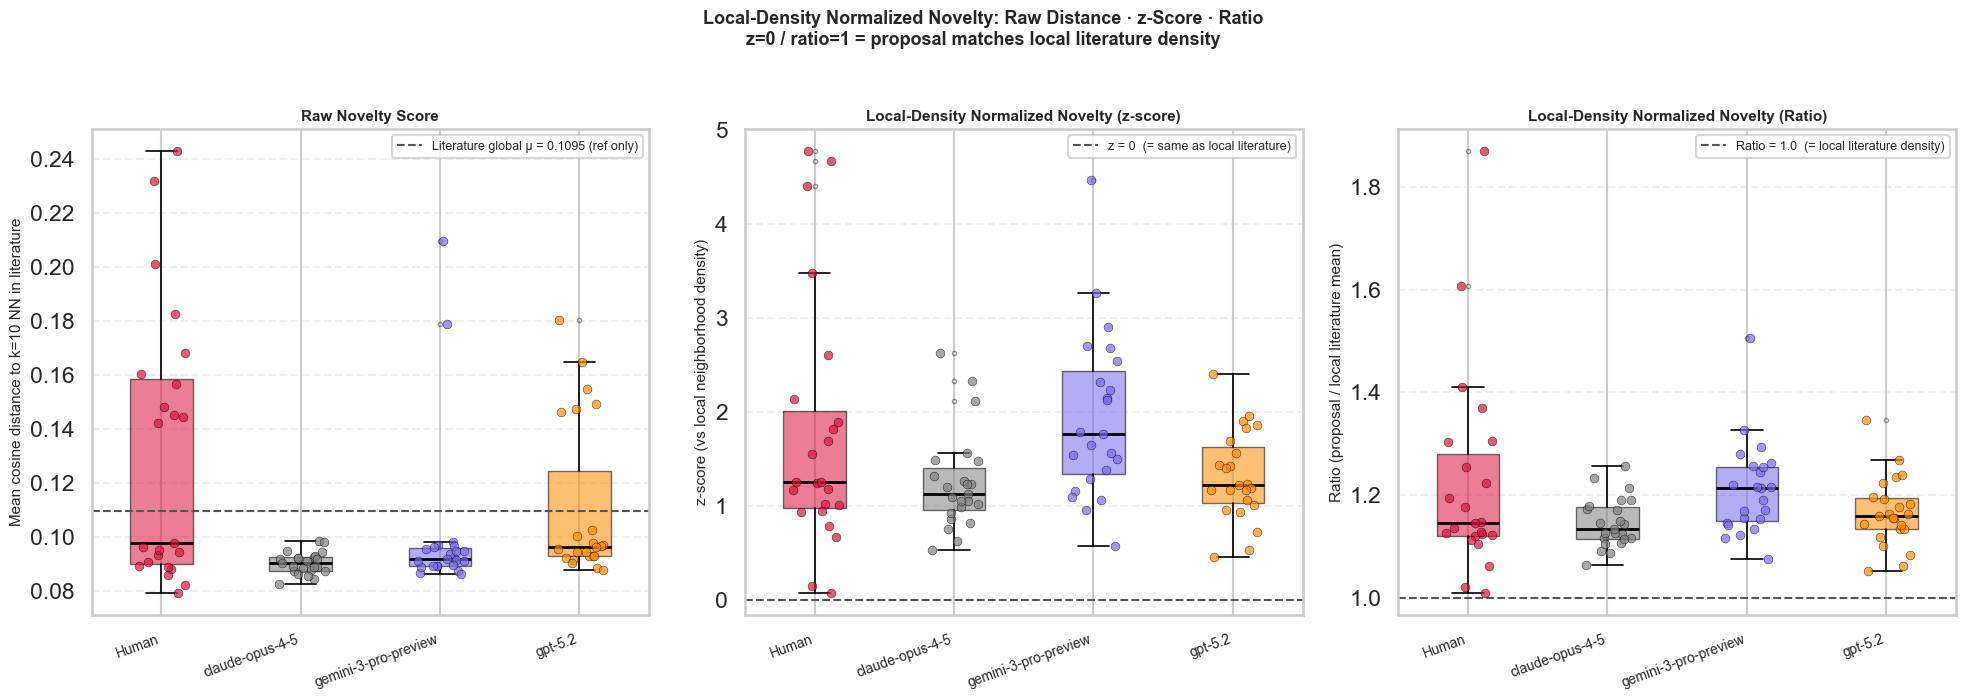


✓ Figure saved to: ../results/figures/rephrased/minimal/novelty_normalized_comparison.png


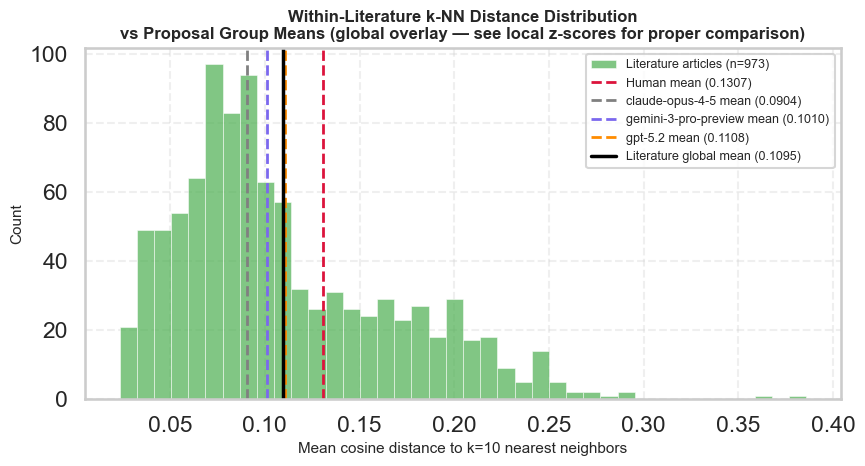

✓ Figure saved to: ../results/figures/rephrased/minimal/novelty_literature_baseline_distribution.png


In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("="*85)
print("VISUALIZING: Raw vs Local-Density Normalized Novelty Scores")
print("="*85)

group_order = ['Human'] + [m for m in ai_models if m in model_novelty_scores]

# Build data containers
raw_data   = {g: (human_novelty_scores if g == 'Human' else model_novelty_scores[g])
               for g in group_order}
z_data     = {g: (human_novelty_z      if g == 'Human' else model_novelty_z[g])
               for g in group_order}
ratio_data = {g: (human_novelty_ratio  if g == 'Human' else model_novelty_ratio[g])
               for g in group_order}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Local-Density Normalized Novelty: Raw Distance · z-Score · Ratio\n'
    'z=0 / ratio=1 = proposal matches local literature density',
    fontsize=13, fontweight='bold', y=1.01
)

def _boxstrip(ax, data_dict, ylabel, title, ref_line=None, ref_label=None):
    """Box + strip plot for a dict of group→scores."""
    positions = list(range(len(group_order)))
    box_data  = [data_dict[g] for g in group_order]
    grp_colors = [colors.get(g, '#808080') for g in group_order]

    bp = ax.boxplot(box_data, positions=positions, widths=0.45,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    for patch, col in zip(bp['boxes'], grp_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.55)

    for i, (g, col) in enumerate(zip(group_order, grp_colors)):
        jitter = np.random.default_rng(42).uniform(-0.18, 0.18, size=len(data_dict[g]))
        ax.scatter(i + jitter, data_dict[g], color=col,
                   s=40, alpha=0.7, edgecolors='black', linewidths=0.4, zorder=3)

    if ref_line is not None:
        ax.axhline(ref_line, color='#555555', linestyle='--', linewidth=1.5,
                   label=ref_label or f'Baseline = {ref_line}')
        ax.legend(fontsize=9, loc='upper right')

    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')

_boxstrip(axes[0], raw_data,
          ylabel='Mean cosine distance to k=10 NN in literature',
          title='Raw Novelty Score',
          ref_line=lit_baseline_mean,
          ref_label=f'Literature global μ = {lit_baseline_mean:.4f} (ref only)')

_boxstrip(axes[1], z_data,
          ylabel='z-score (vs local neighborhood density)',
          title='Local-Density Normalized Novelty (z-score)',
          ref_line=0.0,
          ref_label='z = 0  (= same as local literature)')

_boxstrip(axes[2], ratio_data,
          ylabel='Ratio (proposal / local literature mean)',
          title='Local-Density Normalized Novelty (Ratio)',
          ref_line=1.0,
          ref_label='Ratio = 1.0  (= local literature density)')

plt.tight_layout()
out_path = FIGURES_DIR / 'novelty_normalized_comparison.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure saved to: {out_path}")

# ── Supplementary: within-literature baseline distribution ───────────────────
fig2, ax = plt.subplots(figsize=(9, 5))
ax.hist(lit_baseline_knn, bins=40, color='#4CAF50', alpha=0.7, edgecolor='white', linewidth=0.5,
        label=f'Literature articles (n={len(lit_baseline_knn)})')

for g in group_order:
    raw_vals = raw_data[g]
    ax.axvline(np.mean(raw_vals), color=colors.get(g, 'grey'), linewidth=2,
               linestyle='--', label=f'{g} mean ({np.mean(raw_vals):.4f})')

ax.axvline(lit_baseline_mean, color='black', linewidth=2.5, linestyle='-',
           label=f'Literature global mean ({lit_baseline_mean:.4f})')

ax.set_xlabel('Mean cosine distance to k=10 nearest neighbors', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Within-Literature k-NN Distance Distribution\n'
             'vs Proposal Group Means (global overlay — see local z-scores for proper comparison)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
out_path2 = FIGURES_DIR / 'novelty_literature_baseline_distribution.png'
plt.savefig(out_path2, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {out_path2}")
print("="*85)

## Step 5: Statistical Tests for Novelty

Compare novelty scores between groups using statistical tests.

In [48]:
print("="*85)
print("STATISTICAL TESTS: Novelty Scores (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in novelty score (AI - Human).")

comparison_specs = [('All AI', ai_novelty_scores)] + [
    (model, model_novelty_scores[model])
    for model in ai_models
    if model in model_novelty_scores
]

novelty_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_novelty_scores, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    novelty_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE novel than human proposals")
    else:
        print(f"  → Human proposals are MORE novel than {group_name} proposals")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

novelty_df = pd.DataFrame(novelty_results)
novelty_df = apply_multiple_testing(novelty_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
novelty_comparison_results = novelty_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Novelty Scores with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in novelty_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more novel; Negative = Human more novel")


STATISTICAL TESTS: Novelty Scores (All Groups vs Human)
Primary estimand: mean difference in novelty score (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 564, p-value: 3.8934e-02
Cliff's Delta:
  δ = -0.2892 (small effect)
  → Human proposals are MORE novel than All AI proposals
Primary mean difference (AI - Human):
  Observed difference: -0.0300
  Bootstrap 95% CI: [-0.0510, -0.0101]
  Permutation p-value: 0.0006

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 133, p-value: 4.0025e-03
Cliff's Delta:
  δ = -0.4972 (large effect)
  → Human proposals are MORE novel than claude-opus-4-5 proposa

## Step 6: Visualize Novelty Results

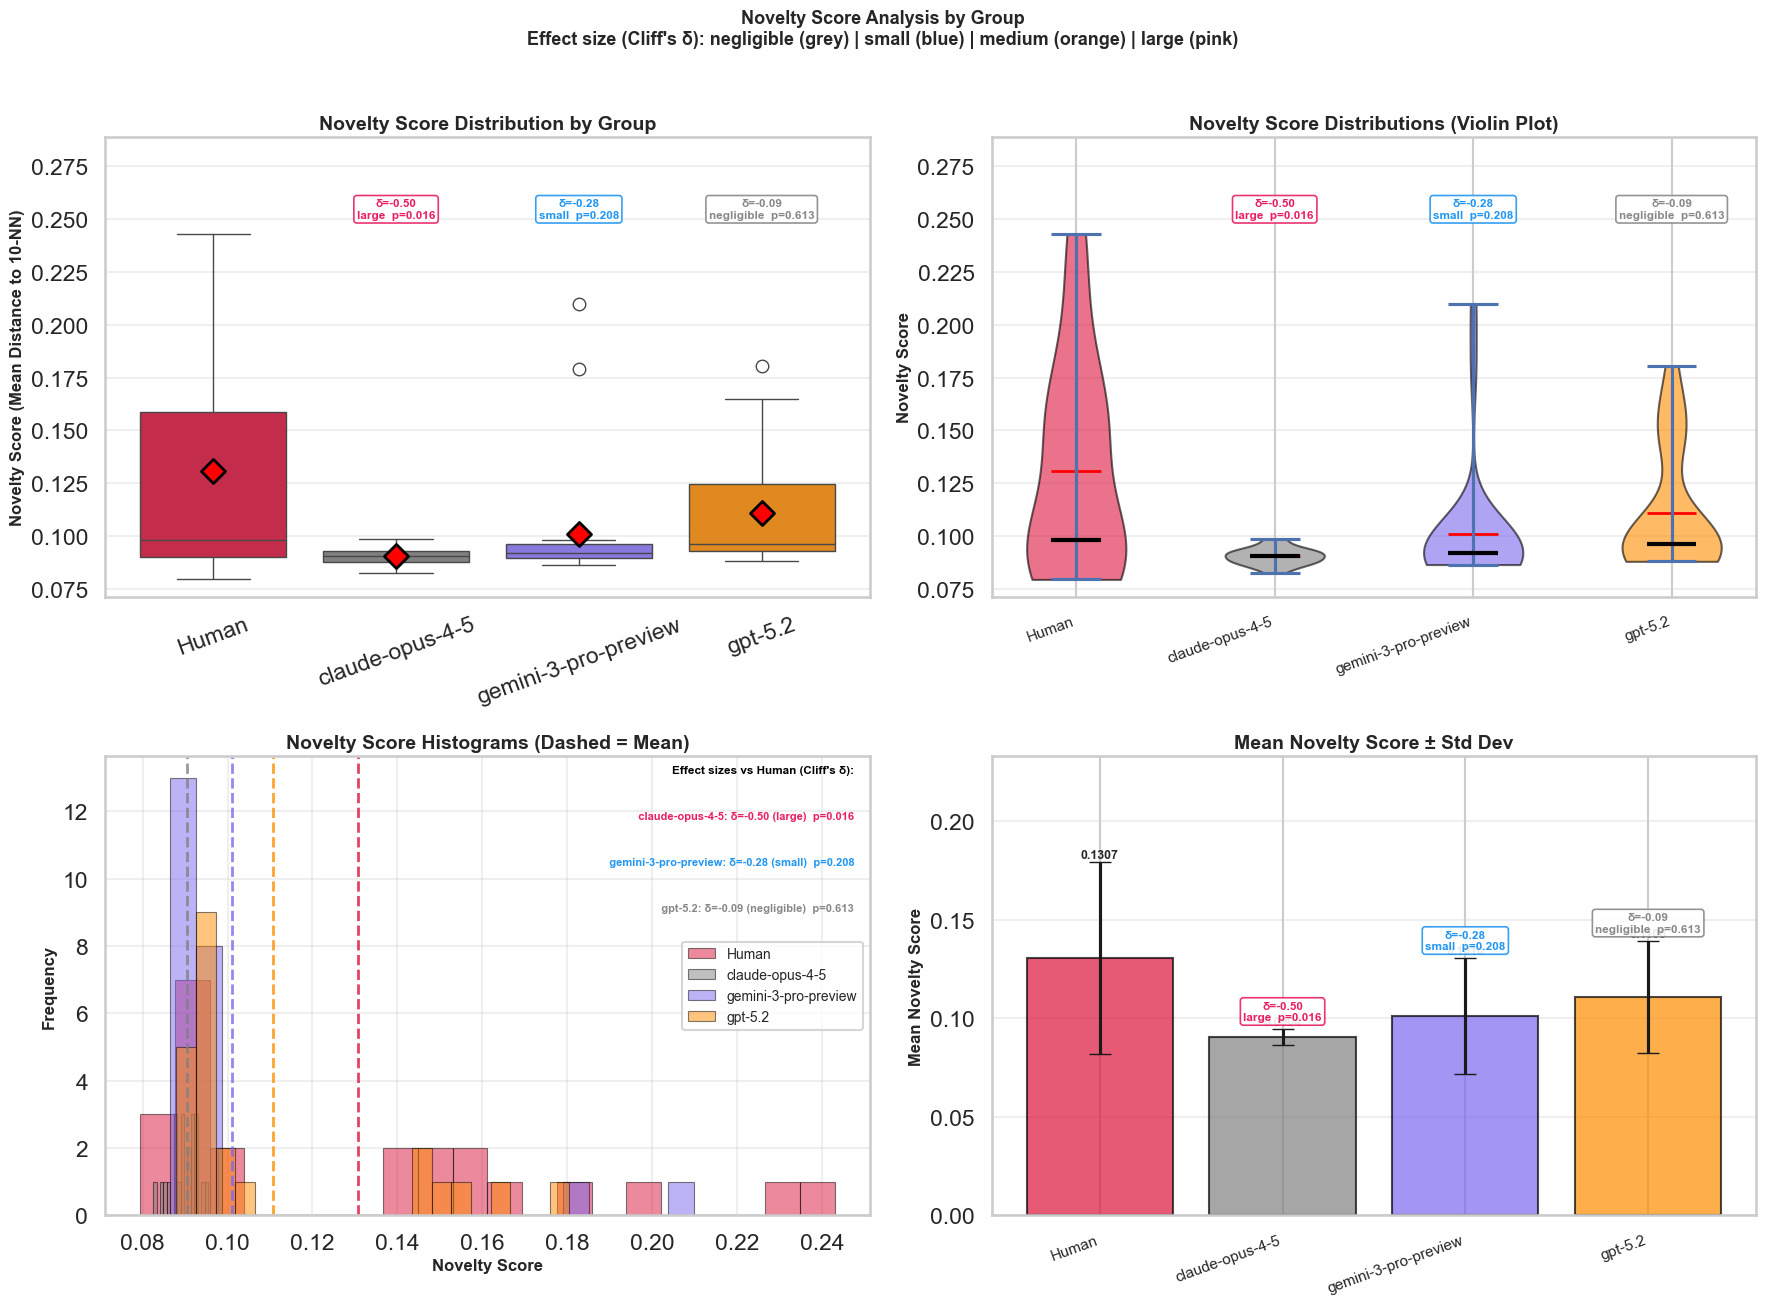


✓ Figure saved to: results/figures/rephrased/novelty_analysis.png


In [49]:
# Visualization: Novelty scores by group
# ── Build effect-size lookup from the stats cell results ──────────────────────
# novelty_comparison_results contains one dict per AI group (vs Human)
# Keys used: 'group', 'delta', 'delta_interp', 'p_value_mw_adj_holm'
_es = {r['group']: r for r in novelty_comparison_results}

_interp_rank = {'negligible': 0, 'small': 1, 'medium': 2, 'large': 3}
_interp_color = {'negligible': '#888888', 'small': '#2196F3',
                 'medium': '#FF9800', 'large': '#E91E63'}

def _es_label(group):
    """Return a two-line annotation string for a group vs Human."""
    if group == 'Human':
        return 'Human\n(reference)'
    r = _es.get(group, {})
    if not r:
        return group
    interp = r.get('delta_interp', '?')
    delta  = r.get('delta', float('nan'))
    p_adj  = r.get('p_value_mw_adj_holm', float('nan'))
    p_str  = f'p={p_adj:.3f}' if p_adj >= 0.001 else 'p<0.001'
    return f'{group}\nδ={delta:+.2f} ({interp})  {p_str}'

def _annotate_effect(ax, idx, group, y_data_top, y_step):
    """Draw a coloured badge above/below a bar or box for the effect size."""
    if group == 'Human':
        return
    r = _es.get(group, {})
    if not r:
        return
    interp = r.get('delta_interp', '?')
    delta  = r.get('delta', float('nan'))
    p_adj  = r.get('p_value_mw_adj_holm', float('nan'))
    p_str  = f'p={p_adj:.3f}' if p_adj >= 0.001 else 'p<0.001'
    badge  = f'δ={delta:+.2f}\n{interp}  {p_str}'
    col    = _interp_color.get(interp, '#555555')
    ax.text(idx, y_data_top + y_step, badge,
            ha='center', va='bottom', fontsize=8.5, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=col, linewidth=1.2, alpha=0.9))

# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

group_order = ['Human'] + [m for m in ai_models if m in model_novelty_scores]

novelty_data = []
for group in group_order:
    scores = human_novelty_scores if group == 'Human' else model_novelty_scores[group]
    for score in scores:
        novelty_data.append({'Novelty Score': score, 'Group': group})

novelty_df = pd.DataFrame(novelty_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

# ── PANEL 1: Box plots ────────────────────────────────────────────────────────
ax1 = axes[0, 0]
sns.boxplot(data=novelty_df, x='Group', y='Novelty Score', ax=ax1,
            palette=palette_list, order=group_order)
ax1.set_ylabel('Novelty Score (Mean Distance to 10-NN)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_title('Novelty Score Distribution by Group', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(alpha=0.3, axis='y')

# Mean markers
for idx, group in enumerate(group_order):
    mv = (human_novelty_scores if group == 'Human' else model_novelty_scores[group]).mean()
    ax1.scatter(idx, mv, color='red', s=150, marker='D', zorder=10,
                edgecolors='black', linewidth=2)

# Effect-size badges above each box
y_top1 = novelty_df['Novelty Score'].max()
y_step1 = (y_top1 - novelty_df['Novelty Score'].min()) * 0.04
for idx, group in enumerate(group_order):
    _annotate_effect(ax1, idx, group, y_top1, y_step1)
ax1.set_ylim(top=y_top1 + y_step1 * 7)

# ── PANEL 2: Violin plots ─────────────────────────────────────────────────────
ax2 = axes[0, 1]
parts = ax2.violinplot(
    [novelty_df[novelty_df['Group'] == g]['Novelty Score'].values for g in group_order],
    positions=range(len(group_order)),
    showmeans=True, showmedians=True, showextrema=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)
parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

ax2.set_xticks(range(len(group_order)))
ax2.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax2.set_ylabel('Novelty Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_title('Novelty Score Distributions (Violin Plot)', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

y_top2 = novelty_df['Novelty Score'].max()
y_step2 = (y_top2 - novelty_df['Novelty Score'].min()) * 0.04
for idx, group in enumerate(group_order):
    _annotate_effect(ax2, idx, group, y_top2, y_step2)
ax2.set_ylim(top=y_top2 + y_step2 * 7)

# ── PANEL 3: Histograms ───────────────────────────────────────────────────────
ax3 = axes[1, 0]
for group in group_order:
    scores = human_novelty_scores if group == 'Human' else model_novelty_scores[group]
    ax3.hist(scores, bins=20, alpha=0.5, label=group,
             color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)
    ax3.axvline(scores.mean(), color=colors.get(group, 'gray'),
                linestyle='--', linewidth=2, alpha=0.8)

ax3.set_xlabel('Novelty Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Novelty Score Histograms (Dashed = Mean)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# Effect-size legend panel inside the histogram
legend_lines = ['Effect sizes vs Human (Cliff\'s δ):']
for group in group_order:
    if group == 'Human':
        continue
    r = _es.get(group, {})
    interp = r.get('delta_interp', '?')
    delta  = r.get('delta', float('nan'))
    p_adj  = r.get('p_value_mw_adj_holm', float('nan'))
    p_str  = f'p={p_adj:.3f}' if p_adj >= 0.001 else 'p<0.001'
    col    = _interp_color.get(interp, '#555555')
    legend_lines.append((f'  {group}: δ={delta:+.2f} ({interp})  {p_str}', col))

y_txt = 0.98
ax3.text(0.98, y_txt, legend_lines[0], transform=ax3.transAxes,
         fontsize=8.5, fontweight='bold', va='top', ha='right',
         color='black')
for line, col in legend_lines[1:]:
    y_txt -= 0.10
    ax3.text(0.98, y_txt, line, transform=ax3.transAxes,
             fontsize=8, va='top', ha='right', color=col, fontweight='bold')

# ── PANEL 4: Bar chart with error bars ───────────────────────────────────────
ax4 = axes[1, 1]
means, stds = [], []
for group in group_order:
    scores = human_novelty_scores if group == 'Human' else model_novelty_scores[group]
    means.append(scores.mean())
    stds.append(scores.std())

ax4.bar(range(len(group_order)), means, yerr=stds,
        color=[colors.get(g, 'gray') for g in group_order],
        edgecolor='black', linewidth=1.5, alpha=0.7, capsize=8)
ax4.set_xticks(range(len(group_order)))
ax4.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax4.set_ylabel('Mean Novelty Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('')
ax4.set_title('Mean Novelty Score ± Std Dev', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')

# Value label + effect-size badge above each bar
for i, (mv, sv) in enumerate(zip(means, stds)):
    group = group_order[i]
    ax4.text(i, mv + sv + 0.0005, f'{mv:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    _annotate_effect(ax4, i, group, mv + sv + 0.002,
                     (max(means) - min(means)) * 0.04)

ax4.set_ylim(top=max(m + s for m, s in zip(means, stds)) * 1.30)

plt.suptitle('Novelty Score Analysis by Group\n'
             'Effect size (Cliff\'s δ): '
             'negligible (grey) | small (blue) | medium (orange) | large (pink)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'novelty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/rephrased/novelty_analysis.png")


## Step 7: Visualize Proposals in Literature Embedding Space

Visualize proposals and literature in shared 2D embedding spaces. The first cell fits **t-SNE jointly** on literature + proposals; the second fits **UMAP on literature only** and projects proposals into that space.

Plots are now shown as **single full-canvas views** (not left/right midpoint splits) to avoid implying an artificial boundary in the embedding.
The publication-year view reuses the UMAP coordinates from the UMAP cell directly below.


VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (t-SNE)

Fitting t-SNE on literature + proposals jointly...
(This may take a minute...)
SUCCESS: Literature: 973 points | Proposals: 92 points


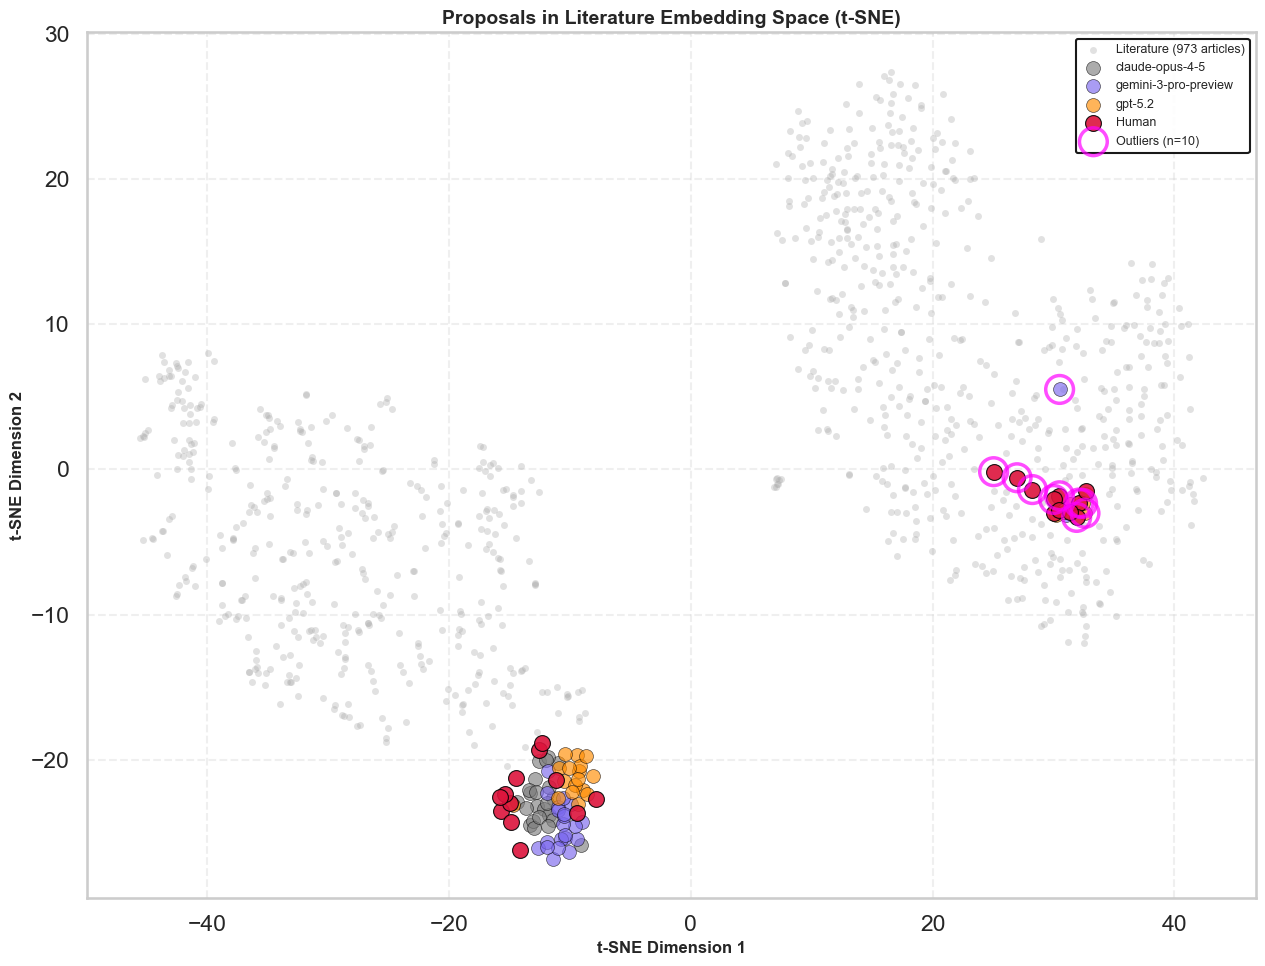


SUCCESS: Figure saved to: ../results/figures/rephrased/minimal/proposals_in_literature_space_tsne.png


In [50]:

from sklearn.manifold import TSNE

print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (t-SNE)")
print("="*85)

# Build aligned AI model labels
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("WARNING: Falling back to ai_df['model'] order.")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings.")

ai_models_nov = sorted(list(dict.fromkeys(ai_model_labels)))
n_human_abs = len(human_embeddings)

print()
print("Fitting t-SNE on literature + proposals jointly...")
print("(This may take a minute...)")

proposals_stacked = np.vstack([human_embeddings, ai_embeddings])
all_embeddings_lit = np.vstack([literature_embeddings, proposals_stacked])

reducer_nov = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0,
)
all_2d_nov = reducer_nov.fit_transform(all_embeddings_lit)

# Split back into literature vs proposals
n_lit = len(literature_embeddings)
literature_2d_nov = all_2d_nov[:n_lit]
proposals_2d_nov = all_2d_nov[n_lit:]

human_2d_nov = proposals_2d_nov[:n_human_abs]
ai_2d_nov = proposals_2d_nov[n_human_abs:]
ai_model_arr = np.array(ai_model_labels)

print(f"SUCCESS: Literature: {len(literature_2d_nov)} points | Proposals: {len(proposals_2d_nov)} points")

fig, ax = plt.subplots(1, 1, figsize=(13, 10))

# Literature background
ax.scatter(
    literature_2d_nov[:, 0], literature_2d_nov[:, 1],
    c='#AAAAAA', s=25, alpha=0.35, linewidths=0,
    label=f'Literature ({len(literature_embeddings)} articles)', zorder=1,
)

# AI proposals by model
for model in ai_models_nov:
    mask = ai_model_arr == model
    pts = ai_2d_nov[mask]
    ax.scatter(
        pts[:, 0], pts[:, 1],
        c=colors.get(model, '#808080'), label=model,
        s=100, alpha=0.65, edgecolors='black', linewidth=0.5, zorder=3,
    )

# Human proposals
ax.scatter(
    human_2d_nov[:, 0], human_2d_nov[:, 1],
    c=colors['Human'], label='Human',
    s=130, alpha=0.9, edgecolors='black', linewidth=0.8,
    marker='o', zorder=5,
)

# Outlier rings (proposal-space outliers from PART I)
if 'outliers' in globals() and len(outliers) == len(proposals_2d_nov):
    outlier_coords_nov = proposals_2d_nov[outliers]
    ax.scatter(
        outlier_coords_nov[:, 0], outlier_coords_nov[:, 1],
        s=400, facecolors='none', edgecolors='magenta',
        linewidth=2.5, alpha=0.7,
        label=f'Outliers (n={int(outliers.sum())})', zorder=8,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposals in Literature Embedding Space (t-SNE)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path = FIGURES_DIR / 'proposals_in_literature_space_tsne.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print()
print(f"SUCCESS: Figure saved to: {out_path}")
print("="*85)


VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (UMAP)

Fitting UMAP on literature corpus...
Projecting proposals into literature UMAP space...
SUCCESS: Literature: 973 points | Proposals: 92 points


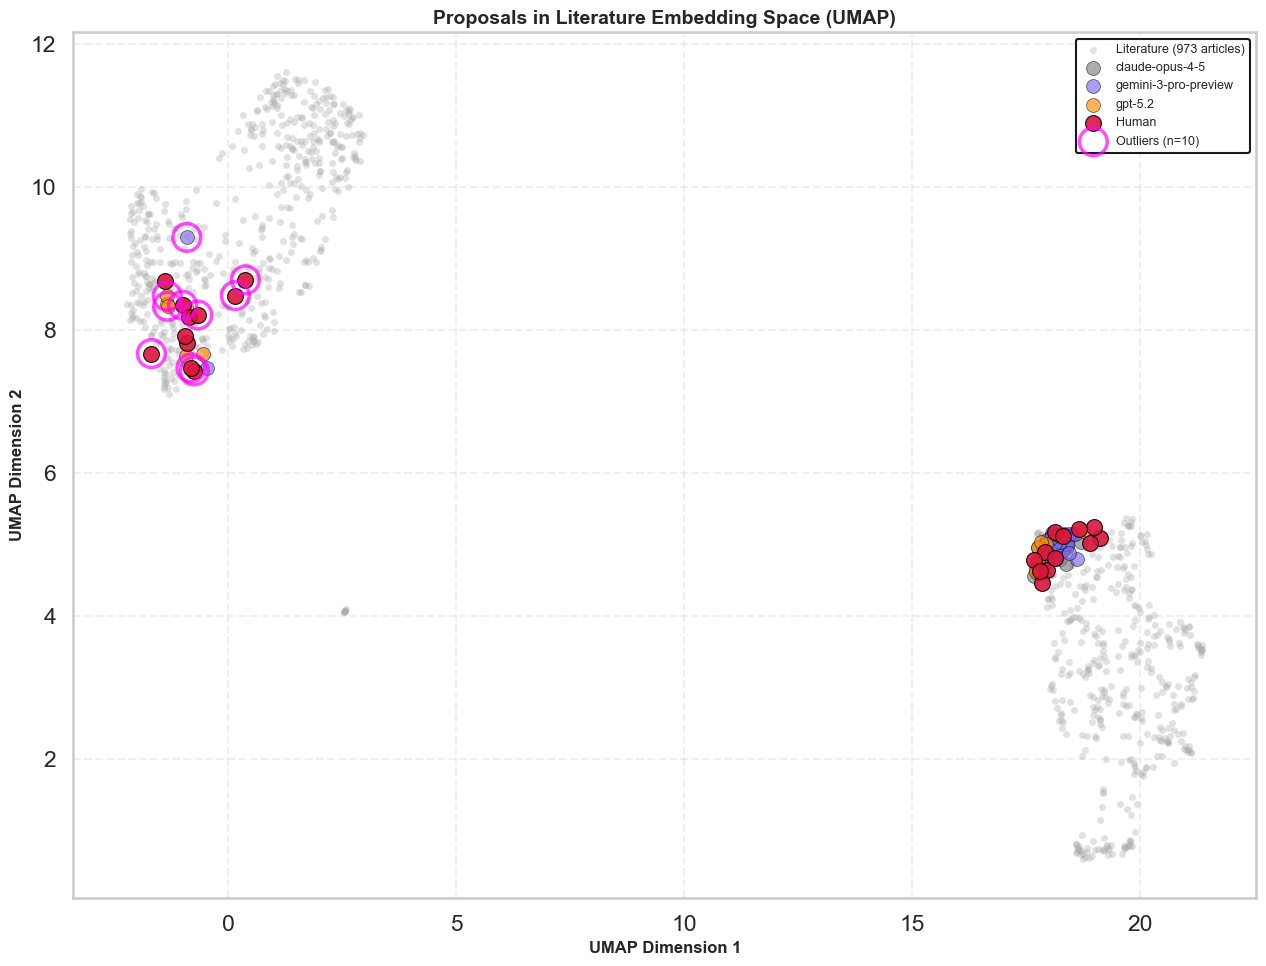


SUCCESS: Figure saved to: ../results/figures/rephrased/minimal/proposals_in_literature_space_umap.png


In [51]:

import umap

print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (UMAP)")
print("="*85)

# Build aligned AI model labels locally so this cell does not depend on the t-SNE cell
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("WARNING: Falling back to ai_df['model'] order.")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings.")

ai_models_nov = sorted(list(dict.fromkeys(ai_model_labels)))
ai_model_arr = np.array(ai_model_labels)
n_human_abs = len(human_embeddings)

proposals_stacked = np.vstack([human_embeddings, ai_embeddings])

print()
print("Fitting UMAP on literature corpus...")
reducer_nov_umap = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42,
)
literature_2d_umap = reducer_nov_umap.fit_transform(literature_embeddings)

print("Projecting proposals into literature UMAP space...")
proposals_2d_umap = reducer_nov_umap.transform(proposals_stacked)

human_2d_umap = proposals_2d_umap[:n_human_abs]
ai_2d_umap = proposals_2d_umap[n_human_abs:]

print(f"SUCCESS: Literature: {len(literature_2d_umap)} points | Proposals: {len(proposals_2d_umap)} points")

# Compatibility variables for downstream cells
all_pts_umap = np.vstack([literature_2d_umap, proposals_2d_umap])
x_all_umap = all_pts_umap[:, 0]
xsplit_umap = (x_all_umap.min() + x_all_umap.max()) / 2
left_mask_umap = x_all_umap < xsplit_umap
right_mask_umap = ~left_mask_umap

fig, ax = plt.subplots(1, 1, figsize=(13, 10))

# Literature background
ax.scatter(
    literature_2d_umap[:, 0], literature_2d_umap[:, 1],
    c='#AAAAAA', s=25, alpha=0.35, linewidths=0,
    label=f'Literature ({len(literature_embeddings)} articles)', zorder=1,
)

# AI proposals by model
for model in ai_models_nov:
    mask = ai_model_arr == model
    pts = ai_2d_umap[mask]
    ax.scatter(
        pts[:, 0], pts[:, 1],
        c=colors.get(model, '#808080'), label=model,
        s=100, alpha=0.65, edgecolors='black', linewidth=0.5, zorder=3,
    )

# Human proposals
ax.scatter(
    human_2d_umap[:, 0], human_2d_umap[:, 1],
    c=colors['Human'], label='Human',
    s=130, alpha=0.9, edgecolors='black', linewidth=0.8,
    marker='o', zorder=5,
)

# Outlier rings (proposal-space outliers from PART I)
if 'outliers' in globals() and len(outliers) == len(proposals_2d_umap):
    outlier_coords_umap = proposals_2d_umap[outliers]
    ax.scatter(
        outlier_coords_umap[:, 0], outlier_coords_umap[:, 1],
        s=400, facecolors='none', edgecolors='magenta',
        linewidth=2.5, alpha=0.7,
        label=f'Outliers (n={int(outliers.sum())})', zorder=8,
    )

ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposals in Literature Embedding Space (UMAP)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path_umap = FIGURES_DIR / 'proposals_in_literature_space_umap.png'
plt.savefig(out_path_umap, dpi=300, bbox_inches='tight')
plt.show()
print()
print(f"SUCCESS: Figure saved to: {out_path_umap}")
print("="*85)


VISUALIZING PROPOSALS IN LITERATURE SPACE - Literature Colored by Publication Year
  <= 2009: 33 articles
  2010-2014: 54 articles
  2015-2018: 143 articles
  2019-2021: 212 articles
  2022-2024: 402 articles
  2025+: 129 articles


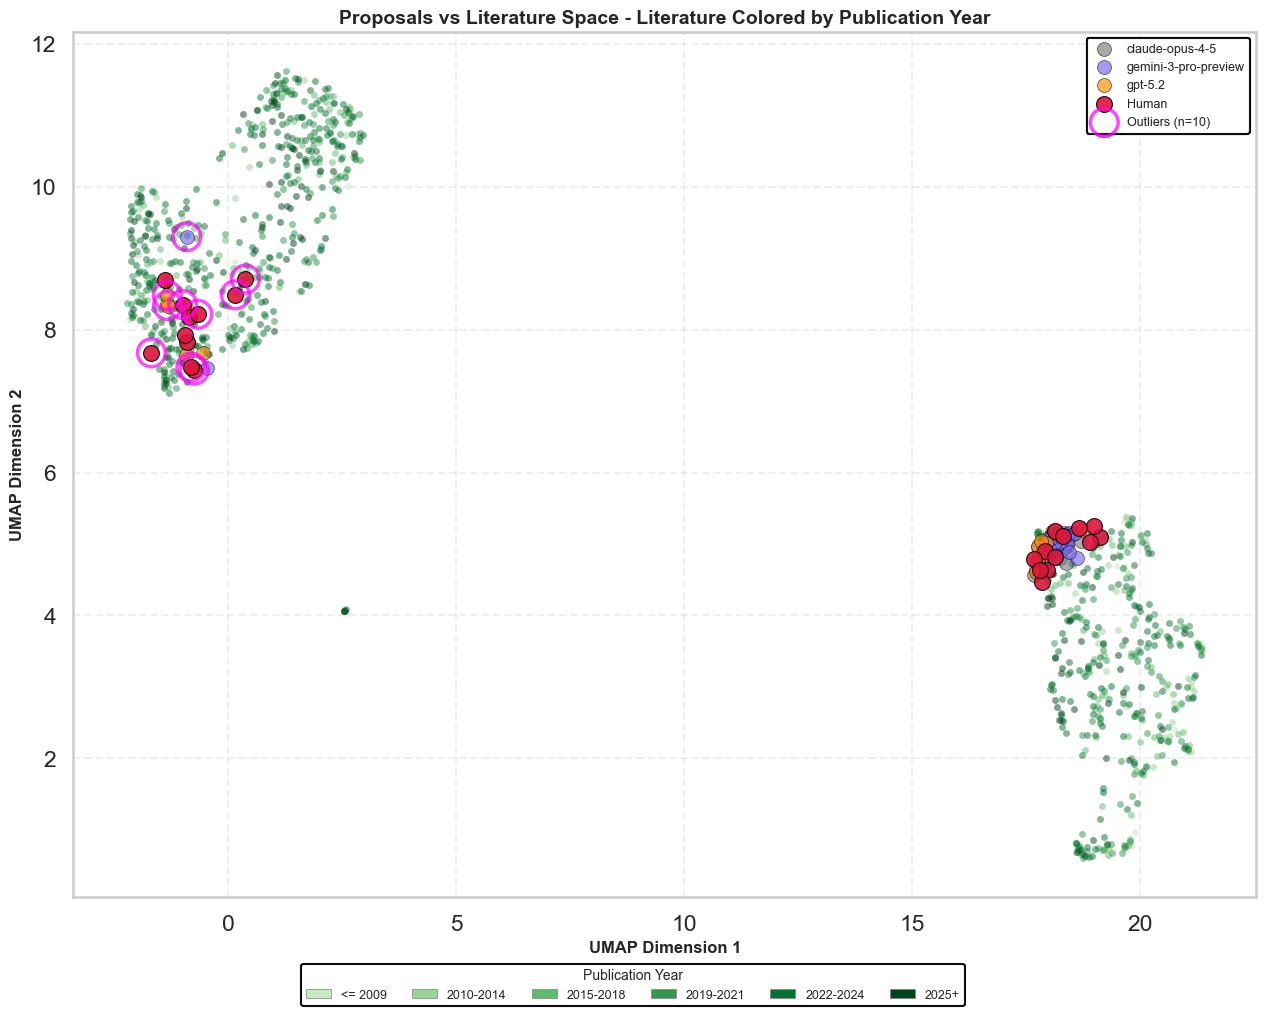


SUCCESS: Figure saved to: ../results/figures/rephrased/minimal/proposals_in_literature_space_by_year.png


In [52]:

# -- Proposals in Literature Space: Literature colored by publication year --
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE SPACE - Literature Colored by Publication Year")
print("="*85)

# -- Extract publication year from each article --
def _parse_year(date_str):
    """Extract 4-digit year from PubMed publication_date string."""
    m = re.search(r'\b(\d{4})\b', str(date_str))
    return int(m.group(1)) if m else None

lit_years = [_parse_year(a.get('publication_date', '')) for a in articles]

# -- Define year buckets --
# Buckets: <=2009 | 2010-2014 | 2015-2018 | 2019-2021 | 2022-2024 | 2025+
BUCKETS = [
    (None, 2009, "<= 2009"),
    (2010, 2014, "2010-2014"),
    (2015, 2018, "2015-2018"),
    (2019, 2021, "2019-2021"),
    (2022, 2024, "2022-2024"),
    (2025, None, "2025+"),
]
n_buckets = len(BUCKETS)

def _bucket_idx(year):
    if year is None:
        return 0
    for i, (lo, hi, _) in enumerate(BUCKETS):
        if (lo is None or year >= lo) and (hi is None or year <= hi):
            return i
    return n_buckets - 1

bucket_indices = np.array([_bucket_idx(y) for y in lit_years])

# Bucket counts for info
for i, (_, _, lbl) in enumerate(BUCKETS):
    n = int((bucket_indices == i).sum())
    print(f"  {lbl}: {n} articles")

# Green colormap: faintest=oldest, darkest=newest
green_cmap = plt.cm.Greens
bucket_colors = [green_cmap(0.25 + 0.75 * i / (n_buckets - 1)) for i in range(n_buckets)]

# Reuse UMAP projection from previous cell
required = [
    'literature_2d_umap', 'proposals_2d_umap', 'human_2d_umap', 'ai_2d_umap',
    'ai_model_arr', 'ai_models_nov',
]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from previous cell: {missing}. Run the UMAP cell first.")

if len(bucket_indices) != len(literature_2d_umap):
    raise RuntimeError(
        f"Publication-year labels ({len(bucket_indices)}) do not match literature coordinates ({len(literature_2d_umap)})."
    )

fig, ax = plt.subplots(1, 1, figsize=(13, 10))

# Literature: plot oldest->newest so newest are on top
for i in range(n_buckets):
    mask = bucket_indices == i
    if mask.any():
        ax.scatter(
            literature_2d_umap[mask, 0], literature_2d_umap[mask, 1],
            c=[bucket_colors[i]], s=25, alpha=0.5, linewidths=0, zorder=1 + i,
        )

# AI proposals (model colors)
for model in ai_models_nov:
    mask = ai_model_arr == model
    pts = ai_2d_umap[mask]
    ax.scatter(
        pts[:, 0], pts[:, 1],
        c=colors.get(model, '#808080'), label=model,
        s=100, alpha=0.65, edgecolors='black', linewidth=0.5, zorder=20,
    )

# Human proposals
ax.scatter(
    human_2d_umap[:, 0], human_2d_umap[:, 1],
    c=colors['Human'], label='Human',
    s=130, alpha=0.9, edgecolors='black', linewidth=0.8,
    marker='o', zorder=22,
)

# Outlier rings
if 'outliers' in globals() and len(outliers) == len(proposals_2d_umap):
    outlier_coords = proposals_2d_umap[outliers]
    ax.scatter(
        outlier_coords[:, 0], outlier_coords[:, 1],
        s=400, facecolors='none', edgecolors='magenta',
        linewidth=2.5, alpha=0.7,
        label=f'Outliers (n={int(outliers.sum())})', zorder=25,
    )

ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposals vs Literature Space - Literature Colored by Publication Year', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Group legend (proposals)
group_legend = ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='black')
ax.add_artist(group_legend)

# Year legend (green gradient) at bottom
year_handles = [
    mpatches.Patch(facecolor=bucket_colors[i], edgecolor='grey', linewidth=0.5, label=BUCKETS[i][2])
    for i in range(n_buckets)
]
fig.legend(
    handles=year_handles,
    title='Publication Year', title_fontsize=10,
    fontsize=9, loc='lower center', ncol=n_buckets,
    framealpha=0.95, edgecolor='black',
    bbox_to_anchor=(0.5, -0.03),
)

plt.tight_layout()
out_path = FIGURES_DIR / 'proposals_in_literature_space_by_year.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print()
print(f"SUCCESS: Figure saved to: {out_path}")
print("="*85)


### Step 7B: Recompute Literature-Space Outliers (proposal -> literature, mean k-NN)

This subsection recomputes outliers using each proposal's **mean cosine distance to its k nearest literature neighbors** (default `k=10`).
Outliers are proposals in the **top 10%** of this literature-space mean-kNN distance distribution.

We then overlay these as a **separate ring color** on the same t-SNE/UMAP literature-space projections:
- **Magenta ring**: original proposal-space outliers (Part I, proposal-only 1-NN)
- **Cyan ring**: literature-space outliers (this subsection, proposal->literature mean-kNN)
\nWith `k=10`, this aligns with Step 4 novelty definition (raw novelty = mean distance to 10 nearest literature neighbors).\n

STEP 7B: LITERATURE-SPACE OUTLIERS (proposal -> literature, mean k-NN)
k (literature neighbors averaged): 10
Note: k=10 matches Step 4 raw novelty definition.
Outlier threshold (top 10%): 0.160260
Total literature-space outliers: 10/92 (10.9%)

LITERATURE-SPACE OUTLIER SUMMARY BY GROUP:
               group  n_total  mean_lit_nn_dist_k10  n_outliers  outlier_pct  outlier_contribution_pct
               Human       23                0.1307           6      26.0870                   60.0000
     claude-opus-4-5       23                0.0904           0       0.0000                    0.0000
gemini-3-pro-preview       23                0.1010           2       8.6957                   20.0000
             gpt-5.2       23                0.1108           2       8.6957                   20.0000
   All AI (combined)       69                0.1008           4       5.7971                   40.0000

Saved proposal-level table: ../results/tables/rephrased/minimal/literature_space_outliers_mea

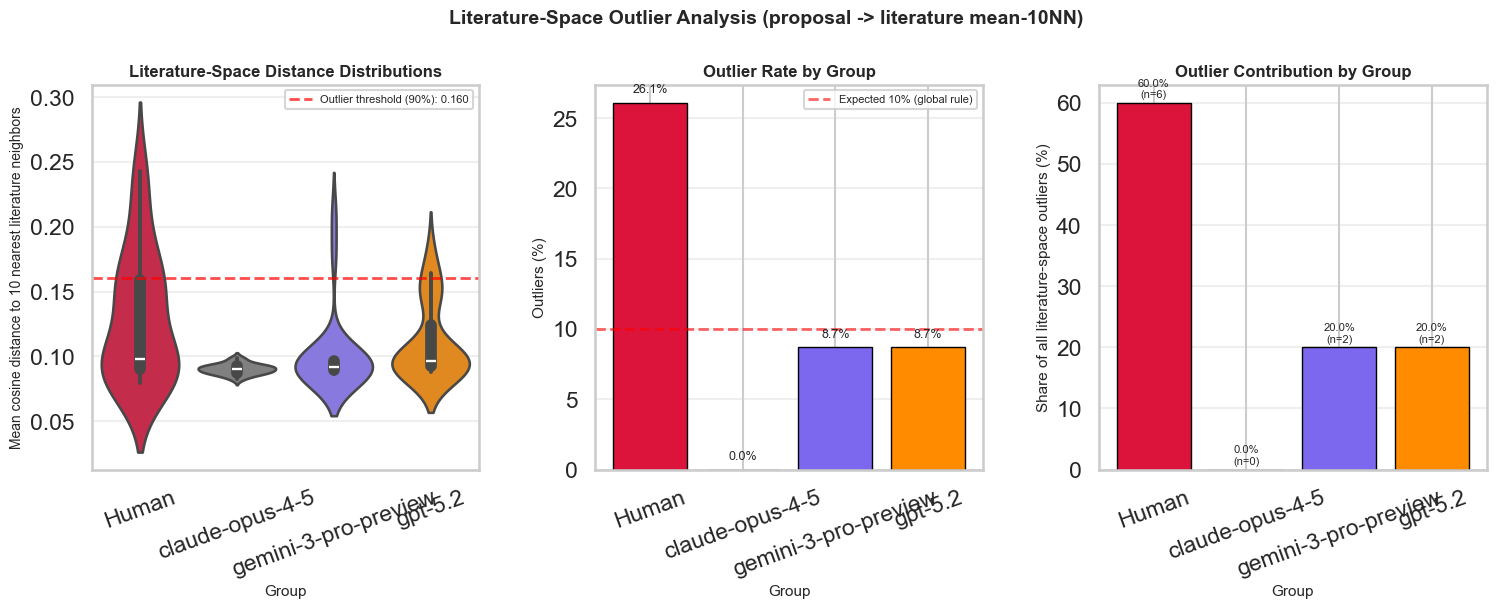

Saved visualization: ../results/figures/rephrased/minimal/literature_space_outliers_by_model_k10.png


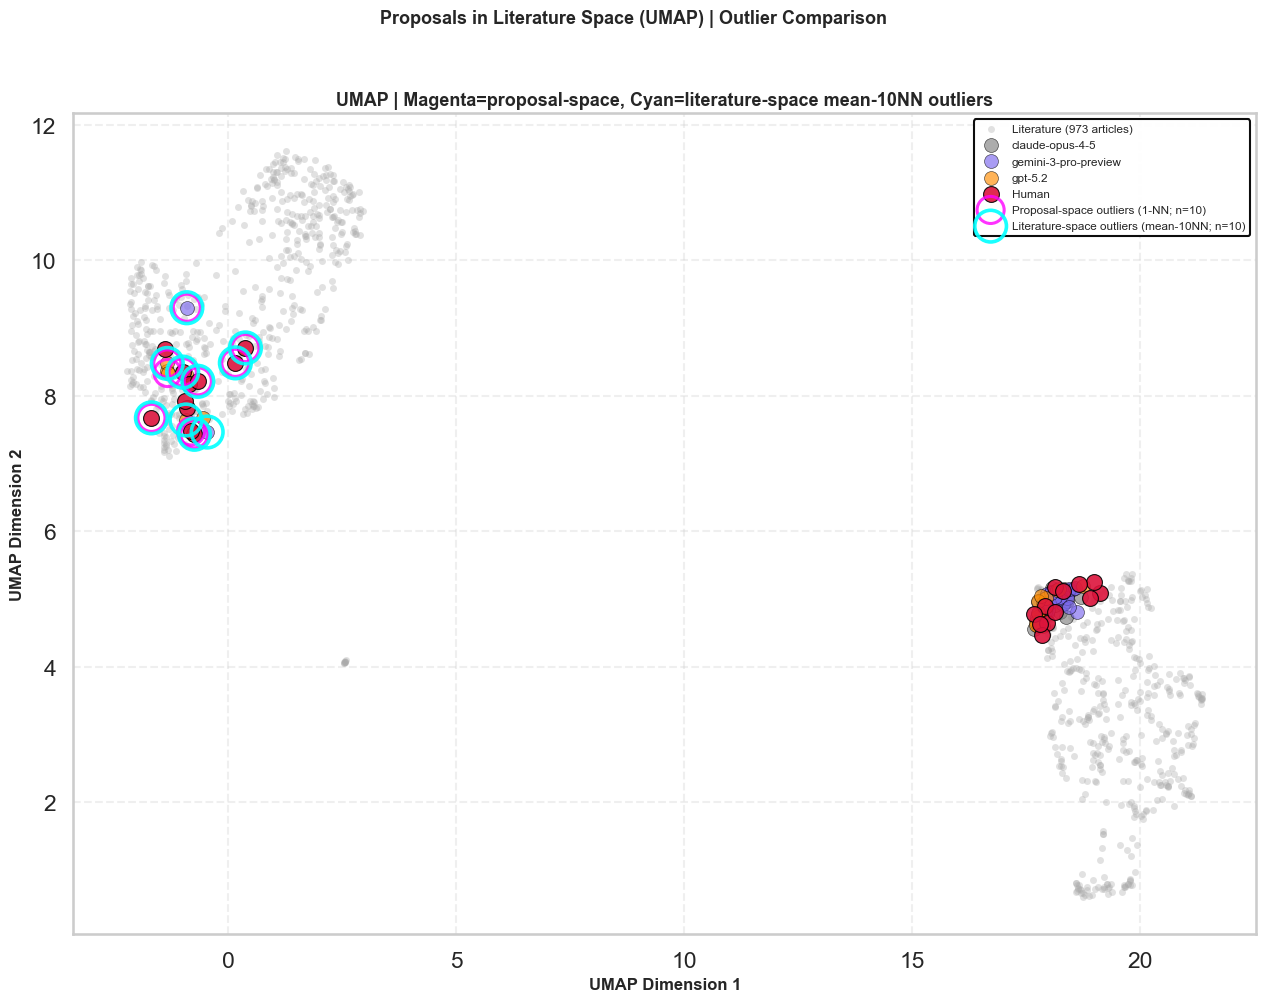

Saved UMAP overlay: ../results/figures/rephrased/minimal/proposals_in_literature_space_umap_outliers_comparison_k10.png


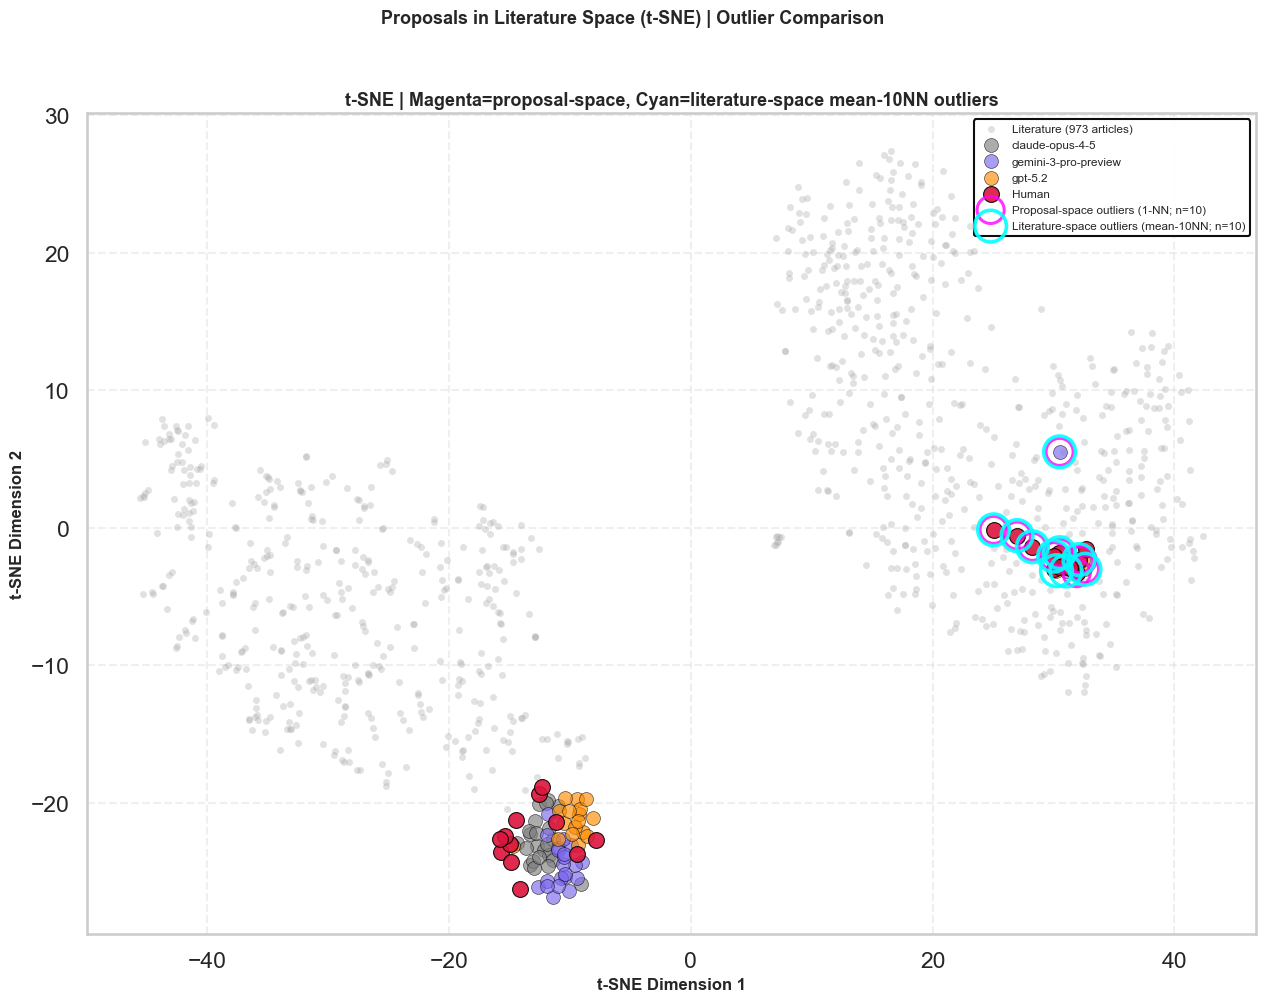

Saved t-SNE overlay: ../results/figures/rephrased/minimal/proposals_in_literature_space_tsne_outliers_comparison_k10.png


In [53]:

# Step 7B: Recompute literature-space outliers and overlay with separate ring color
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import fisher_exact

print('='*85)
print('STEP 7B: LITERATURE-SPACE OUTLIERS (proposal -> literature, mean k-NN)')
print('='*85)

required_base = ['human_embeddings', 'ai_embeddings', 'literature_embeddings']
missing_base = [v for v in required_base if v not in globals()]
if missing_base:
    raise RuntimeError(f"Missing required variables: {missing_base}. Run embedding + Step 7 cells first.")

# Build aligned labels / metadata
n_h = len(human_embeddings)
n_a = len(ai_embeddings)

if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_a:
    ai_model_labels_ls = [str(r.get('model', 'AI')) for r in ai_metadata]
    ai_titles_ls = [str(r.get('title', '')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == n_a and 'model' in ai_df.columns:
    print("WARNING: Falling back to ai_df order for AI labels/titles.")
    ai_model_labels_ls = [str(x) for x in ai_df['model'].tolist()]
    ai_titles_ls = [str(x) for x in ai_df['title'].tolist()] if 'title' in ai_df.columns else [''] * n_a
else:
    raise RuntimeError('Cannot infer AI labels aligned to ai_embeddings.')

if 'human_metadata' in globals() and isinstance(human_metadata, list) and len(human_metadata) == n_h:
    human_titles_ls = [str(r.get('proposal_title', r.get('title', ''))) for r in human_metadata]
elif 'human_df' in globals() and len(human_df) == n_h:
    if 'proposal_title' in human_df.columns:
        human_titles_ls = [str(x) for x in human_df['proposal_title'].tolist()]
    elif 'title' in human_df.columns:
        human_titles_ls = [str(x) for x in human_df['title'].tolist()]
    else:
        human_titles_ls = [''] * n_h
else:
    human_titles_ls = [''] * n_h

proposals_stacked_ls = np.vstack([human_embeddings, ai_embeddings])
labels_ls = np.array((['Human'] * n_h) + ai_model_labels_ls)
titles_ls = human_titles_ls + ai_titles_ls
ai_models_ls = sorted(list(dict.fromkeys(ai_model_labels_ls)))

# --- Recompute outlier score in literature space ---
k_lit_out = 10
d_prop_to_lit = cosine_distances(proposals_stacked_ls, literature_embeddings)
nearest_k = np.partition(d_prop_to_lit, kth=k_lit_out - 1, axis=1)[:, :k_lit_out]
mean_lit_knn_dist = nearest_k.mean(axis=1)
lit_mknn_threshold = float(np.percentile(mean_lit_knn_dist, 90))
lit_space_outliers_mknn = mean_lit_knn_dist > lit_mknn_threshold

# Back-compat aliases for downstream cells
literature_outlier_threshold = lit_mknn_threshold
is_literature_outlier = lit_space_outliers_mknn

print(f"k (literature neighbors averaged): {k_lit_out}")
print("Note: k=10 matches Step 4 raw novelty definition.")
print(f"Outlier threshold (top 10%): {lit_mknn_threshold:.6f}")
print(f"Total literature-space outliers: {int(lit_space_outliers_mknn.sum())}/{len(lit_space_outliers_mknn)} ({lit_space_outliers_mknn.mean()*100:.1f}%)")

# Group summaries
group_order_ls = ['Human'] + ai_models_ls + ['All AI (combined)']
group_rows = []
total_lit_out = int(lit_space_outliers_mknn.sum())

for g in group_order_ls:
    if g == 'All AI (combined)':
        mask = labels_ls != 'Human'
    else:
        mask = labels_ls == g
    n = int(mask.sum())
    if n == 0:
        continue
    n_out = int(lit_space_outliers_mknn[mask].sum())
    out_pct = (n_out / n) * 100
    contrib_pct = (n_out / total_lit_out) * 100 if total_lit_out > 0 else 0.0
    group_rows.append({
        'group': g,
        'n_total': n,
        f'mean_lit_nn_dist_k{k_lit_out}': float(mean_lit_knn_dist[mask].mean()),
        'n_outliers': n_out,
        'outlier_pct': out_pct,
        'outlier_contribution_pct': contrib_pct,
    })

lit_group_summary_df = pd.DataFrame(group_rows)
print()
print('LITERATURE-SPACE OUTLIER SUMMARY BY GROUP:')
print(lit_group_summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Save proposal-level table
lit_out_df = pd.DataFrame({
    'global_index': np.arange(len(labels_ls), dtype=int),
    'group': labels_ls,
    'title': titles_ls,
    f'mean_lit_nn_dist_k{k_lit_out}': mean_lit_knn_dist,
    'is_outlier_literature_space': lit_space_outliers_mknn.astype(int),
    'threshold_literature_space': lit_mknn_threshold,
})
out_tbl = TABLES_DIR / f'literature_space_outliers_mean_knn_k{k_lit_out}.csv'
lit_out_df.to_csv(out_tbl, index=False)

out_summary_tbl = TABLES_DIR / f'literature_space_outlier_summary_k{k_lit_out}.csv'
lit_group_summary_df.to_csv(out_summary_tbl, index=False)

print()
print(f"Saved proposal-level table: {out_tbl}")
print(f"Saved group summary table: {out_summary_tbl}")

# --- Statistical tests: mean-kNN distance differences vs Human ---
print()
print('='*85)
print('STATISTICAL TESTS: Literature-space mean kNN distances (All groups vs Human)')
print('='*85)

human_lit_dists = mean_lit_knn_dist[labels_ls == 'Human']
ai_lit_dists = mean_lit_knn_dist[labels_ls != 'Human']
model_lit_dists = {m: mean_lit_knn_dist[labels_ls == m] for m in ai_models_ls}

lit_stats_rows = []
comparison_specs = [('All AI', ai_lit_dists)] + [(m, model_lit_dists[m]) for m in ai_models_ls]

if 'run_group_comparison' in globals():
    for group_name, vals in comparison_specs:
        res = run_group_comparison(vals, human_lit_dists, n_permutations=10000, n_boot=5000, random_state=42)
        res['group'] = group_name
        lit_stats_rows.append(res)
        direction = 'more isolated from literature' if res['delta'] > 0 else 'closer to literature'
        print(f"{group_name:<28} δ={res['delta']:+.4f} ({res['delta_interp']}), MW p={res['p_value_mw']:.4e}, perm p={res['p_value_perm']:.4f} -> {direction}")

    lit_mknn_stats_df = pd.DataFrame(lit_stats_rows)
    if 'apply_multiple_testing' in globals() and len(lit_mknn_stats_df):
        lit_mknn_stats_df = apply_multiple_testing(lit_mknn_stats_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')

    literature_space_comparison_results = lit_mknn_stats_df.to_dict('records')
    out_stats_tbl = TABLES_DIR / f'literature_space_mean_knn_stats_k{k_lit_out}.csv'
    lit_mknn_stats_df.to_csv(out_stats_tbl, index=False)

    print()
    print('Summary (Holm-adjusted where available):')
    show_cols = [c for c in ['group', 'delta', 'obs_diff_mean', 'ci_low', 'ci_high', 'p_value_mw', 'p_value_mw_adj_holm', 'p_value_perm', 'p_value_perm_adj_holm'] if c in lit_mknn_stats_df.columns]
    print(lit_mknn_stats_df[show_cols].to_string(index=False, float_format=lambda x: f"{x:.4e}" if abs(x) < 1e-3 else f"{x:.4f}"))
    print(f"Saved mean-distance test table: {out_stats_tbl}")
else:
    print('WARNING: run_group_comparison not found; skipping continuous-distance significance tests.')
    literature_space_comparison_results = []

# --- Statistical tests: outlier prevalence differences vs Human ---
print()
print('='*85)
print('STATISTICAL TESTS: Literature-space outlier prevalence (Fisher exact, vs Human)')
print('='*85)

h_mask = labels_ls == 'Human'
h_out = int(lit_space_outliers_mknn[h_mask].sum())
h_non = int(h_mask.sum() - h_out)

prev_rows = []
for group_name in ['All AI'] + ai_models_ls:
    if group_name == 'All AI':
        g_mask = labels_ls != 'Human'
    else:
        g_mask = labels_ls == group_name

    g_n = int(g_mask.sum())
    g_out = int(lit_space_outliers_mknn[g_mask].sum())
    g_non = int(g_n - g_out)

    oddsratio, p_fisher = fisher_exact([[g_out, g_non], [h_out, h_non]], alternative='two-sided')
    rate_g = (g_out / g_n) if g_n else np.nan
    rate_h = (h_out / (h_out + h_non)) if (h_out + h_non) else np.nan

    prev_rows.append({
        'group': group_name,
        'group_outliers': g_out,
        'group_total': g_n,
        'human_outliers': h_out,
        'human_total': (h_out + h_non),
        'outlier_rate_group': rate_g,
        'outlier_rate_human': rate_h,
        'rate_diff_group_minus_human': rate_g - rate_h,
        'odds_ratio': oddsratio,
        'p_value_fisher': p_fisher,
    })

lit_prev_df = pd.DataFrame(prev_rows)
if 'apply_multiple_testing' in globals() and len(lit_prev_df):
    lit_prev_df = apply_multiple_testing(lit_prev_df, p_cols=('p_value_fisher',), method='holm')

literature_space_prevalence_results = lit_prev_df.to_dict('records')
out_prev_tbl = TABLES_DIR / f'literature_space_outlier_prevalence_tests_k{k_lit_out}.csv'
lit_prev_df.to_csv(out_prev_tbl, index=False)

show_prev_cols = [c for c in ['group', 'group_outliers', 'group_total', 'outlier_rate_group', 'outlier_rate_human', 'rate_diff_group_minus_human', 'odds_ratio', 'p_value_fisher', 'p_value_fisher_adj_holm'] if c in lit_prev_df.columns]
print(lit_prev_df[show_prev_cols].to_string(index=False, float_format=lambda x: f"{x:.4e}" if abs(x) < 1e-3 else f"{x:.4f}"))
print(f"Saved prevalence test table: {out_prev_tbl}")

# --- Visualization: similar to PART I 1.3 ---
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# 1) mean-kNN distance distributions
ax1 = fig.add_subplot(gs[0, 0])
dist_rows = []
for g in ['Human'] + ai_models_ls:
    arr = mean_lit_knn_dist[labels_ls == g]
    for v in arr:
        dist_rows.append({'Group': g, f'Mean-{k_lit_out}NN Dist': v})
dist_df = pd.DataFrame(dist_rows)
plot_order = ['Human'] + ai_models_ls
palette_list = [colors.get(g, 'gray') for g in plot_order]

sns.violinplot(data=dist_df, x='Group', y=f'Mean-{k_lit_out}NN Dist', ax=ax1, palette=palette_list, order=plot_order)
ax1.axhline(lit_mknn_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Outlier threshold (90%): {lit_mknn_threshold:.3f}')
ax1.set_ylabel(f'Mean cosine distance to {k_lit_out} nearest literature neighbors', fontsize=10)
ax1.set_xlabel('Group', fontsize=11)
ax1.set_title('Literature-Space Distance Distributions', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# 2) outlier percentage by group (rate within group)
ax2 = fig.add_subplot(gs[0, 1])
rate_df = lit_group_summary_df[lit_group_summary_df['group'] != 'All AI (combined)'][['group', 'outlier_pct']].copy()
rate_df.columns = ['Group', 'Outliers (%)']

bars = ax2.bar(rate_df['Group'], rate_df['Outliers (%)'],
               color=[colors.get(g, 'gray') for g in rate_df['Group']],
               edgecolor='black', linewidth=1)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.6, label='Expected 10% (global rule)')
ax2.set_ylabel('Outliers (%)', fontsize=11)
ax2.set_xlabel('Group', fontsize=11)
ax2.set_title('Outlier Rate by Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

for bar, pct in zip(bars, rate_df['Outliers (%)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{pct:.1f}%',
             ha='center', va='bottom', fontsize=9)

# 3) contribution among all flagged literature-space outliers
ax3 = fig.add_subplot(gs[0, 2])
contrib_df = lit_group_summary_df[lit_group_summary_df['group'] != 'All AI (combined)'][['group', 'outlier_contribution_pct', 'n_outliers']].copy()
contrib_df.columns = ['Group', 'Contribution (%)', 'Outlier Count']

bars3 = ax3.bar(contrib_df['Group'], contrib_df['Contribution (%)'],
                color=[colors.get(g, 'gray') for g in contrib_df['Group']],
                edgecolor='black', linewidth=1)
ax3.set_ylabel('Share of all literature-space outliers (%)', fontsize=11)
ax3.set_xlabel('Group', fontsize=11)
ax3.set_title('Outlier Contribution by Group', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=20)
ax3.grid(alpha=0.3, axis='y')

for bar, pct, cnt in zip(bars3, contrib_df['Contribution (%)'], contrib_df['Outlier Count']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{pct:.1f}%\n(n={cnt})',
             ha='center', va='bottom', fontsize=8)

fig.suptitle(f'Literature-Space Outlier Analysis (proposal -> literature mean-{k_lit_out}NN)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
out_fig = FIGURES_DIR / f'literature_space_outliers_by_model_k{k_lit_out}.png'
plt.savefig(out_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved visualization: {out_fig}")

# --- Overlay plotting helpers (magenta = original proposal-only outliers; cyan = literature-space outliers) ---
def _draw_overlay(ax, literature_2d, proposals_2d, human_2d, ai_2d, ai_models_arr, ai_models_order, title_prefix):
    ax.scatter(literature_2d[:, 0], literature_2d[:, 1],
               c='#AAAAAA', s=25, alpha=0.35, linewidths=0,
               label=f'Literature ({len(literature_embeddings)} articles)', zorder=1)

    for model in ai_models_order:
        mask = ai_models_arr == model
        pts = ai_2d[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'), label=model,
                   s=100, alpha=0.65, edgecolors='black', linewidth=0.5, zorder=3)

    ax.scatter(human_2d[:, 0], human_2d[:, 1],
               c=colors['Human'], label='Human',
               s=130, alpha=0.9, edgecolors='black', linewidth=0.8,
               marker='o', zorder=5)

    # Existing proposal-space outliers (if available)
    if 'outliers' in globals() and len(outliers) == len(proposals_2d):
        old_coords = proposals_2d[outliers]
        ax.scatter(old_coords[:, 0], old_coords[:, 1],
                   s=380, facecolors='none', edgecolors='magenta',
                   linewidth=2.2, alpha=0.8,
                   label=f'Proposal-space outliers (1-NN; n={int(outliers.sum())})', zorder=8)

    # New literature-space outliers
    new_coords = proposals_2d[lit_space_outliers_mknn]
    ax.scatter(new_coords[:, 0], new_coords[:, 1],
               s=520, facecolors='none', edgecolors='cyan',
               linewidth=2.6, alpha=0.9,
               label=f'Literature-space outliers (mean-{k_lit_out}NN; n={int(lit_space_outliers_mknn.sum())})', zorder=9)

    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_title(title_prefix, fontsize=13, fontweight='bold')

def _zoom(ax, pts, mask, pad=0.04):
    mpts = pts[mask]
    if len(mpts) == 0:
        return
    xmin, xmax = mpts[:, 0].min(), mpts[:, 0].max()
    ymin, ymax = mpts[:, 1].min(), mpts[:, 1].max()
    xp = (xmax - xmin) * pad
    yp = (ymax - ymin) * pad
    ax.set_xlim(xmin - xp, xmax + xp)
    ax.set_ylim(ymin - yp, ymax + yp)

def _proposal_cluster_masks(proposals_2d):
    x = proposals_2d[:, 0]
    order = np.argsort(x)
    xs = x[order]
    if len(xs) < 2:
        thresh = float(np.median(x))
    else:
        gaps = np.diff(xs)
        split_idx = int(np.argmax(gaps))
        thresh = float((xs[split_idx] + xs[split_idx + 1]) / 2)
    left_mask = x <= thresh
    right_mask = x > thresh
    return left_mask, right_mask, thresh

def _zoom_to_proposal_cluster(ax, literature_2d, proposals_2d, prop_mask, pad_frac=1.25, min_pad=0.9):
    ppts = proposals_2d[prop_mask]
    if len(ppts) == 0:
        return
    xmin, xmax = ppts[:, 0].min(), ppts[:, 0].max()
    ymin, ymax = ppts[:, 1].min(), ppts[:, 1].max()
    xp = max((xmax - xmin) * pad_frac, min_pad)
    yp = max((ymax - ymin) * pad_frac, min_pad)
    ax.set_xlim(xmin - xp, xmax + xp)
    ax.set_ylim(ymin - yp, ymax + yp)

# UMAP overlay (requires Step 7 UMAP cell outputs)
if all(v in globals() for v in ['literature_2d_umap', 'proposals_2d_umap', 'human_2d_umap', 'ai_2d_umap', 'ai_model_arr', 'ai_models_nov']):
    left_mask_u, right_mask_u, xsplit_u = _proposal_cluster_masks(proposals_2d_umap)
    fig_u, (ax_ul, ax_ur) = plt.subplots(1, 2, figsize=(18, 9))

    _draw_overlay(
        ax_ul,
        literature_2d_umap,
        proposals_2d_umap,
        human_2d_umap,
        ai_2d_umap,
        ai_model_arr,
        ai_models_nov,
        'Left proposal cluster (zoomed)',
    )
    _zoom_to_proposal_cluster(ax_ul, literature_2d_umap, proposals_2d_umap, left_mask_u)
    ax_ul.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
    ax_ul.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')

    _draw_overlay(
        ax_ur,
        literature_2d_umap,
        proposals_2d_umap,
        human_2d_umap,
        ai_2d_umap,
        ai_model_arr,
        ai_models_nov,
        'Right proposal cluster (zoomed)',
    )
    _zoom_to_proposal_cluster(ax_ur, literature_2d_umap, proposals_2d_umap, right_mask_u)
    ax_ur.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
    ax_ur.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')

    handles, labels_leg = ax_ur.get_legend_handles_labels()
    fig_u.legend(handles, labels_leg, loc='upper center', bbox_to_anchor=(0.5, 0.98),
                 ncol=3, fontsize=8.5, framealpha=0.95, edgecolor='black')

    fig_u.suptitle(
        f'Proposals in Literature Space (UMAP) | Outlier Comparison',
        fontsize=13,
        fontweight='bold',
        y=1.05,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    out_umap_overlay = FIGURES_DIR / f'proposals_in_literature_space_umap_outliers_comparison_k{k_lit_out}.png'
    plt.savefig(out_umap_overlay, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved UMAP overlay: {out_umap_overlay}')
else:
    print('WARNING: Skipped UMAP overlay: run Step 7 UMAP cell first.')

# t-SNE overlay (requires Step 7 t-SNE cell outputs)
if all(v in globals() for v in ['literature_2d_nov', 'proposals_2d_nov', 'human_2d_nov', 'ai_2d_nov', 'ai_model_arr', 'ai_models_nov']):
    fig_t, ax_t = plt.subplots(1, 1, figsize=(13, 10))

    _draw_overlay(
        ax_t,
        literature_2d_nov,
        proposals_2d_nov,
        human_2d_nov,
        ai_2d_nov,
        ai_model_arr,
        ai_models_nov,
        f't-SNE | Magenta=proposal-space, Cyan=literature-space mean-{k_lit_out}NN outliers',
    )

    ax_t.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
    ax_t.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
    ax_t.legend(loc='best', fontsize=8.5, framealpha=0.95, edgecolor='black')

    fig_t.suptitle(
        f'Proposals in Literature Space (t-SNE) | Outlier Comparison',
        fontsize=13,
        fontweight='bold',
        y=1.01,
    )
    plt.tight_layout()
    out_tsne_overlay = FIGURES_DIR / f'proposals_in_literature_space_tsne_outliers_comparison_k{k_lit_out}.png'
    plt.savefig(out_tsne_overlay, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved t-SNE overlay: {out_tsne_overlay}')
else:
    print('WARNING: Skipped t-SNE overlay: run Step 7 t-SNE cell first.')

print('='*85)



### Step 7C: Projection Reliability (Seed Sweep + PCA Reference)

This section checks whether the literature-space visual patterns are robust or projection artifacts.

What is computed:
- Seed sweep for **t-SNE (joint fit)** and **UMAP (fit on literature, transform proposals)**.
- **Trustworthiness** (k=5,10) on the combined literature+proposal embedding.
- Task-faithfulness for proposal fit to literature:
  - Spearman correlation between high-dimensional and 2D **mean-10NN proposal->literature distances**.
  - Jaccard overlap between high-dimensional literature-space outliers and 2D outliers.
- A **PCA reference view** with the same outlier overlays and reliability metrics.

Interpretation guide:
- Higher trustworthiness is better (closer to 1).
- Higher Spearman is better (2D preserves ranking of proposal->literature distances).
- Higher Jaccard is better (2D outlier flags match high-dimensional outlier flags).


STEP 7C: PROJECTION RELIABILITY (SEED SWEEP + PCA REFERENCE)
Saved:
  - ../results/tables/rephrased/minimal/projection_reliability_seed_sweep.csv
  - ../results/tables/rephrased/minimal/projection_reliability_summary.csv

Seed-sweep summary (mean +- std):
  tsne_joint                 trust_k10=0.9611 +- 0.0010 | spearman=-0.3294 +- 0.0360 | jaccard=0.0000 +- 0.0000
  umap_lit_fit_transform     trust_k10=0.9417 +- 0.0003 | spearman=-0.1488 +- 0.0643 | jaccard=0.0105 +- 0.0211


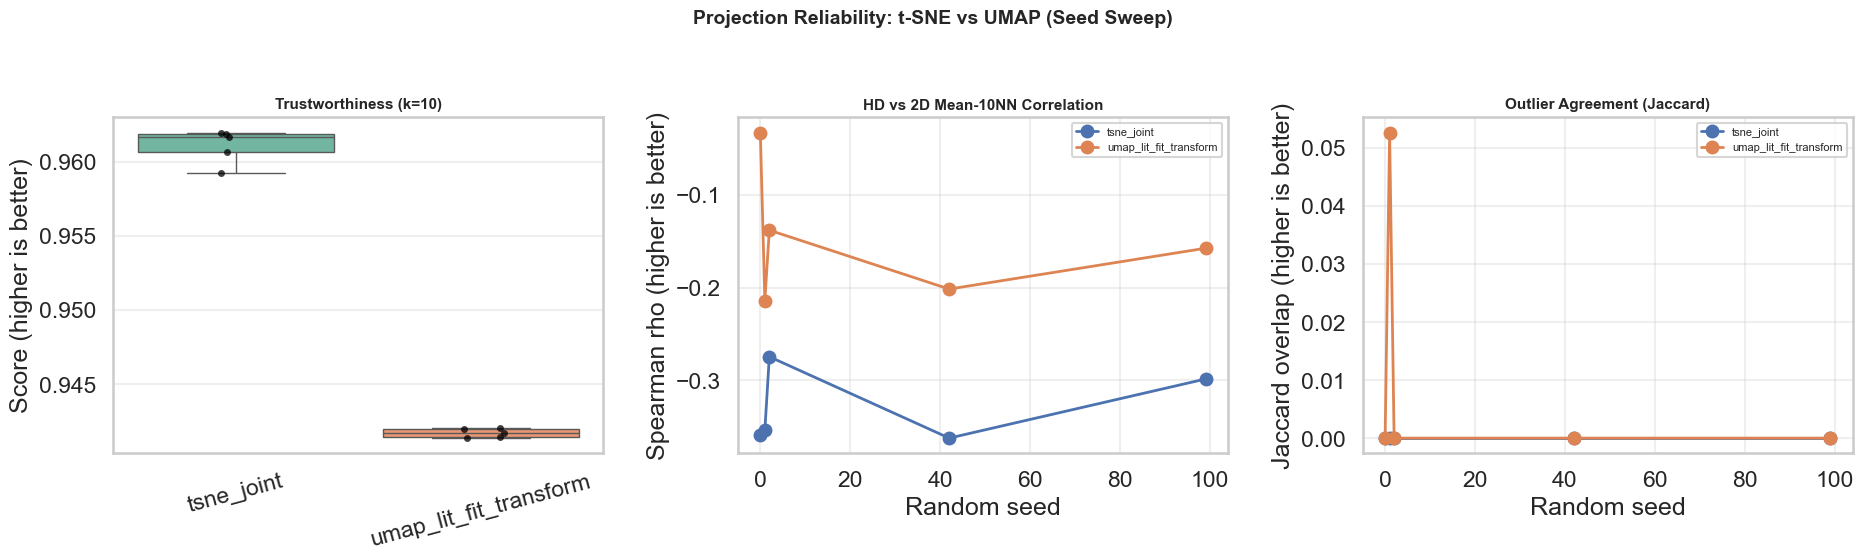

Saved figure: ../results/figures/rephrased/minimal/projection_reliability_seed_sweep.png
Saved PCA reference metrics: ../results/tables/rephrased/minimal/projection_reliability_pca_reference.csv
PCA explained variance: PC1=0.5730, PC2=0.0618


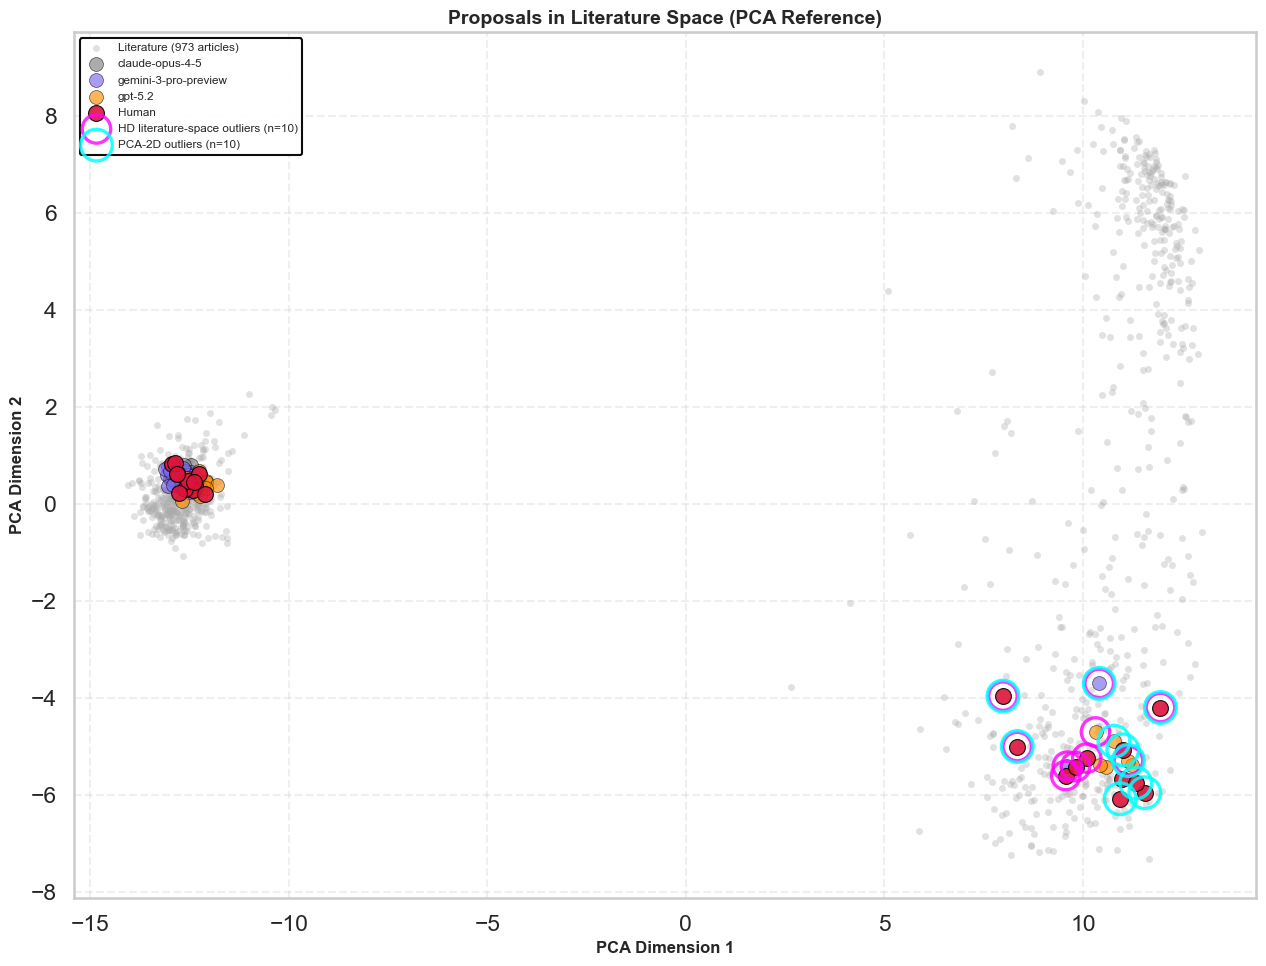

Saved PCA reference figure: ../results/figures/rephrased/minimal/proposals_in_literature_space_pca_outliers_comparison_k5.png


In [54]:

# Step 7C: Projection reliability diagnostics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

try:
    from sklearn.manifold import trustworthiness as _trustworthiness
except Exception:
    from sklearn.manifold.t_sne import trustworthiness as _trustworthiness

import umap

print("="*85)
print("STEP 7C: PROJECTION RELIABILITY (SEED SWEEP + PCA REFERENCE)")
print("="*85)

required_vars = ['human_embeddings', 'ai_embeddings', 'literature_embeddings']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing required variables: {missing_vars}. Run embedding + Step 7 cells first.")

# Build proposal matrix and labels
proposals_pr = np.vstack([human_embeddings, ai_embeddings])
all_hd_pr = np.vstack([literature_embeddings, proposals_pr])
n_lit_pr = len(literature_embeddings)
n_prop_pr = len(proposals_pr)
n_h_pr = len(human_embeddings)

# AI label alignment
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels_pr = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("WARNING: Falling back to ai_df order for AI model labels.")
    ai_model_labels_pr = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings.")

ai_models_pr = sorted(list(dict.fromkeys(ai_model_labels_pr)))
ai_model_arr_pr = np.array(ai_model_labels_pr)

# High-dimensional literature-space baseline (mean-k proposal->literature)
k_pr = int(globals().get('k_lit_out', 10))
d_hd_prop_lit = cosine_distances(proposals_pr, literature_embeddings)
nearest_hd = np.partition(d_hd_prop_lit, kth=k_pr - 1, axis=1)[:, :k_pr]
mean_hd_prop_lit = nearest_hd.mean(axis=1)
thr_hd_prop_lit = float(np.percentile(mean_hd_prop_lit, 90))
out_hd_prop_lit = mean_hd_prop_lit > thr_hd_prop_lit

# If Step 7B already computed outliers, reuse for consistency
if 'lit_space_outliers_mknn' in globals() and len(lit_space_outliers_mknn) == n_prop_pr:
    out_hd_prop_lit = np.asarray(lit_space_outliers_mknn).astype(bool)
if 'lit_mknn_threshold' in globals():
    try:
        thr_hd_prop_lit = float(lit_mknn_threshold)
    except Exception:
        pass

# Trustworthiness wrapper (handle sklearn version differences)
def _trust(X, Y, n_neighbors):
    try:
        return float(_trustworthiness(X, Y, n_neighbors=n_neighbors, metric='cosine'))
    except TypeError:
        return float(_trustworthiness(X, Y, n_neighbors=n_neighbors))

# Task-faithfulness metrics in 2D
# Compare 2D proposal->literature mean-k distances against high-dimensional baseline
# and compare 2D outlier set against high-dimensional outlier set.
def _proposal_lit_2d_metrics(proposals_2d, literature_2d, mean_hd, out_hd, k=5):
    d2 = cdist(proposals_2d, literature_2d, metric='euclidean')
    nearest2 = np.partition(d2, kth=k - 1, axis=1)[:, :k]
    mean2 = nearest2.mean(axis=1)
    thr2 = float(np.percentile(mean2, 90))
    out2 = mean2 > thr2

    rho, pval = spearmanr(mean_hd, mean2)
    if np.isnan(rho):
        rho = 0.0
        pval = 1.0

    inter = int(np.logical_and(out_hd, out2).sum())
    union = int(np.logical_or(out_hd, out2).sum())
    jacc = (inter / union) if union > 0 else 0.0

    return {
        'mean2': mean2,
        'thr2': thr2,
        'out2': out2,
        'spearman_rho': float(rho),
        'spearman_p': float(pval),
        'jaccard_outliers': float(jacc),
        'outlier_overlap_n': inter,
        'outlier_union_n': union,
    }

# Seed sweep
seeds = [0, 1, 2, 42, 99]
rows = []

for seed in seeds:
    # t-SNE: joint fit on literature + proposals
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        metric='cosine',
        random_state=seed,
        n_iter=1000,
        verbose=0,
    )
    all2d_tsne = tsne.fit_transform(all_hd_pr)
    lit2d_tsne = all2d_tsne[:n_lit_pr]
    prop2d_tsne = all2d_tsne[n_lit_pr:]

    m_tsne = _proposal_lit_2d_metrics(prop2d_tsne, lit2d_tsne, mean_hd_prop_lit, out_hd_prop_lit, k=k_pr)
    rows.append({
        'method': 'tsne_joint',
        'seed': seed,
        'trustworthiness_k5': _trust(all_hd_pr, all2d_tsne, n_neighbors=5),
        'trustworthiness_k10': _trust(all_hd_pr, all2d_tsne, n_neighbors=10),
        'spearman_mean10nn_hd_vs_2d': m_tsne['spearman_rho'],
        'spearman_p': m_tsne['spearman_p'],
        'jaccard_hd_vs_2d_outliers': m_tsne['jaccard_outliers'],
        'outlier_overlap_n': m_tsne['outlier_overlap_n'],
        'outlier_union_n': m_tsne['outlier_union_n'],
    })

    # UMAP: fit on literature, transform proposals
    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        random_state=seed,
    )
    lit2d_umap = reducer.fit_transform(literature_embeddings)
    prop2d_umap = reducer.transform(proposals_pr)
    all2d_umap = np.vstack([lit2d_umap, prop2d_umap])

    m_umap = _proposal_lit_2d_metrics(prop2d_umap, lit2d_umap, mean_hd_prop_lit, out_hd_prop_lit, k=k_pr)
    rows.append({
        'method': 'umap_lit_fit_transform',
        'seed': seed,
        'trustworthiness_k5': _trust(all_hd_pr, all2d_umap, n_neighbors=5),
        'trustworthiness_k10': _trust(all_hd_pr, all2d_umap, n_neighbors=10),
        'spearman_mean10nn_hd_vs_2d': m_umap['spearman_rho'],
        'spearman_p': m_umap['spearman_p'],
        'jaccard_hd_vs_2d_outliers': m_umap['jaccard_outliers'],
        'outlier_overlap_n': m_umap['outlier_overlap_n'],
        'outlier_union_n': m_umap['outlier_union_n'],
    })

pr_reliability_df = pd.DataFrame(rows)
pr_summary_df = (
    pr_reliability_df
    .groupby('method')[['trustworthiness_k5', 'trustworthiness_k10', 'spearman_mean10nn_hd_vs_2d', 'jaccard_hd_vs_2d_outliers']]
    .agg(['mean', 'std', 'min', 'max'])
)

# Save tables
out_tbl_seed = TABLES_DIR / 'projection_reliability_seed_sweep.csv'
out_tbl_summary = TABLES_DIR / 'projection_reliability_summary.csv'
pr_reliability_df.to_csv(out_tbl_seed, index=False)
pr_summary_df.to_csv(out_tbl_summary)

print("Saved:")
print(f"  - {out_tbl_seed}")
print(f"  - {out_tbl_summary}")
print()
print("Seed-sweep summary (mean +- std):")
for m in pr_reliability_df['method'].unique():
    sub = pr_reliability_df[pr_reliability_df['method'] == m]
    tw = sub['trustworthiness_k10']
    sp = sub['spearman_mean10nn_hd_vs_2d']
    jc = sub['jaccard_hd_vs_2d_outliers']
    print(f"  {m:<26} trust_k10={tw.mean():.4f} +- {tw.std(ddof=0):.4f} | spearman={sp.mean():.4f} +- {sp.std(ddof=0):.4f} | jaccard={jc.mean():.4f} +- {jc.std(ddof=0):.4f}")

# Reliability visualization
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# 1) Trustworthiness (k=10)
sns.boxplot(data=pr_reliability_df, x='method', y='trustworthiness_k10', ax=axes[0], palette='Set2')
sns.stripplot(data=pr_reliability_df, x='method', y='trustworthiness_k10', ax=axes[0], color='black', size=5, alpha=0.75)
axes[0].set_title('Trustworthiness (k=10)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score (higher is better)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(alpha=0.3, axis='y')

# 2) Spearman correlation by seed
for method, grp in pr_reliability_df.groupby('method'):
    grp = grp.sort_values('seed')
    axes[1].plot(grp['seed'], grp['spearman_mean10nn_hd_vs_2d'], marker='o', linewidth=2, label=method)
axes[1].set_title('HD vs 2D Mean-10NN Correlation', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Random seed')
axes[1].set_ylabel('Spearman rho (higher is better)')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

# 3) Outlier-set overlap by seed
for method, grp in pr_reliability_df.groupby('method'):
    grp = grp.sort_values('seed')
    axes[2].plot(grp['seed'], grp['jaccard_hd_vs_2d_outliers'], marker='o', linewidth=2, label=method)
axes[2].set_title('Outlier Agreement (Jaccard)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Random seed')
axes[2].set_ylabel('Jaccard overlap (higher is better)')
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8)

fig.suptitle('Projection Reliability: t-SNE vs UMAP (Seed Sweep)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
out_fig_rel = FIGURES_DIR / 'projection_reliability_seed_sweep.png'
plt.savefig(out_fig_rel, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved figure: {out_fig_rel}")

# PCA reference projection
pca = PCA(n_components=2, random_state=42)
all2d_pca = pca.fit_transform(all_hd_pr)
lit2d_pca = all2d_pca[:n_lit_pr]
prop2d_pca = all2d_pca[n_lit_pr:]

pca_metrics = _proposal_lit_2d_metrics(prop2d_pca, lit2d_pca, mean_hd_prop_lit, out_hd_prop_lit, k=k_pr)
pca_row = {
    'method': 'pca_reference',
    'seed': 42,
    'trustworthiness_k5': _trust(all_hd_pr, all2d_pca, n_neighbors=5),
    'trustworthiness_k10': _trust(all_hd_pr, all2d_pca, n_neighbors=10),
    'spearman_mean10nn_hd_vs_2d': pca_metrics['spearman_rho'],
    'spearman_p': pca_metrics['spearman_p'],
    'jaccard_hd_vs_2d_outliers': pca_metrics['jaccard_outliers'],
    'outlier_overlap_n': pca_metrics['outlier_overlap_n'],
    'outlier_union_n': pca_metrics['outlier_union_n'],
    'explained_variance_ratio_pc1': float(pca.explained_variance_ratio_[0]),
    'explained_variance_ratio_pc2': float(pca.explained_variance_ratio_[1]),
}

out_tbl_pca = TABLES_DIR / 'projection_reliability_pca_reference.csv'
pd.DataFrame([pca_row]).to_csv(out_tbl_pca, index=False)
print(f"Saved PCA reference metrics: {out_tbl_pca}")
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.4f}, PC2={pca.explained_variance_ratio_[1]:.4f}")

# PCA visualization with outlier overlays
fig, ax = plt.subplots(1, 1, figsize=(13, 10))
ax.scatter(lit2d_pca[:, 0], lit2d_pca[:, 1], c='#AAAAAA', s=25, alpha=0.35, linewidths=0,
           label=f'Literature ({n_lit_pr} articles)', zorder=1)

# AI first
for model in ai_models_pr:
    mask = ai_model_arr_pr == model
    pts = prop2d_pca[n_h_pr:][mask]
    ax.scatter(pts[:, 0], pts[:, 1], c=colors.get(model, '#808080'), label=model,
               s=100, alpha=0.65, edgecolors='black', linewidth=0.5, zorder=3)

# Human
human_pca = prop2d_pca[:n_h_pr]
ax.scatter(human_pca[:, 0], human_pca[:, 1], c=colors.get('Human', '#e74c3c'), label='Human',
           s=130, alpha=0.9, edgecolors='black', linewidth=0.8, marker='o', zorder=5)

# High-dimensional literature-space outliers (magenta)
hd_out_coords = prop2d_pca[out_hd_prop_lit]
ax.scatter(hd_out_coords[:, 0], hd_out_coords[:, 1], s=420, facecolors='none', edgecolors='magenta',
           linewidth=2.4, alpha=0.8, label=f'HD literature-space outliers (n={int(out_hd_prop_lit.sum())})', zorder=8)

# PCA-2D outliers (cyan)
pca_out_coords = prop2d_pca[pca_metrics['out2']]
ax.scatter(pca_out_coords[:, 0], pca_out_coords[:, 1], s=520, facecolors='none', edgecolors='cyan',
           linewidth=2.4, alpha=0.85, label=f"PCA-2D outliers (n={int(pca_metrics['out2'].sum())})", zorder=9)

ax.set_xlabel('PCA Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('PCA Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposals in Literature Space (PCA Reference)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=8.5, framealpha=0.95, edgecolor='black')

plt.tight_layout()
out_fig_pca = FIGURES_DIR / 'proposals_in_literature_space_pca_outliers_comparison_k5.png'
plt.savefig(out_fig_pca, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved PCA reference figure: {out_fig_pca}")

# Expose for downstream use
projection_reliability_df = pr_reliability_df
projection_reliability_summary_df = pr_summary_df
projection_reliability_pca_row = pca_row

print("="*85)


## Additional Analysis: Nearest Neighbors in Literature for Every Proposal

For **each** proposal (human and AI), retrieve the 3 nearest literature abstracts by
cosine distance and save the full result as a JSON file.
The output is keyed by group then proposal title, with each entry containing the
novelty score and the top-3 literature matches (pmid, title, abstract, publication_date, distance).

In [55]:
from sklearn.metrics.pairwise import cosine_distances as _cd
import json as _json

N_LIT_NEIGHBORS = 3  # nearest literature abstracts to retrieve per proposal

print('='*85)
print(f'NEAREST {N_LIT_NEIGHBORS} LITERATURE ABSTRACTS FOR EVERY PROPOSAL')
print('='*85)

def _top_lit_neighbors(proposal_emb, proposal_dist_row, nn_count=N_LIT_NEIGHBORS):
    """Return top-N literature neighbors for one proposal.

    Args:
        proposal_emb:      1-D embedding array for this proposal.
        proposal_dist_row: pre-computed distances to all literature articles (1-D).
        nn_count:          how many neighbors to return.
    Returns:
        list of dicts with pmid, title, abstract, publication_date, cosine_distance.
    """
    top_idx = np.argsort(proposal_dist_row)[:nn_count]
    neighbors = []
    for rank, lit_i in enumerate(top_idx, start=1):
        art = articles[lit_i]
        neighbors.append({
            'rank':             rank,
            'pmid':             art.get('pmid', ''),
            'title':            art.get('title', ''),
            'abstract':         art.get('abstract', ''),
            'publication_date': art.get('publication_date', ''),
            'cosine_distance':  round(float(proposal_dist_row[lit_i]), 6),
        })
    return neighbors

# ── Pre-compute full distance matrices (proposals × literature) ───────────
print('Computing distances: human proposals → literature...')
_human_lit_dists = _cd(human_embeddings, literature_embeddings)   # (n_human, n_lit)
print(f'  shape: {_human_lit_dists.shape}')

print('Computing distances: AI proposals → literature...')
_ai_lit_dists    = _cd(ai_embeddings, literature_embeddings)       # (n_ai, n_lit)
print(f'  shape: {_ai_lit_dists.shape}')

# ── Build output dict ─────────────────────────────────────────────────────
lit_neighbors_output = {'human': {}, 'ai': {}}

# Human proposals
for arr_i, (_, row) in enumerate(human_df.iterrows()):
    _title = row.get('proposal_title', row.get('title', f'human_{arr_i}'))
    lit_neighbors_output['human'][_title] = {
        'group':           'Human',
        'novelty_score':   round(float(human_novelty_scores[arr_i]), 6),
        'lit_neighbors':   _top_lit_neighbors(
            human_embeddings[arr_i],
            _human_lit_dists[arr_i],
            N_LIT_NEIGHBORS,
        ),
    }

# AI proposals (preserving model label)
for arr_i, (_, row) in enumerate(ai_df.iterrows()):
    _title = row.get('title', row.get('proposal_title', f'ai_{arr_i}'))
    _model = str(row.get('model', 'AI'))
    lit_neighbors_output['ai'][_title] = {
        'group':           _model,
        'novelty_score':   round(float(ai_novelty_scores[arr_i]), 6),
        'lit_neighbors':   _top_lit_neighbors(
            ai_embeddings[arr_i],
            _ai_lit_dists[arr_i],
            N_LIT_NEIGHBORS,
        ),
    }

# ── Save ─────────────────────────────────────────────────────────────────
TABLES_DIR.mkdir(parents=True, exist_ok=True)
_out_path = TABLES_DIR / 'proposal_lit_neighbors.json'
with open(_out_path, 'w') as _f:
    _json.dump(lit_neighbors_output, _f, indent=2, ensure_ascii=False)

n_human_saved = len(lit_neighbors_output['human'])
n_ai_saved    = len(lit_neighbors_output['ai'])
print(f'\n✓ Saved {_out_path}')
print(f'  Human proposals: {n_human_saved}')
print(f'  AI proposals:    {n_ai_saved}')
print(f'  Neighbors per proposal: {N_LIT_NEIGHBORS}')

# ── Print a sample entry ─────────────────────────────────────────────────
print()
print('── Sample entry (first human proposal) ──')
_sample_title = next(iter(lit_neighbors_output['human']))
_sample       = lit_neighbors_output['human'][_sample_title]
print(f'  Proposal: {_sample_title}')
print(f'  Novelty score: {_sample["novelty_score"]}')
for _nb in _sample['lit_neighbors']:
    print(f'  #{_nb["rank"]} [{_nb["pmid"]}] {_nb["title"][:70]}...')
    print(f'       dist={_nb["cosine_distance"]:.4f}  published={_nb["publication_date"]}')
    print(f'       abstract: {_nb["abstract"][:120]}...')
print('='*85)

NEAREST 3 LITERATURE ABSTRACTS FOR EVERY PROPOSAL
Computing distances: human proposals → literature...
  shape: (23, 973)
Computing distances: AI proposals → literature...
  shape: (69, 973)

✓ Saved ../results/tables/rephrased/minimal/proposal_lit_neighbors.json
  Human proposals: 23
  AI proposals:    69
  Neighbors per proposal: 3

── Sample entry (first human proposal) ──
  Proposal: Emergent Order Parameters of Allostery: An AI Framework for Predicting and Engineering Protein Regulation
  Novelty score: 0.182771
  #1 [32670337] Systematic Review of Plant Ribosome Heterogeneity and Specialization....
       dist=0.1689  published=2020
       abstract: Plants dedicate a high amount of energy and resources to the production of ribosomes. Historically, these multi-protein ...
  #2 [37873334] Harnessing Generative AI to Decode Enzyme Catalysis and Evolution for ...
       dist=0.1703  published=2023
       abstract: Enzymes, as paramount protein catalysts, occupy a central role in fost

In [56]:
# Save: novelty scores from literature-based analysis (cells 47-49)
# Run this immediately after the novelty score computation cells.
import pandas as pd, numpy as np
from pathlib import Path

out_dir = TABLES_DIR
out_dir.mkdir(parents=True, exist_ok=True)

# human_df and ai_df must be in scope from data loading cells.
# Use enumerate (not iterrows index) so array subscripts are always 0-based —
# iterrows() yields the DataFrame index which may be non-contiguous if rows
# were dropped or filtered before this cell runs.
rows = []
for arr_i, (_, row) in enumerate(human_df.iterrows()):
    rows.append({
        'title':         row['proposal_title'],
        'group':         'Human',
        'raw_novelty':   float(human_novelty_scores[arr_i]),
        'novelty_z':     float(human_novelty_z[arr_i]),
        'novelty_ratio': float(human_novelty_ratio[arr_i]),
    })
for arr_i, (_, row) in enumerate(ai_df.iterrows()):
    rows.append({
        'title':         row['title'],
        'group':         row['model'],
        'raw_novelty':   float(ai_novelty_scores[arr_i]),
        'novelty_z':     float(ai_novelty_z[arr_i]),
        'novelty_ratio': float(ai_novelty_ratio[arr_i]),
    })

nov_df = pd.DataFrame(rows)
# Top-10% by raw novelty = "most novel vs literature"
thresh_raw   = np.percentile(nov_df['raw_novelty'],   90)
thresh_z     = np.percentile(nov_df['novelty_z'],     90)
thresh_ratio = np.percentile(nov_df['novelty_ratio'], 90)
nov_df['is_most_novel_raw']   = nov_df['raw_novelty']   >= thresh_raw
nov_df['is_most_novel_z']     = nov_df['novelty_z']     >= thresh_z
nov_df['is_most_novel_ratio'] = nov_df['novelty_ratio'] >= thresh_ratio

nov_df.to_csv(out_dir / 'novelty_scores_from_literature.csv', index=False)
print(f"Saved novelty_scores_from_literature.csv  ({len(nov_df)} rows)")
print(f"  Threshold (raw):   {thresh_raw:.4f}  →  {nov_df['is_most_novel_raw'].sum()} most-novel proposals")
print(f"  Threshold (z):     {thresh_z:.4f}")
print(f"  Threshold (ratio): {thresh_ratio:.4f}")
print("\nTop 10% most novel proposals:")
print(nov_df[nov_df['is_most_novel_raw']][['title','group','raw_novelty','novelty_z']].sort_values('raw_novelty', ascending=False).to_string(index=False))


Saved novelty_scores_from_literature.csv  (92 rows)
  Threshold (raw):   0.1603  →  10 most-novel proposals
  Threshold (z):     2.6219
  Threshold (ratio): 1.2927

Top 10% most novel proposals:
                                                                                                                             title                group  raw_novelty  novelty_z
                                                                MaiTool - LLM-powered bioinformatics tools for microbiome analysis                Human     0.243024   4.669148
                                        Searching the crosslinking mass spectrometry universe for new protein-protein interactions                Human     0.232048   4.395082
                                                                 Synthesizing the Emergent Assembly of Bacterial Microcompartments gemini-3-pro-preview     0.209851   3.262850
                             Discovery and functional analysis of bacterial organelles through mining

# PART III: THEMATIC AND CLUSTER ANALYSIS

Examine whether human and AI proposals cluster in distinct semantic regions and differ in thematic coverage.

**⚠️ Sample Size Note:** With n=23 human and n=69 AI proposals, we use conservative approaches with strong regularization and permutation-based validation.

## Analysis 3.1: Topic Modeling (LDA - Exploratory)

Use Latent Dirichlet Allocation with strong priors to identify thematic topics. LDA is more stable than BERTopic for small samples.

In [57]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

print("="*85)
print("TOPIC MODELING WITH LDA (EXPLORATORY)")
print("="*85)
print("Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.")

def _normalize_topic_text(text):
    text = str(text or "")
    text = re.sub(r'\b(title|abstract|background|methods?|research questions?|outcomes?|open science|budget)\s*:', ' ', text, flags=re.I)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

def _build_topic_text(row, is_ai=True):
    if is_ai:
        title = row.get('title', '')
        abstract = row.get('abstract', '')
    else:
        title = row.get('proposal_title', row.get('title', ''))
        abstract = row.get('abstract', '')
    return _normalize_topic_text(f"{title}. {abstract}")

ai_abstracts = [_build_topic_text(row, is_ai=True) for _, row in ai_df.iterrows()]
human_abstracts = [_build_topic_text(row, is_ai=False) for _, row in human_df.iterrows()]
all_abstracts = human_abstracts + ai_abstracts

source_labels = ['Human'] * len(human_abstracts) + ['AI'] * len(ai_abstracts)
model_labels = ['Human'] * len(human_abstracts) + ai_df['model'].tolist()

print()
print(f"✓ Prepared {len(all_abstracts)} topic-model texts")
print(f"  Human: {len(human_abstracts)}, AI: {len(ai_abstracts)}")

_unigram_probe = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=2, max_df=1.0, max_features=5000)
_unigram_X = _unigram_probe.fit_transform(all_abstracts)
_unigram_terms = _unigram_probe.get_feature_names_out()
_unigram_df = np.asarray((_unigram_X > 0).mean(axis=0)).ravel()

auto_domain_unigram_stopwords = set(_unigram_terms[_unigram_df >= 0.50])
manual_domain_unigram_stopwords = {
    'cell', 'cells', 'protein', 'proteins',
    'title', 'abstract', 'project', 'proposal', 'outcomes',
    'background', 'method', 'methods',
    'using', 'nup', '000', 'nan', 'fg', 'npc', 'ii', 'et'
}
domain_unigram_stopwords = auto_domain_unigram_stopwords | manual_domain_unigram_stopwords

_top_common_idx = np.argsort(_unigram_df)[-20:][::-1]
print()
print("Most common unigrams in corpus (doc frequency):")
for i in _top_common_idx:
    print(f"  {_unigram_terms[i]}: {_unigram_df[i]:.2f}")
print()
print(f"✓ Domain unigram stopwords (auto+manual): {len(domain_unigram_stopwords)}")

print()
print("Creating document-term matrix...")
vectorizer = CountVectorizer(max_features=2000, min_df=2, max_df=0.7, stop_words='english', ngram_range=(1, 2))
_doc_term_matrix_full = vectorizer.fit_transform(all_abstracts)
_feature_names_full = np.array(vectorizer.get_feature_names_out())

_unigram_mask = np.array([' ' not in t for t in _feature_names_full])
_drop_mask = _unigram_mask & np.isin(_feature_names_full, list(domain_unigram_stopwords))
_keep_mask = ~_drop_mask

doc_term_matrix = _doc_term_matrix_full[:, _keep_mask]
feature_names = _feature_names_full[_keep_mask]

print(f"✓ Document-term matrix: {doc_term_matrix.shape}")
print(f"  Documents: {doc_term_matrix.shape[0]}, Vocabulary: {doc_term_matrix.shape[1]}")
print(f"  Dropped domain unigrams: {_drop_mask.sum()} (kept bigrams intact)")

print()
print("Fitting LDA with conservative parameters...")
print("  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)")

n_topics = 3
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=0.5,
    topic_word_prior=0.5,
    max_iter=100,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)
doc_topic_dist = lda_model.fit_transform(doc_term_matrix)

print("✓ LDA fitted")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"  Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")

def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

topics = display_topics(lda_model, feature_names, n_top_words=10)

print()
print("="*85)
print("TOP 10 WORDS PER TOPIC")
print("="*85)
for i, topic_words in enumerate(topics):
    print()
    print(f"Topic {i+1}: {', '.join(topic_words)}")

doc_topic_df = pd.DataFrame(doc_topic_dist, columns=[f'Topic_{i+1}' for i in range(n_topics)])
doc_topic_df['source'] = source_labels
doc_topic_df['model'] = model_labels
doc_topic_df['group'] = ['Human' if s == 'Human' else 'AI' for s in source_labels]

doc_topic_df['dominant_topic'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].idxmax(axis=1)
doc_topic_df['dominant_topic_prob'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].max(axis=1)

print()
print("="*85)
print("DOCUMENT-TOPIC DISTRIBUTION SUMMARY")
print("="*85)
print("Mean topic probabilities per document:")
for i in range(n_topics):
    print(f"  Topic {i+1}: {doc_topic_df[f'Topic_{i+1}'].mean():.3f} ± {doc_topic_df[f'Topic_{i+1}'].std():.3f}")

print()
print("Dominant topic assignment:")
print(doc_topic_df['dominant_topic'].value_counts().sort_index())

print()
print("⚠️ LABEL AS EXPLORATORY - Small sample size limits topic stability")
print("="*85)


TOPIC MODELING WITH LDA (EXPLORATORY)
Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.

✓ Prepared 92 topic-model texts
  Human: 23, AI: 69

Most common unigrams in corpus (doc frequency):
  data: 0.91
  ncems: 0.83
  emergent: 0.80
  datasets: 0.76
  project: 0.76
  training: 0.75
  models: 0.74
  integrate: 0.70
  protein: 0.70
  available: 0.70
  synthesis: 0.70
  analysis: 0.68
  cell: 0.68
  publicly: 0.66
  cellular: 0.65
  support: 0.64
  integration: 0.63
  computational: 0.63
  molecular: 0.63
  identify: 0.60

✓ Domain unigram stopwords (auto+manual): 57

Creating document-term matrix...
✓ Document-term matrix: (92, 1958)
  Documents: 92, Vocabulary: 1958
  Dropped domain unigrams: 42 (kept bigrams intact)

Fitting LDA with conservative parameters...
  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)
✓ LDA fitted
  Perplexity: 1128.44
  Log-likelihood: -151206.07

TOP 10 WORDS PER TOPIC

Topic 1: emergence, working group, coll

In [58]:
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency

print("="*85)
print("TOPIC STABILITY VALIDATION")
print("="*85)
print("Running LDA with 10 different random seeds to assess stability (with topic alignment)...")

n_stability_runs = 10
n_top_words = 10
stability_topics = []
stability_topic_dists = []

for seed in range(n_stability_runs):
    lda_temp = LatentDirichletAllocation(
        n_components=n_topics,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=seed,
        n_jobs=-1
    )
    lda_temp.fit(doc_term_matrix)

    topic_word = lda_temp.components_.astype(float)
    topic_word = topic_word / topic_word.sum(axis=1, keepdims=True)

    topics_temp = display_topics(lda_temp, feature_names, n_top_words=n_top_words)
    stability_topics.append(topics_temp)
    stability_topic_dists.append(topic_word)

print(f"✓ Completed {n_stability_runs} stability runs")

ref_words_by_topic = [set(ws) for ws in stability_topics[0]]
ref_dist = stability_topic_dists[0]

def _cosine_sim_matrix(A, B, eps=1e-12):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return A @ B.T

per_topic_overlap_all = [[] for _ in range(n_topics)]
per_topic_cos_all = [[] for _ in range(n_topics)]

print()
print("Topic stability (aligned to reference run):")
for run_idx in range(1, n_stability_runs):
    run_dist = stability_topic_dists[run_idx]
    sim = _cosine_sim_matrix(run_dist, ref_dist)

    row_ind, col_ind = linear_sum_assignment(-sim)

    aligned_words = [None] * n_topics
    aligned_cos = np.zeros(n_topics, dtype=float)
    for r_topic, ref_topic in zip(row_ind, col_ind):
        aligned_words[ref_topic] = set(stability_topics[run_idx][r_topic])
        aligned_cos[ref_topic] = sim[r_topic, ref_topic]

    overlaps = []
    for k in range(n_topics):
        overlap = len(ref_words_by_topic[k] & aligned_words[k]) / max(1, len(ref_words_by_topic[k]))
        overlaps.append(overlap)
        per_topic_overlap_all[k].append(overlap)
        per_topic_cos_all[k].append(aligned_cos[k])

    print(f"  Run {run_idx}: mean top-{n_top_words} overlap={np.mean(overlaps):.1%}, mean cosine={np.mean(aligned_cos):.3f}")

print()
print("Per-topic stability (mean across aligned runs):")
for k in range(n_topics):
    print(
        f"  Topic {k+1}: {np.mean(per_topic_overlap_all[k]):.1%} ± {np.std(per_topic_overlap_all[k]):.1%} top-{n_top_words} overlap, "
        f"{np.mean(per_topic_cos_all[k]):.3f} ± {np.std(per_topic_cos_all[k]):.3f} cosine"
    )

print()
print("="*85)
print("TOPIC COUNT SENSITIVITY (k = 4..8)")
print("="*85)

sensitivity_rows = []
for k in [4, 5, 6, 7, 8]:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=42,
        n_jobs=-1
    )
    dt_k = lda_k.fit_transform(doc_term_matrix)
    dominant_k = pd.Series(dt_k.argmax(axis=1)).map(lambda x: f'Topic_{x+1}')
    cont_k = pd.crosstab(dominant_k, pd.Series(source_labels, name='group'))
    chi2_k, p_k, _, _ = chi2_contingency(cont_k)

    sensitivity_rows.append({
        'k': k,
        'perplexity': float(lda_k.perplexity(doc_term_matrix)),
        'log_likelihood': float(lda_k.score(doc_term_matrix)),
        'chi2': float(chi2_k),
        'chi2_p': float(p_k),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("💡 If overlap/cosine are still low AFTER alignment, that reflects true instability.")
print("💡 k-sensitivity helps verify conclusions are not artifacts of a single topic count.")
print("="*85)


TOPIC STABILITY VALIDATION
Running LDA with 10 different random seeds to assess stability (with topic alignment)...
✓ Completed 10 stability runs

Topic stability (aligned to reference run):
  Run 1: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 2: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 3: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 4: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 5: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 6: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 7: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 8: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 9: mean top-10 overlap=100.0%, mean cosine=1.000

Per-topic stability (mean across aligned runs):
  Topic 1: 100.0% ± 0.0% top-10 overlap, 1.000 ± 0.000 cosine
  Topic 2: 100.0% ± 0.0% top-10 overlap, 1.000 ± 0.000 cosine
  Topic 3: 100.0% ± 0.0% top-10 overlap, 1.000 ± 0.000 cosine

TOPIC COUNT SENSITIVITY (k = 4..8)
 k  perplexity  log_likelihood    chi2  chi

## Analysis 3.2: Topic Distribution Comparison

Test whether topic distributions differ between human and AI proposals using permutation tests and Fisher's exact tests.

In [59]:
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

print("="*85)
print("TOPIC DISTRIBUTION COMPARISON  (soft assignment: proposals with >20% probability)")
print("="*85)

threshold = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_df_t = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_df_t    = doc_topic_df[doc_topic_df['group'] == 'AI']

# Soft participation counts: proposals with >threshold probability for each topic.
# A single proposal can contribute to multiple topics.
soft_human = {col: int((human_df_t[col] > threshold).sum()) for col in topic_cols}
soft_ai    = {col: int((ai_df_t[col]    > threshold).sum()) for col in topic_cols}

contingency_table = pd.DataFrame({'Human': soft_human, 'AI': soft_ai})
contingency_table.index.name = 'Topic'

print("\nSoft participation table (proposals with >20% probability per topic):")
print(contingency_table)

soft_frac = contingency_table.copy().astype(float)
soft_frac['Human'] /= len(human_df_t)
soft_frac['AI']    /= len(ai_df_t)
print("\nAs fraction of group size:")
print(soft_frac.round(3))
print("\nRow proportions (fraction of soft members from each group):")
print(contingency_table.div(contingency_table.sum(axis=1), axis=0).round(3))

# Permutation test using chi-square statistic on soft counts
print("\n" + "-"*85)
print("PERMUTATION TEST: Overall soft-topic distribution difference")
print("-"*85)

def soft_chi_stat(df, topic_cols, threshold=0.20):
    h_df = df[df['group'] == 'Human']
    a_df = df[df['group'] == 'AI']
    tbl  = np.array([[int((h_df[c] > threshold).sum()), int((a_df[c] > threshold).sum())]
                     for c in topic_cols])
    if tbl.sum() == 0 or (tbl.sum(axis=0) == 0).any():
        return 0.0
    try:
        return chi2_contingency(tbl)[0]
    except Exception:
        return 0.0

observed_chi2 = soft_chi_stat(doc_topic_df, topic_cols, threshold)
print(f"Observed chi-square statistic: {observed_chi2:.4f}")

n_permutations = 10000
perm_chi2_stats = []
for _ in range(n_permutations):
    perm_df = doc_topic_df.copy()
    perm_df['group'] = np.random.permutation(perm_df['group'].values)
    perm_chi2_stats.append(soft_chi_stat(perm_df, topic_cols, threshold))

perm_chi2_stats = np.array(perm_chi2_stats)
p_value_perm = np.mean(perm_chi2_stats >= observed_chi2)

print(f"\nPermutation test results ({n_permutations:,} permutations):")
print(f"  Null mean chi-square: {perm_chi2_stats.mean():.4f} +/- {perm_chi2_stats.std():.4f}")
print(f"  Observed chi-square:  {observed_chi2:.4f}")
print(f"  p-value: {p_value_perm:.4f}")
if p_value_perm < 0.05:
    print("  -> Significant difference in soft topic distributions (p < 0.05)")
else:
    print("  -> No significant difference in soft topic distributions (p >= 0.05)")

# Per-topic Fisher's exact (binary: has >20% for topic or not)
print("\n" + "-"*85)
print("PER-TOPIC TESTS: Fisher's Exact (Human vs. All AI, soft assignment)")
print("-"*85)

n_h = len(human_df_t)
n_a = len(ai_df_t)
fisher_results = []
for col in topic_cols:
    h_yes = soft_human[col]; h_no = n_h - h_yes
    a_yes = soft_ai[col];    a_no = n_a - a_yes
    odds_ratio, p_value = fisher_exact([[h_yes, a_yes], [h_no, a_no]])
    fisher_results.append({
        'topic':       col,
        'human_count': h_yes,
        'ai_count':    a_yes,
        'human_pct':   h_yes / n_h * 100,
        'ai_pct':      a_yes / n_a * 100,
        'odds_ratio':  odds_ratio,
        'p_value':     p_value,
    })

fisher_df = pd.DataFrame(fisher_results)
fisher_df['p_value_fdr'] = multipletests(fisher_df['p_value'], method='fdr_bh', alpha=0.10)[1]

print(f"\n{'Topic':<12} {'Human %':<10} {'AI %':<10} {'OR':<8} {'p-value':<10} {'FDR q':<10} Result")
print("-"*85)
for _, row in fisher_df.iterrows():
    sig = "***" if row["p_value_fdr"]<0.01 else "**" if row["p_value_fdr"]<0.05 else "*" if row["p_value_fdr"]<0.10 else ""
    direction = "Human up" if row["odds_ratio"] > 1 else "AI up" if row["odds_ratio"] < 1 else "Equal"
    print(f"{row['topic']:<12} {row['human_pct']:<10.1f} {row['ai_pct']:<10.1f} "
          f"{row['odds_ratio']:<8.2f} {row['p_value']:<10.4f} {row['p_value_fdr']:<10.4f} {direction} {sig}")

print("\n*** p<0.01, ** p<0.05, * p<0.10 (FDR-corrected)")
print("OR > 1 = over-represented in human; OR < 1 = over-represented in AI")
print("="*85)


TOPIC DISTRIBUTION COMPARISON  (soft assignment: proposals with >20% probability)

Soft participation table (proposals with >20% probability per topic):
         Human  AI
Topic             
Topic_1      4  24
Topic_2     23  24
Topic_3      1  23

As fraction of group size:
         Human     AI
Topic                
Topic_1  0.174  0.348
Topic_2  1.000  0.348
Topic_3  0.043  0.333

Row proportions (fraction of soft members from each group):
         Human     AI
Topic                
Topic_1  0.143  0.857
Topic_2  0.489  0.511
Topic_3  0.042  0.958

-------------------------------------------------------------------------------------
PERMUTATION TEST: Overall soft-topic distribution difference
-------------------------------------------------------------------------------------
Observed chi-square statistic: 19.4700

Permutation test results (10,000 permutations):
  Null mean chi-square: 1.8632 +/- 1.8301
  Observed chi-square:  19.4700
  p-value: 0.0000
  -> Significant difference i

In [60]:
# Subsample validation -- soft assignment (proposals with >20% probability per topic)
print("="*85)
print("SUBSAMPLE VALIDATION  (soft assignment, AI subsampled to n=23)")
print("="*85)
print("Subsampling AI to n=23, repeating 1000 times...")

threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])
n_subsamples = 1000
subsample_results = {col: [] for col in topic_cols}

for _ in range(n_subsamples):
    ai_idx     = doc_topic_df[doc_topic_df['group'] == 'AI'].index
    sample_idx = np.random.choice(ai_idx, size=len(human_abstracts), replace=False)
    sampled_ai = doc_topic_df.loc[sample_idx]
    human_sub  = doc_topic_df[doc_topic_df['group'] == 'Human']
    n_h = len(human_sub); n_a = len(sampled_ai)

    for col in topic_cols:
        h_yes = int((human_sub[col]  > threshold).sum()); h_no = n_h - h_yes
        a_yes = int((sampled_ai[col] > threshold).sum()); a_no = n_a - a_yes
        _, p_val = fisher_exact([[h_yes, a_yes], [h_no, a_no]])
        subsample_results[col].append(p_val)

print("\nSubsample validation results (soft assignment):")
print(f"{'Topic':<12} {'Sig. subsamples':<22} {'Proportion':<12} Interpretation")
print("-"*85)
for col in topic_cols:
    p_vals = np.array(subsample_results[col])
    n_sig  = int((p_vals < 0.05).sum())
    prop   = n_sig / n_subsamples
    interp = "Robust" if prop > 0.8 else "Moderate" if prop > 0.5 else "Weak"
    print(f"{col:<12} {n_sig}/{n_subsamples:<17} {prop:<12.2%} {interp}")

print("\n Proportion >80% = robust difference even with balanced sample sizes")
print("="*85)


SUBSAMPLE VALIDATION  (soft assignment, AI subsampled to n=23)
Subsampling AI to n=23, repeating 1000 times...

Subsample validation results (soft assignment):
Topic        Sig. subsamples        Proportion   Interpretation
-------------------------------------------------------------------------------------
Topic_1      33/1000              3.30%        Weak
Topic_2      1000/1000              100.00%      Robust
Topic_3      729/1000              72.90%       Moderate

 Proportion >80% = robust difference even with balanced sample sizes


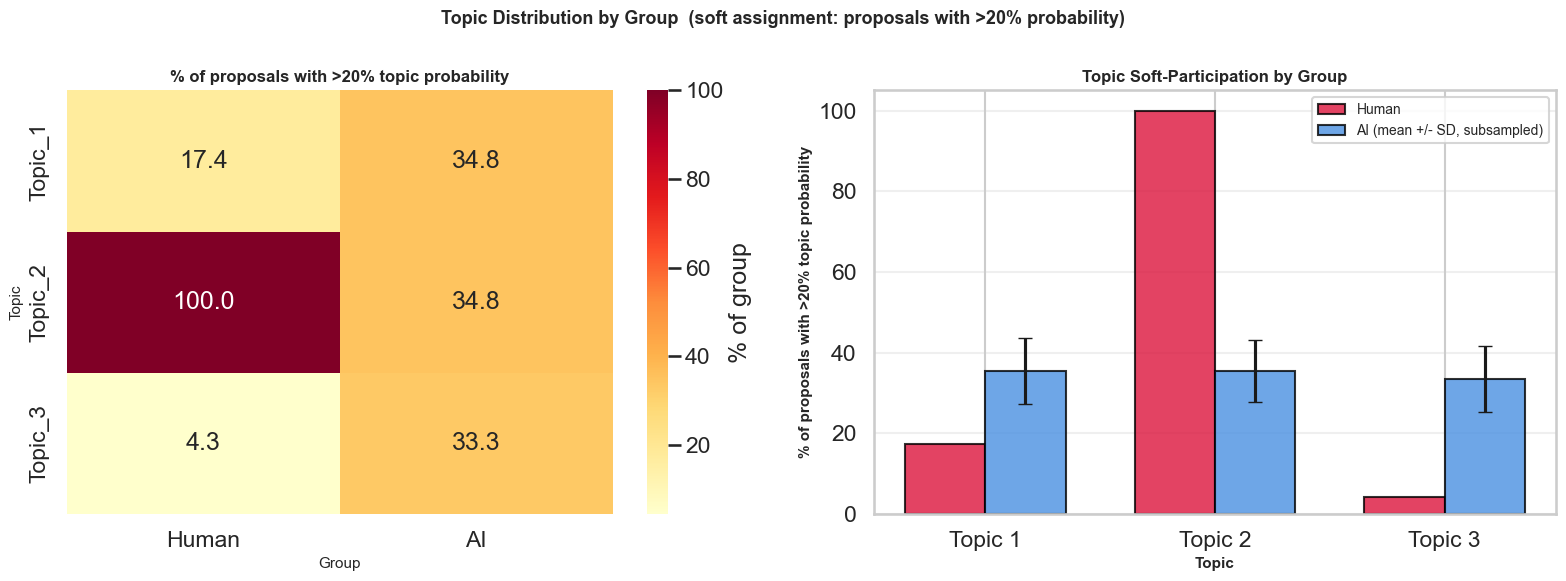

Figure saved to: results/figures/rephrased/topic_distribution_comparison.png


In [61]:
import seaborn as sns

# Visualization: Soft-assignment topic distribution by group
threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_df_t = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_df_t    = doc_topic_df[doc_topic_df['group'] == 'AI']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Topic Distribution by Group  (soft assignment: proposals with >20% probability)",
             fontsize=13, fontweight='bold')

# Panel 1: Heatmap -- fraction of group with >20% for each topic
soft_frac = pd.DataFrame({
    'Human': {col: (human_df_t[col] > threshold).mean() * 100 for col in topic_cols},
    'AI':    {col: (ai_df_t[col]    > threshold).mean() * 100 for col in topic_cols},
})
sns.heatmap(soft_frac, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': '% of group'})
axes[0].set_title('% of proposals with >20% topic probability', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Group', fontsize=11)
axes[0].set_ylabel('Topic', fontsize=11)

# Panel 2: Bar plot with subsample error bars
x     = np.arange(len(topic_cols))
width = 0.35
human_pcts = [(human_df_t[col] > threshold).mean() * 100 for col in topic_cols]

ai_pcts_mean, ai_pcts_std = [], []
ai_idx = ai_df_t.index
for col in topic_cols:
    vals = []
    for _ in range(500):
        s = doc_topic_df.loc[np.random.choice(ai_idx, size=len(human_df_t), replace=False)]
        vals.append((s[col] > threshold).mean() * 100)
    ai_pcts_mean.append(np.mean(vals))
    ai_pcts_std.append(np.std(vals))

axes[1].bar(x - width/2, human_pcts,  width,
            label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
axes[1].bar(x + width/2, ai_pcts_mean, width, yerr=ai_pcts_std,
            label='AI (mean +/- SD, subsampled)',
            color='#4A90E2', alpha=0.8, edgecolor='black', capsize=5)
axes[1].set_xlabel('Topic', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% of proposals with >20% topic probability', fontsize=11, fontweight='bold')
axes[1].set_title('Topic Soft-Participation by Group', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace('_', ' ') for c in topic_cols])
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'topic_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to: results/figures/rephrased/topic_distribution_comparison.png")


## Analysis 3.3: Topic Coverage and Entropy

Examine breadth and evenness of topic coverage with sample size corrections.

In [62]:
from scipy.stats import entropy as scipy_entropy

print("="*85)
print("TOPIC COVERAGE AND ENTROPY ANALYSIS  (soft assignment throughout)")
print("="*85)

threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_doc_topics = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_doc_topics    = doc_topic_df[doc_topic_df['group'] == 'AI']

# ── 1. Coverage (unchanged -- already used soft assignment) ───────────────────
def count_topics_covered(group_df, topic_cols, threshold=0.20):
    return sum(1 for col in topic_cols if (group_df[col] > threshold).any())

human_coverage = count_topics_covered(human_doc_topics, topic_cols, threshold)
ai_coverage    = count_topics_covered(ai_doc_topics,    topic_cols, threshold)

print()
print(f"1. TOPIC COVERAGE (topics with at least one proposal >{threshold*100:.0f}% probability):")
print(f"  Human: {human_coverage}/{len(topic_cols)} topics")
print(f"  AI:    {ai_coverage}/{len(topic_cols)} topics")

# ── 2. Exclusive topics -- soft, min_count=2 (was 5; too strict at n=23) ─────
def get_exclusive_topics_soft(group_df, other_df, topic_cols, threshold=0.20, min_count=2):
    """Topics where group has >=min_count proposals >threshold AND other group has 0."""
    return [(col, int((group_df[col] > threshold).sum()))
            for col in topic_cols
            if (group_df[col] > threshold).sum() >= min_count
            and (other_df[col] > threshold).sum() == 0]

human_exclusive_raw = get_exclusive_topics_soft(human_doc_topics, ai_doc_topics,    topic_cols, threshold)
ai_exclusive_raw    = get_exclusive_topics_soft(ai_doc_topics,    human_doc_topics, topic_cols, threshold)

human_exclusive = [t for t, _ in human_exclusive_raw]
ai_exclusive    = [t for t, _ in ai_exclusive_raw]

print()
print(f"2. EXCLUSIVE TOPICS (soft: >=2 proposals >{threshold*100:.0f}% probability, 0 in other group):")
print(f"  Human-exclusive: {len(human_exclusive)}")
for t, n in human_exclusive_raw:
    print(f"    {t} ({n} proposals)")
print(f"  AI-exclusive:    {len(ai_exclusive)}")
for t, n in ai_exclusive_raw:
    print(f"    {t} ({n} proposals)")

print()
print("  Permutation test for exclusive topic counts:")
n_perm    = 10000
perm_h_exc = []
perm_a_exc = []
for _ in range(n_perm):
    shuffled          = doc_topic_df.copy()
    shuffled['group'] = np.random.permutation(shuffled['group'].values)
    h = shuffled[shuffled['group'] == 'Human']
    a = shuffled[shuffled['group'] == 'AI']
    perm_h_exc.append(len(get_exclusive_topics_soft(h, a, topic_cols, threshold)))
    perm_a_exc.append(len(get_exclusive_topics_soft(a, h, topic_cols, threshold)))

perm_h_exc = np.array(perm_h_exc)
perm_a_exc = np.array(perm_a_exc)
p_human = np.mean(perm_h_exc >= len(human_exclusive))
p_ai    = np.mean(perm_a_exc >= len(ai_exclusive))
print(f"    Human: {len(human_exclusive)} observed vs. {perm_h_exc.mean():.2f} +/- {perm_h_exc.std():.2f} expected, p={p_human:.4f}")
print(f"    AI:    {len(ai_exclusive)} observed vs. {perm_a_exc.mean():.2f} +/- {perm_a_exc.std():.2f} expected, p={p_ai:.4f}")

# ── 3. Shannon entropy on MEAN SOFT TOPIC DISTRIBUTION ───────────────────────
print()
print("3. SHANNON ENTROPY on mean soft topic distribution (Miller-Madow corrected):")
print("   Uses mean LDA probability across proposals -- more informative than dominant-topic counts.")

def group_soft_entropy(group_df, topic_cols, base=2):
    mean_dist    = group_df[topic_cols].mean()
    mean_dist    = mean_dist / mean_dist.sum()
    h            = float(scipy_entropy(mean_dist, base=base))
    k            = len(topic_cols)
    n            = len(group_df)
    h_corrected  = h + (k - 1) / (2 * n)
    h_max        = np.log2(k)
    h_normalized = h_corrected / h_max if h_max > 0 else 0
    return h_corrected, h_normalized

human_entropy, human_norm_entropy = group_soft_entropy(human_doc_topics, topic_cols)
ai_entropy,    ai_norm_entropy    = group_soft_entropy(ai_doc_topics,    topic_cols)

print(f"  Human: H = {human_entropy:.4f}, H_normalized = {human_norm_entropy:.4f}")
print(f"  AI:    H = {ai_entropy:.4f}, H_normalized = {ai_norm_entropy:.4f}")

print()
print(f"  Subsample validation (AI subsampled to n={len(human_doc_topics)}, 1000 iterations):")
subsample_entropies      = []
subsample_norm_entropies = []
ai_idx = ai_doc_topics.index
for _ in range(1000):
    sampled = ai_doc_topics.loc[np.random.choice(ai_idx, size=len(human_doc_topics), replace=False)]
    h, h_norm = group_soft_entropy(sampled, topic_cols)
    subsample_entropies.append(h)
    subsample_norm_entropies.append(h_norm)

subsample_entropies      = np.array(subsample_entropies)
subsample_norm_entropies = np.array(subsample_norm_entropies)

print(f"    AI (subsampled): H = {subsample_entropies.mean():.4f} +/- {subsample_entropies.std():.4f}")
print(f"    AI (subsampled): H_normalized = {subsample_norm_entropies.mean():.4f} +/- {subsample_norm_entropies.std():.4f}")

diff        = human_entropy - subsample_entropies.mean()
p_lower     = np.mean(subsample_entropies <= human_entropy)
p_upper     = np.mean(subsample_entropies >= human_entropy)
p_two_sided = min(1.0, 2 * min(p_lower, p_upper))
p_one_sided = p_lower if human_entropy < subsample_entropies.mean() else p_upper
p_entropy   = p_two_sided

print()
print("  Comparison (subsample test):")
print(f"    Difference (Human - AI_subsample_mean): {diff:.4f}")
print(f"    p_one_sided (observed direction): {p_one_sided:.4f}")
print(f"    p_two_sided: {p_two_sided:.4f}")
if p_two_sided < 0.05:
    direction_str = "HIGHER" if human_entropy > subsample_entropies.mean() else "LOWER"
    print(f"    -> Human proposals have significantly {direction_str} entropy")
else:
    print("    -> No significant difference in entropy")

print()
print("  Higher entropy = more even spread of probability mass across topics")
print("  Soft entropy avoids the dominant-topic discretization artifact.")
print("="*85)


TOPIC COVERAGE AND ENTROPY ANALYSIS  (soft assignment throughout)

1. TOPIC COVERAGE (topics with at least one proposal >20% probability):
  Human: 3/3 topics
  AI:    3/3 topics

2. EXCLUSIVE TOPICS (soft: >=2 proposals >20% probability, 0 in other group):
  Human-exclusive: 0
  AI-exclusive:    0

  Permutation test for exclusive topic counts:
    Human: 0 observed vs. 0.00 +/- 0.00 expected, p=1.0000
    AI:    0 observed vs. 0.00 +/- 0.02 expected, p=1.0000

3. SHANNON ENTROPY on mean soft topic distribution (Miller-Madow corrected):
   Uses mean LDA probability across proposals -- more informative than dominant-topic counts.
  Human: H = 0.5470, H_normalized = 0.3451
  AI:    H = 1.5990, H_normalized = 1.0089

  Subsample validation (AI subsampled to n=23, 1000 iterations):
    AI (subsampled): H = 1.5865 +/- 0.0428
    AI (subsampled): H_normalized = 1.0010 +/- 0.0270

  Comparison (subsample test):
    Difference (Human - AI_subsample_mean): -1.0395
    p_one_sided (observed dir

## Analysis 3.4: Cluster Composition/Segregation Analysis

Examine whether human and AI proposals segregate into distinct clusters in embedding space using Gaussian Mixture Models.

In [63]:
from pathlib import Path

emb_path = PROPOSAL_EMBEDDINGS_FILE
if not emb_path.exists():
    legacy_paths = sorted(emb_path.parent.glob('proposal_embeddings_[0-9]*.pkl'))
    if not legacy_paths:
        raise FileNotFoundError(f"No embedding pickle found at {emb_path}. Run the embedding generation cell first.")
    emb_path = legacy_paths[-1]

embeddings_data = retrieve_embeddings(str(emb_path))

ai_embeddings = embeddings_data['ai_embeddings']
human_embeddings = embeddings_data['human_embeddings']
# ai_metadata = embeddings_data['ai_metadata']
# human_metadata = embeddings_data['human_metadata']

print(f"✓ Loaded embeddings from: {emb_path}")
print(f"  AI: {ai_embeddings.shape}, Human: {human_embeddings.shape}")


✓ Loaded embeddings from: ../data/embeddings/rephrased/minimal/proposal_embeddings_human_ai_rephrased.pkl
  AI: (69, 1024), Human: (23, 1024)


CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION

Using embeddings: (92, 1024)
  Human: 23, AI: 69

Testing k = [3, 4, 5, 6, 7, 8]...

k     Silhouette   Davies-Bouldin   BIC         
--------------------------------------------------
3     0.1593       2.2460           6049599.52  
4     0.0542       3.3866           8420990.30  
5     0.0541       2.9441           10788294.60 
6     0.0523       2.6029           13166126.86 
7     0.0302       2.4812           15546750.56 
8     0.0241       2.3345           17921300.63 

✓ Best k by BIC (elbow method): 3
✓ Best k by Silhouette score: 3

→ Selected k = 3 (using BIC)


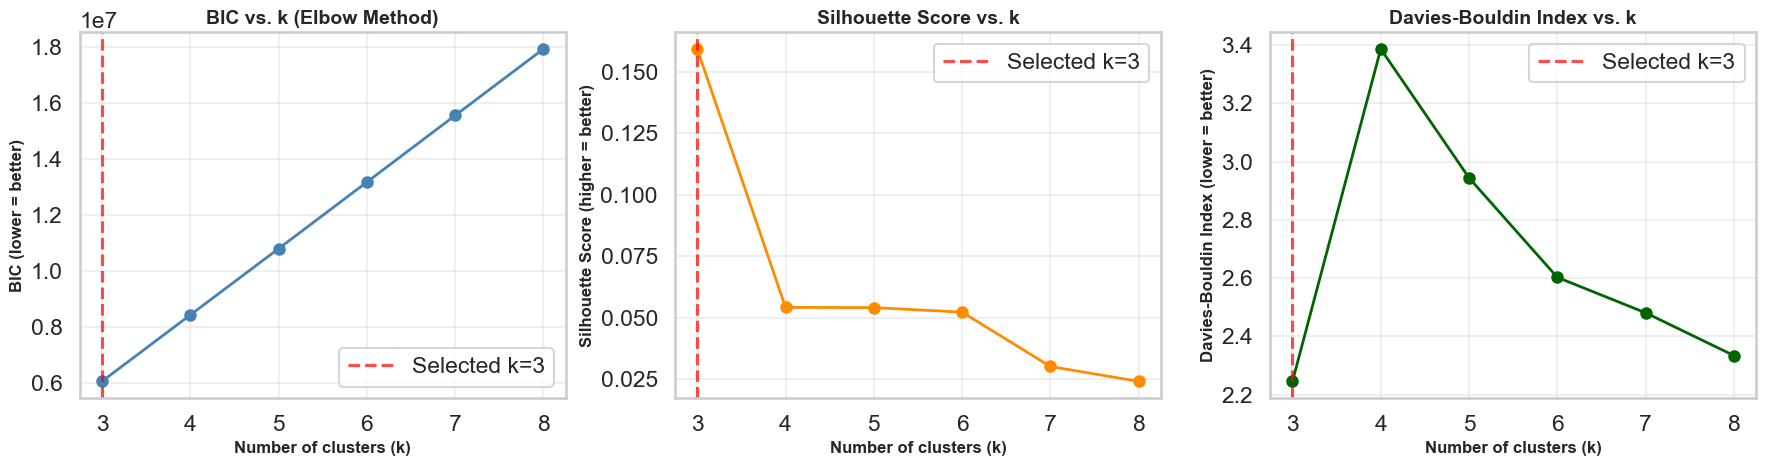

✓ Figure saved to: results/figures/rephrased/cluster_k_selection.png


In [64]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, normalized_mutual_info_score, adjusted_rand_score

print("="*85)
print("CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION")
print("="*85)

# Use embeddings from diversity analysis (already computed)
all_embeddings_cluster = np.vstack([human_embeddings, ai_embeddings])
source_labels_cluster = np.array(['Human'] * len(human_embeddings) + ['AI'] * len(ai_embeddings))

print(f"\nUsing embeddings: {all_embeddings_cluster.shape}")
print(f"  Human: {len(human_embeddings)}, AI: {len(ai_embeddings)}")

# Test different values of k
k_values = [3, 4, 5, 6, 7, 8]
metrics_results = []

print(f"\nTesting k = {k_values}...")
print(f"\n{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<16} {'BIC':<12}")
print("-"*50)

for k in k_values:
    # Fit GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    cluster_labels = gmm.fit_predict(all_embeddings_cluster)
    
    # Compute metrics
    silhouette = silhouette_score(all_embeddings_cluster, cluster_labels)
    davies_bouldin = davies_bouldin_score(all_embeddings_cluster, cluster_labels)
    bic = gmm.bic(all_embeddings_cluster)
    
    metrics_results.append({
        'k': k,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'bic': bic
    })
    
    print(f"{k:<5} {silhouette:<12.4f} {davies_bouldin:<16.4f} {bic:<12.2f}")

metrics_df = pd.DataFrame(metrics_results)

# Select best k using BIC (lower is better)
best_k_bic = metrics_df.loc[metrics_df['bic'].idxmin(), 'k']
best_k_silhouette = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k']

print(f"\n✓ Best k by BIC (elbow method): {best_k_bic}")
print(f"✓ Best k by Silhouette score: {best_k_silhouette}")

# Use BIC as primary criterion
best_k = int(best_k_bic)
print(f"\n→ Selected k = {best_k} (using BIC)")

# Visualize selection metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: BIC
ax1 = axes[0]
ax1.plot(metrics_df['k'], metrics_df['bic'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax1.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('BIC (lower = better)', fontsize=12, fontweight='bold')
ax1.set_title('BIC vs. k (Elbow Method)', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Panel 2: Silhouette
ax2 = axes[1]
ax2.plot(metrics_df['k'], metrics_df['silhouette'], 'o-', linewidth=2, markersize=8, color='darkorange')
ax2.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax2.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

# Panel 3: Davies-Bouldin
ax3 = axes[2]
ax3.plot(metrics_df['k'], metrics_df['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='darkgreen')
ax3.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax3.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Davies-Bouldin Index (lower = better)', fontsize=12, fontweight='bold')
ax3.set_title('Davies-Bouldin Index vs. k', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/cluster_k_selection.png")
print("="*85)

In [65]:
print("="*85)
print(f"CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k={best_k}")
print("="*85)

# Fit final GMM with best k
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42,
    n_init=10
)

cluster_labels_final = gmm_final.fit_predict(all_embeddings_cluster)
cluster_probs_final = gmm_final.predict_proba(all_embeddings_cluster)

print(f"\n✓ Clustered {len(all_embeddings_cluster)} proposals into {best_k} clusters")
print(f"  Cluster sizes: {np.bincount(cluster_labels_final)}")

# Cluster composition analysis
print(f"\n" + "-"*85)
print("CLUSTER COMPOSITION ANALYSIS")
print("-"*85)

cluster_composition = []

for cluster_id in range(best_k):
    cluster_mask = cluster_labels_final == cluster_id
    cluster_sources = source_labels_cluster[cluster_mask]
    
    n_total = len(cluster_sources)
    n_human = (cluster_sources == 'Human').sum()
    n_ai = (cluster_sources == 'AI').sum()
    
    pct_human = n_human / n_total * 100 if n_total > 0 else 0
    pct_ai = n_ai / n_total * 100 if n_total > 0 else 0
    
    # Classify cluster dominance (baseline: 25% human, 75% AI)
    if pct_human > 60:
        dominance = 'Human-dominated'
    elif pct_human < 15:  # Less than expected given 25% baseline
        dominance = 'AI-dominated'
    else:
        dominance = 'Mixed'
    
    cluster_composition.append({
        'cluster': cluster_id,
        'total': n_total,
        'human': n_human,
        'ai': n_ai,
        'pct_human': pct_human,
        'pct_ai': pct_ai,
        'dominance': dominance
    })

composition_df = pd.DataFrame(cluster_composition)

print(f"\n{'Cluster':<10} {'Total':<8} {'Human':<8} {'AI':<8} {'%Human':<10} {'%AI':<10} {'Dominance'}")
print("-"*85)

for _, row in composition_df.iterrows():
    print(f"{row['cluster']:<10} {row['total']:<8} {row['human']:<8} {row['ai']:<8} "
          f"{row['pct_human']:<10.1f} {row['pct_ai']:<10.1f} {row['dominance']}")

print(f"\n{'Dominance':<20} {'Count'}")
print("-"*30)
dominance_counts = composition_df['dominance'].value_counts()
for dom, count in dominance_counts.items():
    print(f"{dom:<20} {count}")

print(f"\n💡 Baseline: 25% human, 75% AI")
print(f"   Human-dominated: >60% human")
print(f"   AI-dominated: <15% human")
print(f"   Mixed: 15-60% human")
print("="*85)

CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k=3

✓ Clustered 92 proposals into 3 clusters
  Cluster sizes: [24 19 49]

-------------------------------------------------------------------------------------
CLUSTER COMPOSITION ANALYSIS
-------------------------------------------------------------------------------------

Cluster    Total    Human    AI       %Human     %AI        Dominance
-------------------------------------------------------------------------------------
0          24       5        19       20.8       79.2       Mixed
1          19       11       8        57.9       42.1       Mixed
2          49       7        42       14.3       85.7       AI-dominated

Dominance            Count
------------------------------
Mixed                2
AI-dominated         1

💡 Baseline: 25% human, 75% AI
   Human-dominated: >60% human
   AI-dominated: <15% human
   Mixed: 15-60% human


In [66]:
print("="*85)
print("CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)")
print("="*85)

# Convert source labels to binary (0 = Human, 1 = AI)
source_binary = (source_labels_cluster == 'AI').astype(int)

# 1. Normalized Mutual Information (NMI)
nmi_observed = normalized_mutual_info_score(cluster_labels_final, source_binary)

print(f"\n1. NORMALIZED MUTUAL INFORMATION (NMI):")
print(f"   Observed NMI: {nmi_observed:.4f}")

# Permutation test for NMI
n_perm_seg = 10000
nmi_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    nmi_perm = normalized_mutual_info_score(cluster_labels_final, shuffled_sources)
    nmi_null.append(nmi_perm)

nmi_null = np.array(nmi_null)
p_nmi = np.mean(nmi_null >= nmi_observed)

print(f"   Null distribution: {nmi_null.mean():.4f} ± {nmi_null.std():.4f}")
print(f"   p-value: {p_nmi:.4f}")

if p_nmi < 0.05:
    print(f"   → Significant segregation: clusters predict source better than chance")
else:
    print(f"   → No significant segregation: clustering independent of source")

# 2. Adjusted Rand Index (ARI)
ari_observed = adjusted_rand_score(cluster_labels_final, source_binary)

print(f"\n2. ADJUSTED RAND INDEX (ARI):")
print(f"   Observed ARI: {ari_observed:.4f}")

# Permutation test for ARI
ari_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    ari_perm = adjusted_rand_score(cluster_labels_final, shuffled_sources)
    ari_null.append(ari_perm)

ari_null = np.array(ari_null)
p_ari = np.mean(ari_null >= ari_observed)

print(f"   Null distribution: {ari_null.mean():.4f} ± {ari_null.std():.4f}")
print(f"   p-value: {p_ari:.4f}")

if p_ari < 0.05:
    print(f"   → Significant agreement: cluster assignments correlate with source")
else:
    print(f"   → No significant agreement: random overlap")

# 3. Within-group vs. Between-group distances
print(f"\n3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:")

# Calculate pairwise distances
from sklearn.metrics.pairwise import cosine_distances

distances_all = cosine_distances(all_embeddings_cluster)

# Within-human distances
human_mask = source_labels_cluster == 'Human'
within_human_dists = distances_all[np.ix_(human_mask, human_mask)]
within_human_dists = within_human_dists[np.triu_indices_from(within_human_dists, k=1)]

# Within-AI distances
ai_mask = source_labels_cluster == 'AI'
within_ai_dists = distances_all[np.ix_(ai_mask, ai_mask)]
within_ai_dists = within_ai_dists[np.triu_indices_from(within_ai_dists, k=1)]

# Between human-AI distances
between_dists = distances_all[np.ix_(human_mask, ai_mask)].flatten()

print(f"   Within-human mean distance: {within_human_dists.mean():.4f} ± {within_human_dists.std():.4f}")
print(f"   Within-AI mean distance: {within_ai_dists.mean():.4f} ± {within_ai_dists.std():.4f}")
print(f"   Between human-AI mean distance: {between_dists.mean():.4f} ± {between_dists.std():.4f}")

# Ratio of between to within
within_mean = np.mean([within_human_dists.mean(), within_ai_dists.mean()])
between_within_ratio = between_dists.mean() / within_mean

print(f"\n   Between/Within ratio: {between_within_ratio:.4f}")

# Permutation test for between/within ratio
ratio_null = []

for _ in range(n_perm_seg):
    shuffled = np.random.permutation(source_labels_cluster)
    h_mask = shuffled == 'Human'
    a_mask = shuffled == 'AI'
    
    within_h = distances_all[np.ix_(h_mask, h_mask)]
    within_h = within_h[np.triu_indices_from(within_h, k=1)]
    
    within_a = distances_all[np.ix_(a_mask, a_mask)]
    within_a = within_a[np.triu_indices_from(within_a, k=1)]
    
    between = distances_all[np.ix_(h_mask, a_mask)].flatten()
    
    within_m = np.mean([within_h.mean(), within_a.mean()])
    ratio_perm = between.mean() / within_m
    ratio_null.append(ratio_perm)

ratio_null = np.array(ratio_null)
p_ratio = np.mean(ratio_null >= between_within_ratio)

print(f"   Null distribution: {ratio_null.mean():.4f} ± {ratio_null.std():.4f}")
print(f"   p-value: {p_ratio:.4f}")

if p_ratio < 0.05:
    if between_within_ratio > 1:
        print(f"   → Human and AI proposals are significantly MORE distant from each other than within groups")
    else:
        print(f"   → Human and AI proposals are significantly CLOSER to each other than within groups")
else:
    print(f"   → No significant difference in between vs. within-group distances")

print("\n" + "="*85)
print("INTERPRETATION SUMMARY")
print("="*85)

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions")
    print("  → They generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ INTEGRATION: Human and AI proposals intermixed in embedding space")
    print("  → Ideas are similar regardless of source")
else:
    print("✓ INTERMEDIATE: Some thematic clustering but not strictly by source")

print("="*85)

CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)

1. NORMALIZED MUTUAL INFORMATION (NMI):
   Observed NMI: 0.0887
   Null distribution: 0.0145 ± 0.0146
   p-value: 0.0025
   → Significant segregation: clusters predict source better than chance

2. ADJUSTED RAND INDEX (ARI):
   Observed ARI: 0.1254
   Null distribution: -0.0002 ± 0.0285
   p-value: 0.0019
   → Significant agreement: cluster assignments correlate with source

3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:
   Within-human mean distance: 0.4429 ± 0.3176
   Within-AI mean distance: 0.1826 ± 0.2796
   Between human-AI mean distance: 0.3880 ± 0.3394

   Between/Within ratio: 1.2406
   Null distribution: 1.0009 ± 0.0332
   p-value: 0.0017
   → Human and AI proposals are significantly MORE distant from each other than within groups

INTERPRETATION SUMMARY
✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions
  → They generate different KINDS of ideas


CLUSTER ANALYSIS: STEP 4 - VISUALIZATION
Reducing to 2D with UMAP for visualization...
✓ UMAP projection complete: (92, 2)


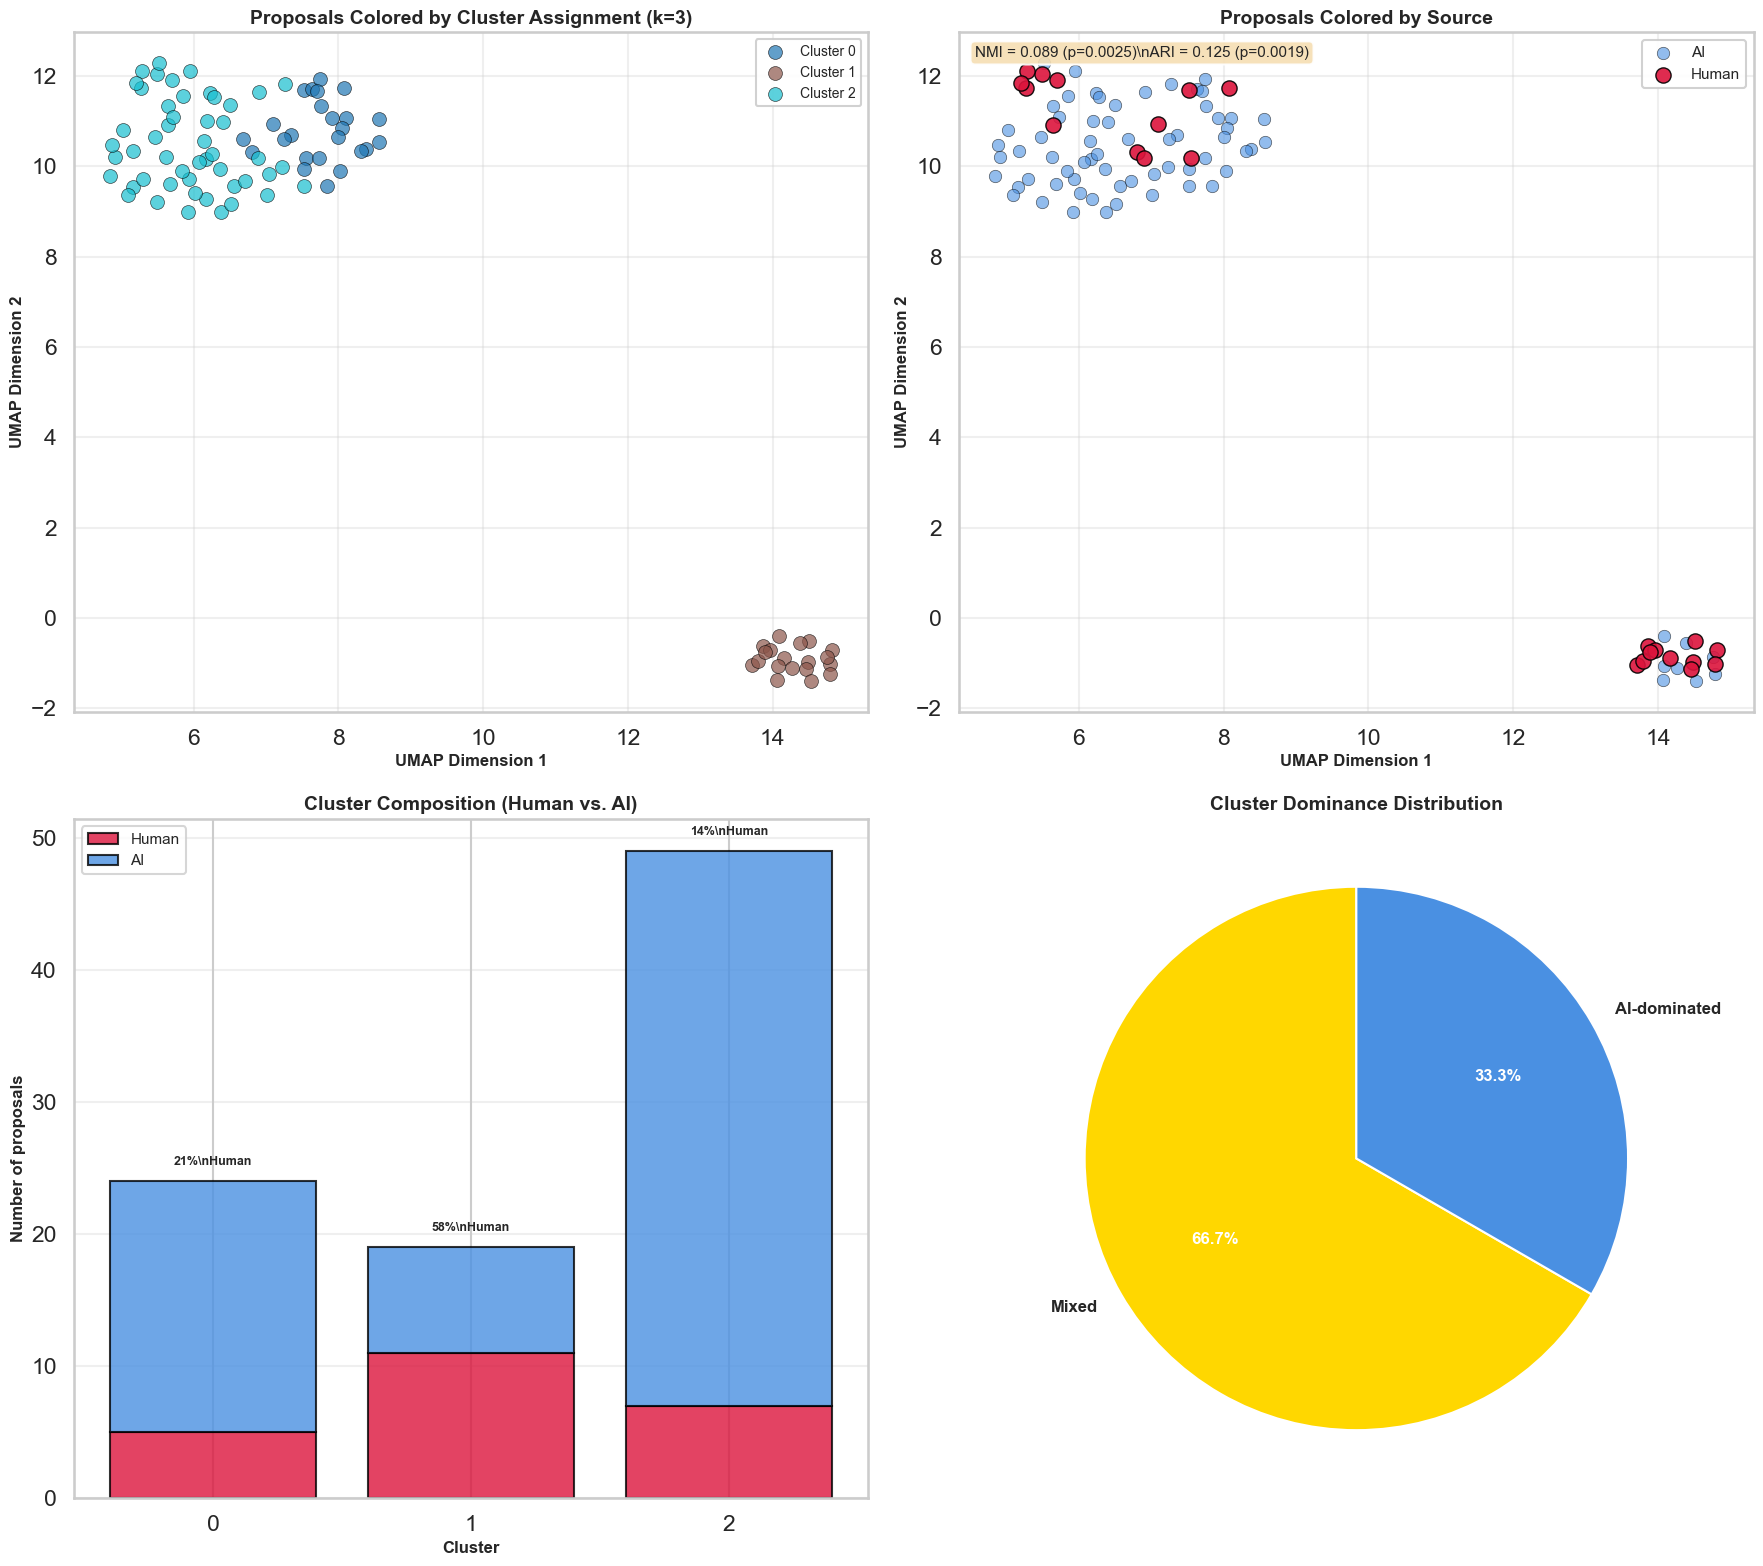

✓ Figure saved to: results/figures/rephrased/cluster_analysis_visualization.png


In [67]:
import umap
# Visualization: Cluster analysis in 2D embedding space
print("="*85)
print("CLUSTER ANALYSIS: STEP 4 - VISUALIZATION")
print("="*85)

# Use existing UMAP projection from earlier analysis
# Apply UMAP if not already done for this combined set
print("Reducing to 2D with UMAP for visualization...")

reducer_cluster = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_cluster = reducer_cluster.fit_transform(all_embeddings_cluster)

print(f"✓ UMAP projection complete: {embeddings_2d_cluster.shape}")

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Color schemes
source_colors = {'Human': '#DC143C', 'AI': '#4A90E2'}
cluster_colors = plt.cm.tab10(np.linspace(0, 1, best_k))

# Panel 1: Colored by cluster assignment
ax1 = axes[0, 0]
for cluster_id in range(best_k):
    mask = cluster_labels_final == cluster_id
    ax1.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=[cluster_colors[cluster_id]], label=f'Cluster {cluster_id}',
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax1.set_title(f'Proposals Colored by Cluster Assignment (k={best_k})', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)

# Panel 2: Colored by source (Human vs. AI)
ax2 = axes[0, 1]
for source in ['AI', 'Human']:  # Plot AI first, Human on top
    mask = source_labels_cluster == source
    ax2.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=source_colors[source], label=source,
               s=120 if source == 'Human' else 80, 
               alpha=0.9 if source == 'Human' else 0.6,
               edgecolors='black', linewidth=1.0 if source == 'Human' else 0.5)

ax2.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax2.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax2.set_title('Proposals Colored by Source', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3)

# Add NMI and ARI as text
textstr = f'NMI = {nmi_observed:.3f} (p={p_nmi:.4f})\\nARI = {ari_observed:.3f} (p={p_ari:.4f})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Panel 3: Cluster composition (stacked bar chart)
ax3 = axes[1, 0]
cluster_ids = composition_df['cluster'].values
human_counts = composition_df['human'].values
ai_counts = composition_df['ai'].values

ax3.bar(cluster_ids, human_counts, label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
ax3.bar(cluster_ids, ai_counts, bottom=human_counts, label='AI', color='#4A90E2', alpha=0.8, edgecolor='black')

ax3.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of proposals', fontsize=12, fontweight='bold')
ax3.set_title('Cluster Composition (Human vs. AI)', fontsize=14, fontweight='bold')
ax3.set_xticks(cluster_ids)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, cluster_id in enumerate(cluster_ids):
    total = composition_df.loc[i, 'total']
    pct_h = composition_df.loc[i, 'pct_human']
    ax3.text(cluster_id, total + 1, f'{pct_h:.0f}%\\nHuman', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: Cluster dominance pie chart
ax4 = axes[1, 1]
dominance_counts = composition_df['dominance'].value_counts()
colors_pie = {'Human-dominated': '#DC143C', 'AI-dominated': '#4A90E2', 'Mixed': '#FFD700'}
pie_colors = [colors_pie.get(d, 'gray') for d in dominance_counts.index]

wedges, texts, autotexts = ax4.pie(dominance_counts.values, labels=dominance_counts.index, 
                                     autopct='%1.1f%%', startangle=90,
                                     colors=pie_colors, textprops={'fontsize': 12, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax4.set_title('Cluster Dominance Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/cluster_analysis_visualization.png")
print("="*85)

### PART III Summary

In [68]:
print("="*85)
print("ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY")
print("="*85)

if 'p_entropy' not in globals():
    p_entropy = p_two_sided if 'p_two_sided' in globals() else np.nan

print()
print("="*85)
print("1. TOPIC MODELING (LDA with n=5 topics)")
print("="*85)
print("  Model: Latent Dirichlet Allocation")
print("  Parameters: alpha=0.5, beta=0.5 (strong regularization)")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print("  Topics identified:")
for i, topic_words in enumerate(topics):
    print(f"    Topic {i+1}: {', '.join(topic_words[:5])}...")

print()
print("="*85)
print("2. TOPIC DISTRIBUTION COMPARISON")
print("="*85)
print("  Overall distribution test (permutation):")
print(f"    Chi-square: {observed_chi2:.4f}, p={p_value_perm:.4f}")
if p_value_perm < 0.05:
    print("    → Significant difference in topic distributions")
else:
    print("    → No significant difference in topic distributions")

print("  Per-topic tests (Fisher's exact with FDR correction):")
significant_topics = fisher_df[fisher_df['p_value_fdr'] < 0.10]
if len(significant_topics) > 0:
    print(f"    {len(significant_topics)} topics show significant over/under-representation:")
    for _, row in significant_topics.iterrows():
        direction = 'Human' if row['odds_ratio'] > 1 else 'AI'
        print(f"      {row['topic']}: OR={row['odds_ratio']:.2f}, p_fdr={row['p_value_fdr']:.4f} ({direction}↑)")
else:
    print("    No topics show significant over/under-representation (FDR q=0.10)")

print()
print("="*85)
print("3. TOPIC COVERAGE AND ENTROPY")
print("="*85)
print("  Coverage (topics with >20% probability):")
print(f"    Human: {human_coverage}/{n_topics} topics")
print(f"    AI: {ai_coverage}/{n_topics} topics")
print("  Exclusive topics (≥5 proposals):")
print(f"    Human-exclusive: {len(human_exclusive)} (p={p_human:.4f})")
print(f"    AI-exclusive: {len(ai_exclusive)} (p={p_ai:.4f})")
print("  Shannon entropy (Miller-Madow corrected):")
print(f"    Human: H={human_entropy:.4f}, H_norm={human_norm_entropy:.4f}")
print(f"    AI (subsampled): H={subsample_entropies.mean():.4f}±{subsample_entropies.std():.4f}")
print(f"    Difference (two-sided): p={p_entropy:.4f}")

print()
print("="*85)
print(f"4. CLUSTER ANALYSIS (GMM with k={best_k})")
print("="*85)
print("  Model selection:")
print(f"    Best k by BIC: {best_k}")
print(f"    Silhouette score: {metrics_df.loc[metrics_df['k']==best_k, 'silhouette'].values[0]:.4f}")
print("  Cluster composition:")
print(f"    Human-dominated clusters: {(composition_df['dominance']=='Human-dominated').sum()}")
print(f"    AI-dominated clusters: {(composition_df['dominance']=='AI-dominated').sum()}")
print(f"    Mixed clusters: {(composition_df['dominance']=='Mixed').sum()}")
print("  Segregation metrics:")
print(f"    NMI: {nmi_observed:.4f} (null: {nmi_null.mean():.4f}±{nmi_null.std():.4f}, p={p_nmi:.4f})")
print(f"    ARI: {ari_observed:.4f} (null: {ari_null.mean():.4f}±{ari_null.std():.4f}, p={p_ari:.4f})")
print(f"    Between/Within distance ratio: {between_within_ratio:.4f} (p={p_ratio:.4f})")

print()
print("="*85)
print("OVERALL INTERPRETATION")
print("="*85)
if p_value_perm < 0.05:
    print("✓ Topics: Human and AI differ in topic distributions")
else:
    print("✓ Topics: No significant difference in topic distributions")

if np.isfinite(p_entropy) and p_entropy < 0.05:
    if diff > 0:
        print("✓ Entropy: Human proposals show higher thematic diversity")
    else:
        print("✓ Entropy: AI proposals show higher thematic diversity")
else:
    print("✓ Entropy: Similar thematic diversity between groups")

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ Clustering: SEGREGATION - Human and AI occupy distinct semantic regions")
    print("  → Generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ Clustering: INTEGRATION - Human and AI ideas are intermixed")
    print("  → Similar ideas regardless of source")
else:
    print("✓ Clustering: INTERMEDIATE - Some thematic patterns but not strict segregation")

print()
print("⚠️  LIMITATIONS:")
print("  • Small sample size (n=23 human, n=69 AI)")
print("  • Topic modeling labeled as EXPLORATORY")
print("  • Results should be validated with larger samples")
print("  • Segregation may reflect prompt differences, not inherent ideation differences")

print()
print("="*85)
print("📊 FIGURES GENERATED:")
print("="*85)
print("  1. results/figures/rephrased/cluster_k_selection.png")
print("  2. results/figures/rephrased/topic_distribution_comparison.png")
print("  3. results/figures/rephrased/cluster_analysis_visualization.png")
print("="*85)


ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY

1. TOPIC MODELING (LDA with n=5 topics)
  Model: Latent Dirichlet Allocation
  Parameters: alpha=0.5, beta=0.5 (strong regularization)
  Perplexity: 1128.44
  Topics identified:
    Topic 1: emergence, working group, collaborative, ai, science...
    Topic 2: imaging, network, rna, spatial, networks...
    Topic 3: structural, organization, aim, interaction, institutions...

2. TOPIC DISTRIBUTION COMPARISON
  Overall distribution test (permutation):
    Chi-square: 19.4700, p=0.0000
    → Significant difference in topic distributions
  Per-topic tests (Fisher's exact with FDR correction):
    2 topics show significant over/under-representation:
      Topic_2: OR=inf, p_fdr=0.0000 (Human↑)
      Topic_3: OR=0.09, p_fdr=0.0082 (AI↑)

3. TOPIC COVERAGE AND ENTROPY
  Coverage (topics with >20% probability):
    Human: 3/3 topics
    AI: 3/3 topics
  Exclusive topics (≥5 proposals):
    Human-exclusive: 0 (p=1.0000)
    AI

----------------------------
# PART IV Style Baseline

Before interpreting embedding distances, clustering segregation (NMI/ARI), or topic separation as “conceptual” differences, quantify how much **purely stylistic** signals can separate Human vs. AI. If a style-only model predicts source well, then a substantial portion of downstream “segregation/diversity” effects may be stylistic rather than conceptual.

### Exract stylistic features

In [69]:
# =============================================================================
# ANALYSIS 2.3.5–2.3.6: STYLE VS CONTENT (Baseline + Style-Controlled Sensitivity)
# Text scope: full proposals (full_text)
# =============================================================================

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ----------------------------
# Style feature extraction
# ----------------------------

_HEDGE_WORDS = {
    'may','might','could','can','suggest','suggests','suggested','potential','potentially',
    'likely','unlikely','possibly','possible','approximately','estimate','estimated',
    'hypothesize','hypothesis','we propose','we aim','we will','we plan'
}

def _tokenize_words(text: str):
    return re.findall(r"[A-Za-z']+", text.lower())

def _split_sentences(text: str):
    # lightweight sentence split for readability/stylistic counts
    sents = re.split(r"[.!?]+\s+|\n+", text.strip())
    return [s for s in (sent.strip() for sent in sents) if s]

def _count_syllables(word: str) -> int:
    # heuristic syllable counter (good enough for comparative readability proxies)
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    w = re.sub(r"e$", "", w)  # silent e
    groups = re.findall(r"[aeiouy]+", w)
    return max(1, len(groups))

def _flesch_kincaid(text: str):
    words = _tokenize_words(text)
    n_words = len(words)
    sents = _split_sentences(text)
    n_sents = len(sents)
    if n_words == 0 or n_sents == 0:
        return np.nan, np.nan
    syllables = sum(_count_syllables(w) for w in words)

    # Flesch Reading Ease & FK Grade Level (English)
    fre = 206.835 - 1.015 * (n_words / n_sents) - 84.6 * (syllables / n_words)
    fkgl = 0.39 * (n_words / n_sents) + 11.8 * (syllables / n_words) - 15.59
    return fre, fkgl

def extract_style_features(text: str) -> dict:
    text = text or ""
    words = _tokenize_words(text)
    n_words = len(words)
    n_chars = len(text)
    sents = _split_sentences(text)
    n_sents = len(sents)

    uniq = len(set(words)) if n_words else 0
    ttr = (uniq / n_words) if n_words else 0.0

    stop_ct = sum(1 for w in words if w in ENGLISH_STOP_WORDS)
    stop_rate = (stop_ct / n_words) if n_words else 0.0

    avg_word_len = (np.mean([len(w) for w in words]) if n_words else 0.0)
    avg_sent_len = (n_words / n_sents) if n_sents else 0.0

    # punctuation / formatting (normalized)
    punct = {
        'comma': text.count(','),
        'semicolon': text.count(';'),
        'colon': text.count(':'),
        'dash': text.count('-') + text.count('–') + text.count('—'),
        'paren': text.count('(') + text.count(')'),
        'quote': text.count('"') + text.count("'"),
        'newline': text.count('\n'),
        'bullet': len(re.findall(r"(^|\n)\s*[-*•]\s+", text))
    }
    punct_rate = {f"{k}_per_1k_chars": (v / max(1, n_chars)) * 1000.0 for k, v in punct.items()}

    # hedging / stance
    low = text.lower()
    hedge_hits = 0
    # count single-token hedges
    hedge_hits += sum(1 for w in words if w in _HEDGE_WORDS)
    # count a few multiword patterns
    hedge_hits += len(re.findall(r"\bwe\s+(propose|aim|plan|will)\b", low))
    hedge_rate = (hedge_hits / n_words) if n_words else 0.0

    # simple headers / sectioning markers (your full_text includes e.g., "Title:", "Abstract:")
    header_lines = 0
    for line in (ln.strip() for ln in text.splitlines()):
        if re.match(r"^[A-Z][A-Za-z0-9 /-]{1,40}:\s+", line):
            header_lines += 1
    header_rate = header_lines

    fre, fkgl = _flesch_kincaid(text)

    feats = {
        'n_words': n_words,
        'n_chars': n_chars,
        'n_sents': n_sents,
        'avg_word_len': avg_word_len,
        'avg_sent_len_words': avg_sent_len,
        'type_token_ratio': ttr,
        'stopword_rate': stop_rate,
        'hedge_rate': hedge_rate,
        'flesch_reading_ease': fre,
        'fk_grade_level': fkgl,
    }
    feats.update(punct_rate)
    return feats

# Build style feature table (full proposals)
human_texts_style = human_df['full_text'].fillna('').tolist()
ai_texts_style = ai_df['full_text'].fillna('').tolist()
all_texts_style = human_texts_style + ai_texts_style

style_rows = [extract_style_features(t) for t in all_texts_style]
style_df = pd.DataFrame(style_rows)
style_df['group'] = (['Human'] * len(human_texts_style)) + (['AI'] * len(ai_texts_style))
style_df['is_ai'] = (style_df['group'] == 'AI').astype(int)

print("="*85)
print("STYLE FEATURES: EXTRACTED")
print("="*85)
print(f"✓ Built style feature table: {style_df.shape[0]} docs × {style_df.shape[1]-2} features")
print(style_df.groupby('group')[['avg_sent_len_words','stopword_rate','hedge_rate','fk_grade_level']].mean().round(3))


STYLE FEATURES: EXTRACTED
✓ Built style feature table: 92 docs × 18 features
       avg_sent_len_words  stopword_rate  hedge_rate  fk_grade_level
group                                                               
AI                 18.341          0.296         0.0          17.932
Human              18.378          0.293         0.0          17.642


In [70]:
# Save: style features with titles
import pandas as pd; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
titles = ([r.get('proposal_title', r.get('title','')) for r in human_metadata]
        + [r.get('title', r.get('proposal_title','')) for r in ai_metadata])
out = style_df.copy().reset_index(drop=True)
out.insert(0, 'title', titles)
out.to_csv(out_dir/'style_features.csv', index=False)
print(f"Saved style_features.csv  ({len(out)} rows x {len(out.columns)} cols)")


Saved style_features.csv  (92 rows x 21 cols)


#### Visualization: Style feature distributions by group (Human vs each AI model)

**How to read:** Each subplot is one style feature.
- The **box** shows median (center line) and IQR (25th–75th percentile).
- The **black diamond** is the mean, and the **error bar** is ±1 standard deviation.

This makes it easy to compare **median vs mean** (skew/outliers) and overall spread across Human and each AI model.

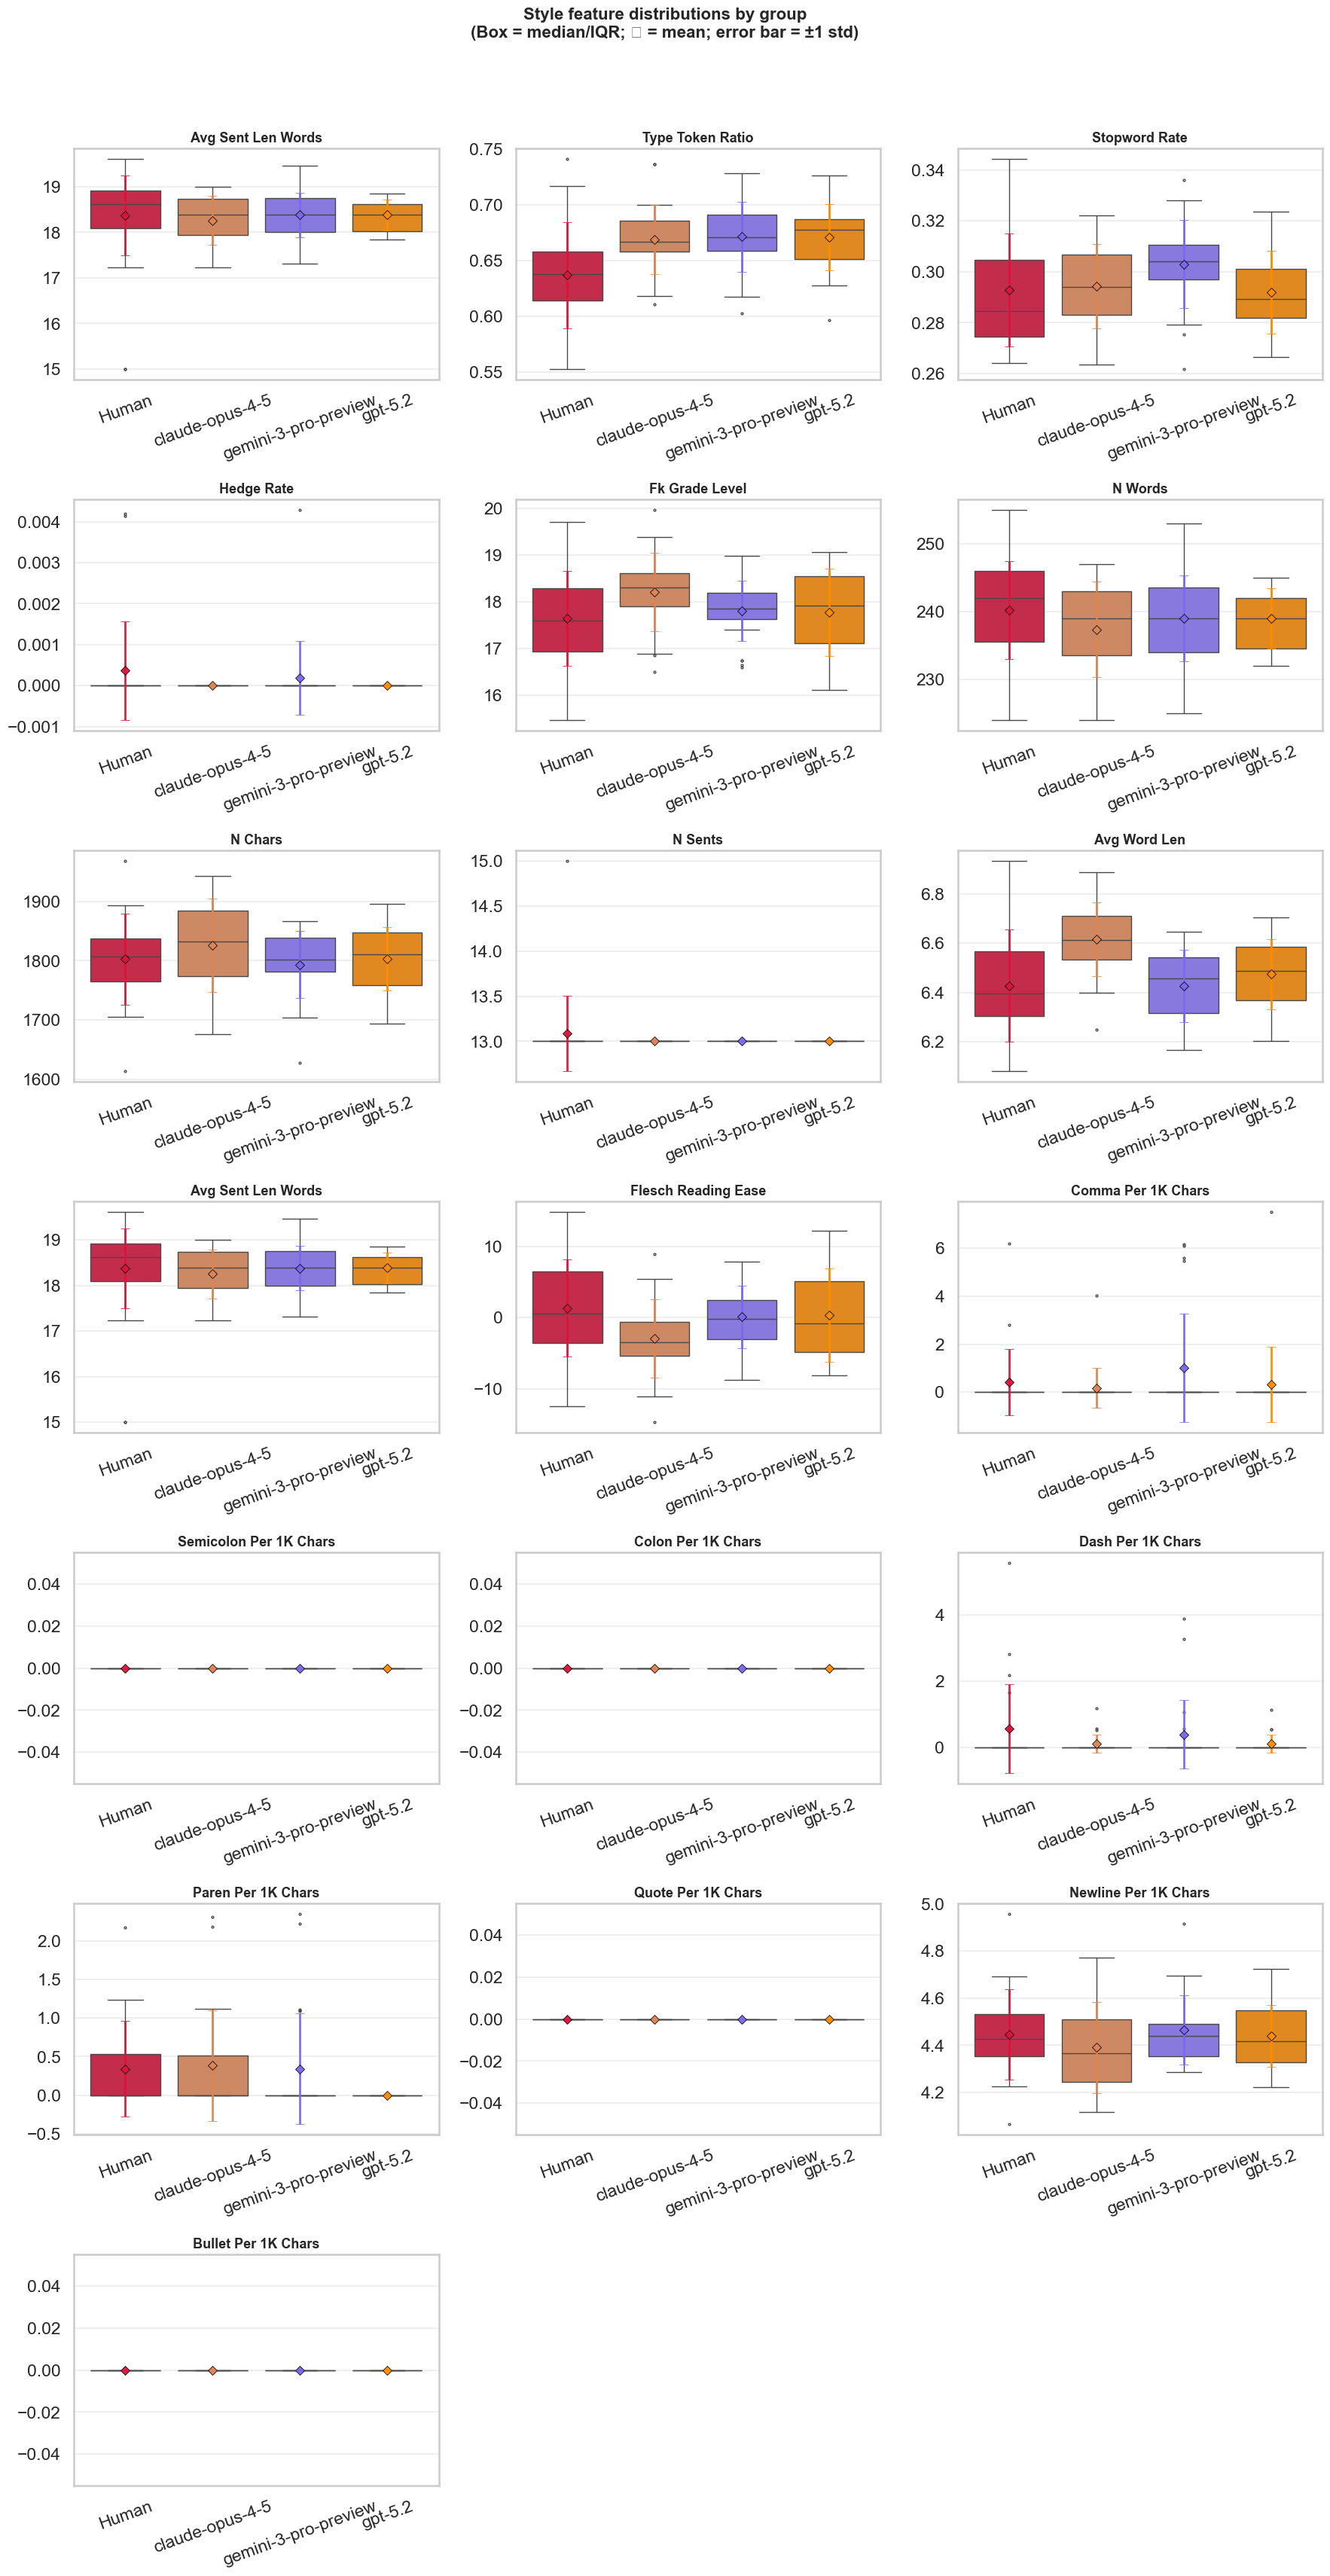

✓ Figure saved to: ../results/figures/rephrased/minimal/style_features_by_model_boxplots.png

Summary (mean / median / std) by group:
                     avg_sent_len_words                type_token_ratio               stopword_rate               hedge_rate               fk_grade_level                 n_words                 n_chars                 n_sents               avg_word_len               avg_sent_len_words                flesch_reading_ease               comma_per_1k_chars               semicolon_per_1k_chars             colon_per_1k_chars             dash_per_1k_chars               paren_per_1k_chars               quote_per_1k_chars             newline_per_1k_chars               bullet_per_1k_chars            
                                   mean  median    std             mean median    std          mean median    std       mean median    std           mean  median    std     mean median    std      mean  median     std    mean median    std         mean median    std   

In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots per feature across Human and each AI model
# Box = median/IQR, whiskers = spread, ◆ = mean, error bar = ±1 std

if 'style_df' not in globals():
    raise RuntimeError("style_df not found. Run the style feature extraction cell first.")
if 'ai_df' not in globals():
    raise RuntimeError("ai_df not found. Run the AI proposal loading cell first.")

# Reconstruct per-model labels aligned to style_df construction order: Human rows first, then AI rows
n_h = int((style_df['group'] == 'Human').sum()) if 'group' in style_df.columns else 0
if n_h == 0:
    n_h = len(human_df)

ai_model_labels = ai_df['model'].tolist()
expected_ai = len(style_df) - n_h
if len(ai_model_labels) != expected_ai:
    raise ValueError(
        f"Alignment error: style_df has {len(style_df)} rows with n_h={n_h}, expected {expected_ai} AI rows, "
        f"but ai_df['model'] has {len(ai_model_labels)} labels."
    )

style_plot = style_df.copy()
style_plot['group_model'] = (['Human'] * n_h) + ai_model_labels

# Compact, interpretable features for quick comparison
features_to_plot = [
    'avg_sent_len_words',
    'type_token_ratio',
    'stopword_rate',
    'hedge_rate',
    'fk_grade_level',
    'header_lines', 'n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words', 'flesch_reading_ease', 'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars', 'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars', 'newline_per_1k_chars', 'bullet_per_1k_chars'
]
# features_to_plot = [f for f in features_to_plot if f in style_plot.columns]
features_to_plot = [f for f in features_to_plot if f in style_plot.columns]
# Prepare long DF
long_df = style_plot[['group_model'] + features_to_plot].replace([np.inf, -np.inf], np.nan)
for f in features_to_plot:
    long_df[f] = long_df[f].fillna(long_df[f].median())
long_df = long_df.melt(id_vars='group_model', var_name='feature', value_name='value')

# Group order (Human first, then models)
if 'ai_models' in globals():
    group_order = ['Human'] + [m for m in ai_models if m in set(style_plot['group_model'])]
else:
    group_order = ['Human'] + sorted([m for m in style_plot['group_model'].unique() if m != 'Human'])

# Plot subplots
n_feat = len(features_to_plot)
ncols = 3
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

# Use consistent group colors if defined earlier in the notebook
if 'colors' in globals() and isinstance(colors, dict):
    colors_local = dict(colors)
else:
    colors_local = {}

# Ensure every group has a color (fallback for any missing keys)
for idx, g in enumerate(group_order):
    colors_local.setdefault(g, f"C{idx % 10}")

palette_dict = {g: colors_local[g] for g in group_order}

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    df_f = long_df[long_df['feature'] == feat]

    # Boxes colored by group
    sns.boxplot(
        data=df_f, x='group_model', y='value', order=group_order,
        ax=ax, palette=palette_dict, fliersize=2
    )

    # Overlay mean ± std as colored diamonds (matches group color)
    stats = df_f.groupby('group_model')['value'].agg(['mean', 'std']).reindex(group_order)
    for xpos, g in enumerate(group_order):
        if g not in stats.index or pd.isna(stats.loc[g, 'mean']):
            continue
        m = float(stats.loc[g, 'mean'])
        s = float(stats.loc[g, 'std']) if not pd.isna(stats.loc[g, 'std']) else 0.0
        ax.errorbar(
            xpos, m, yerr=s,
            fmt='D',
            color=colors_local[g], ecolor=colors_local[g],
            elinewidth=2, capsize=4,
            markersize=6,
            markeredgecolor='black', markeredgewidth=0.6,
            alpha=0.95,
            zorder=10
        )

    ax.set_title(feat.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Style feature distributions by group\n(Box = median/IQR; ◆ = mean; error bar = ±1 std)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

out_path = FIGURES_DIR / 'style_features_by_model_boxplots.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")

# Print a compact table of mean/median/std
summary = style_plot.groupby('group_model')[features_to_plot].agg(['mean', 'median', 'std']).round(3)
print("\nSummary (mean / median / std) by group:")
print(summary.to_string())

### Analysis 2.3.5: Style-only baseline (can style predict source?)

In [72]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

print("="*85)
print("STYLE-ONLY BASELINE: HUMAN VS AI")
print("="*85)

feature_cols = [c for c in style_df.columns if c not in {'group','is_ai'}]
print(f"features: {feature_cols}")
X = style_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = style_df['is_ai'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear', random_state=42)
)

auc_scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
bal_scores = cross_val_score(clf, X, y, cv=cv, scoring='balanced_accuracy')

print(f"CV AUROC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
print(f"CV balanced accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")

obs_score, perm_scores, p_value = permutation_test_score(
    clf, X, y, cv=cv, scoring='roc_auc', n_permutations=1000, n_jobs=-1, random_state=42
)

print()
print("Permutation test (AUROC, 1,000 label shuffles):")
print(f"  Observed AUROC: {obs_score:.3f}")
print(f"  Null mean AUROC: {perm_scores.mean():.3f} ± {perm_scores.std():.3f}")
print(f"  p-value: {p_value:.4f}")
print("  Note: Imputation now occurs INSIDE each CV fold (no leakage).")

if obs_score >= 0.80:
    print("  → Strong evidence that style alone separates Human vs AI.")
elif obs_score >= 0.60:
    print("  → Moderate evidence that style contributes to separation.")
else:
    print("  → Style-only separation is weak; downstream separation is less likely to be purely stylistic.")


STYLE-ONLY BASELINE: HUMAN VS AI
features: ['n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words', 'type_token_ratio', 'stopword_rate', 'hedge_rate', 'flesch_reading_ease', 'fk_grade_level', 'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars', 'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars', 'newline_per_1k_chars', 'bullet_per_1k_chars']
CV AUROC: 0.684 ± 0.102
CV balanced accuracy: 0.581 ± 0.095

Permutation test (AUROC, 1,000 label shuffles):
  Observed AUROC: 0.684
  Null mean AUROC: 0.506 ± 0.096
  p-value: 0.0230
  Note: Imputation now occurs INSIDE each CV fold (no leakage).
  → Moderate evidence that style contributes to separation.


In [73]:
# ── Most predictive STYLE features (interpretable coefficients) ───────────────
import numpy as np
import pandas as pd

print("="*85)
print("TOP STYLE FEATURES PREDICTING AI VS HUMAN (LogReg coefficients)")
print("="*85)

# Fit the SAME pipeline on all data for interpretation
clf.fit(X, y)

# Pull fitted components
imputer = clf.named_steps['simpleimputer']
scaler  = clf.named_steps['standardscaler']
logreg  = clf.named_steps['logisticregression']

# Feature names from the current cell
feature_names = list(feature_cols)

# Coefs correspond to *scaled* features (comparable magnitudes)
coefs = logreg.coef_.ravel()  # shape: (n_features,)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

k = min(15, len(coef_df))

print(f"\nTop {k} strongest predictors (by |coef|):")
print(coef_df.head(k)[['feature','coef']].to_string(index=False))

# Directional lists
ai_like = coef_df.sort_values('coef', ascending=False).head(k)[['feature','coef']]
human_like = coef_df.sort_values('coef', ascending=True).head(k)[['feature','coef']]

print(f"\nTop {k} features pushing prediction toward AI (positive coef):")
print(ai_like.to_string(index=False))

print(f"\nTop {k} features pushing prediction toward Human (negative coef):")
print(human_like.to_string(index=False))

print("\nNote: coefficients are on standardized features (after imputation + scaling).")
print("      Positive = more AI-like; Negative = more Human-like.")


TOP STYLE FEATURES PREDICTING AI VS HUMAN (LogReg coefficients)

Top 15 strongest predictors (by |coef|):
               feature      coef
      type_token_ratio  0.794931
               n_sents -0.535994
    comma_per_1k_chars  0.415146
         stopword_rate  0.374591
            hedge_rate -0.368857
   flesch_reading_ease -0.296825
        fk_grade_level  0.287558
               n_words -0.230170
     dash_per_1k_chars -0.205762
               n_chars -0.188495
  newline_per_1k_chars  0.114311
          avg_word_len  0.081602
    paren_per_1k_chars  0.070145
    avg_sent_len_words  0.027845
semicolon_per_1k_chars  0.000000

Top 15 features pushing prediction toward AI (positive coef):
               feature      coef
      type_token_ratio  0.794931
    comma_per_1k_chars  0.415146
         stopword_rate  0.374591
        fk_grade_level  0.287558
  newline_per_1k_chars  0.114311
          avg_word_len  0.081602
    paren_per_1k_chars  0.070145
    avg_sent_len_words  0.027845
    qu

#### Visualization: Style-only baseline results (CV + permutation test)

**How to read:** Left panel shows cross-validation fold performance (each dot = one CV fold; box = distribution). Right panel shows the permutation-test *null* distribution of AUROC when Human/AI labels are shuffled; the vertical red line is the observed AUROC—if it sits far in the right tail, style alone separates groups beyond chance (small p-value).

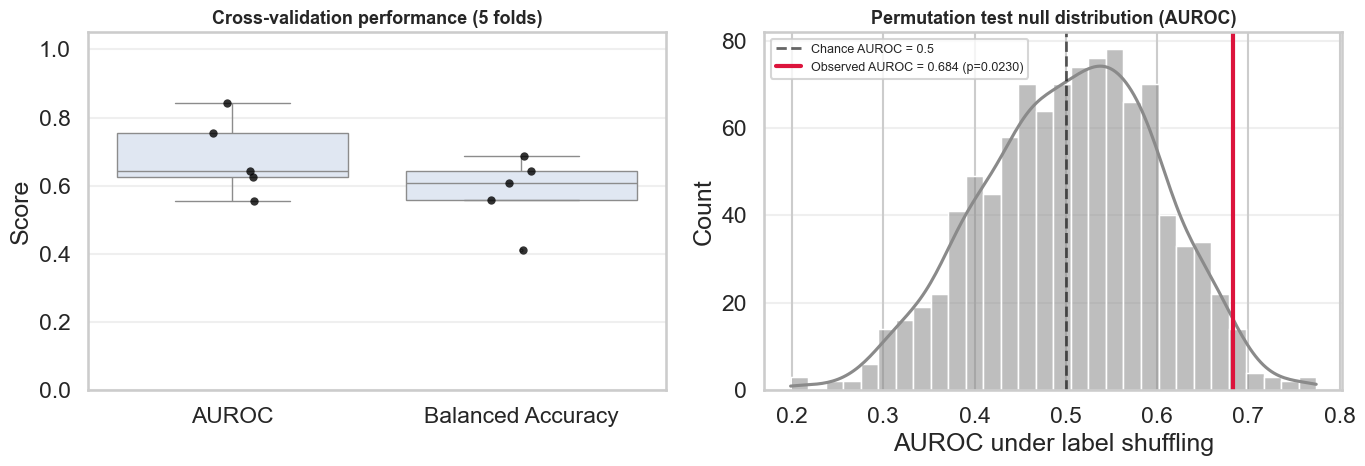

✓ Figure saved to: ../results/figures/rephrased/minimal/style_only_baseline_viz.png

Interpretation:
- Left: tighter boxes/points = stable CV estimates; higher = better separation.
- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).


In [74]:
# Visualization for style-only baseline results
import matplotlib.pyplot as plt

# 1) CV fold distributions (AUROC + balanced accuracy)
cv_plot_df = pd.DataFrame({
    'Fold': np.arange(1, len(auc_scores) + 1),
    'AUROC': auc_scores,
    'Balanced Accuracy': bal_scores,
})
cv_long = cv_plot_df.melt(id_vars='Fold', var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV score distributions
ax = axes[0]
sns.boxplot(data=cv_long, x='Metric', y='Score', ax=ax, color='#DDE6F5', fliersize=2)
sns.stripplot(data=cv_long, x='Metric', y='Score', ax=ax, color='black', size=6, jitter=0.12, alpha=0.8)
ax.set_title('Cross-validation performance (5 folds)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Right: permutation null distribution
ax = axes[1]
sns.histplot(perm_scores, bins=30, kde=True, ax=ax, color='#8A8A8A', alpha=0.55)
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Chance AUROC = 0.5')
ax.axvline(obs_score, color='crimson', linestyle='-', linewidth=3,
           label=f'Observed AUROC = {obs_score:.3f} (p={p_value:.4f})')
ax.set_title('Permutation test null distribution (AUROC)', fontsize=13, fontweight='bold')
ax.set_xlabel('AUROC under label shuffling')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()

out_path = FIGURES_DIR / 'style_only_baseline_viz.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")
print("\nInterpretation:")
print("- Left: tighter boxes/points = stable CV estimates; higher = better separation.")
print("- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).")

### Analysis 2.3.6A: Style-controlled sensitivity via residualization

In [75]:
import pickle
from pathlib import Path
import numpy as np

# ── Load embeddings from cache if not already in scope ───────────────────────
if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    _emb_path = PROPOSAL_EMBEDDINGS_FILE
    if not _emb_path.exists():
        legacy_paths = sorted(_emb_path.parent.glob('proposal_embeddings_[0-9]*.pkl'))
        if not legacy_paths:
            raise FileNotFoundError(f"No embedding cache found at {_emb_path}. Run the embedding cell first.")
        _emb_path = legacy_paths[-1]
    _data = pickle.load(open(_emb_path, 'rb'))
    human_embeddings = _data['human_embeddings']
    ai_embeddings    = _data['ai_embeddings']
    human_metadata   = _data['human_metadata']
    ai_metadata      = _data['ai_metadata']
    print(f"Loaded embeddings from {_emb_path.name}  "
          f"(human={human_embeddings.shape}, ai={ai_embeddings.shape})")

from sklearn.metrics.pairwise import cosine_distances

print("="*85)
print("STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)")
print("="*85)

if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found in workspace variables (expected `human_embeddings` and `ai_embeddings`).")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    group = np.array([0] * len(E_h) + [1] * len(E_a))  # 0=Human, 1=AI

    # Style covariates (compact set)
    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    cov = StandardScaler().fit_transform(cov)

    # Outcomes from embeddings
    centroid_all = E.mean(axis=0, keepdims=True)
    dist_to_all = cosine_distances(E, centroid_all).ravel()

    centroid_h = E_h.mean(axis=0, keepdims=True)
    centroid_a = E_a.mean(axis=0, keepdims=True)
    dist_to_group = np.where(group == 0,
                             cosine_distances(E, centroid_h).ravel(),
                             cosine_distances(E, centroid_a).ravel())

    def _ols_group_coef(y, g, covariates):
        X = np.column_stack([np.ones(len(y)), g.astype(float), covariates])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta[1], beta

    def perm_test_group_coef(y, g, covariates, n_perm=5000, seed=42):
        rng = np.random.default_rng(seed)
        obs_coef, _ = _ols_group_coef(y, g, covariates)
        null = np.zeros(n_perm, dtype=float)
        for i in range(n_perm):
            g_perm = rng.permutation(g)
            null[i], _ = _ols_group_coef(y, g_perm, covariates)
        p_two = (np.mean(np.abs(null) >= abs(obs_coef)) + 1) / (n_perm + 1)
        return obs_coef, null, p_two

    def summarize_outcome(name, y):
        mean_h = float(np.mean(y[group == 0]))
        mean_a = float(np.mean(y[group == 1]))
        print(f"\nOutcome: {name}")
        print(f"  Unadjusted means: Human={mean_h:.4f}, AI={mean_a:.4f}, (AI-Human)={mean_a-mean_h:+.4f}")
        coef, null, p = perm_test_group_coef(y, group, cov, n_perm=5000, seed=42)
        print(f"  Style-adjusted group coef (AI indicator): {coef:+.6f}")
        print(f"  Permutation p (two-sided, 5,000 shuffles): {p:.4f}")

    summarize_outcome('Cosine distance to overall centroid', dist_to_all)
    summarize_outcome('Cosine distance to own-group centroid', dist_to_group)


STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)

Outcome: Cosine distance to overall centroid
  Unadjusted means: Human=0.2872, AI=0.1011, (AI-Human)=-0.1861
  Style-adjusted group coef (AI indicator): -0.174962
  Permutation p (two-sided, 5,000 shuffles): 0.0002

Outcome: Cosine distance to own-group centroid
  Unadjusted means: Human=0.2413, AI=0.0945, (AI-Human)=-0.1468
  Style-adjusted group coef (AI indicator): -0.151039
  Permutation p (two-sided, 5,000 shuffles): 0.0002


### Style-adjusted centroid dispersion (All Groups vs Human)


These tests repeat the same Mann–Whitney U, Cliff’s delta, and permutation test comparisons as the unadjusted centroid-dispersion section, but using **style-adjusted (residualized)** distances-to-own-group-centroid.

Compute each proposal’s distance-to-its-group-centroid (y_raw).
Fit a simple linear model: y_raw ~ (style features).
Subtract the model’s prediction from y_raw to get a residual.
Add back the overall mean (just to keep numbers on a similar scale).
Result: y_adj = “dispersion after removing what style can explain”.
Statistical tests on style-adjusted dispersion:
Same tests, just run on y_adj instead of y_raw.
So your MW / Cliff’s delta / permutation test become: “Are groups still different in dispersion after removing style effects?”

In [76]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("\n" + "="*85)
print("STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)")
print("="*85)

# ---- helpers (define if not already in notebook) ----
if 'cliffs_delta' not in globals():
    def cliffs_delta(x, y):
        """Cliff's delta: P(x>y) - P(x<y)."""
        x = np.asarray(x)
        y = np.asarray(y)
        gt = 0
        lt = 0
        for xi in x:
            gt += np.sum(xi > y)
            lt += np.sum(xi < y)
        return (gt - lt) / (len(x) * len(y))

if 'interpret_cliffs_delta' not in globals():
    def interpret_cliffs_delta(d):
        ad = abs(d)
        if ad < 0.147:
            return 'negligible'
        if ad < 0.33:
            return 'small'
        if ad < 0.474:
            return 'medium'
        return 'large'

def _perm_test_mean_diff(x, y, n_perm=10000, seed=42):
    """Two-sided permutation test on mean difference: mean(x)-mean(y).

    Named uniquely to avoid conflicts with any earlier `permutation_test()` defined elsewhere in the notebook.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    obs = float(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y])
    n_x = len(x)
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        null[i] = float(np.mean(perm[:n_x]) - np.mean(perm[n_x:]))
    p = (np.mean(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    return p, obs, null

# ---- compute y_adj robustly (don’t assume previous cell variables exist) ----
if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
elif 'ai_df' not in globals() or 'model_embeddings_dict' not in globals():
    print("⚠️ ai_df/model_embeddings_dict not found. Run the proposal loading/embedding setup cells first.")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    n_h, n_a = len(E_h), len(E_a)

    # Labels (Human first, then AI per-model)
    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"
    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Group order consistent with earlier analyses
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    # Raw distance-to-own-group-centroid
    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization on y_raw
    _STYLE_CONTROL_COLS = [
        'avg_word_len', 'type_token_ratio', 'avg_sent_len_words',
        'flesch_reading_ease', 'dash_per_1k_chars',
    ]
    cov_cols = [c for c in _STYLE_CONTROL_COLS if c in style_df.columns]
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()

    # Split adjusted distances
    human_adj = y_adj[labels == 'Human']
    ai_adj = y_adj[labels != 'Human']

    model_adj = {m: y_adj[labels == m] for m in group_order if m != 'Human'}

    # ---- tests ----
    adj_comparison_results = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]")
    print("-"*85)

    u_stat, p_mw = mannwhitneyu(ai_adj, human_adj, alternative='two-sided')
    d = cliffs_delta(ai_adj, human_adj)
    d_interp = interpret_cliffs_delta(d)
    p_perm, obs_diff, _ = _perm_test_mean_diff(ai_adj, human_adj, n_perm=10000, seed=42)

    print("\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat:,.0f}, p-value: {p_mw:.4e}")
    print("\nCliff's Delta:")
    print(f"  δ = {d:.4f} ({d_interp} effect)")
    if d > 0:
        print("  → All AI proposals are MORE dispersed from center (after style adjustment)")
    else:
        print("  → Human proposals are MORE dispersed from center (after style adjustment)")
    print("\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference (mean AI - mean Human): {obs_diff:.4f}, p-value: {p_perm:.4f}")

    adj_comparison_results.append({
        'group': 'All AI',
        'u_stat': u_stat,
        'p_value_mw': p_mw,
        'delta': d,
        'delta_interp': d_interp,
        'p_value_perm': p_perm
    })

    for model in group_order:
        if model == 'Human':
            continue
        vals = model_adj.get(model)
        if vals is None or len(vals) == 0:
            continue

        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human [STYLE-ADJUSTED]")
        print("-"*85)

        u_stat_m, p_mw_m = mannwhitneyu(vals, human_adj, alternative='two-sided')
        d_m = cliffs_delta(vals, human_adj)
        d_interp_m = interpret_cliffs_delta(d_m)
        p_perm_m, obs_diff_m, _ = _perm_test_mean_diff(vals, human_adj, n_perm=10000, seed=42)

        print("\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_m:,.0f}, p-value: {p_mw_m:.4e}")
        print("\nCliff's Delta:")
        print(f"  δ = {d_m:.4f} ({d_interp_m} effect)")
        if d_m > 0:
            print(f"  → {model} proposals are MORE dispersed from center (after style adjustment)")
        else:
            print("  → Human proposals are MORE dispersed from center (after style adjustment)")
        print("\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference (mean {model} - mean Human): {obs_diff_m:.4f}, p-value: {p_perm_m:.4f}")

        adj_comparison_results.append({
            'group': model,
            'u_stat': u_stat_m,
            'p_value_mw': p_mw_m,
            'delta': d_m,
            'delta_interp': d_interp_m,
            'p_value_perm': p_perm_m
        })

    # Summary table
    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - Style-adjusted Centroid Dispersion")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for r in adj_comparison_results:
        print(f"{r['group']:<30} {r['delta']:<12.4f} {r['delta_interp']:<20} {r['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed (style-adjusted)")
    print("="*85)



STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 187, p-value: 4.6478e-08

Cliff's Delta:
  δ = -0.7643 (large effect)
  → Human proposals are MORE dispersed from center (after style adjustment)

Permutation Test (10,000 permutations):
  Observed difference (mean AI - mean Human): -0.1284, p-value: 0.0001

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 0, p-value: 6.6369e-09

Cliff's Delta:
  δ = -1.0000 (large effect)
  → Human proposals are MORE dispersed from center (after style adj

CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)


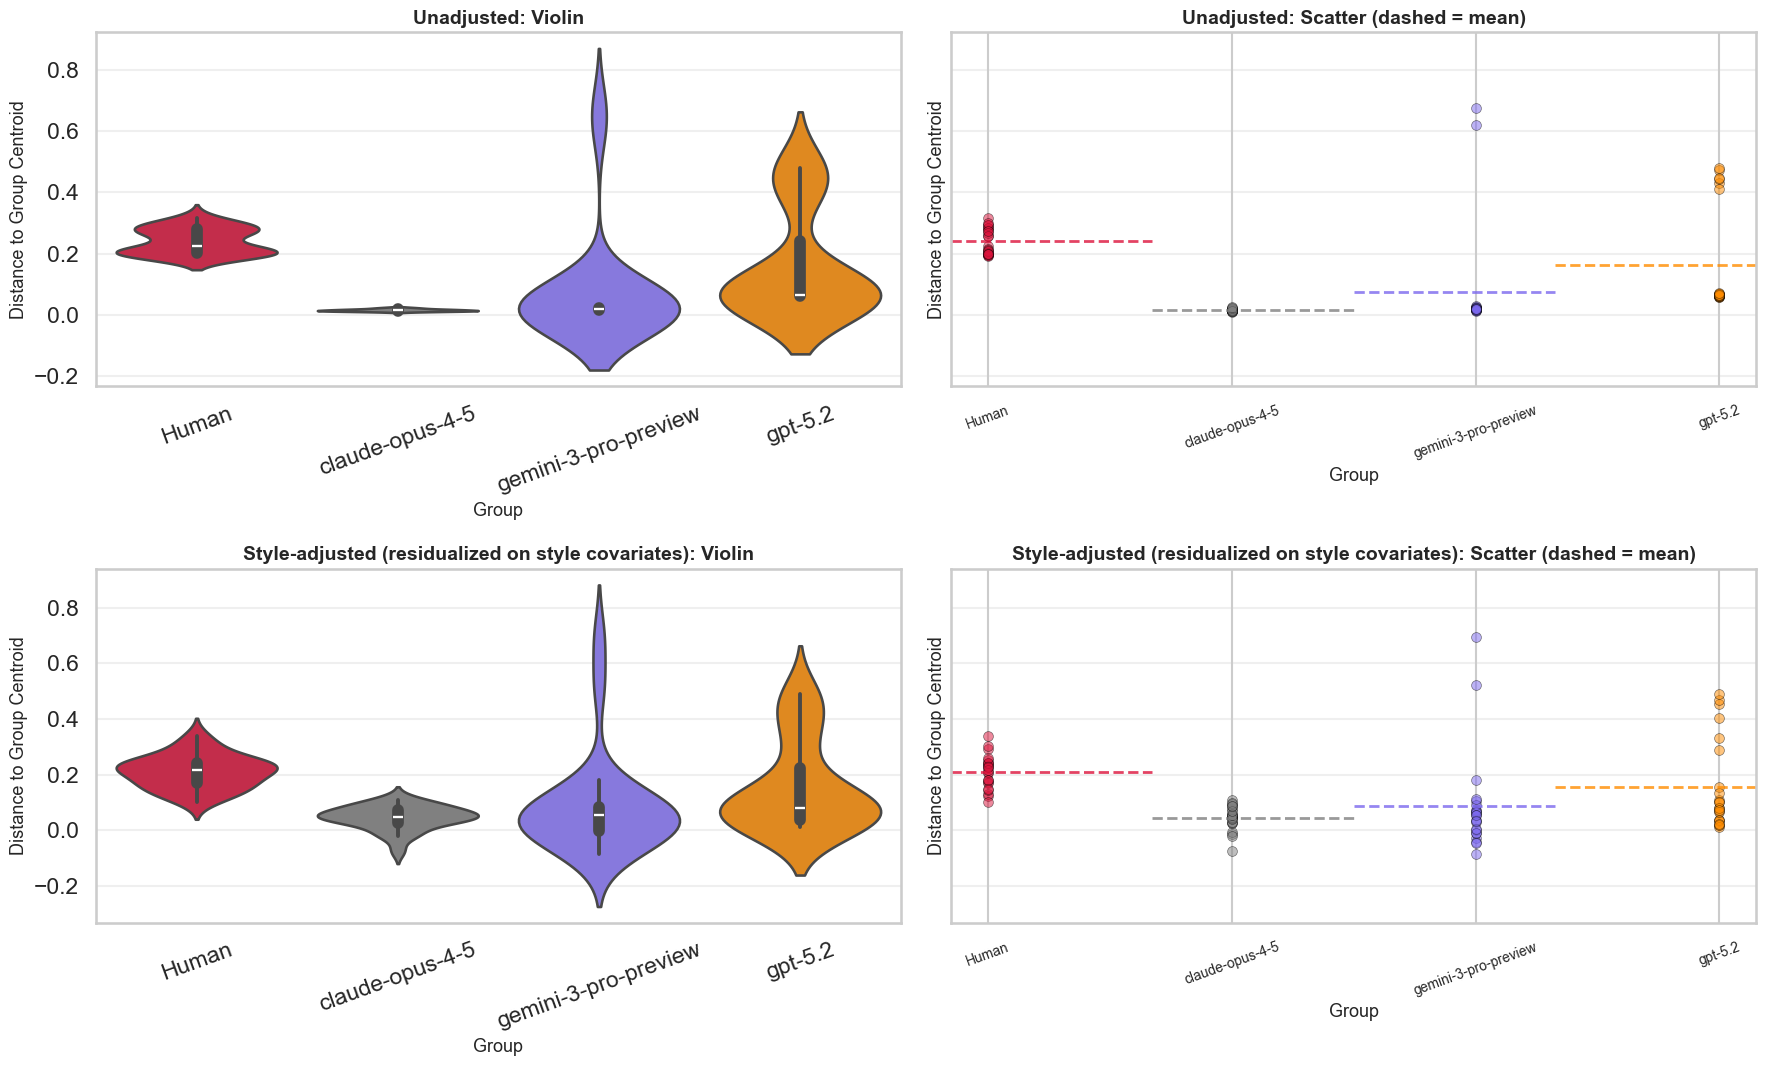

✓ Figure saved to: ../results/figures/rephrased/minimal/centroid_dispersion_style_adjusted.png

Note: 'Style-adjusted' removes linear effects of selected style covariates (not group).


In [77]:
# ----------------------------
# Visualization: centroid dispersion before vs after style residualization
# ----------------------------

from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

print("="*85)
print("CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # Labels (Human first, then AI) — match the style_df construction order
    n_h = len(human_embeddings)
    n_a = len(ai_embeddings)

    # Prefer the notebook's model list if available; otherwise derive from ai_df
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())

    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"

    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Embeddings matrix
    E = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    # Compute distance-to-own-group-centroid for each proposal (Human + each AI model)
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization (remove linear effect of style covariates; keep scale comparable)
    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()  # residuals shifted back to original mean

    # Colors: reuse if present, else define a fallback
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = colors
    else:
        colors_local = {'Human': '#DC143C'}
        for i, m in enumerate(group_order[1:]):
            colors_local[m] = f"C{(i+1)%10}"

    def _plot_row(ax_violin, ax_scatter, y, row_title):
        # Build long DF
        plot_df = pd.DataFrame({'Group': labels, 'Distance to Centroid': y})

        palette_list = [colors_local.get(g, 'gray') for g in group_order]

        sns.violinplot(
            data=plot_df, x='Group', y='Distance to Centroid',
            order=group_order, palette=palette_list, ax=ax_violin
        )
        ax_violin.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_violin.set_xlabel('Group', fontsize=13)
        ax_violin.set_title(f'{row_title}: Violin', fontsize=14, fontweight='bold')
        ax_violin.tick_params(axis='x', rotation=20)
        ax_violin.grid(alpha=0.3, axis='y')

        # Scatter with per-group mean lines
        for xpos, g in enumerate(group_order):
            vals = plot_df.loc[plot_df['Group'] == g, 'Distance to Centroid'].values
            if len(vals) == 0:
                continue
            ax_scatter.scatter(
                [xpos] * len(vals), vals,
                alpha=0.5, color=colors_local.get(g, 'gray'),
                s=50, edgecolors='black', linewidth=0.5
            )
            ax_scatter.axhline(
                np.mean(vals),
                xmin=xpos/len(group_order), xmax=(xpos+1)/len(group_order),
                color=colors_local.get(g, 'gray'), linestyle='--', linewidth=2, alpha=0.8
            )

        ax_scatter.set_xticks(range(len(group_order)))
        ax_scatter.set_xticklabels(group_order, rotation=20, fontsize=10)
        ax_scatter.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_scatter.set_xlabel('Group', fontsize=13)
        ax_scatter.set_title(f'{row_title}: Scatter (dashed = mean)', fontsize=14, fontweight='bold')
        ax_scatter.grid(alpha=0.3, axis='y')

    fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharey='row')
    _plot_row(axes[0, 0], axes[0, 1], y_raw, 'Unadjusted')
    _plot_row(axes[1, 0], axes[1, 1], y_adj, 'Style-adjusted (residualized on style covariates)')

    plt.tight_layout()
    out_path = FIGURES_DIR / 'centroid_dispersion_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Figure saved to: {out_path}")
    print("\nNote: 'Style-adjusted' removes linear effects of selected style covariates (not group).")


### Style-adjust nearest-neighbor (NN) distances by residualizing embeddings


This removes the *linear* contribution of selected style covariates from the embedding vectors (dimension-wise OLS), then recomputes cosine NN distances on the residual embeddings (renormalized).

STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)

COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.2359     0.1848     0.0833     0.7390    

claude-opus-4-5                     23       0.2679     0.2400     0.1130     0.7115    
gemini-3-pro-preview                23       0.3104     0.2226     0.0873     0.7822    
gpt-5.2                             23       0.2640     0.2359     0.0833     0.7728    

All AI (combined)                   69       0.2808     0.2359     0.0833     0.7822    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together
   - Distances are computed AFTER removing linear embedding variation explained by style covariates

O

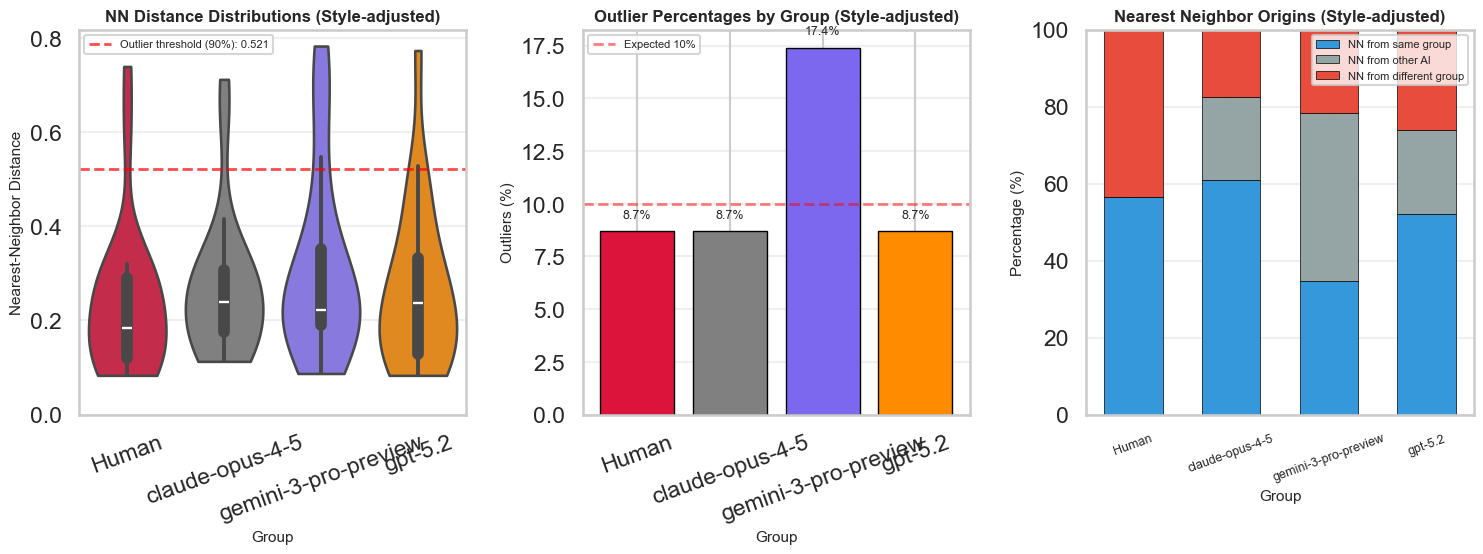


✓ Figure saved to: ../results/figures/rephrased/minimal/nearest_neighbor_by_model_style_adjusted.png

Note: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.


In [78]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("="*85)
print("STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # ----------------------------
    # 0) Build per-row labels that match embedding order
    # ----------------------------
    n_human = len(human_embeddings)
    n_ai = len(ai_embeddings)

    if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
        ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
    elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
        print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
        ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
    else:
        raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

    labels = np.array((['Human'] * n_human) + ai_model_labels)

    # Stable group order
    if 'ai_models' in globals():
        ai_models_local = [m for m in list(ai_models) if m in set(ai_model_labels)]
    else:
        ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

    group_order = ['Human'] + ai_models_local

    # ----------------------------
    # 1) Build embedding matrix (Human first, then AI) and residualize on style
    # ----------------------------
    all_embeddings = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    # Control only for features that significantly separate Human from AI (from
    # the LogReg coefficients in cell 102 / PART IV Mann-Whitney analysis).
    # Using all 17 features risks absorbing semantic variance that correlates
    # with length (n_words, n_chars, n_sents are semantic proxies).
    _STYLE_CONTROL_COLS = [
        'avg_word_len',          # word complexity (AI uses shorter words)
        'type_token_ratio',      # vocabulary diversity (human higher)
        'avg_sent_len_words',    # sentence length (AI runs longer)
        'flesch_reading_ease',   # readability composite (correlated with above)
        'dash_per_1k_chars',     # hyphen usage (human uses more)
    ]
    cov_cols = [c for c in _STYLE_CONTROL_COLS if c in style_df.columns]
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(X_cov)), X_cov])

    B, *_ = np.linalg.lstsq(X, all_embeddings, rcond=None)
    all_embeddings_resid = all_embeddings - (X @ B)
    all_embeddings_resid = all_embeddings_resid / (np.linalg.norm(all_embeddings_resid, axis=1, keepdims=True) + 1e-12)

    # ----------------------------
    # 2) Compute full distance matrix + NN distances (STYLE-ADJUSTED)
    # ----------------------------
    print("\n" + "="*85)
    print("COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
    print("="*85)

    all_distances_adj = cosine_distances(all_embeddings_resid)
    np.fill_diagonal(all_distances_adj, np.inf)
    nn_distances_adj = all_distances_adj.min(axis=1)

    # Group-wise NN distances
    human_nn_dists_adj = nn_distances_adj[labels == 'Human']
    ai_nn_dists_adj = nn_distances_adj[labels != 'Human']

    model_nn_dists_adj = {g: nn_distances_adj[labels == g] for g in ai_models_local}

    # Print statistics table
    print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
    print("-"*85)
    print(f"{'Human':<35} {len(human_nn_dists_adj):<8} {human_nn_dists_adj.mean():<10.4f} {np.median(human_nn_dists_adj):<10.4f} {human_nn_dists_adj.min():<10.4f} {human_nn_dists_adj.max():<10.4f}")
    print()
    for model in ai_models_local:
        dists = model_nn_dists_adj[model]
        print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")
    print()
    print(f"{'All AI (combined)':<35} {len(ai_nn_dists_adj):<8} {ai_nn_dists_adj.mean():<10.4f} {np.median(ai_nn_dists_adj):<10.4f} {ai_nn_dists_adj.min():<10.4f} {ai_nn_dists_adj.max():<10.4f}")

    print("="*85)
    print("\n💡 INTERPRETATION:")
    print("   - Higher mean NN distance = more isolated proposals (outliers)")
    print("   - Lower mean NN distance = proposals cluster together")
    print("   - Distances are computed AFTER removing linear embedding variation explained by style covariates")
    print("="*85)

    # ----------------------------
    # 3) Outlier detection (top 10% NN distances) - STYLE-ADJUSTED
    # ----------------------------
    threshold_adj = np.percentile(nn_distances_adj, 90)
    outliers_adj = nn_distances_adj > threshold_adj

    human_outliers_adj = int(outliers_adj[labels == 'Human'].sum())
    ai_outliers_adj = int(outliers_adj[labels != 'Human'].sum())
    model_outliers_adj = {g: int(outliers_adj[labels == g].sum()) for g in ai_models_local}

    print("\n" + "="*85)
    print("OUTLIER DETECTION (Top 10% NN distance) — STYLE-ADJUSTED")
    print("="*85)
    print(f"Threshold distance: {threshold_adj:.4f}")
    print()
    print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
    print("-"*85)
    print(f"{'Human':<35} {human_outliers_adj:<15} {n_human:<10} {human_outliers_adj/n_human*100:<15.1f}%")
    print()
    for model in ai_models_local:
        n_model = int((labels == model).sum())
        print(f"{model:<35} {model_outliers_adj[model]:<15} {n_model:<10} {model_outliers_adj[model]/n_model*100:<15.1f}%")
    print()
    print(f"{'All AI (combined)':<35} {ai_outliers_adj:<15} {n_ai:<10} {ai_outliers_adj/n_ai*100:<15.1f}%")
    print("="*85)

    # ----------------------------
    # 4) Nearest-neighbor origin analysis — STYLE-ADJUSTED
    # ----------------------------
    nn_indices_adj = all_distances_adj.argmin(axis=1)
    nn_labels_adj = labels[nn_indices_adj]

    human_nn_same_group_adj = int((nn_labels_adj[labels == 'Human'] == 'Human').sum())
    human_nn_diff_group_adj = int(n_human - human_nn_same_group_adj)

    ai_nn_same_group_adj = int((nn_labels_adj[labels != 'Human'] != 'Human').sum())
    ai_nn_diff_group_adj = int(n_ai - ai_nn_same_group_adj)

    model_nn_analysis_adj = {}
    for model in ai_models_local:
        mask = labels == model
        total = int(mask.sum())
        nn_from_human = int((nn_labels_adj[mask] == 'Human').sum())
        nn_from_same_model = int((nn_labels_adj[mask] == model).sum())
        nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)
        model_nn_analysis_adj[model] = {
            'from_human': nn_from_human,
            'from_same_model': nn_from_same_model,
            'from_other_ai': nn_from_other_ai,
            'total': total
        }

    print("\n" + "="*85)
    print("NEAREST NEIGHBOR GROUP ANALYSIS — STYLE-ADJUSTED")
    print("="*85)

    print(f"\n{'Human proposals:':<50}")
    print(f"  NN from same group (human): {human_nn_same_group_adj} ({human_nn_same_group_adj/n_human*100:.1f}%)")
    print(f"  NN from different group (AI): {human_nn_diff_group_adj} ({human_nn_diff_group_adj/n_human*100:.1f}%)")

    print(f"\n{'All AI proposals (combined):':<50}")
    print(f"  NN from same group (AI): {ai_nn_same_group_adj} ({ai_nn_same_group_adj/n_ai*100:.1f}%)")
    print(f"  NN from different group (human): {ai_nn_diff_group_adj} ({ai_nn_diff_group_adj/n_ai*100:.1f}%)")

    print("\n" + "-"*85)
    print("Per-Model NN Group Breakdown:")
    print("-"*85)

    for model in ai_models_local:
        data = model_nn_analysis_adj[model]
        print(f"\n{model}:")
        print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
        print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
        print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

    print("\n" + "="*85)
    print("\n💡 INTERPRETATION:")
    print("   - High 'NN from same model' = model produces similar proposals")
    print("   - High 'NN from Human' = model proposals resemble human work")
    print("   - All computed in style-adjusted residual embedding space")
    print("="*85)

    # ----------------------------
    # 5) Statistical tests vs Human (same tests) — STYLE-ADJUSTED
    # ----------------------------
    print("\n" + "="*85)
    print("STATISTICAL TESTS: NN Distances (All Groups vs Human) — STYLE-ADJUSTED")
    print("="*85)

    nn_comparison_results_adj = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human")
    print("-"*85)

    u_stat_nn, p_value_nn = mannwhitneyu(ai_nn_dists_adj, human_nn_dists_adj, alternative='two-sided')
    delta_nn = cliffs_delta(ai_nn_dists_adj, human_nn_dists_adj)
    delta_nn_interp = interpret_cliffs_delta(delta_nn)
    p_value_perm_nn, obs_diff_nn, _ = permutation_test(ai_nn_dists_adj, human_nn_dists_adj)

    print(f"\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat_nn:,.0f}, p-value: {p_value_nn:.4e}")
    print(f"\nCliff's Delta:")
    print(f"  δ = {delta_nn:.4f} ({delta_nn_interp} effect)")
    if delta_nn > 0:
        print(f"  → All AI proposals have MORE unique/outlier ideas (style-adjusted)")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
    print(f"\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference: {obs_diff_nn:.4f}, p-value: {p_value_perm_nn:.4f}")

    nn_comparison_results_adj.append({
        'group': 'All AI',
        'u_stat': u_stat_nn,
        'p_value_mw': p_value_nn,
        'delta': delta_nn,
        'delta_interp': delta_nn_interp,
        'p_value_perm': p_value_perm_nn
    })

    for model in ai_models_local:
        if model in model_nn_dists_adj:
            print("\n" + "-"*85)
            print(f"Comparison: {model} vs Human")
            print("-"*85)

            u_stat_model, p_value_mw_model = mannwhitneyu(model_nn_dists_adj[model], human_nn_dists_adj, alternative='two-sided')
            delta_model = cliffs_delta(model_nn_dists_adj[model], human_nn_dists_adj)
            delta_interp_model = interpret_cliffs_delta(delta_model)
            p_value_perm_model, obs_diff_model, _ = permutation_test(model_nn_dists_adj[model], human_nn_dists_adj)

            print(f"\nMann-Whitney U Test:")
            print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
            print(f"\nCliff's Delta:")
            print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
            if delta_model > 0:
                print(f"  → {model} proposals have MORE unique/outlier ideas (style-adjusted)")
            else:
                print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
            print(f"\nPermutation Test (10,000 permutations):")
            print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")

            nn_comparison_results_adj.append({
                'group': model,
                'u_stat': u_stat_model,
                'p_value_mw': p_value_mw_model,
                'delta': delta_model,
                'delta_interp': delta_interp_model,
                'p_value_perm': p_value_perm_model
            })

    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - NN Distances (Style-adjusted)")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for result in nn_comparison_results_adj:
        print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone (style-adjusted)")
    print("="*85)

    # ----------------------------
    # 6) Visualization (same 3-panel layout) — STYLE-ADJUSTED
    # ----------------------------
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

    # Colors (reuse global mapping)
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = dict(colors)
    else:
        colors_local = {'Human': 'steelblue'}

    # 1. NN distance distributions by group
    ax1 = fig.add_subplot(gs[0, 0])
    nn_data = []
    for dist, label in [(human_nn_dists_adj, 'Human')] + [(model_nn_dists_adj[m], m) for m in ai_models_local if m in model_nn_dists_adj]:
        for val in dist:
            nn_data.append({'NN Distance': val, 'Group': label})

    nn_df = pd.DataFrame(nn_data)
    group_order_viz = ['Human'] + [m for m in ai_models_local if m in model_nn_dists_adj]
    palette_list = [colors_local.get(g, 'gray') for g in group_order_viz]

    sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list,
                   order=group_order_viz, cut=0)  # cut=0 clips KDE at data min/max (prevents negative bleed)
    ax1.axhline(threshold_adj, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold_adj:.3f}')
    ax1.set_ylim(bottom=0)  # hard floor at 0 as a second safety net
    ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
    ax1.set_xlabel('Group', fontsize=11)
    ax1.set_title('NN Distance Distributions (Style-adjusted)', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', rotation=20)
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3, axis='y')

    # 2. Outlier counts by group
    ax2 = fig.add_subplot(gs[0, 1])
    outlier_data = []
    outlier_data.append({'Group': 'Human', 'Outliers': human_outliers_adj, 'Total': n_human, 'Percentage': human_outliers_adj/n_human*100})
    for model in ai_models_local:
        if model in model_outliers_adj:
            n_model = len(model_embeddings_dict.get(model, []))
            outlier_data.append({'Group': model, 'Outliers': model_outliers_adj[model], 'Total': n_model, 'Percentage': model_outliers_adj[model]/n_model*100})

    outlier_df = pd.DataFrame(outlier_data)
    bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors_local.get(g, 'gray') for g in outlier_df['Group']], edgecolor='black', linewidth=1)
    ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
    ax2.set_ylabel('Outliers (%)', fontsize=11)
    ax2.set_xlabel('Group', fontsize=11)
    ax2.set_title('Outlier Percentages by Group (Style-adjusted)', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=20)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3, axis='y')

    for bar, pct in zip(bars, outlier_df['Percentage']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    # 3. NN origins (stacked bar)
    ax3 = fig.add_subplot(gs[0, 2])

    groups = ['Human'] + [m for m in ai_models_local if m in model_nn_analysis_adj]
    nn_from_human_pcts = [human_nn_diff_group_adj/n_human*100]
    nn_from_same_pcts = [human_nn_same_group_adj/n_human*100]
    nn_from_other_ai_pcts = [0]

    for model in [m for m in ai_models_local if m in model_nn_analysis_adj]:
        data = model_nn_analysis_adj[model]
        nn_from_human_pcts.append(data['from_human']/data['total']*100)
        nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
        nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

    x_pos = np.arange(len(groups))
    width = 0.6

    p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
    p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
    bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
    p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

    ax3.set_ylabel('Percentage (%)', fontsize=11)
    ax3.set_xlabel('Group', fontsize=11)
    ax3.set_title('Nearest Neighbor Origins (Style-adjusted)', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(groups, rotation=20, fontsize=9)
    ax3.legend(fontsize=8, loc='upper right')
    ax3.grid(alpha=0.3, axis='y')
    ax3.set_ylim([0, 100])

    plt.tight_layout()
    out_fig = FIGURES_DIR / 'nearest_neighbor_by_model_style_adjusted.png'
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Figure saved to: {out_fig}")
    print("\nNote: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.")

### Visualization: Style-adjusted NN analysis in 2D (UMAP on residual embeddings)

This mirrors the unadjusted UMAP plot, but uses **style-residualized embeddings** (the same ones used to compute style-adjusted NN distances/outliers). It also prints a small diagnostic showing that style covariates have much weaker linear association with the embedding coordinates after residualization.

STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS

Style-adjustment diagnostic (lower is better):
  Mean |corr(style covariate, PC score)| (raw embeddings):  0.1047
  Mean |corr(style covariate, PC score)| (residual embeddings): 0.0636

Reducing residual embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


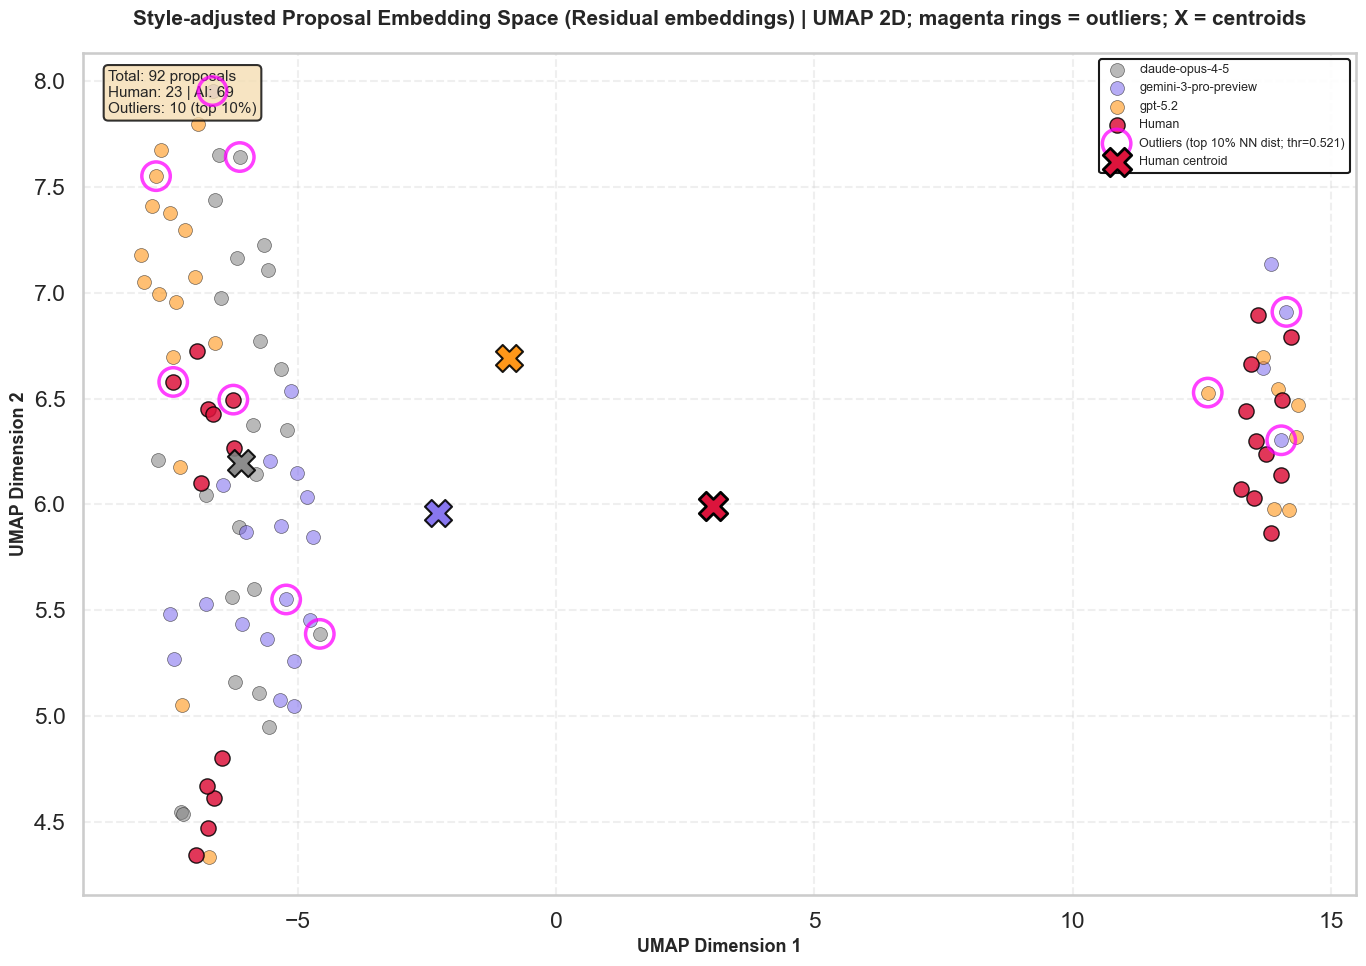


✓ Figure saved to: ../results/figures/rephrased/minimal/embedding_space_2d_style_adjusted.png
💡 INTERPRETATION:
   - Clusters = similar proposals in style-adjusted residual space
   - Magenta rings = outliers by NN distance in residual space
   - X markers = group centroids in residual space


In [79]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("="*85)
print("STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS")
print("="*85)

required_vars = ['all_embeddings_resid', 'outliers_adj', 'threshold_adj', 'n_human', 'n_ai', 'ai_models_local', 'model_embeddings_dict', 'labels']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print(f"⚠️ Missing variables from prior style-adjusted NN cell: {missing}")
    print("Run the 'STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS' cell first.")
else:
    try:
        _STYLE_CONTROL_COLS = [
            'avg_word_len', 'type_token_ratio', 'avg_sent_len_words',
            'flesch_reading_ease', 'dash_per_1k_chars',
        ]
        cov_cols = [c for c in _STYLE_CONTROL_COLS if c in style_df.columns]
        X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
        X_cov = StandardScaler().fit_transform(X_cov)

        E_raw = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])
        E_raw = E_raw / (np.linalg.norm(E_raw, axis=1, keepdims=True) + 1e-12)
        E_adj = np.asarray(all_embeddings_resid)

        pca = PCA(n_components=10, random_state=42)
        Z_raw = pca.fit_transform(E_raw)
        Z_adj = pca.fit_transform(E_adj)

        def _mean_abs_corr(Z, X):
            corrs = []
            for i in range(Z.shape[1]):
                zi = Z[:, i]
                for j in range(X.shape[1]):
                    xj = X[:, j]
                    c = np.corrcoef(zi, xj)[0, 1]
                    if np.isfinite(c):
                        corrs.append(abs(c))
            return float(np.mean(corrs)) if corrs else np.nan

        raw_corr = _mean_abs_corr(Z_raw, X_cov)
        adj_corr = _mean_abs_corr(Z_adj, X_cov)

        print()
        print("Style-adjustment diagnostic (lower is better):")
        print(f"  Mean |corr(style covariate, PC score)| (raw embeddings):  {raw_corr:.4f}")
        print(f"  Mean |corr(style covariate, PC score)| (residual embeddings): {adj_corr:.4f}")
    except Exception as e:
        print()
        print(f"⚠️ Diagnostic skipped due to error: {e}")

    print()
    print("Reducing residual embeddings to 2D using UMAP...")
    reducer_adj = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
    embeddings_2d_adj = reducer_adj.fit_transform(all_embeddings_resid)

    human_2d_adj = embeddings_2d_adj[:n_human]
    ai_2d_adj = embeddings_2d_adj[n_human:]
    model_2d_adj = {model: embeddings_2d_adj[labels == model] for model in ai_models_local}

    print(f"✓ UMAP completed: {len(embeddings_2d_adj)} proposals reduced to 2D")

    outlier_indices_adj = np.where(outliers_adj)[0]
    outlier_coords_adj = embeddings_2d_adj[outlier_indices_adj]

    colors_local = dict(colors) if 'colors' in globals() and isinstance(colors, dict) else {'Human': '#DC143C'}

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    for model in ai_models_local:
        mask = labels == model
        if mask.any():
            pts = embeddings_2d_adj[mask]
            ax.scatter(pts[:, 0], pts[:, 1], c=colors_local.get(model, '#808080'), label=model, s=100, alpha=0.55, edgecolors='black', linewidth=0.5)

    ax.scatter(human_2d_adj[:, 0], human_2d_adj[:, 1], c=colors_local.get('Human', '#DC143C'), label='Human', s=120, alpha=0.85, edgecolors='black', linewidth=1.0, marker='o', zorder=10)
    ax.scatter(outlier_coords_adj[:, 0], outlier_coords_adj[:, 1], s=420, facecolors='none', edgecolors='magenta', linewidth=2.5, alpha=0.75, label=f'Outliers (top 10% NN dist; thr={threshold_adj:.3f})', zorder=12)

    human_centroid_2d = human_2d_adj.mean(axis=0)
    ax.scatter(human_centroid_2d[0], human_centroid_2d[1], c=colors_local.get('Human', '#DC143C'), s=420, marker='X', edgecolors='black', linewidth=2, alpha=1.0, zorder=15, label='Human centroid')

    for model in ai_models_local:
        if model in model_2d_adj and len(model_2d_adj[model]) > 0:
            c2d = model_2d_adj[model].mean(axis=0)
            ax.scatter(c2d[0], c2d[1], c=colors_local.get(model, '#808080'), s=380, marker='X', edgecolors='black', linewidth=1.5, alpha=0.9, zorder=14)

    ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
    ax.set_title('Style-adjusted Proposal Embedding Space (Residual embeddings) | UMAP 2D; magenta rings = outliers; X = centroids', fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
    ax.grid(True, alpha=0.3, linestyle='--')

    textstr = '\n'.join([
        f'Total: {len(embeddings_2d_adj)} proposals',
        f'Human: {n_human} | AI: {n_ai}',
        f'Outliers: {len(outlier_indices_adj)} (top 10%)'
    ])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)

    plt.tight_layout()
    out_path = FIGURES_DIR / 'embedding_space_2d_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print()
    print(f"✓ Figure saved to: {out_path}")
    print("💡 INTERPRETATION:")
    print("   - Clusters = similar proposals in style-adjusted residual space")
    print("   - Magenta rings = outliers by NN distance in residual space")
    print("   - X markers = group centroids in residual space")
    print("="*85)


#### Outlier proposals (style-adjusted NN)

Print the titles of proposals flagged as **outliers** in the style-adjusted NN analysis (top 10% NN distance), along with whether they are Human or which AI model generated them.

In [80]:
import pandas as pd
import numpy as np

print("\n" + "="*85)
print("STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers_adj', 'threshold_adj', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the style-adjusted NN analysis cell first.")
else:
    outlier_indices = np.where(outliers_adj)[0]
    n_total = int(len(outliers_adj))
    n_ai = int(n_total - n_human)

    # Get style-adjusted NN distances if available; otherwise recompute quickly
    if 'nn_distances_adj' in globals():
        nn_d = np.asarray(nn_distances_adj)
    elif 'all_distances_adj' in globals():
        nn_d = np.min(np.asarray(all_distances_adj), axis=1)
    elif 'all_embeddings_resid' in globals():
        from sklearn.metrics.pairwise import cosine_distances
        D = cosine_distances(np.asarray(all_embeddings_resid))
        np.fill_diagonal(D, np.inf)
        nn_d = D.min(axis=1)
    else:
        nn_d = None

    # Prefer metadata saved alongside embeddings (guaranteed to match embedding order)
    use_metadata = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_metadata:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df-based lookup.")
            use_metadata = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_metadata:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = idx - n_human
            who = 'AI'
            if use_metadata:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', '')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance_style_adj': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance_style_adj', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold_adj:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.5212
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
gemini-3-pro-preview    4
gpt-5.2                 2
Human                   2
claude-opus-4-5         2


,global_index,who,model,nn_distance_style_adj,title
0,51,AI,gemini-3-pro-preview,0.782234,Uncovering the Rules of Nucleolar Assembly and Ribosome Biogenesis Emergence
1,40,AI,gpt-5.2,0.772776,"A Cross-Species Synthesis of Autophagosome Biogenesis: Integrating Proteomics, Lipid Signatures, and Imaging Dynamics"
2,2,Human,Human,0.738968,Deciphering systemic biological networks through AI-driven multi-omic integration
3,83,AI,claude-opus-4-5,0.711531,"The Emergence of Signaling Specificity: Synthesizing Interaction, Localization, and Kinetic Data to Understand Pathway Insulation"
4,48,AI,gemini-3-pro-preview,0.701686,Synthesizing the Emergent Properties of Chromatin Topology and Epigenetic Memory
5,57,AI,gemini-3-pro-preview,0.699480,Emergent Cargo Sorting Dynamics in Extracellular Vesicle Biogenesis
6,72,AI,claude-opus-4-5,0.629669,"Emergent Properties of the Cellular Crowding Landscape: Synthesizing Biophysical, Structural, and Systems Data to Understand Macromolecu..."
7,8,Human,Human,0.598331,Predictive Synthesis Framework for Elucidating Biophysical Cell State from Spatial Transcriptomics and Proteomics
8,56,AI,gemini-3-pro-preview,0.545743,Synthesizing the Emergence of Autophagosomes at ER-Mitochondria Contact Sites
9,42,AI,gpt-5.2,0.527042,"A Community Meta-Analysis of Multivesicular Body and Exosome Biogenesis: Integrating ESCRT Networks, Proteomics, and Imaging"


# Save All Proposals to a Single JSON

Combine original proposal content, rephrased text, and every per-proposal metric computed in this notebook into one JSON file (`all_proposals.json`). Each record contains the original and rephrased text, plus all diversity, novelty, style, and review-score metrics for cross-validation.

In [81]:

import json as _json
import pandas as pd
import numpy as np
from pathlib import Path

def _norm(s): return str(s).strip().lower()

# -- Load metrics tables ----------------------------------------------------
def _load(fname):
    df = pd.read_csv(TABLES_DIR / fname)
    df['_key'] = df['title'].map(_norm)
    return df

def _load_optional(fname):
    p = TABLES_DIR / fname
    if p.exists():
        df = pd.read_csv(p)
        if 'title' in df.columns:
            df['_key'] = df['title'].map(_norm)
        return df
    return None

cent_df  = _load('centroid_distances.csv')
nn_df    = _load('nn_distances.csv')
nov_df   = _load('novelty_scores_from_literature.csv')
style_metrics_df = _load('style_features.csv')
scores_df = _load('review_scores_wide.csv')

# Literature-space outlier table (from Step 7B), if available
# Prefer k=10 (aligned with novelty); fallback to k=5 for backward compatibility\nlit_out_df = _load_optional('literature_space_outliers_mean_knn_k10.csv')\nif lit_out_df is None:\n    lit_out_df = _load_optional('literature_space_outliers_mean_knn_k5.csv')

score_cols = [c for c in scores_df.columns if c not in {'title', 'author', '_key'}]

# Build per-key lookup dicts from each table
def _to_dict(df, cols):
    return {row['_key']: {c: row[c] for c in cols} for _, row in df.iterrows()}

cent_lut  = _to_dict(cent_df,  ['centroid_dist'])
nn_lut    = _to_dict(nn_df,    ['nn_dist', 'is_outlier', 'threshold'])
nov_lut   = _to_dict(nov_df,   ['raw_novelty', 'novelty_z', 'novelty_ratio',
                                  'is_most_novel_raw', 'is_most_novel_z', 'is_most_novel_ratio'])
style_feat_cols = [c for c in style_metrics_df.columns
                   if c not in {'title', 'group', 'is_ai', '_key'}]
style_lut = _to_dict(style_metrics_df, style_feat_cols)
scores_lut = _to_dict(scores_df, score_cols)  # key = current title (no mapping)

# Literature-space outlier lookup (guarantee binary flag via fallback default)
lit_out_lut = {}
_lit_dist_col = None
if lit_out_df is not None and len(lit_out_df):
    for cand in [c for c in lit_out_df.columns if c.startswith('mean_lit_nn_dist_k')]:
        _lit_dist_col = cand
        break
    if '_key' not in lit_out_df.columns and 'title' in lit_out_df.columns:
        lit_out_df['_key'] = lit_out_df['title'].map(_norm)

    if _lit_dist_col is not None and 'is_outlier_literature_space' in lit_out_df.columns:
        for _, row in lit_out_df.iterrows():
            key = row.get('_key')
            if key is None:
                continue
            raw_flag = row.get('is_outlier_literature_space', 0)
            flag = 0 if pd.isna(raw_flag) else int(bool(raw_flag))
            lit_out_lut[key] = {
                'is_literature_outlier': flag,
                _lit_dist_col: row.get(_lit_dist_col),
                'threshold_literature_space': row.get('threshold_literature_space', None),
            }

# Fallback from in-memory variables if CSV is absent
if not lit_out_lut and all(v in globals() for v in ['titles_ls', 'lit_space_outliers_mknn']):
    _dist = globals().get('mean_lit_knn_dist', None)
    _thr = globals().get('lit_mknn_threshold', None)
    for i, t in enumerate(titles_ls):
        key = _norm(t)
        flag = int(bool(lit_space_outliers_mknn[i]))
        rec = {'is_literature_outlier': flag, 'threshold_literature_space': _thr}
        if _dist is not None:
            rec[f"mean_lit_nn_dist_k{globals().get('k_lit_out', 10)}"] = _dist[i]
        lit_out_lut[key] = rec

# -- In-memory metrics (built during PART I and PART I-B) ------------------
_pairwise_map, _mi_cd_map, _mi_nn_map, _mi_pm_map = {}, {}, {}, {}
if 'human_pairwise_proposal_means' in globals() and 'human_df' in globals():
    for _i, (_, _r) in enumerate(human_df.iterrows()):
        _t = _norm(_r.get('proposal_title', _r.get('title', '')))
        _pairwise_map[_t] = float(human_pairwise_proposal_means[_i])
if 'ai_pairwise_proposal_means' in globals() and 'ai_df' in globals():
    for _i, (_, _r) in enumerate(ai_df.iterrows()):
        _t = _norm(_r.get('title', _r.get('proposal_title', '')))
        _pairwise_map[_t] = float(ai_pairwise_proposal_means[_i])
if 'mi_human_cd' in globals() and 'human_df' in globals():
    for _i, (_, _r) in enumerate(human_df.iterrows()):
        _t = _norm(_r.get('proposal_title', _r.get('title', '')))
        _mi_cd_map[_t] = float(mi_human_cd[_i])
        if 'mi_human_nn' in globals(): _mi_nn_map[_t] = float(mi_human_nn[_i])
        if 'mi_human_pm' in globals(): _mi_pm_map[_t] = float(mi_human_pm[_i])
if 'mi_ai_cd' in globals() and 'ai_df' in globals():
    for _i, (_, _r) in enumerate(ai_df.iterrows()):
        _t = _norm(_r.get('title', _r.get('proposal_title', '')))
        _mi_cd_map[_t] = float(mi_ai_cd[_i])
        if 'mi_ai_nn' in globals(): _mi_nn_map[_t] = float(mi_ai_nn[_i])
        if 'mi_ai_pm' in globals(): _mi_pm_map[_t] = float(mi_ai_pm[_i])

def _get_metrics(key):
    m = {}
    m.update(cent_lut.get(key, {'centroid_dist': None}))
    m.update(nn_lut.get(key,   {'nn_dist': None, 'is_outlier': None, 'threshold': None}))
    m.update(nov_lut.get(key,  {c: None for c in ['raw_novelty', 'novelty_z', 'novelty_ratio',
                                                    'is_most_novel_raw', 'is_most_novel_z', 'is_most_novel_ratio']}))
    m.update(style_lut.get(key, {c: None for c in style_feat_cols}))

    # Literature-space outlier metrics: always include binary flag
    m.update({'is_literature_outlier': 0, 'threshold_literature_space': None})
    m.update(lit_out_lut.get(key, {}))

    review = scores_lut.get(key, {c: None for c in score_cols})
    review['review_score_mean'] = (
        np.nanmean([v for v in review.values() if v is not None]) if any(v is not None for v in review.values()) else None
    )
    m.update(review)

    m['pairwise_mean_dist'] = _pairwise_map.get(key)
    m['mi_centroid_dist']   = _mi_cd_map.get(key)
    m['mi_nn_dist']         = _mi_nn_map.get(key)
    m['mi_pairwise_mean_dist'] = _mi_pm_map.get(key)

    # Enforce binary int for literature outlier flag
    raw_lit_flag = m.get('is_literature_outlier', 0)
    if pd.isna(raw_lit_flag):
        raw_lit_flag = 0
    m['is_literature_outlier'] = int(bool(raw_lit_flag))

    # Cast numpy scalars to native Python for JSON serialisation
    return {k: (v.item() if hasattr(v, 'item') else v) for k, v in m.items()}

# -- Load original AI proposals --------------------------------------------
_AI_BASE = AI_PROPOSALS_PATH.parent.parent
_orig_ai = pd.read_csv(sorted((_AI_BASE / 'minimal').glob('ai_proposals_minimal_complete_*.csv'))[-1])
_rep_ai  = pd.read_csv(sorted(AI_PROPOSALS_PATH.glob('ai_proposals_*.csv'))[-1])
_rep_ai_lut = {_norm(r['title']): r for _, r in _rep_ai.iterrows()}

_AI_ORIG_SECTIONS = ['abstract', 'background_and_significance',
                     'research_questions_and_hypotheses', 'methods_and_approach',
                     'expected_outcomes_and_impact', 'budget_and_resources']

records = []
for _, row in _orig_ai.iterrows():
    title = row['title']
    key   = _norm(title)
    rep   = _rep_ai_lut.get(key, {})
    rec = {
        'title':  title,
        'group':  row.get('model', 'AI'),
        'is_ai':  True,
        'model':  row.get('model'),
        'cohort': None,
        'original': {s: row.get(s) for s in _AI_ORIG_SECTIONS},
        'rephrased': {
            'standardized_text': rep.get('standardized_text'),
            'main_idea':         rep.get('main_idea'),
        },
        'metrics': _get_metrics(key),
    }
    records.append(rec)

# -- Load original human proposals -----------------------------------------
_HUM_BASE = HUMAN_PROPOSALS_PATH.parent.parent

def _load_human_cohort(cohort):
    with open(_HUM_BASE / f'human-proposals-{cohort}.json') as fh:
        orig_props = _json.load(fh)['proposals']
    rep_paths = sorted(HUMAN_PROPOSALS_PATH.glob(f'human_proposals_rephrased_{cohort}_*.json'))
    rep_lut = {}
    if rep_paths:
        with open(rep_paths[-1]) as fh:
            for p in _json.load(fh)['proposals']:
                t = p.get('proposal_title', p.get('title', ''))
                rep_lut[_norm(t)] = p
    for prop in orig_props:
        title = prop.get('proposal_title', prop.get('title', ''))
        key   = _norm(title)
        rep   = rep_lut.get(key, {})
        rec = {
            'title':  title,
            'group':  'Human',
            'is_ai':  False,
            'model':  None,
            'cohort': cohort,
            'original': {
                'abstract':   prop.get('abstract'),
                'full_draft': prop.get('full_draft'),
            },
            'rephrased': {
                'standardized_text': rep.get('standardized_text'),
                'main_idea':         rep.get('main_idea'),
            },
            'metrics': _get_metrics(key),
        }
        records.append(rec)

_load_human_cohort('y1')
_load_human_cohort('y2')

# -- Save ------------------------------------------------------------------
out_path = TABLES_DIR / 'all_proposals.json'
with open(out_path, 'w') as fh:
    _json.dump(records, fh, indent=2, default=str)

# -- Summary ---------------------------------------------------------------
_metric_keys = list(records[0]['metrics'].keys()) if records else []
_filled = lambda k: sum(1 for r in records if r['metrics'].get(k) is not None)

print(f'Saved all_proposals.json ({len(records)} proposals)')
print(f'Path: {out_path}')
print()
print('Metrics coverage:')
for k in _metric_keys:
    print(f'  {k:<35} {_filled(k):>3}/{len(records)}')

n_lit_out = sum(int(r['metrics'].get('is_literature_outlier', 0)) for r in records)
print()
print(f"Literature-space outlier flag coverage: {len(records)}/{len(records)} (binary), positives={n_lit_out}")


Saved all_proposals.json (92 proposals)
Path: ../results/tables/rephrased/minimal/all_proposals.json

Metrics coverage:
  centroid_dist                        92/92
  nn_dist                              92/92
  is_outlier                           92/92
  threshold                            92/92
  raw_novelty                          92/92
  novelty_z                            92/92
  novelty_ratio                        92/92
  is_most_novel_raw                    92/92
  is_most_novel_z                      92/92
  is_most_novel_ratio                  92/92
  n_words                              92/92
  n_chars                              92/92
  n_sents                              92/92
  avg_word_len                         92/92
  avg_sent_len_words                   92/92
  type_token_ratio                     92/92
  stopword_rate                        92/92
  hedge_rate                           92/92
  flesch_reading_ease                  92/92
  fk_grade_level         